<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.es/cap09/cap09_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

# 9 Aprendizaje Profundo para Visión por Computador

Los capítulos anteriores establecieron los fundamentos de la Visión por Computador (VC) mediante métodos clásicos de extracción y representación de características. En el **Capítulo 7**, descriptores como *Local Binary Patterns* (*LBP*) e *Histogram of Oriented Gradients* (*HOG*) mostraron cómo texturas y formas pueden codificarse mediante descriptores diseñados manualmente. En el **Capítulo 8**, algoritmos como *Oriented FAST and Rotated BRIEF* (*ORB*) y el detector *Haar Cascade* extendieron ese principio a tareas de correspondencia, detección y reconocimiento de objetos.

Estas técnicas siguen siendo relevantes por su interpretabilidad y eficiencia computacional, pero dependen de una etapa previa de definición manual de descriptores, denominada **ingeniería de características** (*feature engineering*). Esa dependencia limita la adaptación del modelo a escenarios para los cuales el descriptor no fue diseñado.

El **Aprendizaje Profundo** (*Deep Learning*) propone una alternativa: en lugar de especificar manualmente las características relevantes, el modelo aprende automáticamente representaciones a partir de los datos durante el entrenamiento —proceso conocido como **aprendizaje de representaciones** (*representation learning*) (GOODFELLOW, 2016). En la VC, esta estrategia se implementa principalmente mediante las **Redes Neuronales Convolucionales** (*Convolutional Neural Networks* — CNNs), en las cuales los filtros convolucionales dejan de tener coeficientes fijos y pasan a ser ajustados por algoritmos de optimización.

Aunque representan un cambio en la construcción de sistemas de reconocimiento de patrones, las CNNs preservan conceptos ya estudiados en este libro: la convolución, presentada en el **Capítulo 3**, sigue siendo la operación responsable de la extracción local de características, ahora aplicada con coeficientes aprendidos en lugar de diseñados.

Cabe señalar que el objetivo de este capítulo no es explorar exhaustivamente la teoría del Aprendizaje Profundo, sino ofrecer una visión general de sus fundamentos y demostrar cómo se aplican estas arquitecturas en el contexto de la VC. Los lectores interesados en una profundización teórica y conceptual en el área deben recurrir a referencias especializadas de la literatura, como Goodfellow (2016) y Lecun (2015).

## 9.1 Objetivos del Capítulo

Al final de este capítulo, el estudiante deberá ser capaz de:

- Relacionar la convolución aprendida por las CNNs con la convolución de *kernels* fijos presentada en el **Capítulo 3**;
- Describir la arquitectura básica de una CNN y la función de sus capas principales;
- Implementar, entrenar y evaluar modelos de CNN para clasificación de imágenes;
- Aplicar **transferencia de aprendizaje** (*transfer learning*) para adaptar modelos preentrenados a nuevos problemas;
- Utilizar modelos preentrenados en tareas de clasificación, detección de objetos y segmentación;
- Implementar, entrenar y evaluar una arquitectura *U-Net* para segmentación semántica, comparándola con enfoques clásicos;
- Preparar conjuntos de datos anotados e integrarlos en un *pipeline* de entrenamiento mediante plataformas como **Roboflow**;
- Integrar geometría computacional y Aprendizaje Profundo en aplicaciones de realidad aumentada y fotogrametría.

La [Figura 9.1](#fig-09-infografo) sintetiza la organización de los conceptos estudiados en este capítulo y las relaciones entre ellos.

<figure id="fig-09-infografo" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-infografo.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 9.1:</strong> Visión general de los principales conceptos abordados en este capítulo. **Fuente:** elaborado con ayuda de *Gemini Notebook* ({GOOGLE}, 2025).</figcaption>
</figure>

## 9.2 Panorama: Clasificación, Detección y Segmentación

Las tareas de VC se diferencian, sobre todo, por la información producida como salida. La **clasificación** asigna una única etiqueta a la imagen completa; la **detección de objetos** localiza e identifica los objetos presentes en la escena; la **segmentación** asocia una clase a cada píxel y, en algunos enfoques, distingue diferentes instancias de una misma categoría.

La [Tabela 9.1](#tbl-panorama-tarefas) resume las tareas estudiadas a lo largo del libro, indicando la pregunta que cada una responde y la granularidad de la información producida.

<a id="tbl-panorama-tarefas"></a>

**Tabela 9.1:** Comparativa entre las principales tareas de VC según la granularidad de la información producida.

| Tarea | Pregunta respondida | Granularidad de la salida | Capítulo |
|-----------------------------|-----------------------------------------------|-------------------------------------------------------------|:--------:|
| **Clasificación** | "¿Cuál es la clase de esta imagen?" | Una única etiqueta para la imagen completa | 7 y 9 |
| **Detección de objetos** | "¿Qué objetos existen y dónde están?" | Clase y caja delimitadora (*bounding box*) para cada objeto | 8 y 9 |
| **Segmentación semántica** | "¿A qué clase pertenece cada píxel?" | Una etiqueta de clase para cada píxel | 8 y 9 |
| **Segmentación de instancias** | "¿Qué píxeles pertenecen a cada objeto?" | Una etiqueta por píxel para cada instancia | 8 y 9 |
| **Segmentación panóptica** | "¿Cuál es la clase y la identidad de cada objeto?" | Clase e identificador de instancia para cada píxel | 8 y 9 |


Estas tareas representan niveles crecientes de interpretación de la imagen: la clasificación describe la escena de forma global, la detección añade la localización de los objetos y la segmentación produce una representación espacial detallada, permitiendo analizar cada región individualmente. Este capítulo se centra, primero, en la clasificación por CNNs, para luego extender los mismos principios a la detección y a la segmentación.

## 9.3 Configuración del Entorno

Los ejemplos de este capítulo utilizan **PyTorch**, un *framework* ampliamente empleado en el desarrollo y entrenamiento de modelos de Aprendizaje Profundo. El siguiente código verifica la disponibilidad de las bibliotecas necesarias e instala, automáticamente, aquellas aún no presentes en el entorno de ejecución.

En caso de que **PyTorch** no esté instalado, se selecciona automáticamente una versión compatible con el hardware disponible: la versión con soporte para **CUDA**, si hay una GPU NVIDIA disponible, o la versión para ejecución en CPU, en caso contrario.

A continuación, el entorno se inicializa con la importación de las bibliotecas utilizadas a lo largo del capítulo, la definición de una semilla aleatoria para favorecer la reproducibilidad de los experimentos y la obtención del archivo `morph.py` — la biblioteca didáctica de procesamiento morfológico ya utilizada en capítulos anteriores —, en caso de que aún no esté disponible en el directorio de trabajo.

In [1]:
import contextlib, importlib, importlib.metadata, importlib.util
import io, os, random, shutil, subprocess, sys, urllib.request, warnings

# Suprime avisos de PyTorch y advertencias generales
warnings.filterwarnings("ignore", category=UserWarning)

url = ("https://raw.githubusercontent.com/fzampirolli/"
       "pdi-vc/master/morph/config.py")
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config

# Silencia stdout y stderr tanto a nivel de Python como de descriptores de archivo del SO
def setup_silencioso():
    with open(os.devnull, "w") as fnull:
        old_out = os.dup(1)
        old_err = os.dup(2)
        try:
            os.dup2(fnull.fileno(), 1)
            os.dup2(fnull.fileno(), 2)
            with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                config.setup()
        finally:
            os.dup2(old_out, 1)
            os.dup2(old_err, 2)
            os.close(old_out)
            os.close(old_err)

setup_silencioso()
from morph import mm


def setup_cap09():
    """Instala librerías faltantes para este capítulo de forma 100% silenciosa."""
    pkgs = {
        "skimage": "scikit-image", "numpy": "numpy",
        "sklearn": "scikit-learn", "matplotlib": "matplotlib",
        "torchviz": "torchviz", "ultralytics": "ultralytics",
        "roboflow": "roboflow",
    }
    for mod, pkg in pkgs.items():
        if importlib.util.find_spec(mod) is None:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                           stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if importlib.util.find_spec("torch") is None:
        args = (["torch", "torchvision"] if shutil.which("nvidia-smi")
                 else ["--index-url",
                       "https://download.pytorch.org/whl/cpu",
                       "torch", "torchvision"])
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    if not shutil.which("dot") and shutil.which("apt-get"):
        subprocess.run(["apt-get", "install", "-y", "-qq", "graphviz"],
                       stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL, check=False)


setup_cap09()

import cv2, numpy as np, torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torchvision.models as models
import torchvision.transforms as T
from PIL import Image
from skimage import data as skdata
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from torchvision.datasets import OxfordIIITPet
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights)
from torchvision.models.segmentation import deeplabv3_resnet50
from torchvision.transforms.functional import to_tensor
from torchviz import make_dot
from ultralytics import YOLO

torch.manual_seed(42)
FLAG_LIMPAR_DADOS = False
device = "cuda" if torch.cuda.is_available() else "cpu"
gpu = f" ({torch.cuda.get_device_name(0)})" if device == "cuda" else ""
ver = importlib.metadata.version("ultralytics")
print(f"✅ Ambiente listo. OpenCV {cv2.__version__} | "
      f"morph {getattr(mm, '__version__', 'local_file')} | "
      f"PyTorch {torch.__version__} | Ultralytics {ver} | {device}{gpu}")

✅ Ambiente listo. OpenCV 5.0.0 | morph local_file | PyTorch 2.6.0+cu124 | Ultralytics 8.4.113 | cuda (NVIDIA GeForce GTX TITAN X)


## 9.4 Fundamentos del Aprendizaje Profundo para VC

Las CNN son la principal arquitectura de Aprendizaje Profundo aplicada al análisis de imágenes. Su funcionamiento se basa en la composición de operaciones convolucionales organizadas en capas sucesivas, en las cuales los filtros aprendidos durante el entrenamiento transforman la imagen en representaciones progresivamente más abstractas. En esta sección, se presentan los conceptos fundamentales que conectan la convolución espacial estudiada anteriormente con los modelos modernos de VC, incluyendo la extracción jerárquica de características, el proceso de entrenamiento y la utilización de modelos preentrenados.

### 9.4.1 De la Convolución Fija a la Convolución Aprendida

El **Capítulo 3** presentó la convolución espacial con *kernels* fijos, como los operadores de Sobel, diseñados para resaltar características específicas de una imagen. En los **Capítulos 7** y **8**, el mismo principio sustentó descriptores como *HOG*, *LBP* y *ORB*, además del detector *Haar Cascade*: en todos estos casos, los filtros se definen antes de la ejecución del algoritmo y permanecen inalterados durante el procesamiento.

La [Figura 9.2](#fig-09-sim-09-convolucao) retoma el funcionamiento de la convolución espacial: el simulador permite seleccionar diferentes *kernels* y seguir el desplazamiento de la ventana de convolución sobre una imagen. En cada posición, los coeficientes del *kernel* se combinan con la vecindad local de la imagen —denominada **campo receptivo** (*receptive field*)— para producir un valor del **mapa de características** (*feature map*), ilustrando también el compartimiento de pesos (*weight sharing*).

Las CNNs preservan esta operación, pero sustituyen *kernels* fijos por **filtros aprendidos**: en lugar de coeficientes definidos previamente, la red ajusta estos valores durante el entrenamiento a partir de ejemplos etiquetados, buscando minimizar una **función de pérdida** (*loss function*), que mide la diferencia entre las predicciones del modelo y las respuestas esperadas.

La diferencia esencial entre los métodos clásicos y las CNNs, por tanto, no reside en la operación de convolución en sí, sino en la forma en que se obtienen los filtros: mientras que los primeros utilizan filtros diseñados manualmente, las CNNs aprenden, a partir de los datos de entrenamiento, representaciones adecuadas para la tarea.

In [2]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-convolucao" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-convolucao .cap09conv_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-convolucao .cap09conv_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-convolucao .cap09conv_btn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:6px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer;
      transition:all .15s ease;
    }
    #sim-09-convolucao .cap09conv_btn:hover { background:#F1EAD7; }
    #sim-09-convolucao .cap09conv_modebtn {
      flex:1; text-align:center; padding:5px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-convolucao .cap09conv_modebtn.cap09conv_active { background:#26241D; color:#FBF7EE; }
    #sim-09-convolucao .cap09conv_btn.cap09conv_active { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #sim-09-convolucao .cap09conv_btn_primary { background:#2F6F9F; color:#FFF; border-color:#2F6F9F; }
    #sim-09-convolucao .cap09conv_btn_primary:hover { background:#245880; }
    #sim-09-convolucao .cap09conv_btn_success { background:#1E8F6F; color:#FFF; border-color:#1E8F6F; }
    #sim-09-convolucao .cap09conv_btn_success:hover { background:#166e55; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🎯 Simulador: Operación de Convolución 2D Clásica</span>
    <span class="cap09conv_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Entrada 12×12 · Kernel 3×3 · Paso 1</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Painel de Seleção de Imagens e Kernels -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-bottom:12px;">
      <div style="flex:1;min-width:230px;">
        <div class="cap09conv_grouplabel">IMAGEN DE ENTRADA (12×12)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnCasa" class="cap09conv_modebtn cap09conv_active">🏠 Casa</button>
          <button id="cap09conv_btnFeliz" class="cap09conv_modebtn">😊 Feliz</button>
          <button id="cap09conv_btnTriste" class="cap09conv_modebtn">😢 Triste</button>
        </div>
      </div>

      <div style="flex:1;min-width:280px;">
        <div class="cap09conv_grouplabel">FILTRO (KERNEL 3×3)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09conv_btnSobelV" class="cap09conv_btn cap09conv_active">📐 Sobel V</button>
          <button id="cap09conv_btnSobelH" class="cap09conv_btn">📏 Sobel H</button>
          <button id="cap09conv_btnSharpen" class="cap09conv_btn">✨ Nitidez</button>
          <button id="cap09conv_btnIdentidade" class="cap09conv_btn">🎯 Identidad</button>
        </div>
      </div>
    </div>

    <!-- Controles do Passo a Passo -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:12px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;justify-content:space-between;">
        <div style="display:flex;gap:6px;align-items:center;">
          <button id="cap09conv_btnPasso" class="cap09conv_btn cap09conv_btn_success">▶ Avanzar Paso</button>
          <button id="cap09conv_btnTudo" class="cap09conv_btn cap09conv_btn_primary">⏭ Calcular Todo</button>
          <button id="cap09conv_btnReset" class="cap09conv_btn">↺ Reiniciar</button>
        </div>
        <span class="cap09conv_mono" style="font-size:11px;color:#5b5647;">Posición Actual: <b id="cap09conv_posTxt" style="color:#2F6F9F;">(0, 0)</b> [Salida 10×10]</span>
      </div>
    </div>

    <!-- Área Gráfica: Entrada, Kernel e Saída -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Entrada (12×12)</div>
        <canvas id="cap09conv_canvasEntrada" style="width:240px;height:240px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Kernel (3×3)</div>
        <canvas id="cap09conv_canvasKernel" style="width:105px;height:105px;"></canvas>
      </div>

      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:4px;color:#4b5563;">Mapa de Salida (10×10)</div>
        <canvas id="cap09conv_canvasSaida" style="width:200px;height:200px;"></canvas>
      </div>
    </div>

    <!-- Terminal de Cálculo em Tempo Real -->
    <div id="cap09conv_calcTxt" class="cap09conv_mono" style="text-align:center;font-size:11px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      ∑ (xᵢ × wᵢ) = cálculo de la posición actual...
    </div>

  </div>
</div>

<script>
(function(){
  var cap09conv_IMAGENS = {
    casa: [
      "............", "....XXXX....", "...XXXXXX...", "..XXXXXXXX..",
      ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.", ".XXXXXXXXXX.",
      ".XXXX..XXXX.", ".XXXX..XXXX.", ".XXXX..XXXX.", "............"
    ],
    feliz: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XX......XX.",
      ".XXX....XXX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ],
    triste: [
      "............", "....XXXX....", "..XXXXXXXX..", ".XXXXXXXXXX.",
      ".XXXXXXXXXX.", ".XXX.XX.XXX.", ".XXXXXXXXXX.", ".XXX....XXX.",
      ".XX......XX.", ".XXXXXXXXXX.", "..XXXXXXXX..", "............"
    ]
  };

  var cap09conv_KERNELS = {
    sobelV:     { nome: "Sobel Vertical", k: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]] },
    sobelH:     { nome: "Sobel Horizontal", k: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]] },
    sharpen:    { nome: "Nitidez (Sharpen)", k: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]] },
    identidade: { nome: "Identidade", k: [[0, 0, 0], [0, 1, 0], [0, 0, 0]] }
  };

  function cap09conv_converterLinhas(cap09conv_linhas){
    return cap09conv_linhas.map(function(cap09conv_l){
      var cap09conv_res = [];
      for(var cap09conv_i=0; cap09conv_i<cap09conv_l.length; cap09conv_i++) cap09conv_res.push(cap09conv_l[cap09conv_i]==='X' ? 1.0 : 0.0);
      return cap09conv_res;
    });
  }

  function cap09conv_init(cap09conv_root){
    if(!cap09conv_root || cap09conv_root.dataset.initConv) return;
    cap09conv_root.dataset.initConv = "1";

    var cap09conv_imgAtualId = "casa";
    var cap09conv_kernelAtualKey = "sobelV";

    var cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_imgAtualId]);
    var cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
    var cap09conv_pos = {r:0, c:0};

    var cap09conv_cvsEnt = cap09conv_root.querySelector('#cap09conv_canvasEntrada');
    var cap09conv_cvsKer = cap09conv_root.querySelector('#cap09conv_canvasKernel');
    var cap09conv_cvsSai = cap09conv_root.querySelector('#cap09conv_canvasSaida');

    var cap09conv_ctxEnt = cap09conv_cvsEnt.getContext('2d');
    var cap09conv_ctxKer = cap09conv_cvsKer.getContext('2d');
    var cap09conv_ctxSai = cap09conv_cvsSai.getContext('2d');

    function cap09conv_prepararCanvas(cap09conv_canvas, cap09conv_ctx, cap09conv_cssW, cap09conv_cssH){
      var cap09conv_dpr = window.devicePixelRatio || 1;
      cap09conv_canvas.width = cap09conv_cssW * cap09conv_dpr;
      cap09conv_canvas.height = cap09conv_cssH * cap09conv_dpr;
      cap09conv_ctx.scale(cap09conv_dpr, cap09conv_dpr);
    }
    cap09conv_prepararCanvas(cap09conv_cvsEnt, cap09conv_ctxEnt, 240, 240);
    cap09conv_prepararCanvas(cap09conv_cvsKer, cap09conv_ctxKer, 105, 105);
    cap09conv_prepararCanvas(cap09conv_cvsSai, cap09conv_ctxSai, 200, 200);

    var cap09conv_posTxt  = cap09conv_root.querySelector('#cap09conv_posTxt');
    var cap09conv_calcTxt = cap09conv_root.querySelector('#cap09conv_calcTxt');

    var cap09conv_btnCasa   = cap09conv_root.querySelector('#cap09conv_btnCasa');
    var cap09conv_btnFeliz  = cap09conv_root.querySelector('#cap09conv_btnFeliz');
    var cap09conv_btnTriste = cap09conv_root.querySelector('#cap09conv_btnTriste');

    var cap09conv_btnSobelV     = cap09conv_root.querySelector('#cap09conv_btnSobelV');
    var cap09conv_btnSobelH     = cap09conv_root.querySelector('#cap09conv_btnSobelH');
    var cap09conv_btnSharpen    = cap09conv_root.querySelector('#cap09conv_btnSharpen');
    var cap09conv_btnIdentidade = cap09conv_root.querySelector('#cap09conv_btnIdentidade');

    function cap09conv_desenharEntrada(){
      var cap09conv_tam = 20;
      cap09conv_ctxEnt.clearRect(0,0,240,240);
      for (var cap09conv_r=0; cap09conv_r<12; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<12; cap09conv_c++){
          var cap09conv_val = cap09conv_imgEntradaBase[cap09conv_r][cap09conv_c];
          var cap09conv_g = Math.round(cap09conv_val * 255);
          cap09conv_ctxEnt.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
          cap09conv_ctxEnt.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxEnt.strokeStyle = "#E4DCC8";
          cap09conv_ctxEnt.lineWidth = 0.8;
          cap09conv_ctxEnt.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxEnt.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
          cap09conv_ctxEnt.font = "600 8px 'JetBrains Mono', monospace";
          cap09conv_ctxEnt.textAlign = "center";
          cap09conv_ctxEnt.textBaseline = "middle";
          cap09conv_ctxEnt.fillText(cap09conv_val.toFixed(0), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
        }
      }

      if (cap09conv_pos.r < 10) {
        cap09conv_ctxEnt.strokeStyle = "#C1443A";
        cap09conv_ctxEnt.lineWidth = 2.5;
        cap09conv_ctxEnt.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam*3, cap09conv_tam*3);
      }
    }

    function cap09conv_desenharKernel(){
      var cap09conv_tam = 35;
      cap09conv_ctxKer.clearRect(0,0,105,105);
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_val = cap09conv_k[cap09conv_i][cap09conv_j];
          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#E6F4EA" : (cap09conv_val < 0 ? "#FCE8E6" : "#FAFAF7");
          cap09conv_ctxKer.fillRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);
          cap09conv_ctxKer.strokeStyle = "#E4DCC8";
          cap09conv_ctxKer.strokeRect(cap09conv_j*cap09conv_tam, cap09conv_i*cap09conv_tam, cap09conv_tam, cap09conv_tam);

          cap09conv_ctxKer.fillStyle = cap09conv_val > 0 ? "#1E8F6F" : (cap09conv_val < 0 ? "#C1443A" : "#8A8371");
          cap09conv_ctxKer.font = "600 10px 'JetBrains Mono', monospace";
          cap09conv_ctxKer.textAlign = "center";
          cap09conv_ctxKer.textBaseline = "middle";
          cap09conv_ctxKer.fillText(cap09conv_val.toString(), cap09conv_j*cap09conv_tam + cap09conv_tam/2, cap09conv_i*cap09conv_tam + cap09conv_tam/2);
        }
      }
    }

    function cap09conv_desenharSaida(){
      var cap09conv_tam = 20;
      cap09conv_ctxSai.clearRect(0,0,200,200);
      for (var cap09conv_r=0; cap09conv_r<10; cap09conv_r++){
        for (var cap09conv_c=0; cap09conv_c<10; cap09conv_c++){
          var cap09conv_v = cap09conv_saida[cap09conv_r][cap09conv_c];
          if (cap09conv_v === null) {
            cap09conv_ctxSai.fillStyle = "#F7F5EE";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = "#B8AE94";
            cap09conv_ctxSai.font = "700 8px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText("·", cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          } else {
            var cap09conv_normV = Math.max(0, Math.min(1, (cap09conv_v + 2.0) / 4.0));
            var cap09conv_g = Math.round(cap09conv_normV * 255);
            cap09conv_ctxSai.fillStyle = "rgb(" + cap09conv_g + "," + cap09conv_g + "," + cap09conv_g + ")";
            cap09conv_ctxSai.fillRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
            cap09conv_ctxSai.strokeStyle = "#E4DCC8";
            cap09conv_ctxSai.lineWidth = 0.8;
            cap09conv_ctxSai.strokeRect(cap09conv_c*cap09conv_tam, cap09conv_r*cap09conv_tam, cap09conv_tam, cap09conv_tam);

            cap09conv_ctxSai.fillStyle = cap09conv_g > 128 ? "#111827" : "#FFFFFF";
            cap09conv_ctxSai.font = "600 7.5px 'JetBrains Mono', monospace";
            cap09conv_ctxSai.textAlign = "center";
            cap09conv_ctxSai.textBaseline = "middle";
            cap09conv_ctxSai.fillText(cap09conv_v.toFixed(1), cap09conv_c*cap09conv_tam + cap09conv_tam/2, cap09conv_r*cap09conv_tam + cap09conv_tam/2);
          }
        }
      }

      if (cap09conv_pos.r < 10){
        cap09conv_ctxSai.strokeStyle = "#2F6F9F";
        cap09conv_ctxSai.lineWidth = 2;
        cap09conv_ctxSai.strokeRect(cap09conv_pos.c*cap09conv_tam, cap09conv_pos.r*cap09conv_tam, cap09conv_tam, cap09conv_tam);
      }
    }

    function cap09conv_calcularPosicao(cap09conv_r, cap09conv_c){
      var cap09conv_k = cap09conv_KERNELS[cap09conv_kernelAtualKey].k;
      var cap09conv_soma = 0;
      var cap09conv_termos = [];
      for (var cap09conv_i=0; cap09conv_i<3; cap09conv_i++){
        for (var cap09conv_j=0; cap09conv_j<3; cap09conv_j++){
          var cap09conv_valEnt = cap09conv_imgEntradaBase[cap09conv_r+cap09conv_i][cap09conv_c+cap09conv_j];
          var cap09conv_valKer = cap09conv_k[cap09conv_i][cap09conv_j];
          var cap09conv_prod = cap09conv_valEnt * cap09conv_valKer;
          cap09conv_soma += cap09conv_prod;
          cap09conv_termos.push(cap09conv_prod >= 0 ? cap09conv_prod.toFixed(0) : '(' + cap09conv_prod.toFixed(0) + ')');
        }
      }
      return { valFinal: cap09conv_soma, expressao: cap09conv_termos.join(" + ") };
    }

    function cap09conv_atualizarCalculoTexto(){
      if (cap09conv_pos.r >= 10) {
        cap09conv_calcTxt.textContent = "¡Convolución Completada! Todos los 100 píxeles del mapa de salida fueron generados.";
        return;
      }
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_calcTxt.textContent = 'Posición (' + cap09conv_pos.r + ',' + cap09conv_pos.c + ') → z = ' + cap09conv_obj.expressao + ' = ' + cap09conv_obj.valFinal.toFixed(2);
    }

    function cap09conv_avancarPasso(){
      if (cap09conv_pos.r >= 10) return;
      var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
      cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
      cap09conv_pos.c++;
      if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      cap09conv_render();
    }

    function cap09conv_calcularTudo(){
      while (cap09conv_pos.r < 10) {
        var cap09conv_obj = cap09conv_calcularPosicao(cap09conv_pos.r, cap09conv_pos.c);
        cap09conv_saida[cap09conv_pos.r][cap09conv_pos.c] = cap09conv_obj.valFinal;
        cap09conv_pos.c++;
        if (cap09conv_pos.c >= 10){ cap09conv_pos.c = 0; cap09conv_pos.r++; }
      }
      cap09conv_render();
    }

    function cap09conv_resetar(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_render();
    }

    function cap09conv_resetarECalcular(){
      cap09conv_saida = Array.from({length:10}, function(){ return Array(10).fill(null); });
      cap09conv_pos = {r:0, c:0};
      cap09conv_calcularTudo();
    }

    function cap09conv_render(){
      cap09conv_desenharEntrada();
      cap09conv_desenharKernel();
      cap09conv_desenharSaida();
      cap09conv_posTxt.textContent = cap09conv_pos.r < 10 ? '(' + cap09conv_pos.r + ', ' + cap09conv_pos.c + ')' : 'concluído';
      cap09conv_atualizarCalculoTexto();
    }

    function cap09conv_trocarImagem(cap09conv_id, cap09conv_btn){
      [cap09conv_btnCasa, cap09conv_btnFeliz, cap09conv_btnTriste].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_imgAtualId = cap09conv_id;
      cap09conv_imgEntradaBase = cap09conv_converterLinhas(cap09conv_IMAGENS[cap09conv_id]);
      cap09conv_resetarECalcular();
    }

    function cap09conv_trocarKernel(cap09conv_key, cap09conv_btn){
      [cap09conv_btnSobelV, cap09conv_btnSobelH, cap09conv_btnSharpen, cap09conv_btnIdentidade].forEach(function(b){ b.classList.remove('cap09conv_active'); });
      cap09conv_btn.classList.add('cap09conv_active');
      cap09conv_kernelAtualKey = cap09conv_key;
      cap09conv_resetarECalcular();
    }

    cap09conv_btnCasa.addEventListener('click', function(){ cap09conv_trocarImagem("casa", cap09conv_btnCasa); });
    cap09conv_btnFeliz.addEventListener('click', function(){ cap09conv_trocarImagem("feliz", cap09conv_btnFeliz); });
    cap09conv_btnTriste.addEventListener('click', function(){ cap09conv_trocarImagem("triste", cap09conv_btnTriste); });

    cap09conv_btnSobelV.addEventListener('click', function(){ cap09conv_trocarKernel("sobelV", cap09conv_btnSobelV); });
    cap09conv_btnSobelH.addEventListener('click', function(){ cap09conv_trocarKernel("sobelH", cap09conv_btnSobelH); });
    cap09conv_btnSharpen.addEventListener('click', function(){ cap09conv_trocarKernel("sharpen", cap09conv_btnSharpen); });
    cap09conv_btnIdentidade.addEventListener('click', function(){ cap09conv_trocarKernel("identidade", cap09conv_btnIdentidade); });

    cap09conv_root.querySelector('#cap09conv_btnPasso').addEventListener('click', cap09conv_avancarPasso);
    cap09conv_root.querySelector('#cap09conv_btnTudo').addEventListener('click', cap09conv_calcularTudo);
    cap09conv_root.querySelector('#cap09conv_btnReset').addEventListener('click', cap09conv_resetar);

    cap09conv_resetarECalcular();
  
  }

  function cap09conv_tryInit(){
    var cap09conv_root = document.getElementById('sim-09-convolucao');
    if(cap09conv_root) cap09conv_init(cap09conv_root); else setTimeout(cap09conv_tryInit, 200);
  }
  cap09conv_tryInit();
})();
</script>
''')

**Figura 9.2:** Simulador interactivo de convolución 2D clásica: elige entre las tres imágenes sintéticas de entrada 12×12 (casa, cara feliz o triste) y un filtro 3×3 (Sobel V, Sobel H, Nitidez o Identidad) y avanza paso a paso para observar cómo los productos internos locales del campo receptivo construyen el mapa de características célula a célula.


Para comprender cómo ocurre ese aprendizaje, es necesario estudiar la unidad básica de procesamiento de las redes neuronales: el **neurona artificial**.

### 9.4.2 Neurona Artificial

La **neurona artificial** (*artificial neuron*) es la unidad fundamental de procesamiento de una red neuronal. Su primer modelo matemático —un conjunto de entradas combinadas y comparadas con un umbral— fue propuesto por Mcculloch (1943), aún sin ningún mecanismo de aprendizaje. El **Perceptrón** (ROSENBLATT, 1958) avanzó sobre esta formulación al introducir una regla de ajuste de los pesos a partir de ejemplos, convirtiéndose en el primer modelo de neurona artificial capaz de aprender y en la base de las arquitecturas modernas de **Aprendizaje Profundo** (*Deep Learning*). El término Aprendizaje Profundo se refiere al uso de redes con múltiples capas de procesamiento, capaces de aprender representaciones jerárquicas de los datos: las primeras capas aprenden características simples, como bordes y texturas, y las capas más profundas combinan progresivamente estas representaciones para identificar estructuras y objetos más complejos.

Cada neurona recibe un conjunto de entradas, calcula una combinación lineal de estos valores y aplica una **función de activación** (*activation function*), produciendo un único valor de salida. Matemáticamente, la combinación lineal está dada por

$$
z=\sum_{i=1}^{n}w_i x_i+b,
$$

donde $x_i$ representan las entradas, $w_i$ los pesos asociados a cada entrada y $b$ el **sesgo** (*bias*). La salida de la neurona se obtiene aplicando la función de activación:

$$
y=f(z).
$$

En las CNNs, este principio adopta formas distintas según la capa. En las **capas convolucionales** (*convolutional layers*), cada neurona procesa solo una pequeña región de la entrada, denominada **campo receptivo** (*receptive field*), preservando la organización espacial de la imagen. En las **capas totalmente conectadas** (*fully connected layers*), cada neurona recibe todas las salidas de la capa anterior, combinando las características extraídas para producir la salida final de la red, como la clase asignada a la imagen.

La [Figura 9.3](#fig-09-sim-09-neuronio) ilustra el funcionamiento de una neurona artificial: el simulador permite modificar las entradas ($x_1$ y $x_2$), los pesos ($w_1$ y $w_2$), el sesgo ($b$) y la función de activación, observando en tiempo real el cálculo de la combinación lineal y de la salida correspondiente.

In [3]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-neuronio" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-neuronio .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-neuronio .cn-modebtn {
      flex:1; text-align:center; padding:8px 10px; font-size:12px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:10px;
      transition:background .15s ease, color .15s ease;
    }
    #sim-09-neuronio .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-neuronio input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #sim-09-neuronio .cn-tag {
      font-size:10px; font-weight:700; color:#8A8371; width:16px; text-align:center; flex-shrink:0;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Neurona Artificial en una CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">y = f(∑ wᵢxᵢ + b)</span>
  </div>

  <div style="padding:18px 20px;background:#FFFFFF;overflow:auto">

    <!-- Alternador de contexto: camada convolucional vs. totalmente conectada -->
    <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:12px;padding:4px;margin-bottom:14px;max-width:480px;margin-left:auto;margin-right:auto;">
      <button id="cap09neuronio_modeConv" class="cn-modebtn active">🧩 Capa Convolucional</button>
      <button id="cap09neuronio_modeFC" class="cn-modebtn">🔗 Capa Totalmente Conectada</button>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(210px, 1fr));gap:12px;align-items:start;">

        <div>
          <label id="cap09neuronio_lblX1" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₁ (normalizado) / Peso del kernel w₁</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₁</span>
            <input type="range" id="cap09neuronio_x1" min="-3" max="3" step="0.1" value="1.0" style="flex:1;">
            <span class="cn-tag cn-mono">w₁</span>
            <input type="range" id="cap09neuronio_w1" min="-3" max="3" step="0.1" value="0.8" style="flex:1;">
          </div>
        </div>

        <div>
          <label id="cap09neuronio_lblX2" style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Pixel x₂ (normalizado) / Peso del kernel w₂</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">x₂</span>
            <input type="range" id="cap09neuronio_x2" min="-3" max="3" step="0.1" value="-1.5" style="flex:1;">
            <span class="cn-tag cn-mono">w₂</span>
            <input type="range" id="cap09neuronio_w2" min="-3" max="3" step="0.1" value="0.5" style="flex:1;">
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:4px;">Sesgo (b) y Función f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <span class="cn-tag cn-mono">b</span>
            <input type="range" id="cap09neuronio_bias" min="-3" max="3" step="0.1" value="0.2" style="flex:1;">
            <select id="cap09neuronio_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;">
              <option value="relu">ReLU</option>
              <option value="sigmoid">Sigmoide</option>
              <option value="step">Escalón (Step)</option>
              <option value="identity">Identidad</option>
            </select>
          </div>
        </div>

      </div>
      <div id="cap09neuronio_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;">
        Los valores de x varían de -3 a 3 porque, en una CNN, los píxeles (0–255) se <b>normalizan</b> antes de entrar a la red. El dibujo al lado traduce ese valor normalizado de vuelta a un tono de gris, solo para dar intuición visual — los números que valen para el cálculo son los de las barras.
      </div>
    </div>

    <!-- Área Gráfica: Esquema do Neurônio + Curva -->
    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div id="cap09neuronio_diagTitle" style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Campo Receptivo → Convolución → Mapa de Características</div>
        <canvas id="cap09neuronio_canvasEsquema" style="width:320px;height:230px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:6px;color:#4b5563;">Activación en f(z)</div>
        <canvas id="cap09neuronio_canvasCurva" style="width:260px;height:230px;"></canvas>
      </div>
    </div>

    <!-- Legenda contextual -->
    <div id="cap09neuronio_caption" style="font-size:11.5px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:10px 12px;margin-top:14px;">
      <b>x₁, x₂</b> = intensidad de los píxeles en el campo receptivo · <b>w₁, w₂</b> = pesos del kernel (filtro) · <b>z</b> = resultado de la convolución en esta posición · <b>y</b> = valor del píxel producido en el mapa de características, tras la activación.
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09neuronio_valTxt" class="cn-mono" style="text-align:center;font-size:12px;margin-top:12px;color:#7EE7C6;background:#1B2430;padding:10px 12px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;">
      z = (1.00 × 0.80) + (-1.50 × 0.50) + 0.20 = 0.25 → y = 0.25
    </div>

  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var canvasEsquema = root.querySelector('#cap09neuronio_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09neuronio_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    // Escala para telas de alta resolução (retina)
    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 320, 230);
    prepararCanvas(canvasCurva, ctxCurva, 260, 230);

    var inX1 = root.querySelector('#cap09neuronio_x1');
    var inW1 = root.querySelector('#cap09neuronio_w1');
    var inX2 = root.querySelector('#cap09neuronio_x2');
    var inW2 = root.querySelector('#cap09neuronio_w2');
    var inB  = root.querySelector('#cap09neuronio_bias');
    var selF = root.querySelector('#cap09neuronio_func');
    var valTxt = root.querySelector('#cap09neuronio_valTxt');
    var caption = root.querySelector('#cap09neuronio_caption');
    var diagTitle = root.querySelector('#cap09neuronio_diagTitle');
    var lblX1 = root.querySelector('#cap09neuronio_lblX1');
    var lblX2 = root.querySelector('#cap09neuronio_lblX2');
    var notaEscala = root.querySelector('#cap09neuronio_notaEscala');
    var btnConv = root.querySelector('#cap09neuronio_modeConv');
    var btnFC   = root.querySelector('#cap09neuronio_modeFC');

    var modo = 'conv'; // 'conv' | 'fc'

    var CORES = {
      pos: "#1E8F6F",      // peso/conexão positiva
      neg: "#C1443A",      // peso/conexão negativa
      bias: "#C08A2E",     // viés
      saida: "#2F5FA8",    // sinal de saída
      texto: "#26241D",
      textoSuave: "#6b7280",
      grade: "#EFEAdd"
    };

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      if (tipo === 'step') return z >= 0 ? 1 : 0;
      return z; // identity
    }

    // Converte um valor de entrada (-3..3) em um tom de cinza 0-255 (intensidade de pixel)
    function valorParaCinza(v){
      var t = Math.max(0, Math.min(1, (v + 3) / 6));
      return Math.round(t * 255);
    }
    // Converte a saída y (que pode ter faixas diferentes conforme f) em cinza 0-255
    function saidaParaCinza(y, tipo){
      var t;
      if (tipo === 'sigmoid' || tipo === 'step') t = y;
      else t = Math.max(0, Math.min(1, (y + 3) / 6));
      return Math.round(Math.max(0, Math.min(1, t)) * 255);
    }

    function desenharPixel(ctx, cx, cy, lado, cinza, corBorda){
      var g = "rgb(" + cinza + "," + cinza + "," + cinza + ")";
      ctx.fillStyle = g;
      ctx.fillRect(cx - lado/2, cy - lado/2, lado, lado);
      ctx.strokeStyle = corBorda || "#9ca3af";
      ctx.lineWidth = 1.2;
      ctx.strokeRect(cx - lado/2, cy - lado/2, lado, lado);
    }

    function chipPeso(ctx, cx, cy, valor){
      var cor = valor >= 0 ? CORES.pos : CORES.neg;
      ctx.font = "600 10px 'JetBrains Mono', monospace";
      var texto = (valor>=0?"+":"") + valor.toFixed(1);
      var w = ctx.measureText(texto).width + 10;
      ctx.fillStyle = cor;
      roundRect(ctx, cx - w/2, cy - 9, w, 18, 9);
      ctx.fill();
      ctx.fillStyle = "#fff";
      ctx.textAlign = "center";
      ctx.textBaseline = "middle";
      ctx.fillText(texto, cx, cy+1);
    }

    function roundRect(ctx, x, y, w, h, r){
      ctx.beginPath();
      ctx.moveTo(x+r, y);
      ctx.arcTo(x+w, y, x+w, y+h, r);
      ctx.arcTo(x+w, y+h, x, y+h, r);
      ctx.arcTo(x, y+h, x, y, r);
      ctx.arcTo(x, y, x+w, y, r);
      ctx.closePath();
    }

    function seta(ctx, x1,y1,x2,y2,cor){
      ctx.strokeStyle = cor; ctx.lineWidth = 2;
      ctx.beginPath(); ctx.moveTo(x1,y1); ctx.lineTo(x2,y2); ctx.stroke();
      var ang = Math.atan2(y2-y1, x2-x1);
      ctx.fillStyle = cor;
      ctx.beginPath();
      ctx.moveTo(x2,y2);
      ctx.lineTo(x2 - 7*Math.cos(ang-0.4), y2 - 7*Math.sin(ang-0.4));
      ctx.lineTo(x2 - 7*Math.cos(ang+0.4), y2 - 7*Math.sin(ang+0.4));
      ctx.closePath(); ctx.fill();
    }

    // ---------- MODO CONVOLUÇÃO ----------
    function desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      var cinzaX1 = valorParaCinza(x1), cinzaX2 = valorParaCinza(x2);
      var cinzaY  = saidaParaCinza(y, tipo);

      // Campo receptivo (patch de imagem de entrada) — dois pixels empilhados
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Campo receptivo", 48, 14);

      desenharPixel(ctxEsquema, 48, 48, 44, cinzaX1, "#9ca3af");
      desenharPixel(ctxEsquema, 48, 118, 44, cinzaX2, "#9ca3af");
      ctxEsquema.fillStyle = cinzaX1 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 48, 48);
      ctxEsquema.fillStyle = cinzaX2 > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 48, 118);

      // CORREÇÃO AQUI: As setas agora param na borda esquerda do bloco do kernel (x=118)
      seta(ctxEsquema, 70, 48, 118, 72, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 70, 118, 118, 96, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 140, 45, 140, 62, b >= 0 ? CORES.bias : CORES.neg);

      // CORREÇÃO AQUI: Chips dos pesos centralizados no meio da seta (x=94)
      chipPeso(ctxEsquema, 94, 60, w1);
      chipPeso(ctxEsquema, 94, 107, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA";
      ctxEsquema.beginPath(); ctxEsquema.arc(140, 26, 19, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 140, 26);

      // Nó de convolução (kernel * patch) — ocupa de x=118 a x=162
      ctxEsquema.fillStyle = "#DCE8F5";
      roundRect(ctxEsquema, 118, 62, 44, 44, 10); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "600 12px Inter, sans-serif";
      ctxEsquema.fillText("⊛", 140, 78);
      ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("kernel", 140, 94);

      // Seta para o mapa de características
      seta(ctxEsquema, 162, 84, 202, 84, CORES.saida);

      // Mapa de características (mini tira com o pixel de saída em destaque)
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Mapa de características", 265, 14);

      var vizinhos = [190, 190];
      desenharPixel(ctxEsquema, 224, 84, 26, vizinhos[0], "#d1d5db");
      ctxEsquema.save();
      desenharPixel(ctxEsquema, 265, 84, 40, cinzaY, "#2F5FA8");
      ctxEsquema.lineWidth = 2.4; ctxEsquema.strokeStyle = CORES.saida;
      ctxEsquema.strokeRect(265-21, 84-21, 42, 42);
      ctxEsquema.fillStyle = cinzaY > 140 ? "#111827" : "#f3f4f6";
      ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(1), 265, 84);
      ctxEsquema.restore();
      desenharPixel(ctxEsquema, 306, 84, 26, vizinhos[1], "#d1d5db");

      ctxEsquema.fillStyle = "#9ca3af"; ctxEsquema.font = "8px Inter, sans-serif";
      ctxEsquema.fillText("(el kernel se desliza →)", 265, 212);
    }

    // ---------- MODO TOTALMENTE CONECTADA ----------
    function desenharFC(x1, w1, x2, w2, b, z, y){
      var W=320, H=230;
      ctxEsquema.clearRect(0,0,W,H);
      ctxEsquema.textAlign = "center"; ctxEsquema.textBaseline = "middle";

      seta(ctxEsquema, 55, 60, 155, 118, w1 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 55, 176, 155, 118, w2 >= 0 ? CORES.pos : CORES.neg);
      seta(ctxEsquema, 170, 45, 170, 100, b  >= 0 ? CORES.bias : CORES.neg);
      seta(ctxEsquema, 195, 118, 260, 118, CORES.saida);

      // Entrada x1
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 60, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("x₁=" + x1.toFixed(1), 45, 60);

      // Entrada x2
      ctxEsquema.fillStyle = "#EDEDE7"; ctxEsquema.beginPath(); ctxEsquema.arc(45, 176, 24, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#9ca3af"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = CORES.texto;
      ctxEsquema.fillText("x₂=" + x2.toFixed(1), 45, 176);

      chipPeso(ctxEsquema, 108, 92, w1);
      chipPeso(ctxEsquema, 108, 148, w2);

      // Viés
      ctxEsquema.fillStyle = "#FDF0DA"; ctxEsquema.beginPath(); ctxEsquema.arc(170, 30, 20, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.bias; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#8a5a12"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("b=" + b.toFixed(1), 170, 30);

      // Soma / ativação
      ctxEsquema.fillStyle = "#DCE8F5"; ctxEsquema.beginPath(); ctxEsquema.arc(172, 118, 28, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = "#2F5FA8"; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#1e3a5f"; ctxEsquema.font = "12px Inter, sans-serif";
      ctxEsquema.fillText("∑, f", 172, 118);

      // Saída
      ctxEsquema.fillStyle = "#DCEEE6"; ctxEsquema.beginPath(); ctxEsquema.arc(280, 118, 26, 0, 2*Math.PI); ctxEsquema.fill();
      ctxEsquema.strokeStyle = CORES.pos; ctxEsquema.stroke();
      ctxEsquema.fillStyle = "#14532d"; ctxEsquema.font = "600 10px 'JetBrains Mono', monospace";
      ctxEsquema.fillText("y=" + y.toFixed(2), 280, 118);

      ctxEsquema.fillStyle = CORES.textoSuave; ctxEsquema.font = "9px Inter, sans-serif";
      ctxEsquema.fillText("neurona de la capa totalmente conectada", 172, 210);
    }

    function desenharCurva(z, y, tipo){
      var W = 260, H = 230;
      var origemX = 130, origemY = 165;
      var escalaX = 20, escalaY = 40;

      ctxCurva.clearRect(0,0,W,H);

      // Grade sutil
      ctxCurva.strokeStyle = CORES.grade; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      // Eixos
      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.3;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "10px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-18, origemY-6);
      ctxCurva.fillText("y", origemX+6, 16);

      // Curva da função
      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.4;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      // Ponto atual
      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.5; ctxCurva.stroke();
    }

    function atualizarLegendas(){
      if (modo === 'conv'){
        lblX1.textContent = "Pixel x₁ (normalizado) / Peso del kernel w₁";
        lblX2.textContent = "Pixel x₂ (normalizado) / Peso del kernel w₂";
        diagTitle.textContent = "Campo Receptivo → Convolución → Mapa de Características";
        caption.innerHTML = "<b>🧩 Preservação Espacial:</b> Na camada convolucional, a operação ocorre localmente via campo receptivo. O resultado (y) mantém uma posição bem definida no mapa de características 2D, preservando a vizinhança e a estrutura geométrica dos pixels.";
        notaEscala.innerHTML = "Os valores de x variam de -3 a 3 porque, em uma CNN, os pixels (0–255) são <b>normalizados</b> antes de entrar na rede. O desenho ao lado traduz esse valor normalizado de volta em um tom de cinza, só para dar intuição visual — os números que valem para a conta são os das barras.";
      } else {
        lblX1.textContent = "Atributo x₁ (feature) / Peso w₁";
        lblX2.textContent = "Atributo x₂ (feature) / Peso w₂";
        diagTitle.textContent = "Vector de Atributos → Neurona → Salida";
        caption.innerHTML = "<b>🔗 Perda da Informação Espacial:</b> Na camada totalmente conectada, os mapas de características são achatados (flatten) em um vetor 1D. Como o neurônio se conecta a todas as entradas indiferenciadamente, a noção de 'vizinho de cima/lado' é destruída em prol de uma decisão global.";
        notaEscala.innerHTML = "Aqui x₁, x₂ representam atributos já extraídos (não pixels), tipicamente padronizados para uma faixa pequena como esta antes de entrarem na camada.";
      }
    }

    function atualizar(){
      var x1 = parseFloat(inX1.value);
      var w1 = parseFloat(inW1.value);
      var x2 = parseFloat(inX2.value);
      var w2 = parseFloat(inW2.value);
      var b  = parseFloat(inB.value);
      var tipo = selF.value;

      var z = (x1 * w1) + (x2 * w2) + b;
      var y = calcularAtivacao(z, tipo);

      if (modo === 'conv') desenharConvolucao(x1, w1, x2, w2, b, z, y, tipo);
      else desenharFC(x1, w1, x2, w2, b, z, y);

      desenharCurva(z, y, tipo);

      valTxt.textContent = 'z = (' + x1.toFixed(2) + ' × ' + w1.toFixed(2) + ') + (' +
                           x2.toFixed(2) + ' × ' + w2.toFixed(2) + ') + (' + b.toFixed(2) +
                           ') = ' + z.toFixed(2) + '  →  y = ' + selF.options[selF.selectedIndex].text + '(z) = ' + y.toFixed(2);
    }

    function definirModo(novoModo){
      modo = novoModo;
      btnConv.classList.toggle('active', modo === 'conv');
      btnFC.classList.toggle('active', modo === 'fc');
      atualizarLegendas();
      atualizar();
    }

    btnConv.addEventListener('click', function(){ definirModo('conv'); });
    btnFC.addEventListener('click', function(){ definirModo('fc'); });

    inX1.addEventListener('input', atualizar);
    inW1.addEventListener('input', atualizar);
    inX2.addEventListener('input', atualizar);
    inW2.addEventListener('input', atualizar);
    inB.addEventListener('input', atualizar);
    selF.addEventListener('change', atualizar);

    atualizarLegendas();
    atualizar();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-neuronio');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.3:** Simulador interactivo de la Neurona Artificial en contexto de CNN: alterne entre una neurona de capa convolucional (donde x_i son intensidades de píxel en un campo receptivo y w_i son pesos del *kernel*) y una neurona de capa totalmente conectada, ajustando entradas, pesos, sesgo y función de activación para visualizar el cálculo de z y de la salida y en tiempo real.


En una CNN, miles de neuronas se organizan en capas con funciones específicas: las primeras son responsables de la extracción de características mediante la convolución, y las últimas realizan la clasificación a partir de las características aprendidas.

### 9.4.3 Capa Convolucional

La **capa convolucional** (*convolutional layer*) es responsable de la extracción de características de la imagen. Cada filtro genera un **mapa de características** (*feature map*), cuya intensidad en cada posición indica la respuesta del filtro a la región correspondiente de la entrada.

La operación realizada sigue el mismo principio de desplazamiento y combinación local presentado en el **Capítulo 3** para la convolución espacial. Considerando un *kernel* $K$ de dimensión $k \times k$, el valor producido en la posición $(i,j)$ está dado por

$$
F(i,j)=\sum_{u=0}^{k-1}\sum_{v=0}^{k-1}K(u,v)\,I(i+u,j+v).
$$

Cabe registrar una distinción terminológica: la expresión anterior corresponde, formalmente, a una **correlación cruzada** (*cross-correlation*), y no a la convolución matemática estricta, que exige la reflexión del *kernel* antes de la combinación. La mayoría de los *frameworks* de Aprendizaje Profundo, incluido **PyTorch**, implementa esta operación sin reflexión y la designa, por convención, como convolución — convención adoptada también en este capítulo. Esta diferencia no tiene efecto práctico sobre el entrenamiento, ya que los coeficientes del *kernel* se aprenden y no se imponen previamente.

La principal diferencia respecto a los métodos clásicos radica, así, en la obtención del *kernel* $K$: en filtros tradicionales, sus coeficientes se definen manualmente para resaltar características específicas de la imagen; en las CNNs, los coeficientes se inicializan automáticamente y se ajustan durante el entrenamiento mediante la **retropropagación del error** (*backpropagation*), lo que hace que cada filtro se especialice en identificar patrones relevantes para la tarea en estudio.

Dos conceptos caracterizan esta capa:

- **Compartición de pesos** (*weight sharing*): el mismo filtro se aplica en todas las posiciones de la imagen, reduciendo significativamente el número de parámetros del modelo.
- **Campo receptivo** (*receptive field*): cada neurona convolucional procesa solo una pequeña vecindad de la imagen, preservando la estructura espacial de los datos.

Al apilar varias capas convolucionales, la red aprende una **jerarquía de características**: las primeras capas tienden a detectar patrones simples, como bordes y texturas, y las capas más profundas combinan esta información para representar estructuras progresivamente más complejas. Tras la convolución, el mapa de características se somete a una función de activación, introduciendo no linealidad en el modelo y ampliando su capacidad para representar relaciones complejas entre las variables de entrada.

La [Figura 9.4](#fig-09-sim-09-camada-conv) presenta esta capa de forma interactiva.

In [4]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-camada-conv" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-camada-conv .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-camada-conv .cn-grouplabel {
      font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px;
    }
    #sim-09-camada-conv .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-camada-conv .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-camada-conv input[type=range] { accent-color:#2F6F9F; min-width:0; }
    #sim-09-camada-conv .cn-navbtn {
      width:26px;height:26px;border-radius:8px;border:1px solid #E4DCC8;background:#FAFAF7;
      color:#26241D;font-size:12px;cursor:pointer;display:flex;align-items:center;justify-content:center;
      transition:background .15s ease; flex-shrink:0;
    }
    #sim-09-camada-conv .cn-navbtn:hover { background:#F1EAD7; }
    #sim-09-camada-conv .cn-playbtn {
      padding:0 10px;height:26px;border-radius:8px;border:1px solid #2F6F9F;background:#EAF2FA;
      color:#2F6F9F;font-size:10.5px;font-weight:700;cursor:pointer;white-space:nowrap;flex-shrink:0;
    }
    #sim-09-camada-conv .cn-playbtn:hover { background:#DCEEFB; }
    #sim-09-camada-conv .cn-prodcell {
      border-radius:6px;padding:3px 2px;text-align:center;border:1px solid #e5e7eb;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Operação de Convolução & Mapa de Características</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">F(i,j) = f(∑ K(u,v) · I(i+u, j+v))</span>
  </div>

  <div style="padding:12px 14px;background:#FFFFFF;overflow:auto">

    <!-- Seletores: Imagem de Entrada + Kernel, lado a lado para compactar -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
      <div style="flex:1;min-width:230px;">
        <div class="cn-grouplabel">IMAGEM DE ENTRADA</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnImgCasa" class="cn-modebtn active">🏠 Casa</button>
          <button id="cap09camdconvimg_btnImgFeliz" class="cn-modebtn">😊 Feliz</button>
          <button id="cap09camdconvimg_btnImgTriste" class="cn-modebtn">😢 Triste</button>
        </div>
      </div>
      <div style="flex:1;min-width:280px;">
        <div class="cn-grouplabel">KERNEL (FILTRO FIXO)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09camdconvimg_btnSobelV" class="cn-modebtn active">📐 Vertical</button>
          <button id="cap09camdconvimg_btnSobelH" class="cn-modebtn">📏 Horizontal</button>
          <button id="cap09camdconvimg_btnSharpen" class="cn-modebtn">✨ Nitidez</button>
          <button id="cap09camdconvimg_btnIdentity" class="cn-modebtn">🎯 Identidade</button>
        </div>
      </div>
    </div>

    <!-- Painel de Controles -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-bottom:10px;">
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(220px, 1fr));gap:10px;align-items:start;">

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Posição do Campo Receptivo</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <button id="cap09camdconvimg_btnAnterior" class="cn-navbtn" title="Passo anterior">◀</button>
            <input type="range" id="cap09camdconvimg_step" min="0" max="8" step="1" value="0" style="flex:1;">
            <button id="cap09camdconvimg_btnProximo" class="cn-navbtn" title="Próximo passo">▶</button>
            <button id="cap09camdconvimg_btnPlay" class="cn-playbtn">⏵ Auto</button>
            <button id="cap09camdconvimg_btnReiniciar" class="cn-navbtn" title="Reiniciar varredura">↺</button>
          </div>
          <div id="cap09camdconvimg_posLabel" class="cn-mono" style="font-size:10px;color:#8A8371;margin-top:4px;"></div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Função de Ativação f(z)</label>
          <div style="display:flex;gap:6px;align-items:center;">
            <select id="cap09camdconvimg_func" style="font-size:11px;padding:5px 6px;border-radius:6px;border:1px solid #ccc;background:#fff;width:100%;">
              <option value="relu">ReLU</option>
              <option value="identity">Identidade (Linear)</option>
              <option value="sigmoid">Sigmoide</option>
            </select>
          </div>
        </div>

        <div>
          <label style="font-size:11px;font-weight:600;color:#374151;display:block;margin-bottom:3px;">Preenchimento (Padding)</label>
          <div style="display:flex;gap:6px;align-items:center;padding-top:3px;">
            <input type="checkbox" id="cap09camdconvimg_padding" style="accent-color:#2F6F9F;">
            <span style="font-size:11px;color:#374151;font-weight:500;">Zero-Padding (p = 1)</span>
          </div>
          <div style="display:flex;gap:8px;align-items:center;margin-top:6px;font-size:9.5px;color:#6b7280;flex-wrap:wrap;">
            <span><span style="display:inline-block;width:10px;height:10px;background:#555;border:1px solid #999;vertical-align:middle;"></span> pixel real</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#111;border:1px dashed #C98A2E;vertical-align:middle;"></span> margem fixa da imagem (0)</span>
            <span><span style="display:inline-block;width:10px;height:10px;background:#DCEEFB;border:1px dashed #8AB4D8;vertical-align:middle;"></span> padding do algoritmo (0)</span>
          </div>
        </div>

      </div>
      <div id="cap09camdconvimg_notaEscala" style="font-size:10.5px;color:#8A8371;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;">
        O mesmo kernel desliza sobre toda a imagem reutilizando seus coeficientes (<b>compartilhamento de pesos</b>). Cada imagem já vem cercada por uma margem fixa de 1 pixel de fundo (zeros, contorno tracejado âmbar), isolando a forma nos quatro lados. Escolha uma imagem e um kernel fixo acima, depois use ◀ ▶ ou "Auto" para percorrer o campo receptivo — o <b>Feature Map</b> à direita é preenchido célula a célula, na mesma ordem em que a convolução é calculada (as células ainda não visitadas aparecem como "···").
      </div>
      <div id="cap09camdconvimg_notaFormula" class="cn-mono" style="font-size:10.5px;color:#2F6F9F;margin-top:5px;"></div>
      <div id="cap09camdconvimg_notaOffset" style="font-size:10.5px;color:#8A8371;margin-top:4px;">
        📌 A saída F(i,j) vem do campo receptivo entre (i,j) e (i+2,j+2); seu centro real é (i+1,j+1) — <b>1 linha e 1 coluna abaixo/à direita</b> do índice usado para rotular a célula, sempre nas duas direções. Esse deslocamento só fica visível no eixo em que o kernel diferencia a imagem (por isso o Sobel V parece deslocar só para o lado, e o Sobel H, só para baixo).
      </div>
    </div>

    <!-- Área Gráfica: Esquema da Convolução + Curva de Ativação -->
    <div style="display:flex;gap:18px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <canvas id="cap09camdconvimg_canvasEsquema" style="width:580px;height:260px;"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Ativação em f(z)</div>
        <canvas id="cap09camdconvimg_canvasCurva" style="width:200px;height:190px;"></canvas>
      </div>
    </div>

    <!-- Painel de Cálculo Detalhado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px 12px;margin-top:10px;">
      <div style="font-size:11px;font-weight:600;color:#4b5563;margin-bottom:8px;">🔍 Cálculo Detalhado no Campo Receptivo Atual</div>
      <div style="display:flex;gap:18px;align-items:center;flex-wrap:wrap;">
        <div id="cap09camdconvimg_gradeProdutos" style="display:grid;grid-template-columns:repeat(3,44px);gap:3px;"></div>
        <div id="cap09camdconvimg_expressaoSoma" style="font-size:11px;color:#374151;line-height:1.6;"></div>
      </div>
    </div>

    <!-- Legenda contextual (dinâmica: imagem escolhida + kernel escolhido) -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;margin-top:10px;">
      <div id="cap09camdconvimg_legendaImagem" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:8px 10px;"></div>
      <div id="cap09camdconvimg_legendaKernel" style="flex:1;min-width:250px;font-size:11px;line-height:1.5;color:#5b5647;background:#F1F6FB;border:1px solid #DCEEFB;border-radius:10px;padding:8px 10px;"></div>
    </div>

    <!-- Status numérico estilo terminal -->
    <div id="cap09camdconvimg_valTxt" class="cn-mono" style="text-align:center;font-size:11px;margin-top:10px;color:#7EE7C6;background:#1B2430;padding:8px 10px;border-radius:8px;box-shadow:inset 0 0 0 1px #2B3644;letter-spacing:.2px;overflow-x:auto;">
      z = 0.00 → y = ReLU(z) = 0.00
    </div>

  </div>
</div>

<script>
(function(){
  function initCamadaConvImg(root){
    if(!root || root.dataset.initConvImg) return;
    root.dataset.initConvImg = "1";

    var canvasEsquema = root.querySelector('#cap09camdconvimg_canvasEsquema');
    var canvasCurva   = root.querySelector('#cap09camdconvimg_canvasCurva');
    var ctxEsquema = canvasEsquema.getContext('2d');
    var ctxCurva   = canvasCurva.getContext('2d');

    function prepararCanvas(canvas, ctx, cssW, cssH){
      var dpr = window.devicePixelRatio || 1;
      canvas.width = cssW * dpr;
      canvas.height = cssH * dpr;
      ctx.scale(dpr, dpr);
    }
    prepararCanvas(canvasEsquema, ctxEsquema, 580, 260);
    prepararCanvas(canvasCurva, ctxCurva, 200, 190);

    var inStep   = root.querySelector('#cap09camdconvimg_step');
    var selF     = root.querySelector('#cap09camdconvimg_func');
    var chkP     = root.querySelector('#cap09camdconvimg_padding');
    var valTxt   = root.querySelector('#cap09camdconvimg_valTxt');
    var posLabel = root.querySelector('#cap09camdconvimg_posLabel');
    var notaFormula = root.querySelector('#cap09camdconvimg_notaFormula');
    var legendaKernel = root.querySelector('#cap09camdconvimg_legendaKernel');
    var legendaImagem = root.querySelector('#cap09camdconvimg_legendaImagem');
    var gradeProdutos = root.querySelector('#cap09camdconvimg_gradeProdutos');
    var expressaoSoma = root.querySelector('#cap09camdconvimg_expressaoSoma');

    var btnSobelV   = root.querySelector('#cap09camdconvimg_btnSobelV');
    var btnSobelH   = root.querySelector('#cap09camdconvimg_btnSobelH');
    var btnSharpen  = root.querySelector('#cap09camdconvimg_btnSharpen');
    var btnIdentity = root.querySelector('#cap09camdconvimg_btnIdentity');

    var btnImgCasa   = root.querySelector('#cap09camdconvimg_btnImgCasa');
    var btnImgFeliz  = root.querySelector('#cap09camdconvimg_btnImgFeliz');
    var btnImgTriste = root.querySelector('#cap09camdconvimg_btnImgTriste');

    var btnAnterior  = root.querySelector('#cap09camdconvimg_btnAnterior');
    var btnProximo   = root.querySelector('#cap09camdconvimg_btnProximo');
    var btnPlay      = root.querySelector('#cap09camdconvimg_btnPlay');
    var btnReiniciar = root.querySelector('#cap09camdconvimg_btnReiniciar');

    var CORES = {
      pos: "#1E8F6F",
      neg: "#C1443A",
      saida: "#2F5FA8",
      textoSuave: "#6b7280",
      padding: "#DCEEFB",
      paddingBorda: "#8AB4D8",
      paddingTexto: "#2F6F9F",
      margemBase: "#C98A2E"
    };

    var KERNELS = {
      sobelV: [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]],
      sobelH: [[-1, -2, -1], [0, 0, 0], [1, 2, 1]],
      sharpen: [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
      identity: [[0, 0, 0], [0, 1, 0], [0, 0, 0]]
    };

    var KERNEL_INFO = {
      sobelV: { emoji: "📐", nome: "Sobel Vertical", desc: "responde fortemente a mudanças bruscas de intensidade na direção horizontal — por isso realça <b>bordas verticais</b> da imagem." },
      sobelH: { emoji: "📏", nome: "Sobel Horizontal", desc: "responde a mudanças bruscas de intensidade na direção vertical — por isso realça <b>bordas horizontais</b> da imagem." },
      sharpen: { emoji: "✨", nome: "Nitidez (Sharpen)", desc: "amplifica o pixel central em relação aos vizinhos, aumentando o contraste local e destacando detalhes finos." },
      identity: { emoji: "🎯", nome: "Identidade", desc: "reproduz o valor original do pixel central sem alterá-lo — útil como referência de que a convolução não introduz distorção por si só." }
    };

    // Três imagens de entrada 12×12 desenhadas como "arte ASCII": 'X' = pixel
    // aceso (1.0), '.' = pixel apagado (0.0). Todas com o mesmo tamanho fixo,
    // para que o simulador continue mostrando apenas a operação de convolução
    // (sem qualquer etapa de classificação).
    var IMAGENS = {
      casa: {
        emoji: "🏠",
        nome: "Casa",
        desc: "combina bordas diagonais no telhado, bordas verticais retas nas paredes e uma porta recortada no centro. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "...XXXXXX...",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          ".XXXX..XXXX.",
          "............"
        ]
      },
      feliz: {
        emoji: "😊",
        nome: "Rosto Feliz",
        desc: "um contorno arredondado com dois olhos e uma boca que se abre mais na parte de cima e se fecha em direção ao queixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XX......XX.",
          ".XXX....XXX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      },
      triste: {
        emoji: "😢",
        nome: "Rosto Triste",
        desc: "mesmo contorno arredondado do rosto feliz, mas com a boca invertida: mais estreita perto do nariz e mais larga perto do queixo, simulando cantos da boca virados para baixo. Toda a forma fica cercada por uma margem de fundo (zeros), para que o deslocamento entre o índice de saída e a borda real fique visível nos quatro lados.",
        linhas: [
          "............",
          "....XXXX....",
          "..XXXXXXXX..",
          ".XXXXXXXXXX.",
          ".XXXXXXXXXX.",
          ".XXX.XX.XXX.",
          ".XXXXXXXXXX.",
          ".XXX....XXX.",
          ".XX......XX.",
          ".XXXXXXXXXX.",
          "..XXXXXXXX..",
          "............"
        ]
      }
    };

    var kernelAtual = KERNELS.sobelV;
    var kernelAtualId = "sobelV";
    var imagemAtualId = "casa";
    var imgEntradaBase = null;
    var N_BASE = 12;
    var autoplayInterval = null;

    function converterLinhasParaMatriz(linhas){
      return linhas.map(function(linha){
        var pixels = [];
        for (var i = 0; i < linha.length; i++){
          pixels.push(linha[i] === 'X' ? 1.0 : 0.0);
        }
        return pixels;
      });
    }

    function calcularAtivacao(z, tipo){
      if (tipo === 'relu') return Math.max(0, z);
      if (tipo === 'sigmoid') return 1 / (1 + Math.exp(-z));
      return z;
    }

    // Retorna a matriz de entrada (com ou sem padding) e um mapa booleano
    // indicando quais células são padding artificial (para não confundi-las
    // com pixels reais de valor 0).
    function obterMatrizEntrada(comPadding){
      var dim = comPadding ? N_BASE + 2 : N_BASE;
      var matriz = [], mapaPad = [];
      for (var r = 0; r < dim; r++){
        var linhaVal = [], linhaPad = [];
        for (var c = 0; c < dim; c++){
          if (comPadding && (r === 0 || r === dim - 1 || c === 0 || c === dim - 1)){
            linhaVal.push(0.0);
            linhaPad.push(true);
          } else {
            var ri = comPadding ? r - 1 : r;
            var ci = comPadding ? c - 1 : c;
            linhaVal.push(imgEntradaBase[ri][ci]);
            linhaPad.push(false);
          }
        }
        matriz.push(linhaVal);
        mapaPad.push(linhaPad);
      }
      return { matriz: matriz, pad: mapaPad };
    }

    function desenharEsquema(passoIdx, tipoFunc, comPadding){
      ctxEsquema.clearRect(0, 0, 580, 260);

      var entrada = obterMatrizEntrada(comPadding);
      var img = entrada.matriz, mapaPad = entrada.pad;
      var dimImg = img.length;
      var dimOut = dimImg - 3 + 1;

      var maxSteps = (dimOut * dimOut) - 1;
      inStep.max = maxSteps;
      if (passoIdx > maxSteps) {
        passoIdx = maxSteps;
        inStep.value = maxSteps;
      }
      var rowOut = Math.floor(passoIdx / dimOut);
      var colOut = passoIdx % dimOut;

      var startX = 30, startY = 46;
      var cellSize = comPadding ? 12.5 : 14.5;

      ctxEsquema.textAlign = "center";
      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Entrada I (" + dimImg + "×" + dimImg + ")", startX + (dimImg * cellSize) / 2, startY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var c0 = 0; c0 < dimImg; c0++){
        ctxEsquema.fillText(String(c0), startX + c0 * cellSize + cellSize / 2, startY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var r0 = 0; r0 < dimImg; r0++){
        ctxEsquema.fillText(String(r0), startX - 5, startY + r0 * cellSize + cellSize / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var r = 0; r < dimImg; r++) {
        for (var c = 0; c < dimImg; c++) {
          var val = img[r][c];
          var x = startX + c * cellSize, y = startY + r * cellSize;

          if (mapaPad[r][c]) {
            ctxEsquema.fillStyle = CORES.padding;
            ctxEsquema.fillRect(x, y, cellSize, cellSize);
            ctxEsquema.strokeStyle = CORES.paddingBorda;
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = CORES.paddingTexto;
          } else {
            var g = Math.round(val * 255);
            ctxEsquema.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
            ctxEsquema.fillRect(x, y, cellSize, cellSize);

            // Distingue a margem fixa da própria imagem (1px de zeros nos
            // quatro lados, embutida em imgEntradaBase) do padding opcional
            // do algoritmo: mesmo contorno tracejado, mas em âmbar.
            var riBase = comPadding ? r - 1 : r;
            var ciBase = comPadding ? c - 1 : c;
            var ehMargemBase = (riBase === 0 || riBase === N_BASE - 1 || ciBase === 0 || ciBase === N_BASE - 1);

            if (ehMargemBase) {
              ctxEsquema.strokeStyle = CORES.margemBase;
              ctxEsquema.setLineDash([2, 2]);
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
              ctxEsquema.setLineDash([]);
            } else {
              ctxEsquema.strokeStyle = "#d1d5db";
              ctxEsquema.lineWidth = 1;
              ctxEsquema.strokeRect(x, y, cellSize, cellSize);
            }
            ctxEsquema.fillStyle = g > 140 ? "#374151" : "#f3f4f6";
          }
          ctxEsquema.font = "600 7px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(val.toFixed(0), x + cellSize / 2, y + cellSize / 2 + 2.5);
        }
      }

      // Destacar Campo Receptivo
      var krX = startX + colOut * cellSize;
      var krY = startY + rowOut * cellSize;
      ctxEsquema.strokeStyle = "#C1443A";
      ctxEsquema.lineWidth = 2.2;
      ctxEsquema.strokeRect(krX, krY, 3 * cellSize, 3 * cellSize);

      // Calcular z, y e os 9 termos do produto no ponto atual
      var termos = [];
      var z = 0;
      for (var kr = 0; kr < 3; kr++) {
        for (var kc = 0; kc < 3; kc++) {
          var iv = img[rowOut + kr][colOut + kc];
          var kv = kernelAtual[kr][kc];
          var prod = iv * kv;
          termos.push({ i: iv, k: kv, p: prod });
          z += prod;
        }
      }
      var y = calcularAtivacao(z, tipoFunc);

      // Desenhar Kernel (K)
      var kCell = 17;
      var kStartX = startX + (dimImg * cellSize) + 16;
      var kStartY = startY + (dimImg * cellSize) / 2 - (3 * kCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Kernel K", kStartX + (3 * kCell) / 2, kStartY - 9);

      for (var kr2 = 0; kr2 < 3; kr2++) {
        for (var kc2 = 0; kc2 < 3; kc2++) {
          var kv2 = kernelAtual[kr2][kc2];
          var kx = kStartX + kc2 * kCell, ky = kStartY + kr2 * kCell;
          ctxEsquema.fillStyle = kv2 > 0 ? "#E6F4EA" : (kv2 < 0 ? "#FCE8E6" : "#F3F4F6");
          ctxEsquema.fillRect(kx, ky, kCell, kCell);
          ctxEsquema.strokeStyle = "#9ca3af";
          ctxEsquema.strokeRect(kx, ky, kCell, kCell);

          ctxEsquema.fillStyle = kv2 > 0 ? CORES.pos : (kv2 < 0 ? CORES.neg : "#374151");
          ctxEsquema.font = "600 9px 'JetBrains Mono', monospace";
          ctxEsquema.fillText(String(kv2), kx + kCell / 2, ky + kCell / 2 + 3);
        }
      }

      // Desenhar Feature Map (F) — revelado progressivamente, na mesma ordem
      // (varredura linha a linha) em que a convolução realmente é calculada.
      // Células além do passo atual ainda não foram "computadas" e aparecem
      // como pendentes ("···"), reforçando que o mapa é construído aos poucos.
      var outCell = comPadding ? 13.5 : 16;
      var outStartX = kStartX + 3 * kCell + 52;
      var outStartY = startY + (dimImg * cellSize) / 2 - (dimOut * outCell) / 2;

      ctxEsquema.font = "600 10px Inter, sans-serif";
      ctxEsquema.fillStyle = CORES.textoSuave;
      ctxEsquema.fillText("Feature Map F (" + dimOut + "×" + dimOut + ")", outStartX + (dimOut * outCell) / 2, outStartY - 16);

      ctxEsquema.font = "7px 'JetBrains Mono', monospace";
      for (var oc0 = 0; oc0 < dimOut; oc0++){
        ctxEsquema.fillText(String(oc0), outStartX + oc0 * outCell + outCell / 2, outStartY - 5);
      }
      ctxEsquema.textAlign = "right";
      for (var or0 = 0; or0 < dimOut; or0++){
        ctxEsquema.fillText(String(or0), outStartX - 5, outStartY + or0 * outCell + outCell / 2 + 3);
      }
      ctxEsquema.textAlign = "center";

      for (var orr = 0; orr < dimOut; orr++) {
        for (var occ = 0; occ < dimOut; occ++) {
          var linIdx = orr * dimOut + occ;
          var jaCalculado = linIdx <= passoIdx;
          var cx = outStartX + occ * outCell;
          var cy = outStartY + orr * outCell;
          var isAtual = (orr === rowOut && occ === colOut);

          if (!jaCalculado) {
            // Célula ainda pendente: ainda não "visitada" pela varredura.
            ctxEsquema.fillStyle = "#F7F5EE";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = "#d9d2bd";
            ctxEsquema.setLineDash([2, 2]);
            ctxEsquema.lineWidth = 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
            ctxEsquema.setLineDash([]);
            ctxEsquema.fillStyle = "#b8ae94";
            ctxEsquema.font = "700 8px 'JetBrains Mono', monospace";
            ctxEsquema.fillText("·", cx + outCell / 2, cy + outCell / 2 + 2.5);
          } else {
            var oz = 0;
            for (var kr3 = 0; kr3 < 3; kr3++) {
              for (var kc3 = 0; kc3 < 3; kc3++) {
                oz += img[orr + kr3][occ + kc3] * kernelAtual[kr3][kc3];
              }
            }
            var oy = calcularAtivacao(oz, tipoFunc);
            var normY = tipoFunc === 'sigmoid' ? oy : Math.max(0, Math.min(1, (oy + 2) / 4));
            var og = Math.round(normY * 255);

            ctxEsquema.fillStyle = "rgb(" + og + "," + og + "," + og + ")";
            ctxEsquema.fillRect(cx, cy, outCell, outCell);
            ctxEsquema.strokeStyle = isAtual ? CORES.saida : "#d1d5db";
            ctxEsquema.lineWidth = isAtual ? 2.4 : 1;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);

            ctxEsquema.fillStyle = og > 140 ? "#374151" : "#f3f4f6";
            ctxEsquema.font = "600 6.5px 'JetBrains Mono', monospace";
            ctxEsquema.fillText(oy.toFixed(1), cx + outCell / 2, cy + outCell / 2 + 2.2);
          }

          if (isAtual) {
            ctxEsquema.strokeStyle = CORES.saida;
            ctxEsquema.lineWidth = 2.4;
            ctxEsquema.strokeRect(cx, cy, outCell, outCell);
          }
        }
      }

      return { z: z, y: y, posR: rowOut, posC: colOut, dimImg: dimImg, dimOut: dimOut, termos: termos, p: comPadding ? 1 : 0 };
    }

    function desenharCurva(z, y, tipo){
      var W = 200, H = 190;
      var origemX = 100, origemY = 135;
      var escalaX = 17, escalaY = 32;

      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#EFEAdd"; ctxCurva.lineWidth = 1;
      for (var gx = 10; gx <= W-10; gx += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(gx,10); ctxCurva.lineTo(gx,H-10); ctxCurva.stroke(); }
      for (var gy = 10; gy <= H-10; gy += 20){ ctxCurva.beginPath(); ctxCurva.moveTo(10,gy); ctxCurva.lineTo(W-10,gy); ctxCurva.stroke(); }

      ctxCurva.strokeStyle = "#9ca3af"; ctxCurva.lineWidth = 1.2;
      ctxCurva.beginPath();
      ctxCurva.moveTo(10, origemY); ctxCurva.lineTo(W-10, origemY);
      ctxCurva.moveTo(origemX, 10); ctxCurva.lineTo(origemX, H-10);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280"; ctxCurva.font = "9.5px Inter, sans-serif"; ctxCurva.textAlign = "left";
      ctxCurva.fillText("z", W-16, origemY-5);
      ctxCurva.fillText("y", origemX+5, 14);

      ctxCurva.strokeStyle = "#2F5FA8"; ctxCurva.lineWidth = 2.2;
      ctxCurva.beginPath();
      var primeiro = true;
      for (var px = -5; px <= 5; px += 0.1) {
        var valY = calcularAtivacao(px, tipo);
        var cx = origemX + px * escalaX;
        var cy = origemY - valY * escalaY;
        if (primeiro) { ctxCurva.moveTo(cx, cy); primeiro = false; }
        else { ctxCurva.lineTo(cx, cy); }
      }
      ctxCurva.stroke();

      var ptX = Math.max(10, Math.min(W-10, origemX + z * escalaX));
      var ptY = Math.max(10, Math.min(H-10, origemY - y * escalaY));

      ctxCurva.strokeStyle = "#C1443A"; ctxCurva.setLineDash([3,3]); ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(ptX, origemY); ctxCurva.lineTo(ptX, ptY); ctxCurva.lineTo(origemX, ptY);
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);

      ctxCurva.fillStyle = "#C1443A";
      ctxCurva.beginPath(); ctxCurva.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctxCurva.fill();
      ctxCurva.strokeStyle = "#fff"; ctxCurva.lineWidth = 1.4; ctxCurva.stroke();
    }

    function atualizarPainelCalculo(res){
      var htmlGrade = '';
      for (var idx = 0; idx < res.termos.length; idx++) {
        var t = res.termos[idx];
        var corFundo = t.p > 0 ? "#E6F4EA" : (t.p < 0 ? "#FCE8E6" : "#F3F4F6");
        var corTxt = t.p > 0 ? CORES.pos : (t.p < 0 ? CORES.neg : "#374151");
        htmlGrade += '<div class="cn-prodcell" style="background:' + corFundo + ';">' +
          '<div class="cn-mono" style="font-size:9px;color:#6b7280;">' + t.i.toFixed(0) + '×' + t.k + '</div>' +
          '<div class="cn-mono" style="font-size:11px;font-weight:700;color:' + corTxt + ';">' + t.p.toFixed(0) + '</div></div>';
      }
      gradeProdutos.innerHTML = htmlGrade;

      var partes = res.termos.map(function(t){
        return t.p >= 0 ? t.p.toFixed(0) : '(' + t.p.toFixed(0) + ')';
      });
      var nomeFunc = selF.options[selF.selectedIndex].text;
      var htmlExpr = '<div class="cn-mono">z = ' + partes.join(' + ') + ' = <b>' + res.z.toFixed(2) + '</b></div>' +
        '<div class="cn-mono" style="margin-top:4px;">y = ' + nomeFunc + '(z) = <b>' + res.y.toFixed(2) + '</b></div>';
      if (res.p) {
        htmlExpr += '<div style="margin-top:6px;color:#2F6F9F;font-size:10.5px;">💡 Termos com fundo azul tracejado no diagrama vêm de <b>padding</b> — zeros adicionados artificialmente na borda, que não fazem parte da imagem original.</div>';
      }
      expressaoSoma.innerHTML = htmlExpr;
    }

    function atualizar(){
      var passoIdx = parseInt(inStep.value);
      var tipo = selF.value;
      var comPadding = chkP.checked;

      var res = desenharEsquema(passoIdx, tipo, comPadding);
      desenharCurva(res.z, res.y, tipo);
      atualizarPainelCalculo(res);

      var maxSteps = res.dimOut * res.dimOut - 1;
      var passoAtual = res.posR * res.dimOut + res.posC;
      posLabel.textContent = 'Passo ' + (passoAtual + 1) + ' de ' + (maxSteps + 1) +
        '  •  posição (i=' + res.posR + ', j=' + res.posC + ')';

      var nomeFunc = selF.options[selF.selectedIndex].text;
      valTxt.textContent = 'Posição (' + res.posR + ',' + res.posC + '): z = ' + res.z.toFixed(2) +
                           '  →  y = ' + nomeFunc + '(z) = ' + res.y.toFixed(2);

      notaFormula.textContent = '📏 Dimensão da saída: n_saída = (n + 2p − k)/s + 1 = (' + N_BASE + ' + 2×' + res.p + ' − 3)/1 + 1 = ' + res.dimOut;

      var infoKernel = KERNEL_INFO[kernelAtualId];
      legendaKernel.innerHTML = '<b>' + infoKernel.emoji + ' ' + infoKernel.nome + ':</b> este filtro ' + infoKernel.desc;

      var infoImagem = IMAGENS[imagemAtualId];
      legendaImagem.innerHTML = '<b>' + infoImagem.emoji + ' ' + infoImagem.nome + ':</b> ' + infoImagem.desc;
    }

    function pararAutoplay(){
      if (autoplayInterval) {
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnPlay.textContent = '⏵ Auto';
      }
    }

    function setKernel(k, id, btn){
      [btnSobelV, btnSobelH, btnSharpen, btnIdentity].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      kernelAtual = k;
      kernelAtualId = id;
      pararAutoplay();
      atualizar();
    }

    function setImagem(id, btn){
      [btnImgCasa, btnImgFeliz, btnImgTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imagemAtualId = id;
      imgEntradaBase = converterLinhasParaMatriz(IMAGENS[id].linhas);
      pararAutoplay();
      atualizar();
    }

    btnSobelV.addEventListener('click', function(){ setKernel(KERNELS.sobelV, 'sobelV', btnSobelV); });
    btnSobelH.addEventListener('click', function(){ setKernel(KERNELS.sobelH, 'sobelH', btnSobelH); });
    btnSharpen.addEventListener('click', function(){ setKernel(KERNELS.sharpen, 'sharpen', btnSharpen); });
    btnIdentity.addEventListener('click', function(){ setKernel(KERNELS.identity, 'identity', btnIdentity); });

    btnImgCasa.addEventListener('click', function(){ setImagem('casa', btnImgCasa); });
    btnImgFeliz.addEventListener('click', function(){ setImagem('feliz', btnImgFeliz); });
    btnImgTriste.addEventListener('click', function(){ setImagem('triste', btnImgTriste); });

    inStep.addEventListener('input', function(){ pararAutoplay(); atualizar(); });
    selF.addEventListener('change', function(){ pararAutoplay(); atualizar(); });
    chkP.addEventListener('change', function(){ pararAutoplay(); atualizar(); });

    btnAnterior.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) - 1;
      inStep.value = v < 0 ? max : v;
      atualizar();
    });
    btnProximo.addEventListener('click', function(){
      pararAutoplay();
      var max = parseInt(inStep.max);
      var v = parseInt(inStep.value) + 1;
      inStep.value = v > max ? 0 : v;
      atualizar();
    });
    btnPlay.addEventListener('click', function(){
      if (autoplayInterval) { pararAutoplay(); return; }
      btnPlay.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var max = parseInt(inStep.max);
        var v = parseInt(inStep.value) + 1;
        if (v > max) { pararAutoplay(); v = max; }
        inStep.value = v;
        atualizar();
      }, 130);
    });
    btnReiniciar.addEventListener('click', function(){
      pararAutoplay();
      inStep.value = 0;
      atualizar();
    });

    imgEntradaBase = converterLinhasParaMatriz(IMAGENS[imagemAtualId].linhas);
    atualizar();
  }

  function tryInitCamadaConvImg(){
    var root = document.getElementById('sim-09-camada-conv');
    if(root) initCamadaConvImg(root); else setTimeout(tryInitCamadaConvImg, 200);
  }
  tryInitCamadaConvImg();
})();
</script>
''')

**Figura 9.4:** Simulador interativo da Camada Convolucional: escolha entre três imagens de entrada 12×12 (casa, rosto feliz ou rosto triste) para observar como os mesmos *kernels* fixos reagem a diferentes bordas e formas. Navegue pelo campo receptivo com os botões ou reprodução automática, ajuste a função de ativação e alterne o zero-padding, acompanhando o mapa de características sendo revelado célula a célula, com o cálculo detalhado termo a termo e a fórmula da dimensão de saída em tempo real.


### 9.4.4 Función de Activación

La convolución es una operación lineal. Para que la red pueda modelar relaciones no lineales entre entradas y salidas, se aplica una **función de activación** (*activation function*) tras cada capa convolucional.

La función más utilizada en CNNs es la **ReLU** (*Rectified Linear Unit*), definida por

$$
\mathrm{ReLU}(x)=\max(0,x).
$$

Esta función preserva los valores positivos y reemplaza por cero los valores negativos, introduciendo no linealidad en el modelo y favoreciendo el entrenamiento de redes profundas con bajo costo computacional.

La [Figura 9.5](#fig-09-sim-09-relu) ilustra el funcionamiento de la **ReLU** aplicada tanto a valores individuales como a un mapa de características, permitiendo comparar la salida antes y después de la activación.

In [5]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-relu" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>⚡ Simulador: Función de Activación ReLU</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">ReLU(x) = max(0, x)</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:10px;flex-wrap:wrap;">
        <span style="font-size:11px;font-weight:600;color:#374151;">x =</span>
        <input type="range" id="cap09relu_slider" min="-5" max="5" step="0.1" value="-2.5" style="flex:1;min-width:160px;">
        <span id="cap09relu_valTxt" style="font-family:monospace;font-size:12px;min-width:190px;color:#374151;">x = -2.50 → ReLU(x) = 0.00</span>
      </div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Curva de la función ReLU</div>
        <canvas id="cap09relu_canvasCurva" width="280" height="220"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de características: antes / después</div>
        <canvas id="cap09relu_canvasMapa" width="260" height="220"></canvas>
        <div style="display:flex;gap:8px;justify-content:center;margin-top:8px;">
          <button id="cap09relu_btnAplicar" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">Aplicar ReLU al mapa</button>
          <button id="cap09relu_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Restablecer</button>
        </div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  var cap09relu_MAPA = [
    [ 1.2, -0.8,  3.4, -2.1, 0.5],
    [-1.5,  2.7, -0.3,  1.1, -4.0],
    [ 0.9, -2.9,  4.8, -0.6,  2.2],
    [-3.3,  0.2, -1.1,  3.9, -0.4],
    [ 2.0, -1.7,  0.8, -2.6,  1.4]
  ];

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var aplicado = false;

    var ctxCurva = root.querySelector('#cap09relu_canvasCurva').getContext('2d');
    var ctxMapa  = root.querySelector('#cap09relu_canvasMapa').getContext('2d');
    var slider   = root.querySelector('#cap09relu_slider');
    var valTxt   = root.querySelector('#cap09relu_valTxt');

    var W = 280, H = 220;
    var origemX = 40, origemY = H - 30;
    var escala = 22;

    function xParaPixel(x){ return origemX + x*escala; }
    function yParaPixel(y){ return origemY - y*escala; }

    function desenharCurva(x){
      ctxCurva.clearRect(0,0,W,H);

      ctxCurva.strokeStyle = "#9ca3af";
      ctxCurva.lineWidth = 1;
      ctxCurva.beginPath();
      ctxCurva.moveTo(0, origemY); ctxCurva.lineTo(W, origemY);
      ctxCurva.moveTo(origemX, 0); ctxCurva.lineTo(origemX, H);
      ctxCurva.stroke();

      ctxCurva.fillStyle = "#6b7280";
      ctxCurva.font = "10px sans-serif";
      ctxCurva.fillText("x", W-12, origemY-4);
      ctxCurva.fillText("ReLU(x)", origemX+4, 10);

      ctxCurva.strokeStyle = "#4f46e5";
      ctxCurva.lineWidth = 2.5;
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(-5), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(0), yParaPixel(0));
      ctxCurva.lineTo(xParaPixel(5), yParaPixel(5));
      ctxCurva.stroke();

      var y = Math.max(0, x);
      ctxCurva.fillStyle = "#dc2626";
      ctxCurva.beginPath();
      ctxCurva.arc(xParaPixel(x), yParaPixel(y), 5, 0, 2*Math.PI);
      ctxCurva.fill();

      ctxCurva.strokeStyle = "#fca5a5";
      ctxCurva.setLineDash([3,3]);
      ctxCurva.beginPath();
      ctxCurva.moveTo(xParaPixel(x), origemY);
      ctxCurva.lineTo(xParaPixel(x), yParaPixel(y));
      ctxCurva.lineTo(origemX, yParaPixel(y));
      ctxCurva.stroke();
      ctxCurva.setLineDash([]);
    }

    function corValor(v, apl){
      if (apl && v < 0) v = 0;
      if (v < 0){
        var inten = Math.min(1, Math.abs(v)/5);
        var c = Math.round(255 - inten*180);
        return 'rgb('+c+','+c+',255)';
      } else {
        var inten2 = Math.min(1, v/5);
        var c2 = Math.round(255 - inten2*200);
        return 'rgb('+c2+',255,'+c2+')';
      }
    }

    function desenharMapa(){
      var tam = 42, offX = 20, offY = 10;
      ctxMapa.clearRect(0,0,260,220);
      for (var r=0;r<5;r++){
        for (var c=0;c<5;c++){
          var vOrig = cap09relu_MAPA[r][c];
          var v = aplicado ? Math.max(0, vOrig) : vOrig;
          ctxMapa.fillStyle = corValor(vOrig, aplicado);
          ctxMapa.fillRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.strokeStyle = "#d1d5db";
          ctxMapa.strokeRect(offX+c*tam, offY+r*tam, tam, tam);
          ctxMapa.fillStyle = "#1f2937";
          ctxMapa.font = "10px monospace";
          ctxMapa.textAlign = "center";
          ctxMapa.fillText(v.toFixed(1), offX+c*tam+tam/2, offY+r*tam+tam/2+4);
        }
      }
      ctxMapa.fillStyle = "#6b7280";
      ctxMapa.font = "10px sans-serif";
      ctxMapa.textAlign = "left";
      ctxMapa.fillText(aplicado ? "Depois da ReLU (negativos → 0)" : "Antes da ReLU (valores brutos da convolução)", offX, 215);
    }

    function atualizarSlider(){
      var x = parseFloat(slider.value);
      var y = Math.max(0, x);
      valTxt.textContent = 'x = ' + x.toFixed(2) + '  →  ReLU(x) = ' + y.toFixed(2);
      desenharCurva(x);
    }

    slider.addEventListener('input', atualizarSlider);

    root.querySelector('#cap09relu_btnAplicar').addEventListener('click', function(){
      aplicado = true;
      desenharMapa();
    });
    root.querySelector('#cap09relu_btnReset').addEventListener('click', function(){
      aplicado = false;
      desenharMapa();
    });

    atualizarSlider();
    desenharMapa();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-relu');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.5:** Simulador interactivo de la función de activación ReLU: arrastre el control para ver cómo los valores negativos se ponen a cero y los valores positivos se conservan, tanto en la curva como en un mapa de características real.


Los mapas de características resultantes de la convolución y de la activación preservan la estructura espacial de la imagen. En muchas arquitecturas, la etapa siguiente reduce su resolución mediante una operación de *pooling*.

### 9.4.5 *Pooling*

La capa de ***pooling*** reduce la resolución espacial de los mapas de características, preservando la información más relevante para las etapas siguientes del procesamiento. La operación más utilizada es el ***max-pooling***, que selecciona el mayor valor en cada ventana de la imagen:

$$
P(i,j)=\max_{(u,v)\in\text{janela}(i,j)}F(u,v).
$$

Esta reducción disminuye el costo computacional de las capas subsiguientes y hace que la representación sea más robusta ante pequeñas variaciones en la posición de los patrones presentes en la imagen.

La [Figura 9.6](#fig-09-sim-09-pooling) presenta esta operación sobre un mapa de características de 8×8 píxeles, reducido a 4×4 mediante ventanas de 2×2 con paso igual a 2, alternando entre **max-pooling** y **average-pooling** — que calcula, en lugar del máximo, el promedio de los valores de la ventana correspondiente.

In [6]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-pooling" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🔻 Simulador: Pooling</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">ventana 2×2, stride 2</span>
  </div>
  <div style="padding:20px;background:white;overflow:auto">

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:14px;margin-bottom:14px;">
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;margin-bottom:10px;">
        <span style="font-size:11px;font-weight:600;color:#374151;">Tipo:</span>
        <button id="cap09pool_btnMax" class="cap09pool_active" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #4f46e5;background:#4f46e5;color:#fff;cursor:pointer;">Max-pooling</button>
        <button id="cap09pool_btnAvg" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">Average-pooling</button>
      </div>
      <div style="display:flex;align-items:center;gap:8px;flex-wrap:wrap;">
        <button id="cap09pool_btnPasso" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #16a34a;background:#16a34a;color:#fff;cursor:pointer;">▶ Avanzar 1 Paso</button>
        <button id="cap09pool_btnTudo" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">⏭ Calcular Todo</button>
        <button id="cap09pool_btnReset" style="font-size:11px;padding:6px 12px;border-radius:4px;border:1px solid #d1d5db;background:#fff;cursor:pointer;">↺ Reiniciar</button>
        <span style="font-size:11px;color:#6b7280;">Ventana actual: <b id="cap09pool_posTxt">(0, 0)</b> de 4×4</span>
      </div>
      <div id="cap09pool_explicacao" style="font-size:10.5px;color:#6b7280;margin-top:8px;line-height:1.4;">O <b>max-pooling</b> mantiene solo el valor más grande de cada ventana 2×2, reduciendo la resolución espacial a la mitad y preservando las respuestas más fuertes del mapa de características.</div>
    </div>

    <div style="display:flex;gap:24px;align-items:flex-start;flex-wrap:wrap;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa de entrada (8×8) — ventana actual resaltada</div>
        <canvas id="cap09pool_canvasEntrada" width="240" height="240"></canvas>
      </div>
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#4b5563;">Mapa reducido (4×4)</div>
        <canvas id="cap09pool_canvasSaida" width="160" height="160"></canvas>
      </div>
    </div>

  </div>
</div>

<style>
  #sim-09-pooling button.cap09pool_active { background: #4f46e5 !important; color: #fff !important; border-color: #4f46e5 !important; }
</style>

<script>
(function(){
  var cap09pool_ENTRADA = [
    [1, 3, 2, 8,  5, 1, 0, 2],
    [4, 6, 1, 2,  3, 9, 1, 0],
    [0, 1, 9, 3,  1, 2, 8, 4],
    [2, 5, 4, 7,  0, 1, 3, 6],
    [3, 8, 1, 0,  6, 2, 5, 1],
    [1, 2, 6, 4,  9, 0, 2, 3],
    [7, 0, 3, 1,  2, 8, 1, 4],
    [2, 4, 1, 5,  3, 1, 6, 9]
  ];
  var MAX_GLOBAL = 9;

  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var tipo = "max";
    var saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
    var pos = {r:0, c:0};

    var ctxEnt = root.querySelector('#cap09pool_canvasEntrada').getContext('2d');
    var ctxSai = root.querySelector('#cap09pool_canvasSaida').getContext('2d');
    var posTxt = root.querySelector('#cap09pool_posTxt');
    var explicacao = root.querySelector('#cap09pool_explicacao');

    function corEscala(v, max){
      var inten = Math.min(1, v/max);
      var c = Math.round(245 - inten*160);
      return 'rgb('+c+','+(c+8)+',255)';
    }

    function desenharEntrada(){
      var tam = 30;
      ctxEnt.clearRect(0,0,240,240);
      for (var r=0;r<8;r++){
        for (var c=0;c<8;c++){
          var v = cap09pool_ENTRADA[r][c];
          ctxEnt.fillStyle = corEscala(v, MAX_GLOBAL);
          ctxEnt.fillRect(c*tam, r*tam, tam, tam);
          ctxEnt.strokeStyle = "#e5e7eb";
          ctxEnt.strokeRect(c*tam, r*tam, tam, tam);
          ctxEnt.fillStyle = "#1f2937";
          ctxEnt.font = "11px monospace";
          ctxEnt.textAlign = "center";
          ctxEnt.fillText(v, c*tam+tam/2, r*tam+tam/2+4);
        }
      }
      if (pos.r < 4){
        ctxEnt.strokeStyle = "#dc2626";
        ctxEnt.lineWidth = 3;
        ctxEnt.strokeRect(pos.c*2*tam, pos.r*2*tam, tam*2, tam*2);
        ctxEnt.lineWidth = 1;
      }
    }

    function desenharSaida(){
      var tam = 40;
      ctxSai.clearRect(0,0,160,160);
      for (var r=0;r<4;r++){
        for (var c=0;c<4;c++){
          var v = saida[r][c];
          ctxSai.fillStyle = (v === null) ? "#f3f4f6" : corEscala(v, MAX_GLOBAL);
          ctxSai.fillRect(c*tam, r*tam, tam, tam);
          ctxSai.strokeStyle = "#e5e7eb";
          ctxSai.strokeRect(c*tam, r*tam, tam, tam);
          if (v !== null){
            ctxSai.fillStyle = "#1f2937";
            ctxSai.font = "11px monospace";
            ctxSai.textAlign = "center";
            ctxSai.fillText(v.toFixed(1), c*tam+tam/2, r*tam+tam/2+4);
          }
        }
      }
      if (pos.r < 4){
        ctxSai.strokeStyle = "#dc2626";
        ctxSai.lineWidth = 2;
        ctxSai.strokeRect(pos.c*tam, pos.r*tam, tam, tam);
        ctxSai.lineWidth = 1;
      }
    }

    function calcularJanela(r, c){
      var vals = [];
      for (var i=0;i<2;i++) for (var j=0;j<2;j++) vals.push(cap09pool_ENTRADA[r*2+i][c*2+j]);
      if (tipo === "max") return Math.max.apply(null, vals);
      return vals.reduce(function(a,b){return a+b;},0) / vals.length;
    }

    function avancarPasso(){
      if (pos.r >= 4) return;
      saida[pos.r][pos.c] = calcularJanela(pos.r, pos.c);
      pos.c++;
      if (pos.c >= 4){ pos.c = 0; pos.r++; }
      render();
    }

    function calcularTudo(){
      while (pos.r < 4) avancarPasso();
    }

    function resetar(){
      saida = Array.from({length:4}, function(){ return Array(4).fill(null); });
      pos = {r:0, c:0};
      render();
    }

    function render(){
      desenharEntrada();
      desenharSaida();
      posTxt.textContent = pos.r < 4 ? '(' + pos.r + ', ' + pos.c + ')' : 'concluído';
    }

    function selecionarTipo(t){
      tipo = t;
      root.querySelector('#cap09pool_btnMax').classList.toggle('cap09pool_active', t === "max");
      root.querySelector('#cap09pool_btnAvg').classList.toggle('cap09pool_active', t === "avg");
      explicacao.innerHTML = t === "max"
        ? "O <b>max-pooling</b> mantém apenas o maior valor de cada janela 2×2, reduzindo a resolução espacial pela metade e preservando as respostas mais fortes do mapa de características."
        : "O <b>average-pooling</b> calcula a média dos quatro valores de cada janela 2×2, suavizando a informação em vez de preservar apenas o pico de resposta.";
      resetar();
    }

    root.querySelector('#cap09pool_btnMax').addEventListener('click', function(){ selecionarTipo("max"); });
    root.querySelector('#cap09pool_btnAvg').addEventListener('click', function(){ selecionarTipo("avg"); });
    root.querySelector('#cap09pool_btnPasso').addEventListener('click', avancarPasso);
    root.querySelector('#cap09pool_btnTudo').addEventListener('click', calcularTudo);
    root.querySelector('#cap09pool_btnReset').addEventListener('click', resetar);

    render();
  }

  function tryInit(){
    var root = document.getElementById('sim-09-pooling');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.6:** Simulador interactivo de *pooling*: elija entre *max-pooling* y *average-pooling* y avance paso a paso para observar la reducción de la resolución espacial del mapa de características.


En conjunto, convolución, función de activación y *pooling* forman el bloque básico utilizado en la construcción de una CNN.

### 9.4.6 Entrenamiento de Redes Neuronales: Cómo Aprenden las CNNs

Una CNN aprende ajustando automáticamente sus parámetros — los coeficientes de los filtros convolucionales, los pesos de las capas totalmente conectadas y los sesgos (*biases*) — a partir de ejemplos etiquetados. Este entrenamiento es iterativo e involucra tres etapas: medir el error producido por la red mediante una **función de pérdida** (*loss function*), calcular cómo depende ese error de cada parámetro mediante la **retropropagación** (*backpropagation*) y actualizar los parámetros con un **algoritmo de optimización** (*optimizer*).

#### 9.4.6.1 Función de Pérdida (*Loss Function*)

La **función de pérdida** (*loss function*) cuantifica la diferencia entre la predicción de la red y la respuesta correcta, denominada **verdad de referencia** (*ground truth*). El resultado es un escalar $L$: cuanto menor es la pérdida, más cercana está la predicción a la respuesta esperada.

En problemas de clasificación multiclase, la función más utilizada es la **Entropía Cruzada** (*Cross-Entropy Loss*), aplicada a las probabilidades producidas por la capa **Softmax**:

$$
L=-\sum_{c=1}^{C} y_c \log(\hat{y}_c),
$$

donde $C$ es el número de clases, $y_c$ es la etiqueta real en codificación *one-hot* y $\hat{y}_c$ es la probabilidad prevista para la clase $c$. La pérdida se aproxima a cero cuando la red asigna alta probabilidad a la clase correcta y crece rápidamente a medida que esa probabilidad disminuye.

La [Figura 9.7](#fig-09-sim-09-loss) ilustra este comportamiento: el simulador permite seleccionar la clase correcta y alterar las probabilidades producidas por la *Softmax*, mostrando en tiempo real la variación de la función de pérdida.

In [7]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-loss" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-loss .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-loss .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-loss .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-loss .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-loss input[type=range] { accent-color:#2F6F9F; width:100%; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">📉 Simulador: Función de Pérdida (Entropía Cruzada)</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">L = -log(ŷ_alvo)</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletores de Rótulo Real (Ground Truth) -->
    <div style="margin-bottom:12px;">
      <div class="cn-grouplabel">CLASE REAL DE LA IMAGEN (GROUND TRUTH: y_c = 1)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;max-width:340px;">
        <button id="cap09loss_btnCasa" class="cn-modebtn active">🏠 Casa</button>
        <button id="cap09loss_btnFeliz" class="cn-modebtn">😊 Feliz</button>
        <button id="cap09loss_btnTriste" class="cn-modebtn">😢 Triste</button>
      </div>
    </div>

    <!-- Ajuste de Probabilidades Preditas (Softmax ŷ) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px;margin-bottom:14px;">
      <div class="cn-grouplabel" style="margin-bottom:8px;">PROBABILIDADES ESTIMADAS POR LA SOFTMAX (ŷ_c)</div>
      <div style="display:grid;grid-template-columns: repeat(auto-fit, minmax(180px, 1fr));gap:12px;">
        
        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>🏠 Casa (ŷ_1):</span>
            <span id="cap09loss_txtProbCasa" class="cn-mono" style="color:#2F6F9F;">0.70</span>
          </div>
          <input type="range" id="cap09loss_rangeCasa" min="0.01" max="0.98" step="0.01" value="0.70">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😊 Feliz (ŷ_2):</span>
            <span id="cap09loss_txtProbFeliz" class="cn-mono" style="color:#2F6F9F;">0.20</span>
          </div>
          <input type="range" id="cap09loss_rangeFeliz" min="0.01" max="0.98" step="0.01" value="0.20">
        </div>

        <div>
          <div style="display:flex;justify-content:space-between;font-size:11px;font-weight:600;margin-bottom:2px;">
            <span>😢 Triste (ŷ_3):</span>
            <span id="cap09loss_txtProbTriste" class="cn-mono" style="color:#2F6F9F;">0.10</span>
          </div>
          <input type="range" id="cap09loss_rangeTriste" min="0.01" max="0.98" step="0.01" value="0.10">
        </div>

      </div>
    </div>

    <!-- Curva da Função Logarítmica & Resultado -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;">
      <div>
        <div style="font-size:11px;font-weight:600;text-align:center;margin-bottom:4px;color:#5E5A4A;">Curva de Penalización L = -log(ŷ_alvo)</div>
        <canvas id="cap09loss_canvasCurva" width="260" height="170" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
      </div>

      <div style="flex:1;min-width:240px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:8px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">CÁLCULO DE LA PÉRDIDA:</div>
          <div id="cap09loss_exprCalc" class="cn-mono" style="font-size:11.5px;color:#374151;line-height:1.6;"></div>
          <div style="margin-top:6px;font-size:14px;font-weight:700;color:#C1443A;">
            Pérdida L = <span id="cap09loss_valTotal" class="cn-mono">0.3567</span>
          </div>
        </div>
        <div id="cap09loss_explicacao" style="font-size:10.5px;color:#8A8371;line-height:1.4;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function initLoss(root){
    if(!root || root.dataset.initLoss) return;
    root.dataset.initLoss = "1";

    var classeAlvo = "casa"; // "casa", "feliz", "triste"
    var probs = { casa: 0.70, feliz: 0.20, triste: 0.10 };

    var btnCasa   = root.querySelector('#cap09loss_btnCasa');
    var btnFeliz  = root.querySelector('#cap09loss_btnFeliz');
    var btnTriste = root.querySelector('#cap09loss_btnTriste');

    var rangeCasa   = root.querySelector('#cap09loss_rangeCasa');
    var rangeFeliz  = root.querySelector('#cap09loss_rangeFeliz');
    var rangeTriste = root.querySelector('#cap09loss_rangeTriste');

    var txtProbCasa   = root.querySelector('#cap09loss_txtProbCasa');
    var txtProbFeliz  = root.querySelector('#cap09loss_txtProbFeliz');
    var txtProbTriste = root.querySelector('#cap09loss_txtProbTriste');

    var exprCalc   = root.querySelector('#cap09loss_exprCalc');
    var valTotal   = root.querySelector('#cap09loss_valTotal');
    var explicacao = root.querySelector('#cap09loss_explicacao');

    var canvas = root.querySelector('#cap09loss_canvasCurva');
    var ctx    = canvas.getContext('2d');

    function normalizarProbs(modificado){
      var somaOutros = 0;
      var chaves = ["casa", "feliz", "triste"];
      chaves.forEach(function(k){ if(k !== modificado) somaOutros += probs[k]; });
      
      var restante = 1.0 - probs[modificado];
      if(somaOutros > 0){
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = (probs[k] / somaOutros) * restante;
        });
      } else {
        chaves.forEach(function(k){
          if(k !== modificado) probs[k] = restante / 2.0;
        });
      }

      rangeCasa.value   = probs.casa;
      rangeFeliz.value  = probs.feliz;
      rangeTriste.value = probs.triste;

      txtProbCasa.textContent   = probs.casa.toFixed(2);
      txtProbFeliz.textContent  = probs.feliz.toFixed(2);
      txtProbTriste.textContent = probs.triste.toFixed(2);
    }

    function desenharCurvaLog(){
      var W = canvas.width, H = canvas.height;
      ctx.clearRect(0,0,W,H);

      // Eixos
      ctx.strokeStyle = "#E4DCC8"; ctx.lineWidth = 1;
      ctx.beginPath();
      ctx.moveTo(30, 10); ctx.lineTo(30, H-20); ctx.lineTo(W-10, H-20);
      ctx.stroke();

      // Curva -log(x)
      ctx.strokeStyle = "#2F6F9F"; ctx.lineWidth = 2;
      ctx.beginPath();
      for(var x=0.002; x<=0.98; x+=0.01){
        var loss = -Math.log(x);
        var cx = 30 + x * (W - 40);
        var cy = (H - 20) - (loss / 4.0) * (H - 30);
        cy = Math.max(10, Math.min(H-20, cy));
        if(x === 0.002) ctx.moveTo(cx, cy); else ctx.lineTo(cx, cy);
      }
      ctx.stroke();

      // Ponto Atual
      var probAlvo = probs[classeAlvo];
      var lossAlvo = -Math.log(probAlvo);
      var ptX = 30 + probAlvo * (W - 40);
      var ptY = (H - 20) - (lossAlvo / 4.0) * (H - 30);
      ptY = Math.max(10, Math.min(H-20, ptY));

      ctx.strokeStyle = "#C1443A"; ctx.setLineDash([3,3]);
      ctx.beginPath();
      ctx.moveTo(ptX, H-20); ctx.lineTo(ptX, ptY); ctx.lineTo(30, ptY);
      ctx.stroke(); ctx.setLineDash([]);

      ctx.fillStyle = "#C1443A";
      ctx.beginPath(); ctx.arc(ptX, ptY, 4.5, 0, 2*Math.PI); ctx.fill();
    }

    function atualizar(){
      desenharCurvaLog();
      var probAlvo = probs[classeAlvo];
      var lossVal  = -Math.log(probAlvo);

      var nomes = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
      exprCalc.innerHTML = 'L = -log(ŷ_' + classeAlvo + ') = -log(' + probAlvo.toFixed(2) + ')';
      valTotal.textContent = lossVal.toFixed(4);

      if(probAlvo > 0.8) {
        explicacao.innerHTML = "<b>Excelente precisão:</b> A rede atribuiu alta probabilidade à classe correta (" + nomes[classeAlvo] + "), gerando uma perda muito próxima de zero.";
      } else if(probAlvo > 0.4) {
        explicacao.innerHTML = "<b>Incerteza moderada:</b> A probabilidade da classe correta (" + nomes[classeAlvo] + ") é mediana, resultando em uma penalização moderada sobre a rede.";
      } else {
        explicacao.innerHTML = "<b>Erro alto (Confusão):</b> A rede atribuiu baixa probabilidade à classe real (" + nomes[classeAlvo] + "). A função logarítmica penaliza fortemente esse erro, gerando um alto valor de perda $L$.";
      }
    }

    function selecionarClasse(c, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      classeAlvo = c;
      atualizar();
    }

    btnCasa.addEventListener('click', function(){ selecionarClasse("casa", btnCasa); });
    btnFeliz.addEventListener('click', function(){ selecionarClasse("feliz", btnFeliz); });
    btnTriste.addEventListener('click', function(){ selecionarClasse("triste", btnTriste); });

    rangeCasa.addEventListener('input', function(){ probs.casa = parseFloat(this.value); normalizarProbs("casa"); atualizar(); });
    rangeFeliz.addEventListener('input', function(){ probs.feliz = parseFloat(this.value); normalizarProbs("feliz"); atualizar(); });
    rangeTriste.addEventListener('input', function(){ probs.triste = parseFloat(this.value); normalizarProbs("triste"); atualizar(); });

    atualizar();
  }

  function tryInitLoss(){
    var root = document.getElementById('sim-09-loss');
    if(root) initLoss(root); else setTimeout(tryInitLoss, 200);
  }
  tryInitLoss();
})();
</script>
''')

**Figura 9.7:** Simulador interactivo de la Función de Pérdida (*Cross-Entropy*): seleccione la clase real de la imagen (Casa, Feliz o Triste) y ajuste las probabilidades estimadas por la Softmax para visualizar el cálculo de la penalización escalar y el gráfico del logaritmo negativo en tiempo real.


#### 9.4.6.2 Retropropagación (*Backpropagation*)

Tras el cálculo de la pérdida, es necesario determinar cómo contribuye cada parámetro de la red a dicho resultado. Esta etapa se lleva a cabo mediante la **retropropagación** (*backpropagation*), que aplica la **Regla de la Cadena** del cálculo diferencial para obtener el gradiente de la función de pérdida con respecto a cada parámetro.

Para un parámetro $w$, este gradiente se expresa como

$$
\frac{\partial L}{\partial w}.
$$

El gradiente indica cómo varía la pérdida ante pequeños cambios en $w$: un gradiente positivo señala que aumentar $w$ incrementa la pérdida, mientras que un gradiente negativo refleja el efecto opuesto.

La [Figura 9.8](#fig-09-sim-09-backprop) presenta este proceso de forma visual, mostrando la propagación del gradiente desde la capa de salida hasta las primeras capas convolucionales.

In [8]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-backprop" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-backprop .cap09backprop_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-backprop .cap09backprop_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-backprop .cap09backprop_navbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #E4DCC8;
      background:#FAF6EC; color:#374151; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-backprop .cap09backprop_navbtn:hover { background:#F1EAD7; }
    
    /* Blocos Interativos do Fluxo */
    #sim-09-backprop .cap09backprop_node {
      flex: 1;
      min-width: 90px;
      padding: 10px 6px;
      border-radius: 10px;
      border: 1px solid #E4DCC8;
      background: #FFFFFF;
      text-align: center;
      transition: all 0.25s ease;
      box-shadow: 0 1px 2px rgba(0,0,0,0.02);
      cursor: pointer;
    }
    #sim-09-backprop .cap09backprop_node_title {
      font-size: 11px;
      font-weight: 700;
      color: #374151;
    }
    #sim-09-backprop .cap09backprop_node_sub {
      font-size: 9px;
      font-weight: 600;
      color: #8A8371;
      margin-top: 3px;
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active {
      border: 2px solid #C1443A;
      background: #FCE8E6;
      box-shadow: 0 3px 8px rgba(193,68,58,0.15);
      transform: translateY(-2px);
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active .cap09backprop_node_title {
      color: #C1443A;
    }
    #sim-09-backprop .cap09backprop_node.cap09backprop_active .cap09backprop_node_sub {
      color: #A8322A;
    }
    
    /* Seta do Fluxo Reverso */
    #sim-09-backprop .cap09backprop_arrow {
      font-size: 14px;
      font-weight: bold;
      color: #D1D5DB;
      transition: color 0.2s ease;
      padding: 0 2px;
    }
    #sim-09-backprop .cap09backprop_arrow.cap09backprop_active_arrow {
      color: #C1443A;
    }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⬅️ Simulador: Retropropagación (Backpropagation)</span>
    <span class="cap09backprop_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">∂L/∂w = (∂L/∂y) · (∂y/∂z) · (∂z/∂w)</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Controles do Passo a Passo do Backprop -->
    <div style="display:flex;gap:10px;align-items:center;justify-content:space-between;margin-bottom:14px;flex-wrap:wrap;">
      <div style="display:flex;gap:6px;">
        <button id="cap09backprop_btnVoltar" class="cap09backprop_navbtn">◀ Volver Paso</button>
        <button id="cap09backprop_btnAvancar" class="cap09backprop_navbtn" style="border-color:#C1443A;color:#C1443A;background:#FCE8E6;">Paso Inverso (Backprop) ◀</button>
        <button id="cap09backprop_btnReset" class="cap09backprop_navbtn">↺ Reiniciar</button>
      </div>
      <span class="cap09backprop_mono" id="cap09backprop_txtEtapa" style="font-size:11px;color:#2F6F9F;font-weight:700;">Paso 1 de 4: Salida (Loss & Softmax)</span>
    </div>

    <!-- Fluxo Visual das Camadas (Flexbox em alta resolução) -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:16px 12px;margin-bottom:14px;">
      <div style="font-size:9.5px;font-weight:700;color:#8A8371;margin-bottom:8px;letter-spacing:.3px;text-align:center;">
        DIRECCIÓN DE LA PROPAGACIÓN DEL ERROR (FLUJO INVERSO ⟵)
      </div>
      <div style="display:flex;align-items:center;justify-content:space-between;gap:4px;max-width:620px;margin:0 auto;">
        
        <div id="cap09backprop_node3" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Conv1 Kernels</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂K</div>
        </div>

        <div id="cap09backprop_arrow2" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node2" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Max-Pooling</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂X_pool</div>
        </div>

        <div id="cap09backprop_arrow1" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node1" class="cap09backprop_node">
          <div class="cap09backprop_node_title">Capas FC</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂W_fc</div>
        </div>

        <div id="cap09backprop_arrow0" class="cap09backprop_arrow">⟵</div>

        <div id="cap09backprop_node0" class="cap09backprop_node cap09backprop_active">
          <div class="cap09backprop_node_title">Loss / Softmax</div>
          <div class="cap09backprop_node_sub cap09backprop_mono">∂L/∂y_pred</div>
        </div>

      </div>
    </div>

    <!-- Painel da Regra da Cadeia Detalhada -->
    <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:12px;padding:14px;">
      <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:6px;display:flex;align-items:center;gap:6px;">
        <span>🔗 Regla de la Cadena en la Capa Actual:</span>
      </div>
      <div id="cap09backprop_exprCadeia" class="cap09backprop_mono" style="font-size:12px;font-weight:700;color:#C1443A;line-height:1.6;margin-bottom:8px;background:#FFF;padding:8px 10px;border-radius:8px;border:1px solid #E4DCC8;"></div>
      <div id="cap09backprop_descPasso" style="font-size:11.5px;color:#374151;line-height:1.5;"></div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09backprop_init(cap09backprop_root){
    if(!cap09backprop_root || cap09backprop_root.dataset.initBackprop) return;
    cap09backprop_root.dataset.initBackprop = "1";

    var cap09backprop_passoAtual = 0; // 0: Loss/Softmax, 1: Camada FC, 2: Pooling, 3: Conv1 Kernels

    var cap09backprop_btnVoltar  = cap09backprop_root.querySelector('#cap09backprop_btnVoltar');
    var cap09backprop_btnAvancar = cap09backprop_root.querySelector('#cap09backprop_btnAvancar');
    var cap09backprop_btnReset   = cap09backprop_root.querySelector('#cap09backprop_btnReset');

    var cap09backprop_txtEtapa   = cap09backprop_root.querySelector('#cap09backprop_txtEtapa');
    var cap09backprop_exprCadeia = cap09backprop_root.querySelector('#cap09backprop_exprCadeia');
    var cap09backprop_descPasso  = cap09backprop_root.querySelector('#cap09backprop_descPasso');

    var cap09backprop_ETAPAS = [
      {
        nome: "Passo 1 de 4: Saída (Loss & Softmax)",
        expressao: "∂L/∂y_pred = y_pred - y_real = 0.85 - 1.00 = -0.15",
        desc: "O algoritmo de Backpropagation começa no final do pipeline, calculando a derivada direta da função de perda por Entropia Cruzada em relação à probabilidade gerada pela Softmax."
      },
      {
        nome: "Passo 2 de 4: Camadas Densas (Fully Connected)",
        expressao: "∂L/∂w_fc = (∂L/∂y_pred) · (∂y_pred/∂z_fc) = (-0.15) · (0.42) = -0.063",
        desc: "O sinal de erro retropropaga pelas camadas totalmente conectadas através de multiplicadores de matrizes, definindo quanto cada peso denso contribuiu para o desvio final."
      },
      {
        nome: "Passo 3 de 4: Camada de Max-Pooling",
        expressao: "∂L/∂x_pool = (∂L/∂y_fc) · Mútil_max  ➔  Roteado integralmente para a posição do valor máximo",
        desc: "Na camada de Max-Pooling, não há pesos treináveis. O gradiente é repassado sem alteração exatamente para o pixel que forneceu o valor máximo no Forward Pass, enquanto os demais pixels recebem gradiente zero."
      },
      {
        nome: "Passo 4 de 4: Filtros Convolucionais (Conv1 Kernels)",
        expressao: "∂L/∂K(u,v) = ∑ (∂L/∂F) · I(i+u, j+v)  ➔  Gradiente acumulado do filtro 3×3",
        desc: "O erro atinge os coeficientes numéricos dos filtros originais. Como o mesmo kernel foi reutilizado sobre várias regiões da imagem, os gradientes de todas as posições do campo receptivo são somados para atualizar o filtro."
      }
    ];

    function cap09backprop_atualizarUI(){
      var cap09backprop_info = cap09backprop_ETAPAS[cap09backprop_passoAtual];
      cap09backprop_txtEtapa.textContent = cap09backprop_info.nome;
      cap09backprop_exprCadeia.innerHTML = cap09backprop_info.expressao;
      cap09backprop_descPasso.innerHTML  = cap09backprop_info.desc;

      // Atualizar nós ativos
      for(var cap09backprop_i=0; cap09backprop_i<4; cap09backprop_i++){
        var cap09backprop_node = cap09backprop_root.querySelector('#cap09backprop_node' + cap09backprop_i);
        if(cap09backprop_node){
          if(cap09backprop_i === cap09backprop_passoAtual){
            cap09backprop_node.classList.add('cap09backprop_active');
          } else {
            cap09backprop_node.classList.remove('cap09backprop_active');
          }
        }
      }

      // Atualizar setas ativas
      for(var cap09backprop_j=0; cap09backprop_j<3; cap09backprop_j++){
        var cap09backprop_arrow = cap09backprop_root.querySelector('#cap09backprop_arrow' + cap09backprop_j);
        if(cap09backprop_arrow){
          if(cap09backprop_j < cap09backprop_passoAtual){
            cap09backprop_arrow.classList.add('cap09backprop_active_arrow');
          } else {
            cap09backprop_arrow.classList.remove('cap09backprop_active_arrow');
          }
        }
      }
    }

    // Permitir clicar nos nós diretamente
    for(var cap09backprop_k=0; cap09backprop_k<4; cap09backprop_k++){
      (function(idx){
        var cap09backprop_n = cap09backprop_root.querySelector('#cap09backprop_node' + idx);
        if(cap09backprop_n){
          cap09backprop_n.addEventListener('click', function(){
            cap09backprop_passoAtual = idx;
            cap09backprop_atualizarUI();
          });
        }
      })(cap09backprop_k);
    }

    cap09backprop_btnAvancar.addEventListener('click', function(){
      if(cap09backprop_passoAtual < cap09backprop_ETAPAS.length - 1){
        cap09backprop_passoAtual++;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnVoltar.addEventListener('click', function(){
      if(cap09backprop_passoAtual > 0){
        cap09backprop_passoAtual--;
        cap09backprop_atualizarUI();
      }
    });

    cap09backprop_btnReset.addEventListener('click', function(){
      cap09backprop_passoAtual = 0;
      cap09backprop_atualizarUI();
    });

    cap09backprop_atualizarUI();
  }

  function cap09backprop_tryInit(){
    var cap09backprop_root = document.getElementById('sim-09-backprop');
    if(cap09backprop_root) cap09backprop_init(cap09backprop_root); else setTimeout(cap09backprop_tryInit, 200);
  }
  cap09backprop_tryInit();
})();
</script>
''')

**Figura 9.8:** Simulador interactivo de *Backpropagation*: avance los pasos de la Regla de la Cadena para acompañar el flujo de la señal de error en el sentido inverso de la red, observando el cálculo de las derivadas parciales del gradiente en cada capa.


#### 9.4.6.3 Algoritmos de Optimización

Tras el cálculo de los gradientes, un **algoritmo de optimización** (*optimizer*) actualiza los parámetros de la red para reducir la función de pérdida. En redes profundas, esta búsqueda ocurre en un espacio de alta dimensión y, en general, **no convexo**, lo que convierte la optimización en un problema desafiante.

Para facilitar la comprensión, la [Figura 9.9](#fig-09-sim-09-opt) utiliza una **superficie de pérdida simplificada**, con un mínimo global, un mínimo local y una barrera entre estas regiones. El **mínimo global** corresponde al menor valor de la función de pérdida y representa el mejor conjunto de parámetros de la red; un **mínimo local** también presenta baja pérdida, pero puede estar lejos de la mejor solución. Cuando la optimización queda atrapada en un mínimo local, los ajustes de filtros, pesos y sesgos se vuelven muy pequeños, y el entrenamiento se detiene antes de alcanzar un modelo con menor error.

##### Descenso de Gradiente Estocástico (*SGD*)

El **Descenso de Gradiente Estocástico** (*Stochastic Gradient Descent* — *SGD*) actualiza los parámetros en la dirección opuesta al gradiente:

$$
w_{\text{novo}} = w_{\text{atual}} - \eta \frac{\partial L}{\partial w},
$$

donde $\eta$ es la **tasa de aprendizaje** (*learning rate*), responsable de controlar el tamaño de la actualización. El *SGD* utiliza únicamente el gradiente de la iteración actual; cuando la búsqueda alcanza un mínimo local, los gradientes se vuelven muy pequeños y las actualizaciones prácticamente cesan.

##### Optimizadores Adaptativos: *Adam*

El **Adam** (*Adaptive Moment Estimation*) combina estimaciones adaptativas de los primeros y segundos momentos de los gradientes (KINGMA, 2015), adaptando la tasa de aprendizaje de cada parámetro individualmente. Esta adaptación favorece, en muchos casos, la superación de mínimos locales que retendrían al *SGD*.

La [Figura 9.9](#fig-09-sim-09-opt) compara la trayectoria del *SGD* y del *Adam* sobre la misma superficie de pérdida no convexa.

In [9]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-opt" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-opt .cap09opt_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-opt .cap09opt_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-opt .cap09opt_modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:8px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-opt .cap09opt_modebtn.cap09opt_active { background:#26241D; color:#FBF7EE; }
    #sim-09-opt .cap09opt_playbtn {
      padding:6px 12px; font-size:11px; font-weight:700; border-radius:8px; border:1px solid #2F6F9F;
      background:#EAF2FA; color:#2F6F9F; cursor:pointer; transition:background .15s ease;
    }
    #sim-09-opt .cap09opt_playbtn:hover { background:#DCEEFB; }
    #sim-09-opt .cap09opt_navbtn {
      font-size:11px; font-weight:600; padding:6px 10px; border-radius:8px;
      border:1px solid #E4DCC8; background:#FFF; color:#26241D; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-opt .cap09opt_navbtn:hover { background:#F1EAD7; }
    #sim-09-opt .cap09opt_infobox {
      background:#EAF2FA; border:1px solid #CFE2F3; border-radius:10px; padding:9px 12px;
      font-size:11px; color:#2c4a63; line-height:1.5; margin-bottom:12px;
    }
    #sim-09-opt .cap09opt_legendrow { display:flex; gap:14px; flex-wrap:wrap; align-items:center; margin-top:10px; font-size:10.5px; color:#5E5A4A; }
    #sim-09-opt .cap09opt_legenditem { display:flex; align-items:center; gap:5px; }
    #sim-09-opt .cap09opt_swatch { width:14px; height:3px; border-radius:2px; display:inline-block; }
    #sim-09-opt .cap09opt_dot { width:9px; height:9px; border-radius:50%; display:inline-block; }
    #sim-09-opt .cap09opt_checklbl { display:flex; align-items:center; gap:5px; font-size:10.5px; font-weight:600; color:#374151; cursor:pointer; user-select:none; }
    #sim-09-opt .cap09opt_statgrid { display:grid; grid-template-columns:1fr 1fr; gap:6px 14px; margin-top:6px; }
    #sim-09-opt .cap09opt_statlbl { font-size:9.5px; color:#8A8371; font-weight:700; letter-spacing:.2px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:10px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚡ Simulador: Optimización con Curvas de Nivel (SGD vs. Adam)</span>
    <span class="cap09opt_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Relieve No Convexo: Mínimo Local vs. Global</span>
  </div>

  <div style="padding:16px 18px;background:#FFFFFF;overflow:auto">

    <!-- Caixa de contexto didático -->

<!-- Texto atualizado na infobox do simulador -->
<div class="cap09opt_infobox">
  💡 <b>Cómo leer este mapa:</b> a <b>flecha amarilla</b> apunta en la dirección de <b>descenso</b> (&minus;∇L), que es el sentido opuesto al vector gradiente (∇L). El optimizador avanza en esa dirección para reducir la pérdida <i>L</i>(<i>w</i><sub>1</sub>, <i>w</i><sub>2</sub>) hasta alcanzar las regiones más profundas (tonos más oscuros).
</div>

    <!-- Seletores de Otimizador e Controles -->
    <div style="display:flex;gap:12px;flex-wrap:wrap;align-items:flex-end;margin-bottom:12px;">
      <div style="flex:1;min-width:200px;">
        <div class="cap09opt_grouplabel">ALGORITMO PRINCIPAL (línea sólida)</div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:10px;padding:3px;">
          <button id="cap09opt_btnSGD" class="cap09opt_modebtn cap09opt_active">SGD (Sin Momento)</button>
          <button id="cap09opt_btnAdam" class="cap09opt_modebtn">Adam (Con Momento)</button>
        </div>
      </div>

      <div style="flex:1;min-width:160px;">
        <div class="cap09opt_grouplabel">TASA DE APRENDIZAJE (η)</div>
        <select id="cap09opt_selLR" style="font-size:11px;padding:5px 8px;border-radius:8px;border:1px solid #E4DCC8;background:#FAF6EC;width:100%;font-weight:600;color:#374151;">
          <option value="0.12" selected>0.12 (Alta)</option>
          <option value="0.05">0.05 (Ideal)</option>
          <option value="0.01">0.01 (Lenta)</option>
        </select>
      </div>

      <div style="display:flex;gap:6px;">
        <button id="cap09opt_btnPasso" class="cap09opt_playbtn">▶ Paso</button>
        <button id="cap09opt_btnAuto" class="cap09opt_playbtn">⏵ Ejecutar Auto</button>
        <button id="cap09opt_btnReset" class="cap09opt_navbtn">↺ Reiniciar</button>
      </div>
    </div>

    <label class="cap09opt_checklbl">
      <input type="checkbox" id="cap09opt_chkComparar" checked style="accent-color:#2F6F9F;cursor:pointer;">
      👻 Mostrar trayectoria fantasma del otro optimizador (comparación instantánea)
    </label>

    <!-- Mapa Topográfico / Superfície da Perda -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:18px;flex-wrap:wrap;align-items:center;justify-content:center;margin-top:12px;">
      <div style="text-align:center;">
        <div style="font-size:11px;font-weight:600;margin-bottom:6px;color:#5E5A4A;">Mapa de Calor de la Pérdida L(w₁, w₂) — clic para elegir el inicio</div>
        <canvas id="cap09opt_canvasContorno" style="width:320px;height:240px;border:1px solid #E4DCC8;border-radius:10px;cursor:crosshair;box-shadow:0 2px 4px rgba(0,0,0,0.04);"></canvas>

        <div class="cap09opt_legendrow">
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#1E8F6F;"></span> Mínimo Global</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_dot" style="background:#C1443A;"></span> Mínimo Local</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" style="background:#F5B301;"></span> Gradiente (↓ descenso)</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legSolidLine" style="background:#C1443A;"></span> Trayectoria principal</span>
          <span class="cap09opt_legenditem"><span class="cap09opt_swatch" id="cap09opt_legGhostLine" style="background:#2F6F9F;opacity:.5;background-image:repeating-linear-gradient(90deg,#2F6F9F 0 4px,transparent 4px 7px);"></span> Fantasma (otro optimizador)</span>
        </div>
      </div>

      <div style="flex:1;min-width:230px;">
        <div style="background:#FAF6EC;border:1px solid #EEE6D2;border-radius:10px;padding:12px;margin-bottom:10px;">
          <div style="font-size:11px;font-weight:700;color:#5E5A4A;margin-bottom:4px;">ESTADO DE LA OPTIMIZACIÓN:</div>
          <div class="cap09opt_mono" style="font-size:11px;color:#374151;">w₁ = <span id="cap09opt_txtW1">1.80</span>, w₂ = <span id="cap09opt_txtW2">0.20</span></div>
          <div class="cap09opt_mono" style="font-size:13px;font-weight:700;color:#C1443A;margin-top:4px;">Pérdida L = <span id="cap09opt_txtLoss">2.450</span></div>

          <div class="cap09opt_statgrid">
            <div>
              <div class="cap09opt_statlbl">PASO</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtPasso">0</div>
            </div>
            <div>
              <div class="cap09opt_statlbl">|∇L| (MAGNITUD)</div>
              <div class="cap09opt_mono" style="font-size:12px;color:#26241D;font-weight:700;" id="cap09opt_txtGrad">0.000</div>
            </div>
          </div>

          <div id="cap09opt_txtStatusRegiao" class="cap09opt_mono" style="font-size:10px;color:#1E8F6F;margin-top:8px;font-weight:600;">Estado: Punto Inicial</div>
        </div>

        <div id="cap09opt_descOpt" style="font-size:11px;color:#6B7280;line-height:1.55;"></div>
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function cap09opt_hexToRgb(h){
    var v = parseInt(h.slice(1),16);
    return { r:(v>>16)&255, g:(v>>8)&255, b:v&255 };
  }
  function cap09opt_lerp(a,b,t){ return a + (b-a)*t; }
  function cap09opt_lerpColor(c1,c2,t){
    var A=cap09opt_hexToRgb(c1), B=cap09opt_hexToRgb(c2);
    return "rgb(" + Math.round(cap09opt_lerp(A.r,B.r,t)) + "," + Math.round(cap09opt_lerp(A.g,B.g,t)) + "," + Math.round(cap09opt_lerp(A.b,B.b,t)) + ")";
  }
  var cap09opt_STOPS = [
    { l:0.5, c:"#16202B" },
    { l:1.4, c:"#2F6F9F" },
    { l:2.3, c:"#8FB8C9" },
    { l:3.0, c:"#E8DEC4" },
    { l:3.8, c:"#FBF7EE" }
  ];
  function cap09opt_lossToColor(loss){
    for(var i=0;i<cap09opt_STOPS.length-1;i++){
      var a = cap09opt_STOPS[i], b = cap09opt_STOPS[i+1];
      if(loss >= a.l && loss <= b.l){
        var t = (loss - a.l) / (b.l - a.l);
        return cap09opt_lerpColor(a.c, b.c, t);
      }
    }
    return loss < cap09opt_STOPS[0].l ? cap09opt_STOPS[0].c : cap09opt_STOPS[cap09opt_STOPS.length-1].c;
  }

  function cap09opt_init(cap09opt_root){
    if(!cap09opt_root || cap09opt_root.dataset.initOpt) return;
    cap09opt_root.dataset.initOpt = "1";

    var cap09opt_BETA1 = 0.8, cap09opt_BETA2 = 0.99;

    var cap09opt_algoritmo = "sgd";
    var cap09opt_posInicial = { w1: 1.8, w2: 0.2 };
    var cap09opt_posW = { w1: 1.8, w2: 0.2 };
    var cap09opt_trajetoria = [{ w1: 1.8, w2: 0.2 }];
    var cap09opt_trajFantasma = [];
    var cap09opt_passoAtual = 0;

    var cap09opt_m = { w1: 0, w2: 0 };
    var cap09opt_v = { w1: 0, w2: 0 };
    var cap09opt_tStep = 0;
    var cap09opt_autoInterval = null;

    var cap09opt_canvas = cap09opt_root.querySelector('#cap09opt_canvasContorno');
    var cap09opt_ctx    = cap09opt_canvas.getContext('2d');

    function cap09opt_prepararCanvas(cap09opt_cvs, cap09opt_c, cap09opt_cssW, cap09opt_cssH){
      var cap09opt_dpr = window.devicePixelRatio || 1;
      cap09opt_cvs.width = cap09opt_cssW * cap09opt_dpr;
      cap09opt_cvs.height = cap09opt_cssH * cap09opt_dpr;
      cap09opt_c.scale(cap09opt_dpr, cap09opt_dpr);
    }
    cap09opt_prepararCanvas(cap09opt_canvas, cap09opt_ctx, 320, 240);

    var cap09opt_btnSGD    = cap09opt_root.querySelector('#cap09opt_btnSGD');
    var cap09opt_btnAdam   = cap09opt_root.querySelector('#cap09opt_btnAdam');
    var cap09opt_selLR     = cap09opt_root.querySelector('#cap09opt_selLR');
    var cap09opt_chkComp   = cap09opt_root.querySelector('#cap09opt_chkComparar');

    var cap09opt_btnPasso  = cap09opt_root.querySelector('#cap09opt_btnPasso');
    var cap09opt_btnAuto   = cap09opt_root.querySelector('#cap09opt_btnAuto');
    var cap09opt_btnReset  = cap09opt_root.querySelector('#cap09opt_btnReset');

    var cap09opt_txtW1     = cap09opt_root.querySelector('#cap09opt_txtW1');
    var cap09opt_txtW2     = cap09opt_root.querySelector('#cap09opt_txtW2');
    var cap09opt_txtLoss   = cap09opt_root.querySelector('#cap09opt_txtLoss');
    var cap09opt_txtPasso  = cap09opt_root.querySelector('#cap09opt_txtPasso');
    var cap09opt_txtGrad   = cap09opt_root.querySelector('#cap09opt_txtGrad');
    var cap09opt_txtStatus = cap09opt_root.querySelector('#cap09opt_txtStatusRegiao');
    var cap09opt_descOpt   = cap09opt_root.querySelector('#cap09opt_descOpt');
    var cap09opt_legGhost  = cap09opt_root.querySelector('#cap09opt_legGhostLine');
    var cap09opt_legSolid  = cap09opt_root.querySelector('#cap09opt_legSolidLine');

    function cap09opt_wToPx(w1, w2){
      return { x: 160 + w1 * 55, y: 120 - w2 * 45 };
    }
    function cap09opt_pxToW(x, y){
      return { w1: (x - 160) / 55.0, w2: (120 - y) / 45.0 };
    }

    function cap09opt_calcLoss(w1, w2){
      var gGlobal = 3.0 * Math.exp(-((w1 + 1.5)*(w1 + 1.5)*0.8 + w2*w2*1.5));
      var gLocal  = 1.6 * Math.exp(-((w1 - 1.5)*(w1 - 1.5)*1.2 + w2*w2*1.5));
      var parabola = 0.18 * (w1*w1 + w2*w2);
      return 3.5 - gGlobal - gLocal + parabola;
    }

    function cap09opt_calcGrad(w1, w2){
      var eps = 0.001;
      var l0 = cap09opt_calcLoss(w1, w2);
      var dw1 = (cap09opt_calcLoss(w1 + eps, w2) - l0) / eps;
      var dw2 = (cap09opt_calcLoss(w1, w2 + eps) - l0) / eps;
      return { g1: dw1, g2: dw2 };
    }

    function cap09opt_passoGenerico(algo, estado, lr){
      var grad = cap09opt_calcGrad(estado.w1, estado.w2);
      if(algo === "sgd"){
        estado.w1 -= lr * grad.g1;
        estado.w2 -= lr * grad.g2;
      } else {
        estado.t = (estado.t||0) + 1;
        estado.m1 = cap09opt_BETA1 * (estado.m1||0) + (1-cap09opt_BETA1) * grad.g1;
        estado.m2 = cap09opt_BETA1 * (estado.m2||0) + (1-cap09opt_BETA1) * grad.g2;
        estado.v1 = cap09opt_BETA2 * (estado.v1||0) + (1-cap09opt_BETA2) * (grad.g1*grad.g1);
        estado.v2 = cap09opt_BETA2 * (estado.v2||0) + (1-cap09opt_BETA2) * (grad.g2*grad.g2);
        var mHat1 = estado.m1 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var mHat2 = estado.m2 / (1 - Math.pow(cap09opt_BETA1, estado.t));
        var vHat1 = estado.v1 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        var vHat2 = estado.v2 / (1 - Math.pow(cap09opt_BETA2, estado.t));
        estado.w1 -= (lr / (Math.sqrt(vHat1) + 1e-4)) * mHat1 * 1.5;
        estado.w2 -= (lr / (Math.sqrt(vHat2) + 1e-4)) * mHat2 * 1.5;
      }
      return grad;
    }

    function cap09opt_computarFantasma(){
      var outroAlgo = cap09opt_algoritmo === "sgd" ? "adam" : "sgd";
      var lr = parseFloat(cap09opt_selLR.value);
      var estado = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      var caminho = [{ w1: estado.w1, w2: estado.w2 }];
      for(var i=0; i<150; i++){
        var antesW1 = estado.w1, antesW2 = estado.w2;
        cap09opt_passoGenerico(outroAlgo, estado, lr);
        caminho.push({ w1: estado.w1, w2: estado.w2 });
        var delta = Math.hypot(estado.w1-antesW1, estado.w2-antesW2);
        if(delta < 0.0008 && i > 6) break;
      }
      return caminho;
    }

    function cap09opt_desenharSeta(x, y, ang, comprimento, cor){
      var x2 = x + Math.cos(ang) * comprimento;
      var y2 = y + Math.sin(ang) * comprimento;
      cap09opt_ctx.strokeStyle = cor; cap09opt_ctx.fillStyle = cor; cap09opt_ctx.lineWidth = 2;
      cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(x,y); cap09opt_ctx.lineTo(x2,y2); cap09opt_ctx.stroke();
      var cabeca = 6, angSeta = Math.atan2(y2-y, x2-x);
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(x2, y2);
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta-0.45), y2 - cabeca*Math.sin(angSeta-0.45));
      cap09opt_ctx.lineTo(x2 - cabeca*Math.cos(angSeta+0.45), y2 - cabeca*Math.sin(angSeta+0.45));
      cap09opt_ctx.closePath(); cap09opt_ctx.fill();
    }

    function cap09opt_desenharMapa(){
      var W = 320, H = 240, gridRes = 5;
      cap09opt_ctx.clearRect(0,0,W,H);

      for(var py=0; py<H; py+=gridRes){
        for(var px=0; px<W; px+=gridRes){
          var wC = cap09opt_pxToW(px + gridRes/2, py + gridRes/2);
          var lC = cap09opt_calcLoss(wC.w1, wC.w2);
          cap09opt_ctx.fillStyle = cap09opt_lossToColor(lC);
          cap09opt_ctx.fillRect(px, py, gridRes+0.5, gridRes+0.5);
        }
      }

      var niveisLoss = [0.8, 1.2, 1.6, 2.0, 2.4, 2.8, 3.2, 3.8];
      for(var nIdx=0; nIdx<niveisLoss.length; nIdx++){
        var alvoL = niveisLoss[nIdx];
        cap09opt_ctx.strokeStyle = "rgba(20, 24, 30, 0.18)";
        cap09opt_ctx.lineWidth = 1;
        for(var qy=0; qy<H; qy+=gridRes){
          for(var qx=0; qx<W; qx+=gridRes){
            var wA = cap09opt_pxToW(qx, qy);
            var lA = cap09opt_calcLoss(wA.w1, wA.w2);
            var wB = cap09opt_pxToW(qx + gridRes, qy);
            var lB = cap09opt_calcLoss(wB.w1, wB.w2);
            var wCc = cap09opt_pxToW(qx, qy + gridRes);
            var lCc = cap09opt_calcLoss(wCc.w1, wCc.w2);
            if((lA <= alvoL && lB >= alvoL) || (lA >= alvoL && lB <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx + gridRes, qy); cap09opt_ctx.stroke();
            }
            if((lA <= alvoL && lCc >= alvoL) || (lA >= alvoL && lCc <= alvoL)){
              cap09opt_ctx.beginPath(); cap09opt_ctx.moveTo(qx, qy); cap09opt_ctx.lineTo(qx, qy + gridRes); cap09opt_ctx.stroke();
            }
          }
        }
      }

      cap09opt_ctx.strokeStyle = "rgba(255,255,255,0.35)";
      cap09opt_ctx.lineWidth = 1;
      cap09opt_ctx.beginPath();
      cap09opt_ctx.moveTo(0, 120); cap09opt_ctx.lineTo(W, 120);
      cap09opt_ctx.moveTo(160, 0); cap09opt_ctx.lineTo(160, H);
      cap09opt_ctx.stroke();

      cap09opt_ctx.font = "600 9px 'JetBrains Mono', monospace";
      cap09opt_ctx.fillStyle = "rgba(38,36,29,0.55)";
      cap09opt_ctx.textAlign = "center";
      for(var wv=-2; wv<=2; wv++){
        if(wv===0) continue;
        var px1 = cap09opt_wToPx(wv, 0);
        cap09opt_ctx.fillText(wv.toString(), px1.x, 132);
        var py1 = cap09opt_wToPx(0, wv*0.9);
        cap09opt_ctx.fillText(wv.toString(), 172, py1.y+3);
      }
      cap09opt_ctx.font = "700 10px 'Inter', sans-serif";
      cap09opt_ctx.fillText("w₁ →", 300, 134);
      cap09opt_ctx.save(); cap09opt_ctx.translate(150, 14); cap09opt_ctx.fillText("w₂ ↑", 0, 0); cap09opt_ctx.restore();

      var posGlobal = cap09opt_wToPx(-1.4, 0);
      var posLocal  = cap09opt_wToPx(1.3, 0);

      [ [posGlobal, "#1E8F6F", "Mínimo Global ★"], [posLocal, "#C1443A", "Mínimo Local ⚠️"] ].forEach(function(item){
        var p = item[0];
        cap09opt_ctx.fillStyle = "rgba(255,255,255,0.65)";
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 8, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.fillStyle = item[1];
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(p.x, p.y, 4.5, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.strokeStyle = "#FFF"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
        cap09opt_ctx.font = "700 9px 'JetBrains Mono', monospace";
        cap09opt_ctx.fillStyle = "#26241D";
        cap09opt_ctx.textAlign = "center";
        cap09opt_ctx.fillText(item[2], p.x, p.y - 12);
      });

      if(cap09opt_chkComp.checked && cap09opt_trajFantasma.length > 1){
        var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
        cap09opt_ctx.save();
        cap09opt_ctx.setLineDash([5,4]);
        cap09opt_ctx.strokeStyle = corFantasma;
        cap09opt_ctx.globalAlpha = 0.55;
        cap09opt_ctx.lineWidth = 2;
        cap09opt_ctx.beginPath();
        for(var fi=0; fi<cap09opt_trajFantasma.length; fi++){
          var fp = cap09opt_wToPx(cap09opt_trajFantasma[fi].w1, cap09opt_trajFantasma[fi].w2);
          if(fi===0) cap09opt_ctx.moveTo(fp.x, fp.y); else cap09opt_ctx.lineTo(fp.x, fp.y);
        }
        cap09opt_ctx.stroke();
        cap09opt_ctx.restore();
        var fEnd = cap09opt_wToPx(cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w1, cap09opt_trajFantasma[cap09opt_trajFantasma.length-1].w2);
        cap09opt_ctx.fillStyle = corFantasma; cap09opt_ctx.globalAlpha = 0.7;
        cap09opt_ctx.beginPath(); cap09opt_ctx.arc(fEnd.x, fEnd.y, 4, 0, 2*Math.PI); cap09opt_ctx.fill();
        cap09opt_ctx.globalAlpha = 1;
      }

      if(cap09opt_trajetoria.length > 1){
        var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
        cap09opt_ctx.strokeStyle = corPrincipal;
        cap09opt_ctx.lineWidth = 2.5;
        cap09opt_ctx.beginPath();
        for(var i=0; i<cap09opt_trajetoria.length; i++){
          var p = cap09opt_wToPx(cap09opt_trajetoria[i].w1, cap09opt_trajetoria[i].w2);
          if(i === 0) cap09opt_ctx.moveTo(p.x, p.y); else cap09opt_ctx.lineTo(p.x, p.y);
        }
        cap09opt_ctx.stroke();
        for(var j=0; j<cap09opt_trajetoria.length; j++){
          var pj = cap09opt_wToPx(cap09opt_trajetoria[j].w1, cap09opt_trajetoria[j].w2);
          cap09opt_ctx.fillStyle = corPrincipal;
          cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pj.x, pj.y, 2, 0, 2*Math.PI); cap09opt_ctx.fill();
        }
      }

      var pInicio = cap09opt_wToPx(cap09opt_posInicial.w1, cap09opt_posInicial.w2);
      cap09opt_ctx.fillStyle = "#FBF7EE";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(pInicio.x, pInicio.y, 7, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#26241D"; cap09opt_ctx.lineWidth = 1.5; cap09opt_ctx.stroke();
      cap09opt_ctx.fillStyle = "#26241D"; cap09opt_ctx.font = "700 8px 'JetBrains Mono', monospace";
      cap09opt_ctx.textAlign = "center"; cap09opt_ctx.textBaseline = "middle";
      cap09opt_ctx.fillText("S", pInicio.x, pInicio.y);

      // Ponto atual + seta do gradiente DESCENDENTE (CORRIGIDO)
      var ptAtual = cap09opt_wToPx(cap09opt_posW.w1, cap09opt_posW.w2);
      var gradAtual = cap09opt_calcGrad(cap09opt_posW.w1, cap09opt_posW.w2);
      
      // Mapeia 1 passo na direção de DESCIDA ( - gradiente )
      var ptDescida = cap09opt_wToPx(cap09opt_posW.w1 - gradAtual.g1 * 0.2, cap09opt_posW.w2 - gradAtual.g2 * 0.2);
      var angTela = Math.atan2(ptDescida.y - ptAtual.y, ptDescida.x - ptAtual.x);
      var magGrad = Math.hypot(gradAtual.g1, gradAtual.g2);

      if(magGrad > 0.01){
        cap09opt_desenharSeta(ptAtual.x, ptAtual.y, angTela, 22, "#F5B301");
      }

      cap09opt_ctx.fillStyle = "#26241D";
      cap09opt_ctx.beginPath(); cap09opt_ctx.arc(ptAtual.x, ptAtual.y, 6, 0, 2*Math.PI); cap09opt_ctx.fill();
      cap09opt_ctx.strokeStyle = "#FFFFFF"; cap09opt_ctx.lineWidth = 2; cap09opt_ctx.stroke();

      return magGrad;
    }

    function cap09opt_darPasso(){
      var lr = parseFloat(cap09opt_selLR.value);
      var estadoTmp = { w1: cap09opt_posW.w1, w2: cap09opt_posW.w2, m1: cap09opt_m.w1, m2: cap09opt_m.w2, v1: cap09opt_v.w1, v2: cap09opt_v.w2, t: cap09opt_tStep };
      cap09opt_passoGenerico(cap09opt_algoritmo, estadoTmp, lr);
      cap09opt_posW.w1 = estadoTmp.w1; cap09opt_posW.w2 = estadoTmp.w2;
      cap09opt_m.w1 = estadoTmp.m1||0; cap09opt_m.w2 = estadoTmp.m2||0;
      cap09opt_v.w1 = estadoTmp.v1||0; cap09opt_v.w2 = estadoTmp.v2||0;
      cap09opt_tStep = estadoTmp.t||0;

      cap09opt_trajetoria.push({ w1: cap09opt_posW.w1, w2: cap09opt_posW.w2 });
      cap09opt_passoAtual++;
      cap09opt_atualizar();
    }

    function cap09opt_atualizar(){
      var magGrad = cap09opt_desenharMapa();
      var loss = cap09opt_calcLoss(cap09opt_posW.w1, cap09opt_posW.w2);
      cap09opt_txtW1.textContent   = cap09opt_posW.w1.toFixed(2);
      cap09opt_txtW2.textContent   = cap09opt_posW.w2.toFixed(2);
      cap09opt_txtLoss.textContent = loss.toFixed(3);
      cap09opt_txtPasso.textContent = cap09opt_passoAtual;
      cap09opt_txtGrad.textContent = magGrad.toFixed(3);

      var lrVal = parseFloat(cap09opt_selLR.value);
      var conseguiuEscapar = cap09opt_posW.w1 < -0.5;
      var estaPresoLocal = cap09opt_posW.w1 > 0.5;
      var corPrincipal = cap09opt_algoritmo === "sgd" ? "#C1443A" : "#2F6F9F";
      cap09opt_legSolid.style.background = corPrincipal;
      var corFantasma = cap09opt_algoritmo === "sgd" ? "#2F6F9F" : "#C1443A";
      cap09opt_legGhost.style.backgroundImage = "repeating-linear-gradient(90deg,"+corFantasma+" 0 4px,transparent 4px 7px)";

      if(estaPresoLocal){
        cap09opt_txtStatus.textContent = "Región: Atrapado en el Mínimo Local ⚠️";
        cap09opt_txtStatus.style.color = "#C1443A";
      } else if(conseguiuEscapar){
        cap09opt_txtStatus.textContent = "Región: Convergió al Mínimo Global ★";
        cap09opt_txtStatus.style.color = "#1E8F6F";
      } else {
        cap09opt_txtStatus.textContent = "Región: Cuesta / Cruce de Barrera";
        cap09opt_txtStatus.style.color = "#2F6F9F";
      }

      if(cap09opt_algoritmo === "sgd"){
        cap09opt_descOpt.innerHTML = "<b>SGD (Sem Momento):</b> a cada passo, o SGD olha apenas para o gradiente <i>local e instantâneo</i> — sem memória do que veio antes. Por isso, ao partir do lado direito, ele fica <b>preso no Mínimo Local</b>: não tem energia acumulada para subir o aclive até a barreira central. Compare com a linha tracejada azul (Adam) ao lado.";
      } else {
        if(conseguiuEscapar){
          cap09opt_descOpt.innerHTML = "<b>Adam (Sucesso):</b> o Adam acumula <i>momento</i> (uma média móvel dos gradientes recentes) e ajusta a taxa de cada peso adaptativamente. Com η=" + lrVal + ", esse impulso acumulado foi suficiente para vencer a barreira e alcançar o <b>Mínimo Global ★</b>. Note como a linha tracejada vermelha (SGD) fica presa antes disso.";
        } else if(estaPresoLocal && cap09opt_trajetoria.length > 8){
          cap09opt_descOpt.innerHTML = "<b>Adam (Retido no Mínimo Local):</b> mesmo acumulando momento, com η=" + lrVal + " o impulso não foi suficiente para transpor a elevação. <i>Isso mostra que nem mesmo o Adam garante escapar de poços profundos sem ajuste fino da taxa de aprendizado ou de uma inicialização melhor.</i>";
        } else {
          cap09opt_descOpt.innerHTML = "<b>Adam (Em movimento):</b> acumulando momento e ajustando o tamanho do passo adaptativamente conforme percorre o relevo...";
        }
      }
    }

    function cap09opt_resetar(){
      if(cap09opt_autoInterval) { clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Ejecutar Auto"; }
      cap09opt_posW = { w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 };
      cap09opt_trajetoria = [{ w1: cap09opt_posInicial.w1, w2: cap09opt_posInicial.w2 }];
      cap09opt_m = { w1: 0, w2: 0 }; cap09opt_v = { w1: 0, w2: 0 }; cap09opt_tStep = 0;
      cap09opt_passoAtual = 0;
      cap09opt_trajFantasma = cap09opt_computarFantasma();
      cap09opt_atualizar();
    }

    cap09opt_canvas.addEventListener('click', function(evt){
      var rect = cap09opt_canvas.getBoundingClientRect();
      var scaleX = 320 / rect.width, scaleY = 240 / rect.height;
      var clickX = (evt.clientX - rect.left) * scaleX;
      var clickY = (evt.clientY - rect.top) * scaleY;
      var ptW = cap09opt_pxToW(clickX, clickY);
      cap09opt_posInicial = { w1: ptW.w1, w2: ptW.w2 };
      cap09opt_resetar();
    });

    cap09opt_btnSGD.addEventListener('click', function(){
      cap09opt_btnSGD.classList.add('cap09opt_active'); cap09opt_btnAdam.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "sgd"; cap09opt_resetar();
    });
    cap09opt_btnAdam.addEventListener('click', function(){
      cap09opt_btnAdam.classList.add('cap09opt_active'); cap09opt_btnSGD.classList.remove('cap09opt_active');
      cap09opt_algoritmo = "adam"; cap09opt_resetar();
    });

    cap09opt_btnPasso.addEventListener('click', cap09opt_darPasso);
    cap09opt_btnReset.addEventListener('click', cap09opt_resetar);
    cap09opt_chkComp.addEventListener('change', cap09opt_atualizar);

    cap09opt_btnAuto.addEventListener('click', function(){
      if(cap09opt_autoInterval){
        clearInterval(cap09opt_autoInterval); cap09opt_autoInterval = null; cap09opt_btnAuto.textContent = "⏵ Ejecutar Auto";
      } else {
        cap09opt_btnAuto.textContent = "⏸ Pausar";
        cap09opt_autoInterval = setInterval(cap09opt_darPasso, 120);
      }
    });

    cap09opt_selLR.addEventListener('change', cap09opt_resetar);

    cap09opt_resetar();
  }

  function cap09opt_tryInit(){
    var cap09opt_root = document.getElementById('sim-09-opt');
    if(cap09opt_root) cap09opt_init(cap09opt_root); else setTimeout(cap09opt_tryInit, 200);
  }
  cap09opt_tryInit();
})();
</script>
''')

**Figura 9.9:** Simulador interactivo de los Algoritmos de Optimización: compare la trayectoria del SGD y del Adam sobre una superficie de pérdida no convexa con mapa de calor y curvas de nivel. La línea sólida muestra el optimizador seleccionado avanzando paso a paso; la línea discontinua muestra, para comparación instantánea, el camino completo que el otro optimizador recorrería desde el mismo punto inicial. Observe cómo el SGD queda atrapado en el Mínimo Local a la derecha, mientras que el Adam puede o no cruzar la barrera central dependiendo del impulso acumulado y de la tasa de aprendizaje. Haga clic en cualquier punto del mapa para restablecer el punto inicial de los pesos.


### 9.4.7 Arquitectura de una CNN

Una CNN para clasificación de imágenes combina las capas presentadas en las secciones anteriores. Durante el **paso hacia adelante** (*forward pass*), la imagen recorre sucesivamente las capas convolucionales, las funciones de activación, las operaciones de *pooling*, la etapa de **Flatten**, las capas totalmente conectadas y, por último, la capa **Softmax**, que produce las probabilidades de las clases. Durante el entrenamiento, esta predicción se compara con la etiqueta correcta para calcular la función de pérdida, realizar la retropropagación y actualizar los parámetros mediante un algoritmo de optimización.

La [Figura 9.10](#fig-09-cnn-arquitetura) presenta este flujo de procesamiento y entrenamiento.

<figure id="fig-09-cnn-arquitetura" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-cnn-arquitetura.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 9.10:</strong> Arquitectura simplificada de una CNN para clasificación de imágenes, destacando el *forward pass* y las etapas de entrenamiento mediante la función de pérdida, la retropropagación y el algoritmo de optimización.</figcaption>
</figure>

Después del último bloque convolucional, la operación **Flatten** reorganiza los mapas de características en un vector unidimensional, que alimenta las **capas totalmente conectadas** (*fully connected layers*), responsables de combinar las características extraídas para producir los puntajes (*logits*) de cada clase. La capa **Softmax** convierte estos puntajes en una distribución de probabilidades, utilizada tanto para la clasificación como para el cálculo de la función de pérdida durante el entrenamiento.

La [Figura 9.11](#fig-09-sim-09-arquitetura) presenta una versión interactiva de esta arquitectura, permitiendo ejecutar sucesivas etapas de entrenamiento y observar la reducción de la pérdida, la retropropagación de los gradientes y la actualización de los filtros de la red.

In [10]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-arquitetura" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-arquitetura .cn-mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-arquitetura .cn-grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-arquitetura .cn-modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-modebtn.active { background:#26241D; color:#FBF7EE; }
    #sim-09-arquitetura .cn-navbtn2 {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-navbtn2:hover { background:#F1EAD7; }
    #sim-09-arquitetura .cn-playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #sim-09-arquitetura .cn-playbtn:hover { background:#DCEEFB; }
    #sim-09-arquitetura .cn-kcell {
      width:30px;height:30px;border-radius:5px;border:1px solid #e5e7eb;display:flex;
      align-items:center;justify-content:center;font-size:8.5px;font-weight:700;
    }
    #sim-09-arquitetura .cn-ciclo { font-size:10.5px; transition: color .3s ease, background .3s ease; padding:3px 6px; border-radius:6px; }
    #sim-09-arquitetura .cn-ciclo.pulso { background:#FCE8E6; color:#C1443A; font-weight:700; }
    #sim-09-arquitetura .cn-graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">⚙️ Simulador: Arquitectura Completa de una CNN</span>
    <span class="cn-mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">Entrada (12×12) → Conv → Pool → FC → Softmax</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de Imagem de Entrada para manter a mesma didática do simulador anterior -->
    <div style="margin-bottom:12px;max-width:320px;">
      <div class="cn-grouplabel">IMAGEN DE ENTRADA DEL PIPELINE (12×12)</div>
      <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
        <button id="cap09arch_btnCasa" class="cn-modebtn active">🏠 Casa</button>
        <button id="cap09arch_btnFeliz" class="cn-modebtn">😊 Feliz</button>
        <button id="cap09arch_btnTriste" class="cn-modebtn">😢 Triste</button>
      </div>
    </div>

    <!-- Fluxo das Camadas -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:10px;margin-bottom:14px;overflow-x:auto;">
      <div id="cap09arch_flow" style="display:flex;align-items:center;gap:2px;padding:4px 2px;min-width:680px;"></div>
    </div>

    <!-- Detalhe da Visualização da Camada Selecionada -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;display:flex;gap:20px;flex-wrap:wrap;align-items:center;margin-bottom:14px;">
      <div style="flex:0 0 auto;text-align:center;">
        <canvas id="cap09arch_canvasVis" width="280" height="200" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;box-shadow:0 1px 3px rgba(0,0,0,0.03);"></canvas>
        <div id="cap09arch_barsWrap" style="display:none;align-items:flex-end;gap:24px;height:140px;margin-top:10px;justify-content:center;padding:0 10px;"></div>
        <div id="cap09arch_kernelsPanel" style="display:none;margin-top:10px;"></div>
        <div id="cap09arch_legenda" style="font-size:10.5px;color:#8A8371;margin-top:8px;max-width:280px;line-height:1.4;"></div>
      </div>
      <div id="cap09arch_desc" style="flex:1;min-width:240px;font-size:12px;line-height:1.6;color:#374151;"></div>
    </div>

    <!-- Painel de Treinamento: Forward Pass + Retropropagação de verdade -->
    <div style="background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:14px;">
      <div style="font-size:11.5px;font-weight:600;color:#4b5563;margin-bottom:10px;">🎯 Entrenamiento (Forward Pass + Retropropagación)</div>

      <div style="display:flex;gap:20px;flex-wrap:wrap;align-items:center;">
        <div style="min-width:230px;">
          <div id="cap09arch_cicloForward" class="cn-mono cn-ciclo" style="color:#374151;">Entrada ▸ Conv+ReLU ▸ Pool ▸ Flatten ▸ FC ▸ Softmax ▸ Predicción</div>
          <div id="cap09arch_cicloBackward" class="cn-mono cn-ciclo" style="color:#8A8371;margin-top:3px;">Pérdida ◂ Optimizador ◂ Retropropagación ◂ (en cada paso)</div>
        </div>
        <div>
          <div class="cn-graflabel">PÉRDIDA (LOSS)</div>
          <canvas id="cap09arch_canvasLoss" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div>
          <div class="cn-graflabel">EXACTITUD</div>
          <canvas id="cap09arch_canvasAcc" width="260" height="110" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div style="min-width:170px;">
          <div id="cap09arch_lossTxt" class="cn-mono" style="font-size:11px;color:#7EE7C6;background:#1B2430;padding:6px 10px;border-radius:6px;">Loss: —</div>
          <div id="cap09arch_accTxt" class="cn-mono" style="font-size:11px;color:#FFD98E;background:#1B2430;padding:6px 10px;border-radius:6px;margin-top:5px;">Exactitud: —</div>
          <div id="cap09arch_stepTxt" class="cn-mono" style="font-size:10.5px;color:#8A8371;margin-top:5px;">Paso de entrenamiento: 0</div>
          <div style="display:flex;gap:5px;margin-top:8px;flex-wrap:wrap;">
            <button id="cap09arch_btnPassoUnico" class="cn-navbtn2">Paso Único</button>
            <button id="cap09arch_btnTreinar" class="cn-playbtn">▶ Entrenar</button>
            <button id="cap09arch_btnReiniciarPesos" class="cn-navbtn2">↺ Pesos Nuevos</button>
          </div>
        </div>
      </div>

      <div id="cap09arch_notaTreino" style="font-size:10.5px;color:#8A8371;margin-top:10px;padding-top:8px;border-top:1px dashed #E9E3D3;line-height:1.5;">
        Los <i>kernels</i> y pesos comienzan <b>aleatorios</b> (ya no son los filtros fijos del simulador anterior). En cada paso, la red hace el <i>forward pass</i> en las 3 imágenes, calcula la pérdida (<i>cross-entropy</i>) e a <b>exactitud</b> (cuántas de las 3 imágenes se clasifican correctamente), retropropaga el error y ajusta todos los pesos (incluidos los <i>kernels</i> de la convolución) mediante descenso de gradiente. ⚠️ Como el "conjunto de entrenamiento" tiene solo 3 ejemplos, esto demuestra el <b>mecanismo</b> del entrenamiento (pérdida cayendo, exactitud subiendo, pesos cambiando) — no la capacidad de generalizar a imágenes nuevas, que exigiría muchos más datos.
      </div>
    </div>

  </div>
</div>

<script>
(function(){
  function clamp01(v){ return Math.max(0, Math.min(1, v)); }
  // Transforma uma ativação ReLU (não-negativa, sem limite superior) em algo
  // sempre entre 0 e 1 apenas para fins de exibição em cor — os valores brutos
  // usados no forward/backward NÃO passam por essa saturação.
  function saturar(v){ return 1 - Math.exp(-Math.max(0, v)); }

  // Gerador pseudoaleatório determinístico (mesma semente = mesmo resultado
  // inicial), para que o comportamento do simulador seja reprodutível.
  function criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  // Mesmas matrizes 12x12 em formato ASCII usadas no simulador da camada convolucional
  var IMAGENS_ASCII = {
    casa: [
      "............",
      "....XXXX....",
      "...XXXXXX...",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      ".XXXX..XXXX.",
      "............"
    ],
    feliz: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XX......XX.",
      ".XXX....XXX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ],
    triste: [
      "............",
      "....XXXX....",
      "..XXXXXXXX..",
      ".XXXXXXXXXX.",
      ".XXXXXXXXXX.",
      ".XXX.XX.XXX.",
      ".XXXXXXXXXX.",
      ".XXX....XXX.",
      ".XX......XX.",
      ".XXXXXXXXXX.",
      "..XXXXXXXX..",
      "............"
    ]
  };
  var ORDEM_CLASSES = ["casa", "feliz", "triste"];
  var ROTULOS = { casa: "🏠 Casa", feliz: "😊 Feliz", triste: "😢 Triste" };
  var ONE_HOTS = { casa: [1,0,0], feliz: [0,1,0], triste: [0,0,1] };

  function converterLinhas(linhas){
    return linhas.map(function(l){
      var res = [];
      for (var i = 0; i < l.length; i++) res.push(l[i] === 'X' ? 1.0 : 0.0);
      return res;
    });
  }
  var IMAGENS = {};
  ORDEM_CLASSES.forEach(function(id){ IMAGENS[id] = converterLinhas(IMAGENS_ASCII[id]); });

  function corMapa(v){
    var r = Math.round(255 - v*(255-47));
    var g = Math.round(255 - v*(255-111));
    var b = Math.round(255 - v*(255-159));
    return 'rgb('+r+','+g+','+b+')';
  }

  // ---------------------------------------------------------------------
  // Rede: Conv1 (4 filtros 3×3) → ReLU → MaxPool 2×2 → Flatten(100) →
  // Densa1 (16, ReLU) → Densa2/saída (3 logits) → Softmax.
  // Implementação manual de forward e backward (sem bibliotecas), pensada
  // para ficar pequena o bastante para caber num simulador didático.
  // ---------------------------------------------------------------------

  function inicializarParametros(rng){
    var K = [], bConv = [];
    for (var f = 0; f < 4; f++){
      var k = [];
      for (var r = 0; r < 3; r++){
        var row = [];
        for (var c = 0; c < 3; c++) row.push((rng() - 0.5) * 1.0);
        k.push(row);
      }
      K.push(k); bConv.push(0);
    }
    var W1 = [], b1 = [];
    for (var i = 0; i < 16; i++){
      var row1 = [];
      for (var j = 0; j < 100; j++) row1.push((rng() - 0.5) * 0.2);
      W1.push(row1); b1.push(0);
    }
    var W2 = [], b2 = [];
    for (var i2 = 0; i2 < 3; i2++){
      var row2 = [];
      for (var j2 = 0; j2 < 16; j2++) row2.push((rng() - 0.5) * 0.3);
      W2.push(row2); b2.push(0);
    }
    return { K: K, bConv: bConv, W1: W1, b1: b1, W2: W2, b2: b2 };
  }

  function relu(x){ return Math.max(0, x); }
  function reluDeriv(x){ return x > 0 ? 1 : 0; }
  function softmax(logits){
    var m = Math.max.apply(null, logits);
    var exps = logits.map(function(v){ return Math.exp(v - m); });
    var soma = exps.reduce(function(a,b){ return a+b; }, 0);
    return exps.map(function(v){ return v / soma; });
  }

  function forwardPassRede(p, img){
    var Z1 = [], A1 = [];
    for (var f = 0; f < 4; f++) {
      var zf = [], af = [];
      for (var r = 0; r < 10; r++) {
        var zr = [], ar = [];
        for (var c = 0; c < 10; c++) {
          var s = p.bConv[f];
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              s += img[r+kr][c+kc] * p.K[f][kr][kc];
          zr.push(s); ar.push(relu(s));
        }
        zf.push(zr); af.push(ar);
      }
      Z1.push(zf); A1.push(af);
    }

    var P1 = [], argMax = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var pf = [], amf = [];
      for (var r2 = 0; r2 < 5; r2++) {
        var pr = [], amr = [];
        for (var c2 = 0; c2 < 5; c2++) {
          var v00=A1[f2][2*r2][2*c2], v01=A1[f2][2*r2][2*c2+1];
          var v10=A1[f2][2*r2+1][2*c2], v11=A1[f2][2*r2+1][2*c2+1];
          var mv=v00, dr=0, dc=0;
          if (v01>mv){mv=v01;dr=0;dc=1;}
          if (v10>mv){mv=v10;dr=1;dc=0;}
          if (v11>mv){mv=v11;dr=1;dc=1;}
          pr.push(mv); amr.push({dr:dr,dc:dc});
        }
        pf.push(pr); amf.push(amr);
      }
      P1.push(pf); argMax.push(amf);
    }

    var flat = [];
    for (var f3 = 0; f3 < 4; f3++)
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++)
          flat.push(P1[f3][r3][c3]);

    var Z2 = [], A2 = [];
    for (var i = 0; i < 16; i++) {
      var s2 = p.b1[i];
      for (var j = 0; j < 100; j++) s2 += p.W1[i][j] * flat[j];
      Z2.push(s2); A2.push(relu(s2));
    }

    var logits = [];
    for (var o = 0; o < 3; o++) {
      var s3 = p.b2[o];
      for (var j2 = 0; j2 < 16; j2++) s3 += p.W2[o][j2] * A2[j2];
      logits.push(s3);
    }
    var probs = softmax(logits);

    return { Z1:Z1, A1:A1, P1:P1, argMax:argMax, flat:flat, Z2:Z2, A2:A2, logits:logits, probs:probs };
  }

  function backwardPassRede(p, cache, img, oneHot){
    var dLogits = cache.probs.map(function(v,i){ return v - oneHot[i]; });

    var gW2 = [], gb2 = dLogits.slice();
    for (var o = 0; o < 3; o++) {
      var row = [];
      for (var j = 0; j < 16; j++) row.push(dLogits[o] * cache.A2[j]);
      gW2.push(row);
    }
    var dA2 = [];
    for (var j = 0; j < 16; j++) {
      var s = 0;
      for (var o2 = 0; o2 < 3; o2++) s += p.W2[o2][j] * dLogits[o2];
      dA2.push(s);
    }
    var dZ2 = dA2.map(function(v,i){ return v * reluDeriv(cache.Z2[i]); });

    var gW1 = [], gb1 = dZ2.slice();
    for (var i = 0; i < 16; i++) {
      var row1 = [];
      for (var j2 = 0; j2 < 100; j2++) row1.push(dZ2[i] * cache.flat[j2]);
      gW1.push(row1);
    }
    var dFlat = [];
    for (var j3 = 0; j3 < 100; j3++) {
      var s2 = 0;
      for (var i2 = 0; i2 < 16; i2++) s2 += p.W1[i2][j3] * dZ2[i2];
      dFlat.push(s2);
    }

    var dP1 = []; var idx = 0;
    for (var f = 0; f < 4; f++) {
      var pf = [];
      for (var r = 0; r < 5; r++) {
        var pr = [];
        for (var c = 0; c < 5; c++) pr.push(dFlat[idx++]);
        pf.push(pr);
      }
      dP1.push(pf);
    }

    var dA1 = [];
    for (var f2 = 0; f2 < 4; f2++) {
      var af = [];
      for (var r2 = 0; r2 < 10; r2++) af.push(new Array(10).fill(0));
      for (var r3 = 0; r3 < 5; r3++)
        for (var c3 = 0; c3 < 5; c3++) {
          var am = cache.argMax[f2][r3][c3];
          af[2*r3+am.dr][2*c3+am.dc] += dP1[f2][r3][c3];
        }
      dA1.push(af);
    }

    var dZ1 = [];
    for (var f3 = 0; f3 < 4; f3++) {
      var zf = [];
      for (var r4 = 0; r4 < 10; r4++) {
        var row2 = [];
        for (var c4 = 0; c4 < 10; c4++)
          row2.push(dA1[f3][r4][c4] * reluDeriv(cache.Z1[f3][r4][c4]));
        zf.push(row2);
      }
      dZ1.push(zf);
    }

    var gK = [], gbConv = [];
    for (var f4 = 0; f4 < 4; f4++) {
      var gk = [[0,0,0],[0,0,0],[0,0,0]]; var gb = 0;
      for (var r5 = 0; r5 < 10; r5++)
        for (var c5 = 0; c5 < 10; c5++) {
          var d = dZ1[f4][r5][c5]; gb += d;
          for (var kr = 0; kr < 3; kr++)
            for (var kc = 0; kc < 3; kc++)
              gk[kr][kc] += d * img[r5+kr][c5+kc];
        }
      gK.push(gk); gbConv.push(gb);
    }

    var loss = -Math.log(Math.max(cache.probs[oneHot.indexOf(1)], 1e-9));
    return { gK:gK, gbConv:gbConv, gW1:gW1, gb1:gb1, gW2:gW2, gb2:gb2, loss:loss };
  }

  function zeros3(f,r,c){
    var a = [];
    for (var i=0;i<f;i++){ var b=[]; for(var j=0;j<r;j++){ b.push(new Array(c).fill(0)); } a.push(b); }
    return a;
  }

  // Um passo de treinamento em lote (as 3 imagens de uma vez): calcula o
  // forward+backward para cada uma, faz a média dos gradientes e atualiza
  // todos os parâmetros (kernels inclusive) via gradiente descendente.
  function treinarPassoLote(params, lr){
    var gK = zeros3(4,3,3), gbConv = [0,0,0,0];
    var gW1 = [], gb1 = new Array(16).fill(0);
    for (var i=0;i<16;i++) gW1.push(new Array(100).fill(0));
    var gW2 = [], gb2 = [0,0,0];
    for (var o=0;o<3;o++) gW2.push(new Array(16).fill(0));
    var totalLoss = 0;

    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var grads = backwardPassRede(params, cache, IMAGENS[id], ONE_HOTS[id]);
      totalLoss += grads.loss;
      for (var f=0;f<4;f++){
        for (var kr=0;kr<3;kr++) for (var kc=0;kc<3;kc++) gK[f][kr][kc] += grads.gK[f][kr][kc];
        gbConv[f] += grads.gbConv[f];
      }
      for (var ii=0;ii<16;ii++){
        for (var jj=0;jj<100;jj++) gW1[ii][jj] += grads.gW1[ii][jj];
        gb1[ii] += grads.gb1[ii];
      }
      for (var oo=0;oo<3;oo++){
        for (var jj2=0;jj2<16;jj2++) gW2[oo][jj2] += grads.gW2[oo][jj2];
        gb2[oo] += grads.gb2[oo];
      }
    });

    var nB = ORDEM_CLASSES.length;
    for (var f2=0;f2<4;f2++){
      for (var kr2=0;kr2<3;kr2++) for (var kc2=0;kc2<3;kc2++) params.K[f2][kr2][kc2] -= lr*gK[f2][kr2][kc2]/nB;
      params.bConv[f2] -= lr*gbConv[f2]/nB;
    }
    for (var i2=0;i2<16;i2++){
      for (var j2=0;j2<100;j2++) params.W1[i2][j2] -= lr*gW1[i2][j2]/nB;
      params.b1[i2] -= lr*gb1[i2]/nB;
    }
    for (var o2=0;o2<3;o2++){
      for (var j3=0;j3<16;j3++) params.W2[o2][j3] -= lr*gW2[o2][j3]/nB;
      params.b2[o2] -= lr*gb2[o2]/nB;
    }
    return totalLoss / nB;
  }

  // Calcula a fração de acertos do lote de 3 imagens com os parâmetros
  // atuais: para cada imagem, roda o forward pass e verifica se a classe
  // de maior probabilidade (argmax do Softmax) coincide com a classe correta.
  function calcularAcuraciaLote(params){
    var acertos = 0;
    ORDEM_CLASSES.forEach(function(id){
      var cache = forwardPassRede(params, IMAGENS[id]);
      var maxProb = Math.max.apply(null, cache.probs);
      var idxPredito = cache.probs.indexOf(maxProb);
      var idxCorreto = ONE_HOTS[id].indexOf(1);
      if (idxPredito === idxCorreto) acertos += 1;
    });
    return acertos / ORDEM_CLASSES.length;
  }

  function construirPipeline(params, imgMatriz, imgId){
    var cache = forwardPassRede(params, imgMatriz);

    var conv1 = cache.A1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var pool1 = cache.P1.map(function(mapa){
      return mapa.map(function(row){ return row.map(saturar); });
    });
    var flatten = cache.flat.map(saturar);
    var fc = cache.A2.map(saturar);
    var softmaxBars = ORDEM_CLASSES.map(function(id, i){
      return { rotulo: ROTULOS[id], valor: cache.probs[i] };
    });

    return { conv1: conv1, pool1: pool1, flatten: flatten, fc: fc, softmax: softmaxBars, probsCrus: cache.probs };
  }

  function initArch(root){
    if (!root || root.dataset.initArch) return;
    root.dataset.initArch = "1";

    var imgAtualId = "casa";
    var imgMatriz = IMAGENS[imgAtualId];

    var rngInicial = criarRng(42);
    var PARAMS = inicializarParametros(rngInicial);
    var historicoLoss = [];
    var historicoAcuracia = [];
    var passoTreino = 0;
    var autoplayInterval = null;

    var PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);

    var btnCasa   = root.querySelector('#cap09arch_btnCasa');
    var btnFeliz  = root.querySelector('#cap09arch_btnFeliz');
    var btnTriste = root.querySelector('#cap09arch_btnTriste');

    var flowEl     = root.querySelector('#cap09arch_flow');
    var descEl     = root.querySelector('#cap09arch_desc');
    var barsWrapEl = root.querySelector('#cap09arch_barsWrap');
    var kernelsPanelEl = root.querySelector('#cap09arch_kernelsPanel');
    var legendaEl  = root.querySelector('#cap09arch_legenda');
    var canvas     = root.querySelector('#cap09arch_canvasVis');
    var ctx        = canvas.getContext('2d');
    var W = canvas.width, H = canvas.height;

    var canvasLoss = root.querySelector('#cap09arch_canvasLoss');
    var ctxLoss = canvasLoss.getContext('2d');
    var canvasAcc = root.querySelector('#cap09arch_canvasAcc');
    var ctxAcc = canvasAcc.getContext('2d');
    var lossTxt = root.querySelector('#cap09arch_lossTxt');
    var accTxt = root.querySelector('#cap09arch_accTxt');
    var stepTxt = root.querySelector('#cap09arch_stepTxt');
    var cicloBackward = root.querySelector('#cap09arch_cicloBackward');

    var btnPassoUnico    = root.querySelector('#cap09arch_btnPassoUnico');
    var btnTreinar       = root.querySelector('#cap09arch_btnTreinar');
    var btnReiniciarPesos = root.querySelector('#cap09arch_btnReiniciarPesos');

    var ETAPAS = [
      {
        id: "entrada", nome: "Entrada", forma: "12×12", tipo: "imagem",
        legenda: "Imagem em escala de cinza 12×12 com margem fixa de zeros.",
        desc: "A <b>imagem de entrada</b> é representada como uma matriz de pixels 12×12. É a mesma estrutura (casa, rosto feliz ou triste) do simulador anterior."
      },
      {
        id: "conv1", nome: "Conv1 + ReLU", forma: "10×10×4", tipo: "mapas", tam: 10, dadosKey: "conv1",
        legenda: "4 mapas de características 10×10, um por filtro aprendido.",
        desc: "A primeira <b>camada convolucional</b> aplica 4 <i>kernels</i> 3×3 <b>aprendidos por treinamento</b> — diferente do simulador anterior, aqui eles começam aleatórios e vão sendo ajustados a cada passo de treinamento (veja os valores abaixo do mapa). Nesta versão simplificada usamos apenas 1 bloco convolucional (N=1); redes reais costumam empilhar vários."
      },
      {
        id: "pool1", nome: "Pooling1", forma: "5×5×4", tipo: "mapas", tam: 5, dadosKey: "pool1",
        legenda: "Os 4 mapas reduzidos para 5×5 via Max-Pooling (2×2, stride 2).",
        desc: "A camada de <b>Max-Pooling</b> reduz a resolução espacial de 10×10 para 5×5, mantendo apenas a ativação máxima de cada janela 2×2 — o que reduz a dimensão dos dados e dá alguma tolerância a pequenos deslocamentos."
      },
      {
        id: "flatten", nome: "Flatten", forma: "100 valores", tipo: "vetor", dadosKey: "flatten",
        legenda: "Vetor linearizado com 4 × 5 × 5 = 100 elementos.",
        desc: "A operação <b>Flatten</b> 'achata' os 4 mapas 2D em um único vetor 1D de 100 valores, preparando a informação para entrar nas camadas densas."
      },
      {
        id: "fc", nome: "Camada Densa (FC)", forma: "16 neurônios", tipo: "vetor", dadosKey: "fc",
        legenda: "16 neurônios (com ReLU) combinando o vetor de características.",
        desc: "A <b>camada totalmente conectada</b> tem 16 neurônios com pesos também aprendidos, combinando todas as características locais extraídas antes. Uma segunda camada densa de saída (16→3, não desenhada separadamente aqui) produz os valores brutos (<i>logits</i>) que alimentam o Softmax."
      },
      {
        id: "softmax", nome: "Softmax", forma: "3 classes", tipo: "softmax",
        legenda: "Distribuição de probabilidade final, calculada a partir dos pesos atuais da rede.",
        desc: "A função <b>Softmax</b> converte os <i>logits</i> em probabilidades que somam 1.0 (100%). Estes valores são <b>calculados de verdade</b> a partir dos pesos atuais — antes de treinar, tendem a ficar próximos de 33%/33%/33%; depois de alguns passos de treinamento, devem convergir para a classe correta."
      }
    ];

    var etapaSelecionada = 0;

    function estiloBloco(el, selecionado){
      el.style.flex = '1';
      el.style.minWidth = '95px';
      el.style.textAlign = 'center';
      el.style.padding = '8px 4px';
      el.style.borderRadius = '8px';
      el.style.cursor = 'pointer';
      el.style.fontSize = '11px';
      el.style.fontWeight = '600';
      if (selecionado){
        el.style.border = '2px solid #2F6F9F';
        el.style.background = '#EAF2FA';
        el.style.color = '#2F6F9F';
      } else {
        el.style.border = '1px solid #E4DCC8';
        el.style.background = '#FFFFFF';
        el.style.color = '#374151';
      }
    }

    function montarFluxo(){
      flowEl.innerHTML = '';
      ETAPAS.forEach(function(etapa, idx){
        var bloco = document.createElement('div');
        bloco.id = 'cap09arch_bloco_' + etapa.id;
        estiloBloco(bloco, false);

        var linha1 = document.createTextNode(etapa.nome);
        var linha2 = document.createElement('span');
        linha2.textContent = etapa.forma;
        linha2.style.display = 'block';
        linha2.style.fontSize = '9px';
        linha2.style.fontWeight = '500';
        linha2.style.color = '#8A8371';
        linha2.style.marginTop = '2px';

        bloco.appendChild(linha1);
        bloco.appendChild(linha2);
        bloco.addEventListener('click', function(){ selecionar(idx); });
        flowEl.appendChild(bloco);

        if (idx < ETAPAS.length - 1){
          var seta = document.createElement('div');
          seta.textContent = '➔';
          seta.style.color = '#C5BC9D';
          seta.style.fontSize = '12px';
          seta.style.padding = '0 2px';
          flowEl.appendChild(seta);
        }
      });
    }

    function desenharImagemEntrada(){
      ctx.clearRect(0,0,W,H);
      var n = 12, tam = 13;
      var offX = Math.round((W - n*tam)/2), offY = Math.round((H - n*tam)/2);
      for (var r=0; r<n; r++){
        for (var c=0; c<n; c++){
          var val = imgMatriz[r][c];
          var g = Math.round(val * 255);
          ctx.fillStyle = "rgb(" + g + "," + g + "," + g + ")";
          ctx.fillRect(offX + c*tam, offY + r*tam, tam, tam);
          ctx.strokeStyle = "#D1D5DB";
          ctx.strokeRect(offX + c*tam, offY + r*tam, tam, tam);
        }
      }
    }

    function desenharMapas(mapasArr, tamEspacial){
      ctx.clearRect(0,0,W,H);
      var count = mapasArr.length;
      var cols = 2, rows = 2;
      var pad = 12;
      var thumb = 65;
      var totalW = cols*thumb + (cols-1)*pad;
      var totalH = rows*thumb + (rows-1)*pad;
      var offX = Math.round((W-totalW)/2), offY = Math.round((H-totalH)/2);
      var px = thumb/tamEspacial;

      var nomesFiltros = ["Filtro 1", "Filtro 2", "Filtro 3", "Filtro 4"];

      for (var f=0; f<count; f++){
        var col = f % cols, row = Math.floor(f/cols);
        var bx = offX + col*(thumb+pad);
        var by = offY + row*(thumb+pad);
        var mapa = mapasArr[f];
        for (var yy=0; yy<tamEspacial; yy++){
          for (var xx=0; xx<tamEspacial; xx++){
            ctx.fillStyle = corMapa(mapa[yy][xx]);
            ctx.fillRect(bx+xx*px, by+yy*px, px+0.5, px+0.5);
          }
        }
        ctx.strokeStyle = '#2F6F9F';
        ctx.lineWidth = 1;
        ctx.strokeRect(bx, by, thumb, thumb);

        ctx.fillStyle = "#5E5A4A";
        ctx.font = "9px Inter, sans-serif";
        ctx.fillText(nomesFiltros[f], bx, by - 3);
      }
    }

    function desenharVetor(vals){
      ctx.clearRect(0,0,W,H);
      var count = vals.length;
      var cols = count > 20 ? 10 : 4;
      var rows = Math.ceil(count/cols);
      var cellW = Math.min(22, (W - 40)/cols);
      var cellH = Math.min(22, (H - 40)/rows);
      var offX = Math.round((W - cols*cellW)/2);
      var offY = Math.round((H - rows*cellH)/2);

      for (var i=0; i<count; i++){
        var c = i % cols, r = Math.floor(i/cols);
        ctx.fillStyle = corMapa(vals[i]);
        ctx.fillRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
        ctx.strokeStyle = "#E4DCC8";
        ctx.strokeRect(offX + c*cellW, offY + r*cellH, cellW-1, cellH-1);
      }
    }

    function desenharBarras(barras){
      barsWrapEl.innerHTML = '';
      barsWrapEl.style.display = 'flex';
      var alturaMax = 100;
      barras.forEach(function(b){
        var wrap = document.createElement('div');
        wrap.style.display = 'flex';
        wrap.style.flexDirection = 'column';
        wrap.style.alignItems = 'center';
        wrap.style.fontSize = '11px';
        wrap.style.color = '#374151';

        var bar = document.createElement('div');
        bar.style.width = '38px';
        bar.style.height = Math.max(1, Math.round(b.valor * alturaMax)) + 'px';
        bar.style.background = 'linear-gradient(#2F6F9F, #1E8F6F)';
        bar.style.borderRadius = '4px 4px 0 0';

        var legendaBar = document.createElement('div');
        legendaBar.style.marginTop = '6px';
        legendaBar.style.fontWeight = '600';
        legendaBar.textContent = b.rotulo;

        var valBar = document.createElement('div');
        valBar.className = 'cn-mono';
        valBar.style.fontSize = '10px';
        valBar.style.color = '#2F6F9F';
        valBar.textContent = (b.valor * 100).toFixed(1) + '%';

        wrap.appendChild(bar);
        wrap.appendChild(legendaBar);
        wrap.appendChild(valBar);
        barsWrapEl.appendChild(wrap);
      });
    }

    function desenharPainelKernels(){
      var html = '<div class="cn-grouplabel" style="text-align:left;">KERNELS APRENDIDOS (VALORES ATUAIS)</div>' +
        '<div style="display:flex;gap:10px;flex-wrap:wrap;justify-content:center;">';
      for (var f=0; f<4; f++){
        html += '<div style="display:grid;grid-template-columns:repeat(3,30px);gap:2px;">';
        for (var r=0; r<3; r++){
          for (var c=0; c<3; c++){
            var v = PARAMS.K[f][r][c];
            var cor = v > 0 ? "#E6F4EA" : (v < 0 ? "#FCE8E6" : "#F3F4F6");
            var corTxt = v > 0 ? "#1E8F6F" : (v < 0 ? "#C1443A" : "#374151");
            html += '<div class="cn-kcell cn-mono" style="background:' + cor + ';color:' + corTxt + ';">' + v.toFixed(1) + '</div>';
          }
        }
        html += '</div>';
      }
      html += '</div>';
      kernelsPanelEl.innerHTML = html;
    }

    function desenharGraficoLoss(){
      var Wc = canvasLoss.width, Hc = canvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = "#E4DCC8"; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = "#B8AE94";
        ctxLoss.font = "10px Inter, sans-serif";
        ctxLoss.textAlign = "center";
        ctxLoss.fillText("la pérdida aparecerá aquí", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoLoss.slice(-maxN);
      var maxLoss = Math.max.apply(null, dados);
      maxLoss = Math.max(maxLoss, 0.05);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxLoss.strokeStyle = "#2F5FA8";
      ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v/maxLoss) * plotH;
        if (i===0) ctxLoss.moveTo(x,y); else ctxLoss.lineTo(x,y);
      });
      ctxLoss.stroke();
    }

    // Mesmo padrão visual do gráfico de perda, mas com eixo Y fixo em [0,1]
    // (a acurácia do lote é sempre 0, 1/3, 2/3 ou 1, já que só há 3 imagens).
    function desenharGraficoAcuracia(){
      var Wc = canvasAcc.width, Hc = canvasAcc.height;
      ctxAcc.clearRect(0,0,Wc,Hc);
      ctxAcc.strokeStyle = "#E4DCC8"; ctxAcc.lineWidth = 1;
      ctxAcc.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoAcuracia.length < 2){
        ctxAcc.fillStyle = "#B8AE94";
        ctxAcc.font = "10px Inter, sans-serif";
        ctxAcc.textAlign = "center";
        ctxAcc.fillText("la exactitud aparecerá aquí", Wc/2, Hc/2 + 3);
        return;
      }
      var maxN = 200;
      var dados = historicoAcuracia.slice(-maxN);
      var padL = 8, padR = 8, padT = 8, padB = 8;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxAcc.strokeStyle = "#1E8F6F";
      ctxAcc.lineWidth = 1.6;
      ctxAcc.beginPath();
      dados.forEach(function(v, i){
        var x = padL + (dados.length === 1 ? 0 : (i/(dados.length-1)) * plotW);
        var y = padT + (1 - v) * plotH;
        if (i===0) ctxAcc.moveTo(x,y); else ctxAcc.lineTo(x,y);
      });
      ctxAcc.stroke();
    }

    function estimarClassePredita(probs){
      var maxV = Math.max.apply(null, probs);
      return ORDEM_CLASSES[probs.indexOf(maxV)];
    }

    function atualizarVisual(etapa){
      kernelsPanelEl.style.display = 'none';
      if (etapa.tipo === 'softmax'){
        canvas.style.display = 'none';
        desenharBarras(PIPE.softmax);
      } else {
        canvas.style.display = 'block';
        barsWrapEl.style.display = 'none';
        if (etapa.tipo === 'imagem') desenharImagemEntrada();
        else if (etapa.tipo === 'mapas') desenharMapas(PIPE[etapa.dadosKey], etapa.tam);
        else if (etapa.tipo === 'vetor') desenharVetor(PIPE[etapa.dadosKey]);

        if (etapa.id === 'conv1'){
          kernelsPanelEl.style.display = 'block';
          desenharPainelKernels();
        }
      }
      legendaEl.textContent = etapa.legenda || '';
    }

    function selecionar(idx){
      etapaSelecionada = idx;
      var etapa = ETAPAS[idx];
      ETAPAS.forEach(function(e){
        var el = root.querySelector('#cap09arch_bloco_' + e.id);
        if (el) estiloBloco(el, false);
      });
      var atual = root.querySelector('#cap09arch_bloco_' + etapa.id);
      if (atual) estiloBloco(atual, true);
      descEl.innerHTML = '<b>' + etapa.nome + '</b> — dimensão: <code class="cn-mono" style="background:#EAF2FA;color:#2F6F9F;padding:2px 6px;border-radius:4px;">' + etapa.forma + '</code><br><br>' + etapa.desc;
      atualizarVisual(etapa);
    }

    function recomputarPipeline(){
      PIPE = construirPipeline(PARAMS, imgMatriz, imgAtualId);
    }

    function trocarImagem(id, btn){
      [btnCasa, btnFeliz, btnTriste].forEach(function(b){ b.classList.remove('active'); });
      btn.classList.add('active');
      imgAtualId = id;
      imgMatriz = IMAGENS[id];
      recomputarPipeline();
      selecionar(etapaSelecionada);
    }

    function pulsarBackward(){
      cicloBackward.classList.add('pulso');
      setTimeout(function(){ cicloBackward.classList.remove('pulso'); }, 350);
    }

    function passoDeTreinamento(){
      var lr = 0.3;
      var loss = treinarPassoLote(PARAMS, lr);
      var acuracia = calcularAcuraciaLote(PARAMS);
      passoTreino += 1;
      historicoLoss.push(loss);
      historicoAcuracia.push(acuracia);
      recomputarPipeline();

      lossTxt.textContent = 'Loss: ' + loss.toFixed(4);
      accTxt.textContent = 'Exactitud: ' + Math.round(acuracia * 100) + '%';
      stepTxt.textContent = 'Paso de entrenamiento: ' + passoTreino;
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      pulsarBackward();
      selecionar(etapaSelecionada);
      return { loss: loss, acuracia: acuracia };
    }

    function pararAutoplay(){
      if (autoplayInterval){
        clearInterval(autoplayInterval);
        autoplayInterval = null;
        btnTreinar.textContent = '▶ Treinar';
      }
    }

    btnCasa.addEventListener('click', function(){ trocarImagem('casa', btnCasa); });
    btnFeliz.addEventListener('click', function(){ trocarImagem('feliz', btnFeliz); });
    btnTriste.addEventListener('click', function(){ trocarImagem('triste', btnTriste); });

    btnPassoUnico.addEventListener('click', function(){
      pararAutoplay();
      passoDeTreinamento();
    });

    btnTreinar.addEventListener('click', function(){
      if (autoplayInterval){ pararAutoplay(); return; }
      btnTreinar.textContent = '⏸ Pausar';
      autoplayInterval = setInterval(function(){
        var resultado = passoDeTreinamento();
        if (resultado.loss < 0.002 && resultado.acuracia === 1){ pararAutoplay(); }
      }, 120);
    });

    btnReiniciarPesos.addEventListener('click', function(){
      pararAutoplay();
      PARAMS = inicializarParametros(criarRng(Date.now() % 2147483647));
      historicoLoss = [];
      historicoAcuracia = [];
      passoTreino = 0;
      lossTxt.textContent = 'Loss: —';
      accTxt.textContent = 'Acurácia: —';
      stepTxt.textContent = 'Passo de treinamento: 0';
      recomputarPipeline();
      desenharGraficoLoss();
      desenharGraficoAcuracia();
      selecionar(etapaSelecionada);
    });

    montarFluxo();
    desenharGraficoLoss();
    desenharGraficoAcuracia();
    selecionar(0);
  }

  function tryInitArch(){
    var root = document.getElementById('sim-09-arquitetura');
    if (root) initArch(root); else setTimeout(tryInitArch, 200);
  }
  tryInitArch();
})();
</script>
''')


**Figura 9.11:** Simulador interactivo de la arquitectura de una CNN: elige una de las imágenes de entrada 12×12 (casa, rostro feliz o triste), haz clic en cada bloque del *pipeline* — Entrada, *Conv+ReLU*, *Pooling*, *Flatten*, *FC* y *Softmax* — y ejecuta pasos de entrenamiento reales (*forward pass* + retropropagación) para observar la pérdida y la precisión evolucionando, los *kernels* siendo ajustados y el *Softmax* empezando a apuntar a la clase correcta.


### 9.4.8 Cómo el Gradiente Ajusta los *Kernels* de la Convolución

La comprensión del proceso de aprendizaje en una Red Neuronal Convolucional (CNN) requiere la elucidación de un mecanismo fundamental: **cómo los coeficientes aleatorios de un filtro inicial se transforman en detectores precisos de bordes, texturas y patrones complejos.**

La respuesta reside en el principio del **compartimiento de pesos (*weight sharing*)**. Durante la etapa de propagación hacia adelante (*forward pass*), el mismo filtro de dimensión $3\times3$ se desliza por toda la extensión de la imagen de entrada. En consecuencia, cada peso del *kernel* — como el elemento $K[0][0]$ en la esquina superior izquierda — se reutiliza múltiples veces a lo largo de las diferentes regiones espaciales del dato de entrada.

Durante la etapa de retropropagación (*backpropagation*), esa reutilización establece una dinámica directa: **cada posición espacial procesada por el filtro genera una contribución individual ("voto") para la actualización del respectivo peso.**

#### 9.4.8.1 La Intuición Detrás del Cálculo

Sea $Z[r][c]$ el mapa de características preactivación en la posición $(r,c)$ de la ventana deslizante, obtenido mediante la correlación cruzada entre el *kernel* $K$ y la entrada $X$:

$$
Z[r][c] = \sum_{k_r} \sum_{k_c} K[k_r][k_c] \cdot X[r + k_r][c + k_c]
$$

Aplicando la regla de la cadena para determinar la contribución de un peso específico $K[k_r][k_c]$ en la función de pérdida $L$, se obtienen las siguientes etapas:

1. **Error Local ($dZ$):** En cada posición $(r,c)$, se calcula la derivada parcial de la función de pérdida con respecto a la preactivación:
   $$dZ[r][c] = \frac{\partial L}{\partial Z[r][c]}$$
   que cuantifica la responsabilidad de esa posición específica en el error total de la red ($L$).

2. **Contribución del Peso:** Como $\frac{\partial Z[r][c]}{\partial K[k_r][k_c]} = X[r + k_r][c + k_c]$, la influencia de un peso específico $K[k_r][k_c]$ en el error de la posición $(r,c)$ se obtiene multiplicando el error local $dZ[r][c]$ por el valor del píxel de entrada alineado con ese peso en el instante del cálculo:
   $$dZ[r][c] \cdot X[r + k_r][c + k_c]$$

3. **Acumulación de Gradientes:** El gradiente final del peso corresponde a la **suma de las contribuciones ("votos") de todas las posiciones** recorridas por la ventana deslizante:

$$
\frac{\partial L}{\partial K[k_r][k_c]} = \sum_{(r,c)} dZ[r][c] \cdot X[r + k_r][c + k_c]
$$

Esta formulación asegura paridad directa entre la derivación analítica y los valores computados en el simulador de inspección del gradiente ([Figura 9.12](#fig-09-sim-09-gradiente-kernel)).

#### 9.4.8.2 El Papel de la Función ReLU como "Filtro de Relevancia"

La aplicación de la función de activación **ReLU** ($\max(0, z)$) inmediatamente después de la convolución introduce una propiedad de selectividad al gradiente:

* **Activación Positiva ($Z[r][c] > 0$):** La derivada de la ReLU es $1$. El error local se propaga integralmente ($dZ \neq 0$), permitiendo que la posición contribuya a la actualización de los pesos del *kernel*.
* **Activación Inactiva ($Z[r][c] \le 0$):** La derivada de la ReLU es $0$. El error local se anula ($dZ = 0$), suprimiendo la contribución de la posición al gradiente final.

> **Nota didáctica:** La ReLU asegura que solo las regiones espaciales que produjeron respuestas activas durante la propagación hacia adelante posean capacidad de modificar los pesos del *kernel* en el proceso de retropropagación.

#### 9.4.8.3 Actualización de los Pesos mediante Descenso de Gradiente

Tras la consolidación de los gradientes acumulados de todas las posiciones, la actualización del peso ocurre según el algoritmo del Descenso de Gradiente Estocástico (SGD):

$$
K[k_r][k_c] \leftarrow K[k_r][k_c] - \eta \cdot \frac{\partial L}{\partial K[k_r][k_c]}
$$

donde $\eta$ denota la **tasa de aprendizaje (*learning rate*)**.

* Si la suma de los gradientes es **positiva**, el valor del peso se reduce.
* Si la suma es **negativa**, el valor del peso se incrementa.

#### 9.4.8.4 Explorando el Simulador Interactivo

> ### 📝 🔗 De la Arquitectura Global a la Inspección del Gradiente
>
> En el simulador de arquitectura ([Figura 9.11](#fig-09-sim-09-arquitetura)), se observa el error $dZ$ derivado de la retropropagación multicapa completa, originado en la pérdida de entropía cruzada (*Softmax*) sobre las imágenes de entrada $12\times12$.
>
> Para viabilizar la verificación analítica del gradiente sin la sobrecarga de $100$ posiciones de convolución y retropropagación multicapa, el simulador de aprendizaje del *kernel* ([Figura 9.12](#fig-09-sim-09-gradiente-kernel)) adopta un modelo de inspección reducido ($6\times6$). En ese escenario, se simplifica el problema sustituyendo la clasificación compleja por un **metadato de calibración escalar**: se ajusta el filtro para producir una respuesta acumulada predefinida ($\text{alvo} = 9$) al identificar un patrón específico (como un borde a 45 grados). El mecanismo de acumulación de gradientes ($dZ \cdot X$) permanece rigurosamente idéntico en ambas formulaciones.

Para inspeccionar esta dinámica a nivel numérico, se utiliza el simulador en la [Figura 9.12](#fig-09-sim-09-gradiente-kernel):

* **Imagen de Entrada ($X$):** Matriz $6\times6$.
* **Filtro Convolucional ($K$):** Matriz $3\times3$ (9 pesos).
* **Mapa de Salida ($Z$ / $A$):** Matriz $4\times4$ (16 posiciones de la ventana).
* **Función de Pérdida ($L$):** Definida por $L = \frac{1}{2}(S - \text{alvo})^2$, donde $S = \sum A[r][c]$ representa la suma global de las activaciones post-ReLU.

> **El papel del $\text{alvo} = 9$:** El valor escalar $\text{alvo} = 9$ representa la "energía de activación" ideal estipulada para la imagen con borde diagonal. Como el mapa $A$ posee 16 posiciones, ese valor equivale a buscar una respuesta media de $\frac{9}{16} \approx 0,56$ por píxel activado. Cuando $S > 9$, la red identifica que el filtro está reaccionando con intensidad excesiva al patrón, generando un error $dZ > 0$ que fuerza la reducción de los pesos $K$. Cuando $S < 9$, los pesos se incrementan para amplificar la señal.

##### Ruta Sugerida de Experimentación:

1. **Selección de Peso:** En la cuadrícula $3\times3$, elija el peso a analizar (ej.: $K[0][0]$).
2. **Barrido de la Ventana:** Utilice el botón **"▶ Avanzar posición"** para acompañar el desplazamiento de la ventana por las 16 posiciones espaciales. Note el resaltado visual en la celda del mapa de entrada que alinea el píxel $X$ con el peso seleccionado.
3. **Análisis del Voto Local:** Examine el producto del error local por el píxel de entrada ($dZ \cdot X$) en el panel de cálculo de la posición.
4. **Verificación del Historial:** Acompañe la consolidación de los 16 resultados parciales organizados en las cuatro columnas de historial, observando la acumulación del gradiente final.
5. **Actualización del Kernel:** Haga clic en **"▶ Aplicar paso de descenso de gradiente"** para visualizar la convergencia de la curva de pérdida y la adaptación del *kernel* aleatorio al patrón de entrada seleccionado.

In [11]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-09-gradiente-kernel" style="background-color:#FBF7EE;border-radius:18px;border:1px solid #E4DCC8;overflow:hidden;margin-top:20px;font-family:'Inter',system-ui,sans-serif;box-shadow:0 1px 2px rgba(38,36,29,0.04);position:relative;">

  <style>
    @import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;500;600;700&family=JetBrains+Mono:wght@400;500;700&display=swap');
    #sim-09-gradiente-kernel .cap09kgrad_mono { font-family:'JetBrains Mono', ui-monospace, monospace; }
    #sim-09-gradiente-kernel .cap09kgrad_grouplabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:3px; letter-spacing:.3px; }
    #sim-09-gradiente-kernel .cap09kgrad_modebtn {
      flex:1; text-align:center; padding:6px 8px; font-size:11.5px; font-weight:600;
      border:none; background:transparent; color:#8A8371; cursor:pointer; border-radius:9px;
      transition:background .15s ease, color .15s ease; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_modebtn.cap09kgrad_active { background:#26241D; color:#FBF7EE; }
    #sim-09-gradiente-kernel .cap09kgrad_lrbtn {
      padding:3px 8px; font-size:10px; font-weight:600; border:1px solid #E4DCC8; background:#FFFFFF;
      color:#5E5A4A; border-radius:6px; cursor:pointer; transition:all .15s ease;
    }
    #sim-09-gradiente-kernel .cap09kgrad_lrbtn.cap09kgrad_active { background:#2F6F9F; color:#FFFFFF; border-color:#2F6F9F; }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn {
      padding:0 10px; height:26px; border-radius:8px; border:1px solid #E4DCC8; background:#FAFAF7;
      color:#26241D; font-size:10.5px; font-weight:600; cursor:pointer; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn:hover { background:#F1EAD7; }
    #sim-09-gradiente-kernel .cap09kgrad_navbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn {
      padding:0 12px; height:26px; border-radius:8px; border:1px solid #2F6F9F; background:#EAF2FA;
      color:#2F6F9F; font-size:10.5px; font-weight:700; cursor:pointer; white-space:nowrap;
    }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn:hover { background:#DCEEFB; }
    #sim-09-gradiente-kernel .cap09kgrad_playbtn:disabled { opacity:0.4; cursor:not-allowed; }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn {
      height:24px; border-radius:5px; border:1px solid #E4DCC8; background:#FFFFFF;
      color:#374151; cursor:pointer; font-weight:600;
    }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn:hover { background:#F1EAD7; }
    #sim-09-gradiente-kernel .cap09kgrad_pesobtn_ativo { background:#26241D !important; color:#FBF7EE !important; border-color:#26241D !important; }
    #sim-09-gradiente-kernel .cap09kgrad_linhavoto { font-size:8.5px; padding:2px 3px; border-bottom:1px dashed #EDE7D6; border-radius:4px; transition:background .15s ease; white-space:nowrap; text-align:center; }
    #sim-09-gradiente-kernel .cap09kgrad_graflabel { font-size:9.5px; font-weight:700; color:#8A8371; margin-bottom:4px; text-align:center; letter-spacing:.3px; }
    #sim-09-gradiente-kernel .cap09kgrad_painel { background:#FAFAF7;border:1px solid #E9E3D3;border-radius:12px;padding:12px; }
    #sim-09-gradiente-kernel .cap09kgrad_cartao {
      flex:1; min-width:140px; background:#FFFFFF; border:1px solid #E4DCC8; border-radius:10px;
      padding:10px 12px; box-sizing:border-box;
    }
    #sim-09-gradiente-kernel .cap09kgrad_barraProgresso {
      width:100%; height:6px; background:#EDE7D6; border-radius:4px; overflow:hidden; margin-top:6px;
    }
    #sim-09-gradiente-kernel .cap09kgrad_barraProgressoFill {
      height:100%; background:#2F6F9F; border-radius:4px; transition:width .2s ease;
    }

    #sim-09-gradiente-kernel .cap09kgrad_labelinfo {
      position:relative; display:inline-flex; align-items:center; gap:4px; cursor:help;
    }
    #sim-09-gradiente-kernel .cap09kgrad_icone {
      width:12px; height:12px; min-width:12px; border-radius:50%; background:#E4DCC8; color:#5E5A4A;
      font-size:8px; font-weight:700; display:inline-flex; align-items:center; justify-content:center;
      font-family:'Inter',sans-serif;
    }
    #sim-09-gradiente-kernel .cap09kgrad_labelinfo:hover .cap09kgrad_icone { background:#2F6F9F; color:#FBF7EE; }
    #sim-09-gradiente-kernel .cap09kgrad_tooltip {
      visibility:hidden; opacity:0; position:absolute; top:calc(100% + 6px); left:0;
      width:240px; max-width:60vw; background:#26241D; color:#FBF7EE; font-size:10px; font-weight:400;
      line-height:1.55; padding:9px 11px; border-radius:8px; z-index:999; letter-spacing:0;
      box-shadow:0 6px 16px rgba(0,0,0,.2); transition:opacity .15s ease, visibility .15s ease;
      pointer-events:none; text-align:left;
    }
    #sim-09-gradiente-kernel .cap09kgrad_graflabel .cap09kgrad_tooltip { left:50%; transform:translateX(-50%); }
    #sim-09-gradiente-kernel .cap09kgrad_labelinfo:hover .cap09kgrad_tooltip { visibility:visible; opacity:1; }

    #sim-09-gradiente-kernel .cap09kgrad_grid_historico {
      display: grid;
      grid-template-columns: repeat(4, 1fr);
      gap: 4px 6px;
      max-height: 140px;
      overflow-y: auto;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 8px;
      padding: 6px;
      margin-top: 4px;
    }

    #sim-09-gradiente-kernel .cap09kgrad_eq_box {
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      padding: 5px 8px;
      margin: 4px 0;
      display: block;
      text-align: left;
      font-family: 'JetBrains Mono', monospace;
      font-size: 10px;
      color: #26241D;
    }

    #sim-09-gradiente-kernel .cap09kgrad_matriz_details {
      margin-top: 8px;
      max-width: 175px;
      font-size: 10px;
      color: #5E5A4A;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_summary {
      font-weight: 600;
      font-size: 9.5px;
      color: #2F6F9F;
      cursor: pointer;
      user-select: none;
      outline: none;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_summary:hover {
      text-decoration: underline;
    }
    #sim-09-gradiente-kernel .cap09kgrad_matriz_expl {
      margin-top: 4px;
      padding: 6px;
      background: #FFFFFF;
      border: 1px solid #E4DCC8;
      border-radius: 6px;
      line-height: 1.4;
    }

    /* ---- Hover das células (contas detalhadas + destaque entre camadas) ---- */
    #sim-09-gradiente-kernel .cap09kgrad_cell_hoverable { cursor: help; }
    #sim-09-gradiente-kernel .cap09kgrad_hlPrincipal {
      outline: 2px solid #2F6F9F !important;
      outline-offset: -1px;
      box-shadow: 0 0 0 3px rgba(47,111,159,0.15) inset;
      position: relative;
      z-index: 2;
    }
    #sim-09-gradiente-kernel .cap09kgrad_hlSecundario {
      outline: 2px dashed #2F6F9F !important;
      outline-offset: -2px;
      position: relative;
      z-index: 1;
    }
    .cap09kgrad_hovertip {
      position: fixed;
      background: #26241D;
      color: #FBF7EE;
      font-family: 'JetBrains Mono', ui-monospace, monospace;
      font-size: 10px;
      line-height: 1.65;
      padding: 9px 11px;
      border-radius: 8px;
      box-shadow: 0 6px 18px rgba(0,0,0,.25);
      z-index: 99999;
      pointer-events: none;
      max-width: 260px;
      white-space: normal;
      display: none;
    }
    .cap09kgrad_hovertip b { color: #7EE7C6; }
  </style>

  <!-- Cabeçalho -->
  <div style="background:#F1EAD7;padding:8px 14px;font-size:11.5px;color:#5e5a4a;border-bottom:1px solid #E4DCC8;display:flex;justify-content:space-between;align-items:center;flex-wrap:wrap;gap:6px;">
    <span style="font-weight:600;color:#26241D;">🧮 Simulador: Gradiente de un Peso del Kernel</span>
    <span class="cap09kgrad_mono" style="background:#26241D;color:#7EE7C6;border-radius:40px;padding:3px 12px;font-weight:600;font-size:10px;">&part;Pérdida / &part;K[kr][kc] = &Sigma; dZ &middot; X</span>
  </div>

  <div style="padding:16px;background:#FFFFFF;overflow:auto">

    <!-- Seletor de padrão e Taxa de Aprendizado -->
    <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:center;margin-bottom:12px;">
      <div style="max-width:320px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">PATRÓN DE ENTRADA (IMAGEN 6&times;6)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Elige qué imagen 6&times;6 alimenta la convolución.</span>
        </div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09kgrad_btnDiagonal" class="cap09kgrad_modebtn cap09kgrad_active">↘ Borde diagonal</button>
          <button id="cap09kgrad_btnVertical" class="cap09kgrad_modebtn">▍ Borde vertical</button>
        </div>
      </div>

      <div>
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">TASA DE APRENDIZAJE (&eta;)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Tasa de aprendizaje. Ajusta para ver la diferencia entre convergencia suave (0.002) y colapso por overshooting (0.02).</span>
        </div>
        <div style="display:flex;gap:4px;background:#F1EAD7;border:1px solid #E4DCC8;border-radius:11px;padding:3px;">
          <button id="cap09kgrad_lr0005" class="cap09kgrad_lrbtn">0.0005 (Lenta)</button>
          <button id="cap09kgrad_lr002" class="cap09kgrad_lrbtn cap09kgrad_active">0.002 (Ideal)</button>
          <button id="cap09kgrad_lr02" class="cap09kgrad_lrbtn">0.02 (Alta)</button>
        </div>
      </div>
    </div>

    <div style="font-size:11.5px;line-height:1.6;color:#5E5A4A;background:#FAFAF7;border:1px solid #E9E3D3;border-radius:10px;padding:10px 14px;margin-bottom:14px;">
      Ejemplo <b>reducido</b>: imagen 6&times;6 y filtro 3&times;3 generando mapas 4&times;4. Haz clic en las pestañas <b>"🔍 ¿Cómo se calcula?"</b> debajo de cada matriz para entender los cálculos paso a paso. <b>Pasa el mouse sobre cualquier celda</b> de X, Z, A, dZ o K para ver el cálculo exacto de ese valor, con los elementos usados en las capas relacionadas resaltados con contorno discontinuo/azul.
    </div>

    <div style="display:flex;gap:10px;flex-wrap:wrap;align-items:flex-start;">

      <!-- PAINEL 1: Seleção do Peso e Kernel K -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;min-width:160px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">1. PESO DEL KERNEL<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Selecciona qué peso del kernel deseas analizar individualmente.</span>
        </div>
        <div id="cap09kgrad_seletorPeso"></div>
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo" style="margin-top:10px;">KERNEL ACTUAL (K)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Valores del filtro 3&times;3. El peso seleccionado está resaltado en azul. Pasa el mouse sobre un peso para ver dónde se usa.</span>
        </div>
        <div id="cap09kgrad_gradeK"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 ¿Cómo se actualiza?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>Regla del Gradiente:</b><br>
            <div class="cap09kgrad_eq_box">K &larr; K &minus; &eta; &middot; &nabla;K</div>
            • <b>&eta;</b> = tasa de aprendizaje.<br>
            • <b>&nabla;K</b> = suma de los 16 votos dZ &times; X.
          </div>
        </details>
      </div>

      <!-- PAINEL 2: Entrada X -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ENTRADA X (6&times;6)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Imagen 6&times;6. Píxel azul = superposición con el peso K seleccionado en la ventana actual. Pasa el mouse sobre un píxel para ver en qué posiciones de Z se usa.</span>
        </div>
        <div id="cap09kgrad_gradeX"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 ¿Cómo funciona X?</summary>
          <div class="cap09kgrad_matriz_expl">
            Matriz de entrada. En la posición (r,c), el peso K multiplica el píxel:
            <div class="cap09kgrad_eq_box">X[r + k<sub>r</sub>][c + k<sub>c</sub>]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 3: Saída Z (Pré-ativação) -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">PRE-ACTIVACIÓN Z (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Resultado de la convolución antes del ReLU: Z = &Sigma; K &middot; X. Pasa el mouse sobre una celda para ver los 9 términos de la suma, resaltando la ventana en X y todo el kernel K.</span>
        </div>
        <div id="cap09kgrad_gradeZ"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 ¿Cómo calcula Z?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>Correlación cruzada:</b><br>
            Multiplicación punto a punto del filtro 3&times;3 sobre X:
            <div class="cap09kgrad_eq_box">Z[r][c] = &Sigma; K &middot; X</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 4: Ativação A (Pós-ReLU) -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ACTIVACIÓN A (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Resultado post-ReLU: A = max(0, Z). Si Z &le; 0, la activación se anula. Pasa el mouse sobre una celda para resaltar el Z correspondiente.</span>
        </div>
        <div id="cap09kgrad_gradeA"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 ¿Cómo calcula A?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>Función ReLU:</b><br>
            <div class="cap09kgrad_eq_box">A[r][c] = max(0, Z[r][c])</div>
            <b>Suma Global (S):</b><br>
            <div class="cap09kgrad_eq_box">S = &Sigma; A[r][c]</div>
          </div>
        </details>
      </div>

      <!-- PAINEL 5: Erro dZ -->
      <div class="cap09kgrad_painel" style="flex:0 0 auto;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">ERROR dZ (4&times;4)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Error propagado: dZ = (S - objetivo) &middot; I(Z > 0). Donde A=0, el error dZ también es 0. Pasa el mouse sobre una celda para ver el cálculo completo, resaltando el Z correspondiente y todas las 16 celdas de A que forman S.</span>
        </div>
        <div id="cap09kgrad_gradeDZ"></div>
        <div id="cap09kgrad_textoS" class="cap09kgrad_mono" style="font-size:9.5px;color:#374151;margin-top:6px;"></div>
        <div id="cap09kgrad_textoLoss" class="cap09kgrad_mono" style="font-size:9.5px;color:#374151;margin-top:2px;"></div>

        <details class="cap09kgrad_matriz_details">
          <summary class="cap09kgrad_matriz_summary">🔍 ¿Cómo calcula dZ, S y Loss?</summary>
          <div class="cap09kgrad_matriz_expl">
            <b>1. Pérdida (Loss L):</b><br>
            <div class="cap09kgrad_eq_box">L = &frac12; (S &minus; objetivo)&sup2;</div>
            <b>2. Error propagado dZ:</b><br>
            <div class="cap09kgrad_eq_box">dZ = (S &minus; objetivo) &middot; deriv_ReLU(Z)</div>
          </div>
        </details>
      </div>

    </div>

    <!-- PAINEL SECUNDÁRIO: Cálculo dos Votos e Gradiente -->
    <div style="display:flex;gap:10px;flex-wrap:wrap;margin-top:12px;">
      <div class="cap09kgrad_painel" style="flex:1;min-width:340px;">
        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">2. CÁLCULO Y SUMA DE LOS "VOTOS" DE CADA POSICIÓN<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Cada posición (r,c) genera un voto = dZ[r][c] &times; X[r+kr][c+kc]. La suma de todos los 16 votos forma el gradiente del peso.</span>
        </div>
        <div id="cap09kgrad_formula" style="font-size:11.5px;color:#26241D;margin-bottom:8px;line-height:1.5;"></div>
        
        <div style="display:flex;gap:6px;flex-wrap:wrap;margin-bottom:10px;">
          <button id="cap09kgrad_btnVoltarPos" class="cap09kgrad_navbtn">⏮ Volver posición</button>
          <button id="cap09kgrad_btnAvancar" class="cap09kgrad_playbtn">▶ Avanzar posición</button>
          <button id="cap09kgrad_btnSomarTudo" class="cap09kgrad_navbtn">Sumar todo</button>
          <button id="cap09kgrad_btnReiniciarPos" class="cap09kgrad_navbtn">↺ Reiniciar posiciones</button>
        </div>

        <div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:10px;">
          <div class="cap09kgrad_cartao">
            <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">CÁLCULO DE ESTA POSICIÓN<span class="cap09kgrad_icone">?</span>
              <span class="cap09kgrad_tooltip">Muestra el error local (dZ) y el píxel de entrada (X) multiplicados en la posición actual de la ventana deslizante.</span>
            </div>
            <div id="cap09kgrad_calcAtual" class="cap09kgrad_mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
          </div>
          
          <div class="cap09kgrad_cartao">
            <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">SUMA ACUMULADA (GRADIENTE)<span class="cap09kgrad_icone">?</span>
              <span class="cap09kgrad_tooltip">El valor acumulado de los productos dZ &times; X de todas las posiciones ya recorridas. Cuando llega a 16/16, este es el gradiente final del peso.</span>
            </div>
            <div id="cap09kgrad_somaAtual" class="cap09kgrad_mono" style="font-size:11px;color:#374151;line-height:1.6;"></div>
            <div class="cap09kgrad_barraProgresso"><div id="cap09kgrad_barraFill" class="cap09kgrad_barraProgressoFill" style="width:0%;"></div></div>
          </div>
        </div>

        <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo" style="margin-top:2px;">HISTORIAL DE LAS 16 POSICIONES (COLUMNAS c=0, c=1, c=2, c=3)<span class="cap09kgrad_icone">?</span>
          <span class="cap09kgrad_tooltip">Sigue la lista de todas las 16 posiciones organizadas en 4 columnas para corresponder al movimiento de la ventana sobre la imagen de salida.</span>
        </div>
        <div id="cap09kgrad_listaVotos" class="cap09kgrad_grid_historico"></div>
      </div>
    </div>

    <!-- PAINEL TERCIÁRIO: Atualização e Gráfico -->
    <div class="cap09kgrad_painel" style="margin-top:12px;">
      <div class="cap09kgrad_grouplabel cap09kgrad_labelinfo">3. USA EL GRADIENTE PARA ACTUALIZAR EL KERNEL<span class="cap09kgrad_icone">?</span>
        <span class="cap09kgrad_tooltip">Aplica la regla del Descenso de Gradiente (K &larr; K &minus; &eta; &middot; gradiente) para todos los 9 pesos.</span>
      </div>
      <div style="display:flex;gap:16px;flex-wrap:wrap;align-items:center;">
        <div style="display:flex;gap:6px;flex-wrap:wrap;">
          <button id="cap09kgrad_btnAtualizarPesos" class="cap09kgrad_playbtn">▶ Aplicar paso de descenso de gradiente</button>
          <button id="cap09kgrad_btnDesfazerPasso" class="cap09kgrad_navbtn">⏮ Deshacer paso</button>
          <button id="cap09kgrad_btnNovoKernel" class="cap09kgrad_navbtn">🎲 Nuevo kernel aleatorio</button>
        </div>
        <div>
          <div class="cap09kgrad_graflabel cap09kgrad_labelinfo">PÉRDIDA A LO LARGO DE LAS ACTUALIZACIONES<span class="cap09kgrad_icone">?</span>
            <span class="cap09kgrad_tooltip">
              <b>Evolución del error L = ½(S &minus; objetivo)²:</b><br>
              • <b>Objetivo:</b> L &rarr; 0 (S &rarr; objetivo).<br>
              • <b>Si se bloquea en L = 40.5:</b> Ocurrió "overshooting" (salto exagerado). Los pesos quedaron muy negativos, generando Z &le; 0 (muerte de la ReLU). Con S = 0, la pérdida se bloquea en ½(0 &minus; 9)&sup2; = 40.5.
            </span>
          </div>
          <canvas id="cap09kgrad_canvasLoss" width="220" height="75" style="background:#fff;border:1px solid #E4DCC8;border-radius:8px;"></canvas>
        </div>
        <div id="cap09kgrad_textoEpoca" class="cap09kgrad_mono" style="font-size:10.5px;color:#8A8371;"></div>
      </div>

      <div id="cap09kgrad_notaAtualizacao" style="font-size:10.5px;color:#374151;margin-top:8px;padding-top:6px;border-top:1px dashed #E9E3D3;line-height:1.6;text-align:left;"></div>
    </div>

  </div>
</div>

<script>
(function cap09kgrad_scope(){
  function cap09kgrad_clamp01(v){ return Math.max(0, Math.min(1, v)); }
  function cap09kgrad_relu(x){ return Math.max(0, x); }
  function cap09kgrad_reluDeriv(x){ return x > 0 ? 1 : 0; }

  function cap09kgrad_criarRng(seed){
    return function(){
      seed |= 0; seed = (seed + 0x6D2B79F5) | 0;
      var t = Math.imul(seed ^ (seed >>> 15), 1 | seed);
      t = (t + Math.imul(t ^ (t >>> 7), 61 | t)) ^ t;
      return ((t ^ (t >>> 14)) >>> 0) / 4294967296;
    };
  }

  var cap09kgrad_PADROES = {
    diagonal: [
      [1,0,0,0,0,0],[1,1,0,0,0,0],[1,1,1,0,0,0],
      [1,1,1,1,0,0],[1,1,1,1,1,0],[1,1,1,1,1,1]
    ],
    vertical: [
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0],
      [1,1,1,0,0,0],[1,1,1,0,0,0],[1,1,1,0,0,0]
    ]
  };
  var cap09kgrad_ALVOS = { diagonal: 9, vertical: 8 };

  function cap09kgrad_forward(K, X){
    var Z = [], A = [];
    for (var r = 0; r < 4; r++){
      var zr = [], ar = [];
      for (var c = 0; c < 4; c++){
        var s = 0;
        for (var kr = 0; kr < 3; kr++)
          for (var kc = 0; kc < 3; kc++)
            s += X[r+kr][c+kc] * K[kr][kc];
        zr.push(s); ar.push(cap09kgrad_relu(s));
      }
      Z.push(zr); A.push(ar);
    }
    var S = 0;
    for (var r2 = 0; r2 < 4; r2++)
      for (var c2 = 0; c2 < 4; c2++) S += A[r2][c2];
    return { Z: Z, A: A, S: S };
  }

  function cap09kgrad_inicializarKernelVivo(startSeed, X){
    var seedAtual = startSeed;
    var K, cache;
    for (var tentativas = 0; tentativas < 500; tentativas++){
      var rng = cap09kgrad_criarRng(seedAtual);
      K = [];
      for (var r = 0; r < 3; r++){
        var row = [];
        for (var c = 0; c < 3; c++) row.push(Number(((rng() - 0.5)).toFixed(2)));
        K.push(row);
      }
      cache = cap09kgrad_forward(K, X);
      if (cache.S > 0) return K;
      seedAtual++;
    }
    return K;
  }

  function cap09kgrad_calcularErro(cache, alvo){
    var dS = cache.S - alvo;
    var dZ = [];
    for (var r = 0; r < 4; r++){
      var row = [];
      for (var c = 0; c < 4; c++) row.push(dS * cap09kgrad_reluDeriv(cache.Z[r][c]));
      dZ.push(row);
    }
    var loss = 0.5 * dS * dS;
    return { dZ: dZ, loss: loss, dS: dS };
  }

  function cap09kgrad_gradientePeso(dZ, X, kr0, kc0){
    var votos = [];
    var soma = 0;
    for (var r = 0; r < 4; r++){
      for (var c = 0; c < 4; c++){
        var xVal = X[r+kr0][c+kc0];
        var dVal = dZ[r][c];
        var voto = dVal * xVal;
        soma += voto;
        votos.push({ r: r, c: c, x: xVal, dz: dVal, voto: voto, somaParcial: soma });
      }
    }
    return { votos: votos, gradiente: soma };
  }

  function cap09kgrad_gradienteKernelCompleto(dZ, X){
    var gK = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        gK[kr][kc] = cap09kgrad_gradientePeso(dZ, X, kr, kc).gradiente;
    return gK;
  }

  function cap09kgrad_atualizarKernel(K, gK, lr){
    var novo = [[0,0,0],[0,0,0],[0,0,0]];
    for (var kr = 0; kr < 3; kr++)
      for (var kc = 0; kc < 3; kc++)
        novo[kr][kc] = K[kr][kc] - lr * gK[kr][kc];
    return novo;
  }

  function cap09kgrad_corValor(v, maxAbs){
    var m = maxAbs || 1;
    var t = cap09kgrad_clamp01(Math.abs(v) / m);
    if (v >= 0){
      var g = Math.round(230 - t*90);
      return "rgb(" + Math.round(235-t*120) + "," + g + "," + Math.round(220-t*90) + ")";
    } else {
      var r2 = Math.round(252 - t*20);
      return "rgb(" + r2 + "," + Math.round(232-t*130) + "," + Math.round(230-t*130) + ")";
    }
  }

  function cap09kgrad_initSim(root){
    if (!root || root.dataset.cap09kgradInit) return;
    root.dataset.cap09kgradInit = "1";

    var padraoAtual = "diagonal";
    var X = cap09kgrad_PADROES[padraoAtual];
    var alvo = cap09kgrad_ALVOS[padraoAtual];
    var lr = 0.002;

    var K = cap09kgrad_inicializarKernelVivo(7, X);
    var historicoKernel = [];

    var cacheForward = cap09kgrad_forward(K, X);
    var cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);

    var pesoSelKr = 0, pesoSelKc = 0;
    var posicaoIdx = 0;
    var votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
    var historicoLoss = [cacheErro.loss];
    var epocaAtual = 0;
    var ultimoGradiente = null;
    var ultimoKAntigo = null;

    // ---- Estado do sistema de hover (contas + destaque entre camadas) ----
    var celulasDestacadas = [];
    var elHoverTip = null;

    var elBtnDiagonal = root.querySelector('#cap09kgrad_btnDiagonal');
    var elBtnVertical = root.querySelector('#cap09kgrad_btnVertical');
    var elLr0005 = root.querySelector('#cap09kgrad_lr0005');
    var elLr002 = root.querySelector('#cap09kgrad_lr002');
    var elLr02 = root.querySelector('#cap09kgrad_lr02');
    var elGradeX = root.querySelector('#cap09kgrad_gradeX');
    var elGradeZ = root.querySelector('#cap09kgrad_gradeZ');
    var elGradeA = root.querySelector('#cap09kgrad_gradeA');
    var elGradeDZ = root.querySelector('#cap09kgrad_gradeDZ');
    var elGradeK = root.querySelector('#cap09kgrad_gradeK');
    var elSeletorPeso = root.querySelector('#cap09kgrad_seletorPeso');
    var elFormula = root.querySelector('#cap09kgrad_formula');
    var elListaVotos = root.querySelector('#cap09kgrad_listaVotos');
    var elCalcAtual = root.querySelector('#cap09kgrad_calcAtual');
    var elSomaAtual = root.querySelector('#cap09kgrad_somaAtual');
    var elBarraFill = root.querySelector('#cap09kgrad_barraFill');
    var elBtnVoltarPos = root.querySelector('#cap09kgrad_btnVoltarPos');
    var elBtnAvancar = root.querySelector('#cap09kgrad_btnAvancar');
    var elBtnSomarTudo = root.querySelector('#cap09kgrad_btnSomarTudo');
    var elBtnReiniciarPos = root.querySelector('#cap09kgrad_btnReiniciarPos');
    var elBtnAtualizarPesos = root.querySelector('#cap09kgrad_btnAtualizarPesos');
    var elBtnDesfazerPasso = root.querySelector('#cap09kgrad_btnDesfazerPasso');
    var elBtnNovoKernel = root.querySelector('#cap09kgrad_btnNovoKernel');
    var elTextoS = root.querySelector('#cap09kgrad_textoS');
    var elTextoLoss = root.querySelector('#cap09kgrad_textoLoss');
    var elTextoEpoca = root.querySelector('#cap09kgrad_textoEpoca');
    var elCanvasLoss = root.querySelector('#cap09kgrad_canvasLoss');
    var ctxLoss = elCanvasLoss.getContext('2d');
    var elNotaAtualizacao = root.querySelector('#cap09kgrad_notaAtualizacao');

    function montarSeletorPeso(){
      elSeletorPeso.innerHTML = '';
      elSeletorPeso.style.display = 'grid';
      elSeletorPeso.style.gridTemplateColumns = 'repeat(3, 30px)';
      elSeletorPeso.style.gap = '3px';
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          (function(kr2, kc2){
            var bt = document.createElement('button');
            bt.className = 'cap09kgrad_pesobtn';
            bt.textContent = 'K[' + kr2 + '][' + kc2 + ']';
            bt.style.fontSize = '7.5px';
            bt.addEventListener('click', function(){ selecionarPeso(kr2, kc2); });
            elSeletorPeso.appendChild(bt);
          })(kr, kc);
        }
      }
    }

    function estiloCelula(el, ativo, corFundo, tam){
      var t = tam || '24px';
      el.style.width = t; el.style.height = t;
      el.style.display = 'flex'; el.style.alignItems = 'center'; el.style.justifyContent = 'center';
      el.style.fontSize = '7.5px'; el.style.fontWeight = '700'; el.style.borderRadius = '4px';
      el.style.background = corFundo;
      el.style.border = ativo ? '2px solid #2F6F9F' : '1px solid #E4DCC8';
      el.style.boxSizing = 'border-box';
    }

    function desenharGradeX(){
      elGradeX.innerHTML = '';
      elGradeX.style.display = 'grid';
      elGradeX.style.gridTemplateColumns = 'repeat(6, 24px)';
      elGradeX.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var janelaAtiva = posicaoIdx < 16;
      for (var rr = 0; rr < 6; rr++){
        for (var cc = 0; cc < 6; cc++){
          var cel = document.createElement('div');
          var v = X[rr][cc];
          var cor = v > 0 ? '#EFE9D8' : '#FFFFFF';
          var dentroJanela = janelaAtiva && rr >= r && rr <= r+2 && cc >= c && cc <= c+2;
          var ehPixelDoVoto = janelaAtiva && rr === r+pesoSelKr && cc === c+pesoSelKc;
          estiloCelula(cel, false, cor, '24px');
          if (dentroJanela){ cel.style.border = '1px solid #B8AE94'; }
          if (ehPixelDoVoto){ cel.style.border = '2px solid #2F6F9F'; cel.style.background = '#DCEEFB'; }
          cel.textContent = v; cel.style.color = '#5E5A4A';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeX.appendChild(cel);
        }
      }
    }

    function desenharGradeZ(){
      elGradeZ.innerHTML = '';
      elGradeZ.style.display = 'grid';
      elGradeZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.Z[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.Z[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeZ.appendChild(cel);
        }
      }
    }

    function desenharGradeA(){
      elGradeA.innerHTML = '';
      elGradeA.style.display = 'grid';
      elGradeA.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeA.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheForward.A[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheForward.A[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #2F6F9F'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeA.appendChild(cel);
        }
      }
    }

    function desenharGradeDZ(){
      elGradeDZ.innerHTML = '';
      elGradeDZ.style.display = 'grid';
      elGradeDZ.style.gridTemplateColumns = 'repeat(4, 26px)';
      elGradeDZ.style.gap = '2px';
      var r = Math.floor(posicaoIdx/4), c = posicaoIdx % 4;
      var maxAbs = 0;
      for (var i=0;i<4;i++) for (var j=0;j<4;j++) maxAbs = Math.max(maxAbs, Math.abs(cacheErro.dZ[i][j]));
      maxAbs = maxAbs || 1;
      for (var rr = 0; rr < 4; rr++){
        for (var cc = 0; cc < 4; cc++){
          var cel = document.createElement('div');
          var v = cacheErro.dZ[rr][cc];
          estiloCelula(cel, false, cap09kgrad_corValor(v, maxAbs), '26px');
          if (posicaoIdx < 16 && rr === r && cc === c){ cel.style.border = '2px solid #C1443A'; }
          cel.textContent = v.toFixed(2); cel.style.color = '#374151';
          cel.dataset.r = rr; cel.dataset.c = cc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeDZ.appendChild(cel);
        }
      }
    }

    function desenharGradeK(){
      elGradeK.innerHTML = '';
      elGradeK.style.display = 'grid';
      elGradeK.style.gridTemplateColumns = 'repeat(3, 30px)';
      elGradeK.style.gap = '3px';
      var maxAbs = 0;
      for (var i=0;i<3;i++) for (var j=0;j<3;j++) maxAbs = Math.max(maxAbs, Math.abs(K[i][j]));
      maxAbs = maxAbs || 1;
      for (var kr = 0; kr < 3; kr++){
        for (var kc = 0; kc < 3; kc++){
          var cel = document.createElement('div');
          var ativo = (kr === pesoSelKr && kc === pesoSelKc);
          estiloCelula(cel, ativo, cap09kgrad_corValor(K[kr][kc], maxAbs), '30px');
          cel.textContent = K[kr][kc].toFixed(2); cel.style.color = '#374151';
          cel.dataset.kr = kr; cel.dataset.kc = kc;
          cel.classList.add('cap09kgrad_cell_hoverable');
          elGradeK.appendChild(cel);
        }
      }
    }

    // ================= SISTEMA DE HOVER: contas detalhadas + destaque entre camadas =================

    function cap09kgrad_criarTooltipGlobal(){
      if (elHoverTip) return elHoverTip;
      elHoverTip = document.createElement('div');
      elHoverTip.className = 'cap09kgrad_hovertip';
      document.body.appendChild(elHoverTip);
      return elHoverTip;
    }

    function cap09kgrad_posicionarTooltip(evt){
      var tip = elHoverTip;
      if (!tip) return;
      var margem = 14;
      var x = evt.clientX + margem;
      var y = evt.clientY + margem;
      var larguraTip = tip.offsetWidth, alturaTip = tip.offsetHeight;
      if (x + larguraTip > window.innerWidth - 8) x = evt.clientX - larguraTip - margem;
      if (y + alturaTip > window.innerHeight - 8) y = evt.clientY - alturaTip - margem;
      tip.style.left = x + 'px';
      tip.style.top = y + 'px';
    }

    function cap09kgrad_mostrarTooltip(htmlConteudo, evt){
      var tip = cap09kgrad_criarTooltipGlobal();
      tip.innerHTML = htmlConteudo;
      tip.style.display = 'block';
      cap09kgrad_posicionarTooltip(evt);
    }

    function cap09kgrad_esconderTooltip(){
      if (elHoverTip) elHoverTip.style.display = 'none';
    }

    function cap09kgrad_limparDestaques(){
      celulasDestacadas.forEach(function(item){ item.el.classList.remove(item.classe); });
      celulasDestacadas = [];
    }

    function cap09kgrad_destacar(elementos, classe){
      elementos.forEach(function(el){
        if (!el) return;
        el.classList.add(classe);
        celulasDestacadas.push({ el: el, classe: classe });
      });
    }

    function cap09kgrad_celX(rr,cc){ return elGradeX.querySelector('[data-r="'+rr+'"][data-c="'+cc+'"]'); }
    function cap09kgrad_celZ(r,c){ return elGradeZ.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celA(r,c){ return elGradeA.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celDZ(r,c){ return elGradeDZ.querySelector('[data-r="'+r+'"][data-c="'+c+'"]'); }
    function cap09kgrad_celK(kr,kc){ return elGradeK.querySelector('[data-kr="'+kr+'"][data-kc="'+kc+'"]'); }
    function cap09kgrad_todasCelA(){ return Array.prototype.slice.call(elGradeA.querySelectorAll('[data-r]')); }

    function cap09kgrad_hoverZ(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      var termos = [];
      for (var kr=0; kr<3; kr++){
        for (var kc=0; kc<3; kc++){
          var xv = X[r+kr][c+kc];
          var kv = K[kr][kc];
          termos.push({ kr:kr, kc:kc, x:xv, k:kv, t:kv*xv });
          cap09kgrad_destacar([cap09kgrad_celX(r+kr, c+kc)], 'cap09kgrad_hlSecundario');
          cap09kgrad_destacar([cap09kgrad_celK(kr, kc)], 'cap09kgrad_hlSecundario');
        }
      }
      var linhas = termos.map(function(t){
        return 'K['+t.kr+']['+t.kc+']&middot;X['+(r+t.kr)+']['+(c+t.kc)+'] = '+t.k.toFixed(2)+'&times;'+t.x+' = <b>'+t.t.toFixed(3)+'</b>';
      }).join('<br>');
      var html =
        '<b>Z['+r+']['+c+']</b> = &Sigma; K &middot; X (9 termos)<br>' +
        '<div style="margin:4px 0;border-top:1px dashed #4A473A;padding-top:4px;">' + linhas + '</div>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">total = <b>'+cacheForward.Z[r][c].toFixed(3)+'</b></div>' +
        '<div style="margin-top:4px;color:#B8AE94;">contorno tracejado = janela em X e pesos em K usados</div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverA(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlPrincipal');
      var zv = cacheForward.Z[r][c], av = cacheForward.A[r][c];
      var html =
        '<b>A['+r+']['+c+']</b> = max(0, Z['+r+']['+c+'])<br>' +
        '= max(0, '+zv.toFixed(3)+') = <b>'+av.toFixed(3)+'</b>' +
        (zv <= 0 ? '<br><span style="color:#FF9A93;">ReLU zerou este valor.</span>' : '');
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverDZ(r, c, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlPrincipal');
      cap09kgrad_destacar(cap09kgrad_todasCelA(), 'cap09kgrad_hlSecundario');
      var zv = cacheForward.Z[r][c];
      var gate = cap09kgrad_reluDeriv(zv);
      var dS = cacheErro.dS;
      var dz = cacheErro.dZ[r][c];
      var html =
        '<b>dZ['+r+']['+c+']</b> = (S &minus; alvo) &middot; ReLU&prime;(Z['+r+']['+c+'])<br>' +
        'S = &Sigma; A (16 células, tracejado) = <b>'+cacheForward.S.toFixed(3)+'</b><br>' +
        'S &minus; alvo = '+cacheForward.S.toFixed(3)+' &minus; '+alvo+' = <b>'+dS.toFixed(3)+'</b><br>' +
        'ReLU&prime;(Z) = ' + (gate ? '1 (Z&gt;0)' : '0 (Z&le;0)') + '<br>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">dZ = '+dS.toFixed(3)+' &times; '+gate+' = <b>'+dz.toFixed(3)+'</b></div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverX(rr, cc, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      var contribs = [];
      for (var kr=0; kr<3; kr++){
        for (var kc=0; kc<3; kc++){
          var r = rr-kr, c = cc-kc;
          if (r>=0 && r<4 && c>=0 && c<4){
            contribs.push({ r:r, c:c, kr:kr, kc:kc, k:K[kr][kc] });
            cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlSecundario');
            cap09kgrad_destacar([cap09kgrad_celK(kr,kc)], 'cap09kgrad_hlSecundario');
          }
        }
      }
      var xv = X[rr][cc];
      var linhas = contribs.map(function(t){
        var termo = t.k*xv;
        return 'Z['+t.r+']['+t.c+'] usa K['+t.kr+']['+t.kc+']&times;X = '+t.k.toFixed(2)+'&times;'+xv+' = <b>'+termo.toFixed(3)+'</b>';
      }).join('<br>');
      var html =
        '<b>X['+rr+']['+cc+']</b> = '+xv+'<br>' +
        (contribs.length ?
          '<div style="margin:4px 0;border-top:1px dashed #4A473A;padding-top:4px;">Usado em '+contribs.length+' posição(ões) de Z:<br>'+linhas+'</div>'
          : '<span style="color:#B8AE94;">Fora do alcance de qualquer janela 3&times;3 sobre a saída atual.</span>');
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_hoverK(kr, kc, celEl, evt){
      cap09kgrad_limparDestaques();
      cap09kgrad_destacar([celEl], 'cap09kgrad_hlPrincipal');
      for (var r=0; r<4; r++){
        for (var c=0; c<4; c++){
          cap09kgrad_destacar([cap09kgrad_celZ(r,c)], 'cap09kgrad_hlSecundario');
          cap09kgrad_destacar([cap09kgrad_celX(r+kr,c+kc)], 'cap09kgrad_hlSecundario');
        }
      }
      var gAtual = cap09kgrad_gradientePeso(cacheErro.dZ, X, kr, kc).gradiente;
      var html =
        '<b>K['+kr+']['+kc+']</b> = '+K[kr][kc].toFixed(3)+'<br>' +
        'Participa das 16 posições de Z (destacadas), cada uma multiplicando um pixel X diferente (também destacado).<br>' +
        '<div style="border-top:1px dashed #4A473A;margin-top:4px;padding-top:4px;">Gradiente atual &nabla;K = &Sigma; dZ&middot;X = <b>'+gAtual.toFixed(3)+'</b></div>';
      cap09kgrad_mostrarTooltip(html, evt);
    }

    function cap09kgrad_configurarHover(container, seletor, manipulador){
      container.addEventListener('mouseover', function(e){
        var cel = e.target.closest(seletor);
        if (!cel || cel.parentElement !== container) return;
        manipulador(cel, e);
      });
      container.addEventListener('mousemove', function(e){
        var cel = e.target.closest(seletor);
        if (!cel || cel.parentElement !== container) return;
        cap09kgrad_posicionarTooltip(e);
      });
      container.addEventListener('mouseout', function(e){
        var cel = e.target.closest(seletor);
        if (!cel) return;
        var indoPara = e.relatedTarget;
        if (indoPara && cel.contains(indoPara)) return;
        cap09kgrad_limparDestaques();
        cap09kgrad_esconderTooltip();
      });
    }

    // ================= FIM DO SISTEMA DE HOVER =================

    function atualizarFormula(){
      elFormula.innerHTML =
        '<span class="cap09kgrad_mono">&part;L/&part;K[' + pesoSelKr + '][' + pesoSelKc + ']</span> = &Sigma;<sub>(r,c)</sub> ' +
        '<span class="cap09kgrad_mono">dZ[r][c] &middot; X[r+' + pesoSelKr + '][c+' + pesoSelKc + ']</span>';
    }

    function renderizarListaVotos(){
      elListaVotos.innerHTML = '';
      var elementoAtivo = null;
      var idxAtivo = posicaoIdx - 1;

      votosAtuais.forEach(function(v, idx){
        var linha = document.createElement('div');
        linha.className = 'cap09kgrad_linhavoto';
        var visivel = idx < posicaoIdx;
        linha.style.opacity = visivel ? '1' : '0.25';
        if (idx === idxAtivo){
          linha.style.background = '#EAF2FA';
          elementoAtivo = linha;
        }
        linha.innerHTML =
          '<span class="cap09kgrad_mono" style="color:#8A8371;">p(' + v.r + ',' + v.c + ')</span> ' +
          '<span class="cap09kgrad_mono">' + v.dz.toFixed(2) + '</span>&times;' +
          '<span class="cap09kgrad_mono">' + v.x + '</span>=' +
          '<span class="cap09kgrad_mono" style="color:' + (v.voto>=0 ? '#1E8F6F' : '#C1443A') + ';font-weight:700;">' + v.voto.toFixed(2) + '</span>';
        elListaVotos.appendChild(linha);
      });

      if (elementoAtivo){
        var alvoTop = elementoAtivo.offsetTop - (elListaVotos.clientHeight/2) + (elementoAtivo.clientHeight/2);
        elListaVotos.scrollTop = Math.max(0, alvoTop);
      } else {
        elListaVotos.scrollTop = 0;
      }
    }

    function atualizarCalcAtual(){
      if (posicaoIdx === 0){
        elCalcAtual.innerHTML =
          '<span style="color:#8A8371;">Clique em <b>"Avançar posição"</b> para ver a primeira conta.</span>';
        return;
      }
      var atual = votosAtuais[posicaoIdx - 1];
      var corVoto = atual.voto >= 0 ? '#1E8F6F' : '#C1443A';
      elCalcAtual.innerHTML =
        'posição <b>(' + atual.r + ',' + atual.c + ')</b><br>' +
        'dZ&nbsp;&nbsp;= <b>' + atual.dz.toFixed(3) + '</b><br>' +
        'X&nbsp;&nbsp;&nbsp;&nbsp;= <b>' + atual.x + '</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'voto = dZ &times; X = <b style="color:' + corVoto + ';">' + atual.voto.toFixed(3) + '</b>';
    }

    function atualizarSomaTexto(){
      var somaParcial = posicaoIdx > 0 ? votosAtuais[posicaoIdx-1].somaParcial : 0;
      var completo = posicaoIdx >= 16;

      elSomaAtual.innerHTML =
        'posições: <b>' + posicaoIdx + ' / 16</b><br>' +
        '<span style="border-top:1px dashed #E4DCC8;display:block;margin:4px 0 2px;"></span>' +
        'total = <b style="color:#2F6F9F;">' + somaParcial.toFixed(3) + '</b>' +
        (completo ? '<br><span style="color:#1E8F6F;font-weight:700;">✓ gradiente completo</span>' : '');

      elBarraFill.style.width = (posicaoIdx/16*100).toFixed(1) + '%';
      elBtnVoltarPos.disabled = (posicaoIdx === 0);
      elBtnAvancar.disabled = completo;
      elBtnSomarTudo.disabled = completo;
      elBtnDesfazerPasso.disabled = (historicoKernel.length === 0);
    }

    function desenharGraficoLoss(){
      var Wc = elCanvasLoss.width, Hc = elCanvasLoss.height;
      ctxLoss.clearRect(0,0,Wc,Hc);
      ctxLoss.strokeStyle = '#E4DCC8'; ctxLoss.lineWidth = 1;
      ctxLoss.strokeRect(0.5,0.5,Wc-1,Hc-1);

      if (historicoLoss.length < 2){
        ctxLoss.fillStyle = '#B8AE94';
        ctxLoss.font = '10px Inter, sans-serif';
        ctxLoss.textAlign = 'center';
        ctxLoss.fillText('perda aparecerá aqui', Wc/2, Hc/2+3);
        return;
      }

      var maxLoss = Math.max.apply(null, historicoLoss);
      maxLoss = Math.max(maxLoss, 0.01);

      var padL = 30, padR = 8, padT = 10, padB = 14;
      var plotW = Wc - padL - padR, plotH = Hc - padT - padB;

      ctxLoss.strokeStyle = '#EDE7D6';
      ctxLoss.lineWidth = 1;
      ctxLoss.beginPath();
      ctxLoss.moveTo(padL, padT); ctxLoss.lineTo(Wc - padR, padT);
      ctxLoss.moveTo(padL, Hc - padB); ctxLoss.lineTo(Wc - padR, Hc - padB);
      ctxLoss.stroke();

      ctxLoss.strokeStyle = '#1E8F6F';
      ctxLoss.setLineDash([2, 2]);
      ctxLoss.beginPath();
      ctxLoss.moveTo(padL, Hc - padB); ctxLoss.lineTo(Wc - padR, Hc - padB);
      ctxLoss.stroke();
      ctxLoss.setLineDash([]);

      ctxLoss.fillStyle = '#8A8371';
      ctxLoss.font = '8px JetBrains Mono, monospace';
      ctxLoss.textAlign = 'right';
      ctxLoss.fillText(maxLoss.toFixed(1), padL - 3, padT + 3);
      ctxLoss.fillText('0.0', padL - 3, Hc - padB + 2);

      ctxLoss.strokeStyle = '#2F5FA8'; 
      ctxLoss.lineWidth = 1.6;
      ctxLoss.beginPath();
      historicoLoss.forEach(function(v, i){
        var x = padL + (historicoLoss.length === 1 ? 0 : (i / (historicoLoss.length - 1)) * plotW);
        var y = padT + (1 - v / maxLoss) * plotH;
        if (i === 0) ctxLoss.moveTo(x, y); else ctxLoss.lineTo(x, y);
      });
      ctxLoss.stroke();
    }

    function renderizarNotaAtualizacao(){
      var gAtual = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).gradiente;
      var kr = pesoSelKr, kc = pesoSelKc;
      var kAtual = K[kr][kc];
      var passoPrevisto = lr * gAtual;
      var kNovoPrevisto = kAtual - passoPrevisto;

      if (cacheForward.S <= 0){
        elNotaAtualizacao.innerHTML = 
          '<div style="background:#FDF2F2;border:1px solid #F87171;border-radius:8px;padding:8px 10px;color:#991B1B;">' +
          '<b>⚡ Colapso por ReLU Morta (S = 0.000):</b><br>' +
          'Todas as ativações Z &le; 0 foram zeradas pela ReLU. O erro dZ = 0, zerando o gradiente (&nabla;K = 0).<br>' +
          '• A perda travou em L = &frac12;&middot;(0 &minus; ' + alvo + ')&sup2; = ' + cacheErro.loss.toFixed(1) + '.<br>' +
          '• <b>Como resolver:</b> Reduza a taxa &eta;, clique em <b>"⏮ Desfazer passo"</b> ou em <b>"🎲 Novo kernel aleatório"</b>.' +
          '</div>';
        return;
      }

      if (ultimoGradiente === null){
        elNotaAtualizacao.innerHTML = 
          '<div style="text-align:left;">' +
          '<b>Estado Inicial do peso K[' + kr + '][' + kc + '] = ' + kAtual.toFixed(3) + ':</b><br>' +
          '• <b>Gradiente visível acumulado (&nabla;K):</b> <b style="color:#2F6F9F;">' + gAtual.toFixed(3) + '</b> (soma dos 16 votos dZ &times; X)<br>' +
          '• <b>Passo de ajuste previsto (&eta; &times; &nabla;K):</b> ' + lr + ' &times; (' + gAtual.toFixed(3) + ') = <b>' + passoPrevisto.toFixed(4) + '</b><br>' +
          '• <b>Novo Peso previsto:</b> K &larr; ' + kAtual.toFixed(3) + ' &minus; (' + passoPrevisto.toFixed(4) + ') = <b>' + kNovoPrevisto.toFixed(3) + '</b><br>' +
          '<br><span style="color:#8A8371;">Clique em <b>"▶ Aplicar passo de gradiente descendente"</b> para atualizar a matriz.</span>' +
          '</div>';
        return;
      }

      var gValAnterior = ultimoGradiente[kr][kc];
      var kAntigoVal = ultimoKAntigo[kr][kc];
      var passoAplicado = lr * gValAnterior;

      elNotaAtualizacao.innerHTML = 
        '<div style="text-align:left;">' +
        '<b>Última atualização aplicada ao peso K[' + kr + '][' + kc + ']:</b><br>' +
        '1. <b>Taxa (&eta;):</b> <span class="cap09kgrad_mono">' + lr + '</span> | <b>&nabla;K aplicado:</b> <span class="cap09kgrad_mono">' + gValAnterior.toFixed(3) + '</span><br>' +
        '2. <b>Passo executado:</b> ' + lr + ' &times; (' + gValAnterior.toFixed(3) + ') = <b>' + passoAplicado.toFixed(4) + '</b><br>' +
        '3. <b>Resultado:</b> K &larr; ' + kAntigoVal.toFixed(3) + ' &minus; (' + passoAplicado.toFixed(4) + ') = <b>' + kAtual.toFixed(3) + '</b><br>' +
        '<br><span style="color:#2F6F9F;"><b>Novo gradiente pronto na matriz atual:</b> &nabla;K = <b>' + gAtual.toFixed(3) + '</b></span>' +
        '</div>';
    }

    function renderizarTudo(){
      cap09kgrad_limparDestaques();
      cap09kgrad_esconderTooltip();
      desenharGradeX();
      desenharGradeZ();
      desenharGradeA();
      desenharGradeDZ();
      desenharGradeK();
      atualizarFormula();
      renderizarListaVotos();
      atualizarCalcAtual();
      atualizarSomaTexto();
      desenharGraficoLoss();
      renderizarNotaAtualizacao();

      var valS = cacheForward.S.toFixed(3);
      var valLoss = cacheErro.loss.toFixed(4);

      elTextoS.innerHTML = 'S = <b>' + valS + '</b> (alvo = ' + alvo + ')';
      elTextoLoss.innerHTML = 'L = &frac12;&middot;(' + valS + ' &minus; ' + alvo + ')&sup2; = <b>' + valLoss + '</b>';
      elTextoEpoca.textContent = 'Actualizaciones: ' + epocaAtual;
    }

    function selecionarPeso(kr, kc){
      pesoSelKr = kr; pesoSelKc = kc;
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, kr, kc).votos;
      var botoes = elSeletorPeso.querySelectorAll('.cap09kgrad_pesobtn');
      botoes.forEach(function(b){ b.classList.remove('cap09kgrad_pesobtn_ativo'); });
      var idxBotao = kr*3+kc;
      if (botoes[idxBotao]) botoes[idxBotao].classList.add('cap09kgrad_pesobtn_ativo');
      renderizarTudo();
    }

    function avancarPosicao(){
      if (posicaoIdx < 16) posicaoIdx += 1;
      renderizarTudo();
    }

    function voltarPosicao(){
      if (posicaoIdx > 0) posicaoIdx -= 1;
      renderizarTudo();
    }

    function somarTudoAutomatico(){
      posicaoIdx = 16;
      renderizarTudo();
    }

    function reiniciarPosicoes(){
      posicaoIdx = 0;
      renderizarTudo();
    }

    function atualizarPesosDoKernel(){
      var gK = cap09kgrad_gradienteKernelCompleto(cacheErro.dZ, X);
      historicoKernel.push({
        K: JSON.parse(JSON.stringify(K)),
        gK: ultimoGradiente,
        kAnt: ultimoKAntigo
      });

      ultimoKAntigo = JSON.parse(JSON.stringify(K));
      ultimoGradiente = gK;

      K = cap09kgrad_atualizarKernel(K, gK, lr);
      epocaAtual += 1;

      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;

      renderizarTudo();
    }

    function desfazerPasso(){
      if (historicoKernel.length === 0) return;
      var estadoAnt = historicoKernel.pop();
      K = estadoAnt.K;
      ultimoGradiente = estadoAnt.gK;
      ultimoKAntigo = estadoAnt.kAnt;
      historicoLoss.pop();
      epocaAtual -= 1;

      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function novoKernelAleatorio(){
      K = cap09kgrad_inicializarKernelVivo(Date.now() % 2147483647, X);
      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function trocarPadrao(novoPadrao, botaoAtivo){
      [elBtnDiagonal, elBtnVertical].forEach(function(b){ b.classList.remove('cap09kgrad_active'); });
      botaoAtivo.classList.add('cap09kgrad_active');
      padraoAtual = novoPadrao;
      X = cap09kgrad_PADROES[padraoAtual];
      alvo = cap09kgrad_ALVOS[padraoAtual];

      var checagem = cap09kgrad_forward(K, X);
      if (checagem.S <= 0){
        K = cap09kgrad_inicializarKernelVivo(7, X);
      }

      historicoKernel = [];
      epocaAtual = 0;
      ultimoGradiente = null;
      ultimoKAntigo = null;
      historicoLoss = [];
      cacheForward = cap09kgrad_forward(K, X);
      cacheErro = cap09kgrad_calcularErro(cacheForward, alvo);
      historicoLoss.push(cacheErro.loss);
      posicaoIdx = 0;
      votosAtuais = cap09kgrad_gradientePeso(cacheErro.dZ, X, pesoSelKr, pesoSelKc).votos;
      renderizarTudo();
    }

    function alterarLr(novaLr, btnAtivo){
      [elLr0005, elLr002, elLr02].forEach(function(b){ b.classList.remove('cap09kgrad_active'); });
      btnAtivo.classList.add('cap09kgrad_active');
      lr = novaLr;
      renderizarTudo();
    }

    elBtnDiagonal.addEventListener('click', function(){ trocarPadrao('diagonal', elBtnDiagonal); });
    elBtnVertical.addEventListener('click', function(){ trocarPadrao('vertical', elBtnVertical); });
    elLr0005.addEventListener('click', function(){ alterarLr(0.0005, elLr0005); });
    elLr002.addEventListener('click', function(){ alterarLr(0.002, elLr002); });
    elLr02.addEventListener('click', function(){ alterarLr(0.02, elLr02); });

    elBtnAvancar.addEventListener('click', avancarPosicao);
    elBtnVoltarPos.addEventListener('click', voltarPosicao);
    elBtnSomarTudo.addEventListener('click', somarTudoAutomatico);
    elBtnReiniciarPos.addEventListener('click', reiniciarPosicoes);
    elBtnAtualizarPesos.addEventListener('click', atualizarPesosDoKernel);
    elBtnDesfazerPasso.addEventListener('click', desfazerPasso);
    elBtnNovoKernel.addEventListener('click', novoKernelAleatorio);

    cap09kgrad_configurarHover(elGradeZ, '[data-r]', function(cel, e){
      cap09kgrad_hoverZ(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeA, '[data-r]', function(cel, e){
      cap09kgrad_hoverA(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeDZ, '[data-r]', function(cel, e){
      cap09kgrad_hoverDZ(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeX, '[data-r]', function(cel, e){
      cap09kgrad_hoverX(parseInt(cel.dataset.r,10), parseInt(cel.dataset.c,10), cel, e);
    });
    cap09kgrad_configurarHover(elGradeK, '[data-kr]', function(cel, e){
      cap09kgrad_hoverK(parseInt(cel.dataset.kr,10), parseInt(cel.dataset.kc,10), cel, e);
    });

    montarSeletorPeso();
    selecionarPeso(0,0);
  }

  function cap09kgrad_tentarIniciar(){
    var root = document.getElementById('sim-09-gradiente-kernel');
    if (root) cap09kgrad_initSim(root); else setTimeout(cap09kgrad_tentarIniciar, 200);
  }
  cap09kgrad_tentarIniciar();
})();
</script>
'''
)

**Figura 9.12:** Simulador interactivo del cálculo del gradiente de un peso del *kernel* convolucional.


> ### 📝 🧠 Síntesis — De la convolución al aprendizaje de representaciones
>
> Los simuladores de esta sección demuestran, de forma secuencial, cómo una CNN transforma una imagen de entrada en una estimación probabilística y cómo se optimizan sus parámetros durante el entrenamiento:
>
> - **Convolución:** aplica filtros sobre la imagen para extraer características locales, generando mapas de características mediante el **uso compartido de pesos**.
> - **ReLU:** introduce no linealidad al sistema, permitiendo el modelado de relaciones complejas entre los datos.
> - ***Pooling*:** reduce la resolución espacial de los mapas de características, disminuyendo el costo computacional y otorgando invariancia a pequeñas traslaciones locales.
> - ***Flatten*:** reorganiza los mapas multidimensionales en un vector unidimensional para alimentar las capas subsiguientes.
> - **Capa totalmente conectada:** combina las características extraídas para producir las puntuaciones brutas (*logits*) asociadas a cada clase.
> - **Softmax:** convierte los *logits* en una distribución de probabilidades normalizada.
> - **Función de pérdida:** compara la distribución prevista con la verdad de referencia (*ground truth*), cuantificando escalarmente el error de la red.
> - **Retropropagación:** aplica la regla de la cadena para calcular la derivada parcial (gradiente) de la función de pérdida con respecto a cada parámetro entrenable.
> - **Optimizador:** actualiza los coeficientes de los filtros, pesos y sesgos en la dirección opuesta al gradiente, reduciendo la pérdida en cada iteración.
>
> A lo largo de las iteraciones, los filtros convolucionales se convierten de valores estocásticos en detectores especializados: las capas iniciales aprenden primitivas visuales de bajo nivel (como bordes y texturas), mientras que las capas más profundas consolidan estas representaciones en estructuras abstractas y semánticas.

## 9.5 Aplicaciones Prácticas en VC

Tras la consolidación teórica de los fundamentos de las CNNs y la verificación visual de cada una de sus operaciones elementales mediante los simuladores interactivos, resulta esencial observar la integración de estas etapas en *pipelines* completos de programación.

En las secciones siguientes, la teoría se traduce en código ejecutable en **PyTorch**, explorando las tres tareas fundamentales de la VC: **clasificación**, **detección de objetos** y **segmentación semántica**. Esta progresión práctica permite analizar desde la construcción de una arquitectura convolucional entrenada desde cero hasta la aplicación de estrategias avanzadas de **transferencia de aprendizaje** (*transfer learning*) en modelos preentrenados para conjuntos de datos sintéticos y reales.

### 9.5.1 Clasificación de Imágenes con CNNs

La clasificación de imágenes es una de las aplicaciones más tradicionales de las CNNs. En esta tarea, el objetivo es asignar una única etiqueta a la imagen de entrada, como identificar una categoría de objeto, una especie de animal o una clase de diagnóstico. Para ello, la CNN transforma progresivamente los valores de los píxeles en representaciones de mayor nivel de abstracción, combinando capas convolucionales, funciones de activación y operaciones de reducción espacial hasta producir una distribución de probabilidades entre las clases posibles. En esta sección, se presentan la arquitectura básica de una CNN clasificadora, el flujo de transformación de los datos a lo largo de la red y el proceso de entrenamiento para el ajuste de los parámetros aprendidos.

#### 9.5.1.1 Entrenamiento de una CNN desde Cero en Dígitos

Para establecer una comparación directa con los enfoques presentados en el Capítulo 7, se desarrolla en esta sección una CNN entrenada sobre el mismo conjunto de datos de dígitos manuscritos (`load_digits`). La diferencia fundamental reside en la etapa de representación: mientras que los métodos clásicos dependen de *píxeles* brutos o de descriptores calculados manualmente, como el *Histogram of Oriented Gradients* (*HOG*), la CNN aprende automáticamente los coeficientes de los filtros convolucionales durante el proceso de optimización.

Los códigos siguientes (consolidados en la [Figura 9.15](#fig-09-cnn-treinamento)) realizan la preparación de los datos, definen una arquitectura convolucional simple en **PyTorch**, ejecutan el bucle de entrenamiento mediante el algoritmo *Adam* y generan las curvas de evolución de la función de pérdida y de la precisión.

##### Bloque 1: Preparación y Estructuración de los Datos

La etapa inicial de cualquier *pipeline* de Aprendizaje Profundo consiste en la conversión y adecuación de los datos de entrada al formato exigido por el *framework* de computación científica.

###### El Concepto de *Tensor*

En Aprendizaje Profundo, la estructura fundamental de datos es el ***tensor***. Desde el punto de vista computacional, un *tensor* consiste en un arreglo multidimensional de números generalizado para $n$ dimensiones:

* Un *tensor* de orden 0 es un escalar (un único valor).
* Un *tensor* de orden 1 es un vector (longitud).
* Un *tensor* de orden 2 es una matriz (filas y columnas).
* Un *tensor* de orden 3 o superior representa un volumen o hiper-arreglo de datos.

En el contexto de **PyTorch**, la clase `torch.Tensor` extiende la funcionalidad de los arreglos numéricos multidimensionales (como los de **NumPy**) al ofrecer soporte para operaciones aceleradas en hardware mediante *GPUs* (*Graphics Processing Units*) y soporte para el cálculo automático de derivadas (*autograd*), esencial para el algoritmo de retropropagación.

###### Análisis del Código de Preprocesamiento

1. **Carga y Normalización de las Intensidades:**
   El conjunto `load_digits` posee $1.797$ muestras de dígitos manuscritos de $8 \times 8$ *píxeles*, cuyas intensidades originales varían en la escala entera de $0$ a $16$. La división por $16.0$ realiza la **normalización** de los datos al rango $[0.0, 1.0]$. Esta transformación a escala flotante (`float32`) es indispensable en redes neuronales para evitar la saturación de las funciones de activación y estabilizar el cálculo de los gradientes en el algoritmo de optimización.

2. **División Estratificada (70% Entrenamiento / 30% Prueba):**
   La función `train_test_split` separa el $70\%$ de las muestras para el ajuste de los parámetros de la red y reserva el $30\%$ para la evaluación del modelo en datos no vistos. El parámetro `stratify=y` garantiza el muestreo estratificado, manteniendo la proporción exacta de cada una de las 10 clases de dígitos ($0$ a $9$) en ambos conjuntos, previniendo sesgos de distribución.

3. **Adecuación Dimensional para Convolución 2D (`unsqueeze`):**
   En las CNN, las capas convolucionales bidimensionales (`nn.Conv2d`) exigen que el *tensor* de entrada posea estrictamente 4 dimensiones en el orden $(N, C, H, W)$:
   * $N$: número de muestras (*batch size*).
   * $C$: número de canales de color ($1$ para escala de grises, $3$ para *RGB*).
   * $H$: altura de la imagen en *píxeles* ($8$).
   * $W$: ancho de la imagen en *píxeles* ($8$).

   Como el arreglo original posee un formato $3\text{D}$ del tipo $(N, 8, 8)$, la llamada `.unsqueeze(1)` inserta una dimensión unitaria específicamente en el **índice 1** (la posición reservada para el canal de color $C$), transformando la estructura en un *tensor* $4\text{D}$ de formato $(N, 1, 8, 8)$, conforme lo exige PyTorch.

4. **Conversión de las Etiquetas (`dtype=torch.long`):**
   Las etiquetas de las clases $y$ se convierten en *tensors* enteros de 64 *bits* (`torch.long`). Esta especificación de tipo es un requisito de la función de pérdida de Entropía Cruzada (`nn.CrossEntropyLoss`), que utiliza enteros no negativos como índices para asociar la clase correcta a los *logits* de salida de la red.

> ### 📝 Nota
>
> **Atención a las Dimensiones:** La estructura final se representa mediante el **tensor `(N, 1, 8, 8)`**, donde `N` es el número de muestras (*batch size*), `1` es el canal de color (escala de grises) y `8×8` es la resolución espacial de la imagen en *píxeles*.

La [Figura 9.13](#fig-09-digits-amostra) ilustra una secuencia de muestras del conjunto de entrenamiento después del preprocesamiento y la adecuación dimensional a los *tensors* de **PyTorch**. En la etapa de visualización, la llamada `img.squeeze().numpy()` encadena dos transformaciones: el método `.squeeze()` elimina la dimensión unitaria redundante del canal de color, reduciendo el *tensor* $3\text{D}$ de formato `(1, 8, 8)` a una matriz $2\text{D}$ de `(8, 8)`; a continuación, el método `.numpy()` convierte la estructura de **PyTorch** en una matriz nativa de **NumPy**, formato exigido por las herramientas de renderizado gráfico como `mm.show()`.

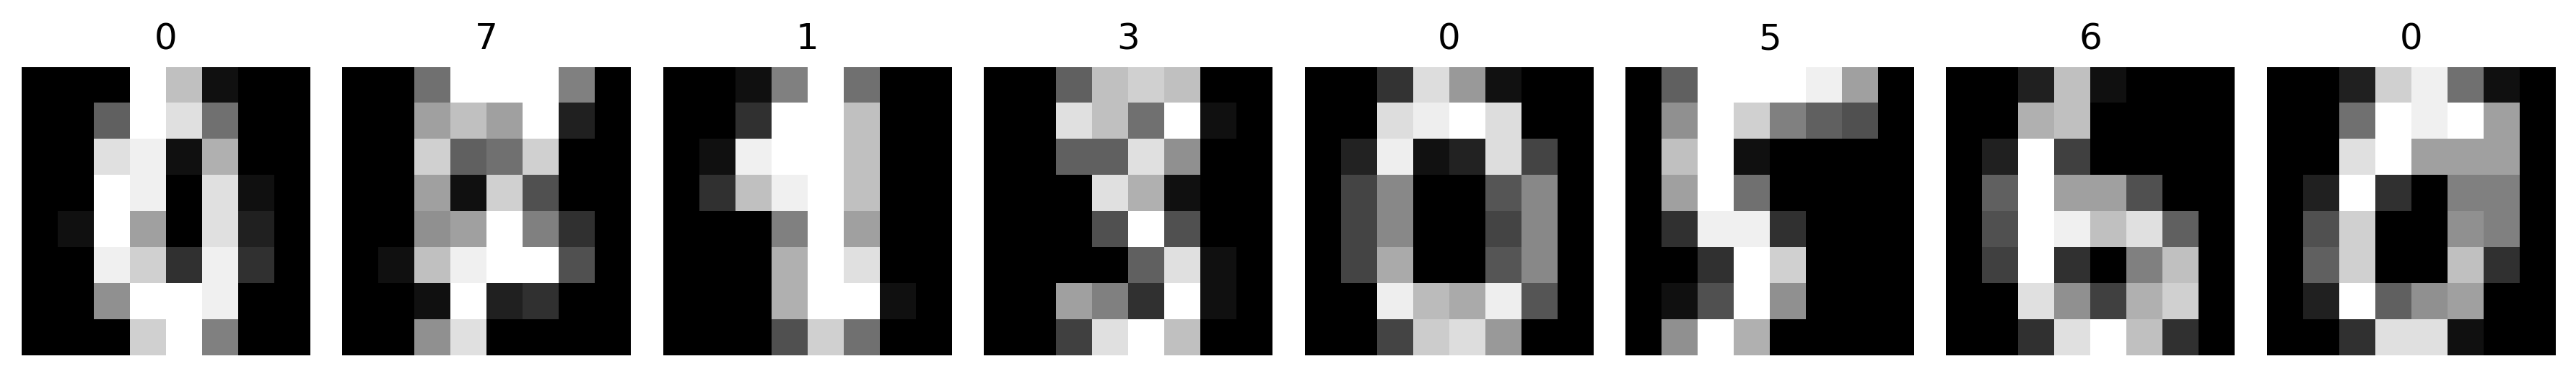

**Figura 9.13:** Muestras de dígitos del conjunto de entrenamiento tras conversión a *tensores* PyTorch y normalización.


In [12]:
# 1. Carga y preprocesamiento de los datos
digits = load_digits()
X = digits.images.astype(np.float32) / 16.0  # Normalización al rango [0, 1]
y = digits.target

# División estratificada en conjuntos de entrenamiento (70%) y prueba (30%)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Adecuación a la dimensión esperada por PyTorch: (N_muestras, Canales, Altura, Anchura)
X_treino_t = torch.tensor(X_treino).unsqueeze(1)   # Dimensión: (N, 1, 8, 8)
y_treino_t = torch.tensor(y_treino, dtype=torch.long)
X_teste_t = torch.tensor(X_teste).unsqueeze(1)
y_teste_t = torch.tensor(y_teste, dtype=torch.long)

# Mostrar una muestra
n_amostras = 8
imgs = [img.squeeze().numpy() for img in X_treino_t[:n_amostras]]
imgs_titles = [str(label.item()) for label in y_treino_t[:n_amostras]]
mm.show(imgs, titles=imgs_titles, cols=n_amostras, figsize=(12, 2.5))

##### Bloque 2: Definición de la Arquitectura Convolucional

La construcción de modelos en **PyTorch** se estructura a partir del paradigma de orientación a objetos, creándose una clase específica para representar la red neuronal (en este ejemplo, la clase `CNNDigitos`), la cual hereda todas las funcionalidades de la clase base `nn.Module`. El constructor `__init__` es responsable de instanciar las capas y declarar sus parámetros entrenables, mientras que el método `forward` establece la secuencia numérica de la propagación hacia adelante (*forward pass*).

[Figura 9.14](#fig-09-cnn-digitos-esquema) sintetiza las transformaciones espaciales de los *tensores* y el flujo de datos a lo largo de la clase `CNNDigitos`.

<figure id="fig-09-cnn-digitos-esquema" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-09-cnn-digitos-esquema.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 9.14:</strong> Representación del flujo de transformaciones dimensionales de los *tensores* a lo largo de la arquitectura *CNNDigitos*.</figcaption>
</figure>

1. **Constructor (`__init__`) e Instanciación de los Componentes:**
   * **Capa Convolucional 1 (`self.conv1`):** Aplica $8$ filtros $3 \times 3$ con `padding=1` sobre la entrada en escala de grises ($1$ canal), preservando la resolución espacial de $8 \times 8$ *píxeles*.
   * **Capa Convolucional 2 (`self.conv2`):** Procesa los $8$ mapas de características recibidos de la capa anterior aplicando $16$ filtros $3 \times 3$ con `padding=1`.
   * **Submuestreo (`self.pool`):** Instancia la operación de *Max-Pooling* con ventana $2 \times 2$ y paso (*stride*) $2$, reduciendo la dimensión espacial (altura y anchura) a la mitad en cada aplicación.
   * **Capas Totalmente Conectadas (`self.fc1` y `self.fc2`):** La primera proyección densa recibe el *tensor* aplanado de dimensión $16 \times 2 \times 2 = 64$ y produce $32$ características intermedias. La segunda proyecta esas $32$ características en los $10$ *logits* finales de salida.

2. **Propagación hacia Adelante en el Método `forward`:**
   * **Primer Bloque Convolucional:** El *tensor* de entrada de formato $(N, 1, 8, 8)$ pasa por `conv1` + ReLU y es submuestreado por `pool`, resultando en el formato $(N, 8, 4, 4)$.
   * **Segundo Bloque Convolucional:** El *tensor* $(N, 8, 4, 4)$ es procesado por `conv2` + ReLU y reducido por `pool` al formato $(N, 16, 2, 2)$.
   * **Aplanamiento (*Flatten*):** El método `x.view(x.size(0), -1)` reconfigura la estructura $3\text{D}$ en un vector $1\text{D}$ de $64$ elementos por muestra, preservando la dimensión del lote $N$.
   * **Clasificación:** El vector de $64$ elementos alimenta `fc1` con activación ReLU ($32$ neuronas) y finaliza en `fc2`, produciendo los $10$ *logits* no normalizados para el cálculo de la función de pérdida.

In [13]:
# 2. Definición de la Arquitectura Convolucional
class CNNDigitos(nn.Module):
    """
    Arquitectura convolucional compacta:
    2 capas convolucionales con ReLU y Max-Pooling + 2 capas densas.
    """
    def __init__(self, n_classes=10):
        super().__init__()
        
        # Conv1: 1 canal de entrada, 8 filtros 3x3 con padding 1 (salida: 8x8)
        self.conv1 = nn.Conv2d(1, 8, kernel_size=3, padding=1)
        # Conv2: 8 canales de entrada, 16 filtros 3x3 con padding 1 (salida: 4x4)
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)

        self.relu = nn.ReLU()

        # Max-Pooling 2x2 con paso (stride) 2
        self.pool = nn.MaxPool2d(2, 2)

        # Capas totalmente conectadas (FC)
        self.fc1 = nn.Linear(16 * 2 * 2, 32)
        self.fc2 = nn.Linear(32, n_classes)

    def forward(self, x):
        # Primer bloque: Conv (8x8) -> ReLU -> Pool (4x4)
        x = self.pool(self.relu(self.conv1(x)))

        # Segundo bloque: Conv (4x4) -> ReLU -> Pool (2x2)
        x = self.pool(self.relu(self.conv2(x)))
        
        # Aplanamiento (Flatten): reconfigura la matriz 3D (16, 2, 2) en vector 1D (64)
        x = x.view(x.size(0), -1)

        # Capa densa intermedia con ReLU
        x = self.relu(self.fc1(x))

        # Capa final de clasificación (logits)
        return self.fc2(x)

###### Análisis de las Capas y del Flujo de la Clase `CNNDigitos`

1. **Constructor (`__init__`) e Instanciación de los Componentes:**
   * **Capa Convolucional 1 (`self.conv1`):** Aplica $8$ filtros $3 \times 3$ con `padding=1` sobre la entrada en escala de grises ($1$ canal), preservando la resolución de $8 \times 8$ *píxeles*.
   * **Capa Convolucional 2 (`self.conv2`):** Procesa los $8$ mapas de características recibidos aplicando $16$ filtros $3 \times 3$ con `padding=1`.
   * **Submuestreo (`self.pool`):** Instancia la operación de *Max-Pooling* con ventana $2 \times 2$ y paso (*stride*) $2$, reduciendo las dimensiones espaciales (alto y ancho) a la mitad en cada aplicación.
   * **Capas Totalmente Conectadas (`self.fc1` y `self.fc2`):** La primera proyección densa recibe el *tensor* aplanado de dimensión $16 \times 2 \times 2 = 64$ y produce $32$ características intermediarias. La segunda proyecta esas $32$ características en los $10$ *logits* de salida.

2. **Propagación hacia Adelante en el Método `forward`:**
   * **Primer Bloque:** El *tensor* $(N, 1, 8, 8)$ pasa por `conv1` + ReLU y es reducido por `pool` a $(N, 8, 4, 4)$.
   * **Segundo Bloque:** El *tensor* $(N, 8, 4, 4)$ pasa por `conv2` + ReLU y es reducido por `pool` a $(N, 16, 2, 2)$.
   * **Aplanamiento (*Flatten*):** El método `x.view(x.size(0), -1)` convierte la estructura $3\text{D}$ en un vector $1\text{D}$ de $64$ elementos por muestra.
   * **Clasificación:** El vector de $64$ elementos alimenta `fc1` con activación ReLU ($32$ neuronas) y finaliza en `fc2`, que produce los $10$ *logits* finales para el cálculo de la pérdida de Entropía Cruzada.

##### Bloque 3: Instanciación y Parámetros de Optimización

La etapa de configuración del aprendizaje exige la instanciación de la arquitectura definida y la elección de dos componentes centrales: la **función de pérdida**, que cuantifica el error del modelo, y el **algoritmo de optimización**, responsable de ajustar los parámetros hacia el mínimo de dicha función.

1. **Instanciación y Conteo de Parámetros:**
   El modelo se crea a partir de la instanciación del objeto `modelo_cnn` de la clase `CNNDigitos`. La expresión `sum(p.numel() for p in modelo_cnn.parameters())` recorre todos los *tensores* de parámetros entrenables de la red (pesos y sesgos de cada capa) y calcula la cardinalidad total del modelo, cuantificando su capacidad de representación.

2. **Función de Pérdida (`nn.CrossEntropyLoss`):**
   La pérdida de Entropía Cruzada (*Cross-Entropy Loss*) es la elección estándar para problemas de clasificación multiclase. En PyTorch, esta implementación combina internamente la aplicación de la función *LogSoftmax* con la Pérdida de Log-Verosimilitud Negativa (*NLLLoss*). Por esta razón, la capa de salida de la red produce *logits* brutos, prescindiendo de la aplicación explícita de la función *Softmax* al final del método `forward`.

3. **Optimizador Adaptativo (`optim.Adam`):**
   La actualización de los parámetros utiliza el algoritmo *Adam* (*Adaptive Moment Estimation*), con una tasa de aprendizaje inicial $\eta = 0,01$ (`lr=1e-2`). El *Adam* combina los principios del momento con la adaptación del tamaño del paso basada en la media móvil de las derivadas de primer y segundo orden, ajustando individualmente la tasa de aprendizaje de cada parámetro de la red.

In [14]:
# 3. Inicialización del modelo y parámetros de optimización
modelo_cnn = CNNDigitos()
num_params = sum(p.numel() for p in modelo_cnn.parameters())
print(f"Parámetros entrenables del modelo: {num_params}")

criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo_cnn.parameters(), lr=1e-2)

Parámetros entrenables del modelo: 3658


##### Bloque 4: Bucle de Entrenamiento y Evaluación

El entrenamiento de una CNN ocurre de forma iterativa mediante el algoritmo de Descenso de Gradiente Estocástico por *mini-lotes* (*Mini-batch SGD*).

Las curvas de aprendizaje resultantes de este proceso se presentan en la [Figura 9.15](#fig-09-cnn-treinamento), generada al final de la ejecución.

1. **Fase de Entrenamiento (`modelo_cnn.train()`):**
   El bucle principal ejecuta el entrenamiento a lo largo de $50$ épocas. En cada época, ocurren las siguientes etapas:
   * **Barajado Estocástico:** La función `torch.randperm(n)` genera una permutación aleatoria de los índices de las muestras, garantizando que la ordenación de los *mini-lotes* varíe en cada época para evitar sesgos de muestreo.
   * **División en *Mini-lotes*:** El conjunto de entrenamiento se divide en lotes de $32$ muestras (`tam_lote = 32`).
   * **Poner a cero los Gradientes (`otimizador.zero_grad()`):** Limpia los gradientes acumulados en el *tensor* en la iteración anterior, evitando la suma no deseada de derivadas entre lotes distintos.
   * **Paso hacia Adelante y Pérdida:** El *forward pass* calcula las predicciones `saida`, y la llamada `criterio(saida, y_treino_t[idx])` cuantifica el error del lote.
   * **Retropropagación (`perda.backward()`):** Aplica la regla de la cadena para calcular las derivadas parciales de la pérdida con respecto a cada parámetro ($\frac{\partial L}{\partial w}$).
   * **Actualización de los Pesos (`otimizador.step()`):** Actualiza los parámetros del modelo según las ecuaciones del optimizador *Adam*.

2. **Fase de Evaluación (`modelo_cnn.eval()`):**
   Al final de cada época, el modelo se cambia al modo de evaluación. El contexto `with torch.no_grad()` desactiva temporalmente el motor de cálculo automático de derivadas (*autograd*), reduciendo el consumo de memoria y acelerando la inferencia sobre el conjunto de prueba (`X_teste_t`). La operación `.argmax(dim=1)` extrae la clase de mayor probabilidad para cada muestra, permitiendo calcular la precisión de prueba.

3. **Visualización con la Biblioteca `morph`:**
   La función `mm.showTrainCurves` de la biblioteca didáctica `morph` consolida el historial de pérdida de entrenamiento y la precisión de prueba en un único panel gráfico, permitiendo diagnosticar la convergencia del modelo y monitorear la estabilidad del aprendizaje a lo largo de las épocas.

Exactitud final de la CNN en el conjunto de prueba: 0.9759


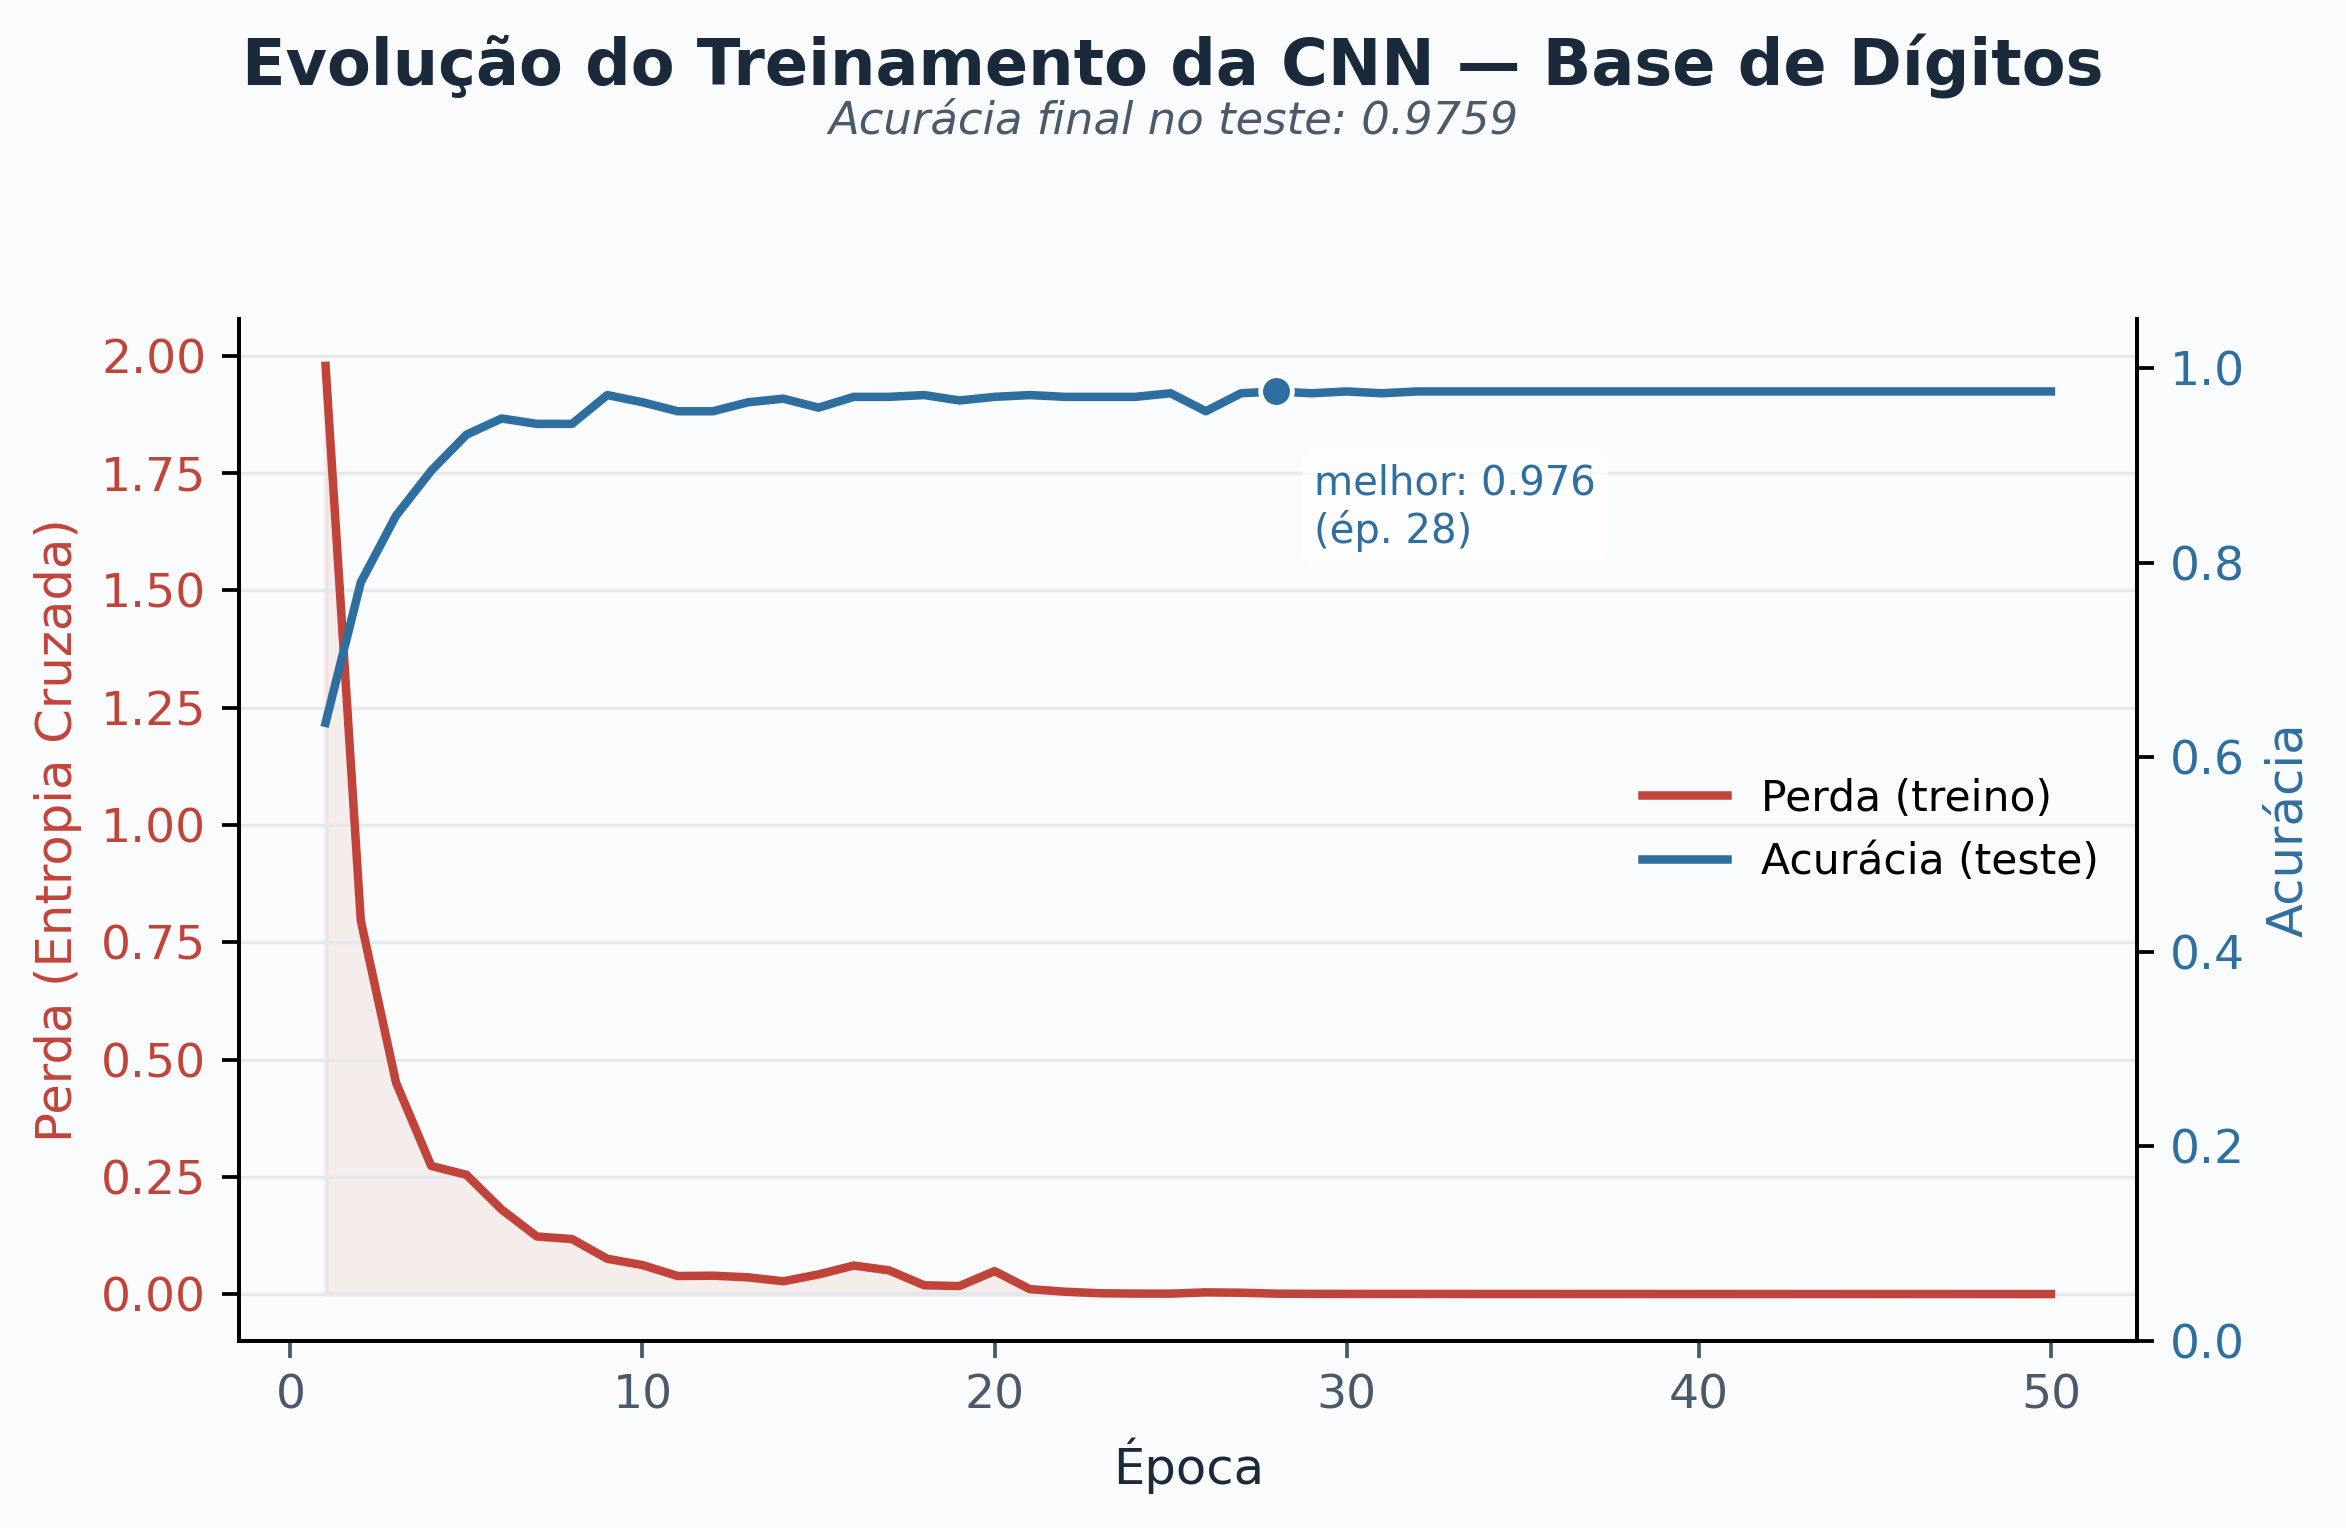

**Figura 9.15:** Curvas de entrenamiento y evaluación de la CNN en la base de dígitos: evolución de la pérdida de entropía cruzada en el conjunto de entrenamiento y de la exactitud en el conjunto de prueba a lo largo de 50 épocas.


In [15]:
# 4. Bucle de Entrenamiento (Mini-batch SGD)
n = X_treino_t.size(0)                    # Número de muestras
tam_lote = 32                             # Tamaño del mini-lote
epocas = 50                               # Total de épocas
historico_perda, historico_acc = [], []   # Historial de métricas

for epoca in range(epocas):                  # Repite por época
    modelo_cnn.train()                       # Modo entrenamiento
    perm = torch.randperm(n)                 # Baraja muestras
    perda_epoca = 0.0                        # Acumula pérdidas
    for i in range(0, n, tam_lote):          # Recorre mini-lotes
        idx = perm[i:i + tam_lote]           # Índices del lote
        otimizador.zero_grad()               # Pon a cero gradientes
        saida = modelo_cnn(X_treino_t[idx])  # Propagación hacia adelante
        perda = criterio(saida, y_treino_t[idx]) # Calcula pérdida
        perda.backward()                         # Retropropagación
        otimizador.step()                        # Actualiza pesos
        perda_epoca += perda.item() * len(idx)   # Suma pérdida

    # Evaluación del modelo en el conjunto de prueba al final de cada época
    modelo_cnn.eval()                            # Modo evaluación
    with torch.no_grad():                        # Sin gradientes
        pred_teste = modelo_cnn(X_teste_t).argmax(dim=1)  # Predicciones
        acc_teste = (pred_teste == y_teste_t).float().mean().item()  # Exactitud
    historico_perda.append(perda_epoca / n)      # Registra pérdida
    historico_acc.append(acc_teste)              # Registra exactitud

acc_final_cnn = historico_acc[-1]                # Última exactitud
print(f"Exactitud final de la CNN en el conjunto de prueba: {acc_final_cnn:.4f}")  # Muestra resultado

final = mm.showTrainCurves(                      # Traza curvas
    historico_perda, historico_acc,
    titulo="Evolução do Treinamento da CNN — Base de Dígitos",
    subtitulo=f"Acurácia final no teste: {acc_final_cnn:.4f}",
)

##### Bloco 5: Visualización del Flujo de Activaciones

La inspección de la red entrenada permite observar la transformación progresiva del *tensor* de entrada a lo largo de las capas de la arquitectura `CNNDigitos`. La [Figura 9.16](#fig-09-cnn-ativacoes) ilustra las dimensiones y las activaciones intermedias obtenidas al procesar un ejemplo real del dígito $3$.

1. **Selección y Preparación de la Muestra:**
   La semilla estocástica se fija con `torch.manual_seed(7)` para asegurar la reproducibilidad de los resultados. La primera ocurrencia del dígito $3$ en el conjunto de datos `load_digits` se aísla, se normaliza al intervalo $[0.0, 1.0]$ y se reconfigura como un *tensor* `x` de dimensión $(1, 1, 8, 8)$.

2. **Inspección Intermedia con `mm.showNet`:**
   La función `mm.showNet` de la biblioteca `morph` ejecuta la propagación hacia adelante (*forward pass*) del *tensor* `x` en la instancia `modelo_cnn` previamente entrenada. Utilizando *hooks* de *forward*, la función intercepta el estado numérico de las activaciones en las capas convolucionales (`nn.Conv2d`), de agrupamiento (`nn.MaxPool2d`) y totalmente conectadas (`nn.Linear`), devolviéndolas en el diccionario `acts`. Las funciones de activación no lineal (`nn.ReLU`) no se registran como etapas independientes, ya que su aplicación ocurre directamente sobre el *tensor* de salida de la capa correspondiente.

3. **Verificación de los Resultados:**
   La instrucción `list(acts.keys())` muestra la secuencia de identificadores de las capas monitoreadas, permitiendo confirmar la reducción dimensional progresiva y la generación del *logit* de valor máximo en el índice correspondiente a la clase $3$, según se demuestra en la [Figura 9.16](#fig-09-cnn-ativacoes)..

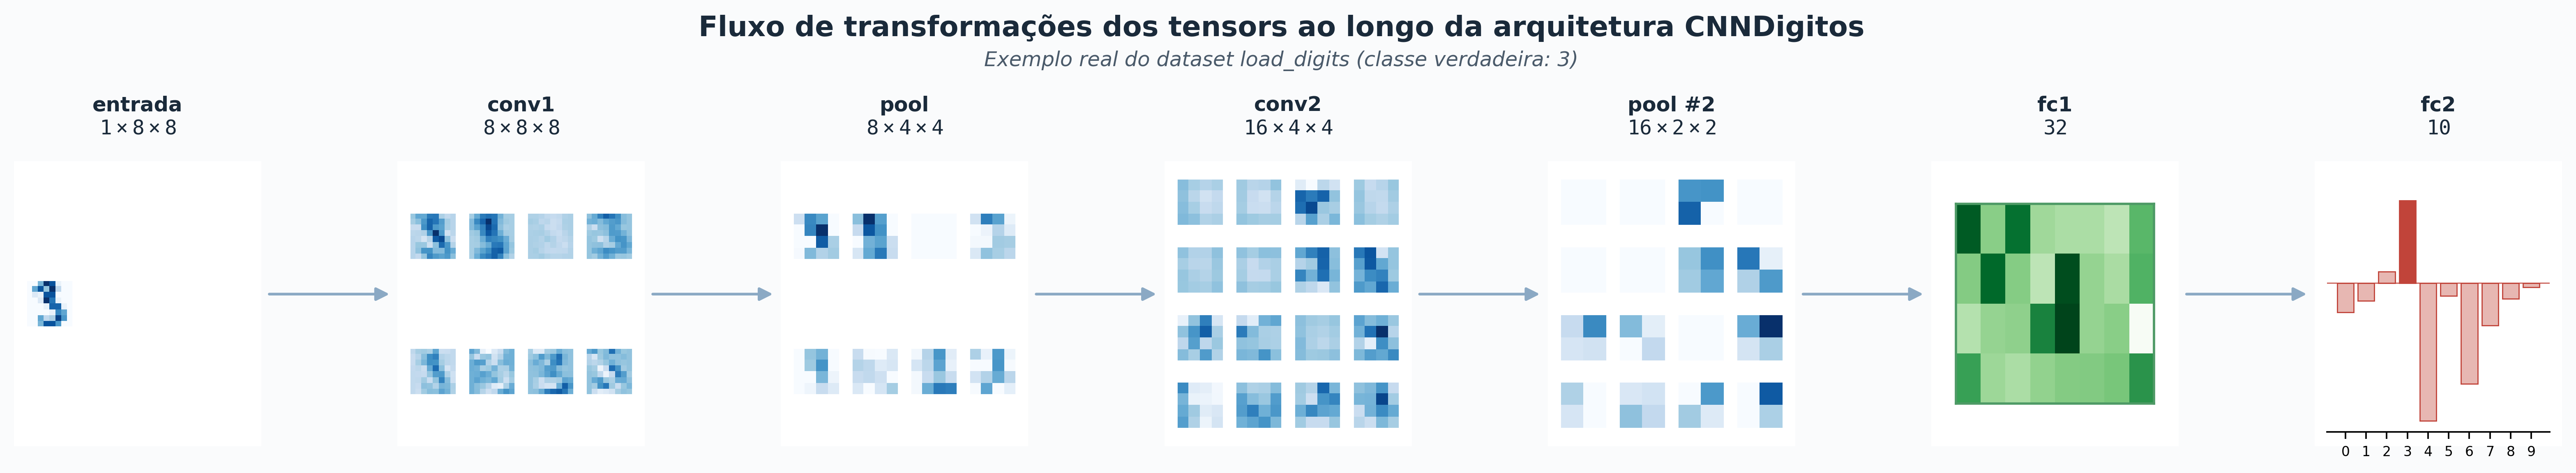

**Figura 9.16:** Flujo de activaciones de la CNN entrenada al procesar un ejemplo real del dígito 3, del *dataset* *load_digits*: dimensiones de los tensores capa a capa, de la entrada al *logit* de salida.


Capas capturadas: ['conv1', 'pool', 'conv2', 'pool #2', 'fc1', 'fc2']


In [16]:
torch.manual_seed(7)
digits = load_digits()
idx = np.where(digits.target == 3)[0][0]
img = digits.images[idx] / 16.0
x = torch.tensor(img, dtype=torch.float32).view(1, 1, 8, 8)

# Reutilización de la instancia del modelo previamente entrenado
acts = mm.showNet(
    modelo_cnn,
    x,
    titulo="Fluxo de transformações dos tensors ao longo da arquitetura CNNDigitos",
    subtitulo=f"Exemplo real do dataset load_digits (classe verdadeira: {digits.target[idx]})",
)
print("Capas capturadas:", list(acts.keys()))

##### Inspeccionando el Grafo Computacional con `torchviz`

Mientras que `mm.showNet` prioriza la claridad didáctica —mostrando una columna por capa con parámetros entrenables—, la biblioteca `torchviz` proyecta el **grafo de autograd** exactamente como PyTorch lo construye internamente para el cálculo de gradientes. La [Figura 9.17](#fig-09-torchviz-grafo) ilustra esta perspectiva al representar la arquitectura `CNNDigitos`.

1. **Propagación hacia adelante rastreada:** Con el modelo entrenado en modo `eval()`, el *forward pass* sobre el *tensor* `x` del dígito $3$ es suficiente para que el motor de *autograd* registre todas las operaciones ejecutadas, incluyendo aquellas sin parámetros entrenables, como la función de activación `ReLU` y la reconfiguración dimensional `view`.

2. **Generación del grafo (`make_dot`):** La función `make_dot(saida, params=...)` construye el grafo a partir del *tensor* de salida, recorriendo retroactivamente el historial de operaciones hasta los nodos hoja (los parámetros entrenables del modelo). Cada nodo del diagrama representa una operación del *backward pass* (como `ReluBackward` o `AddmmBackward`), y no solo un bloque conceptual del `nn.Module`.

3. **Exportación y renderizado (`.render`):** El método `.render(..., format="png", cleanup=True)` invoca el ejecutable `dot` de **Graphviz** para compilar la imagen en formato PNG, eliminando automáticamente los archivos intermedios de código fuente.

La [Figura 9.17](#fig-09-torchviz-grafo) evidencia cómo este grafo computacional, incluso para una arquitectura compacta, presenta mayor densidad que el panel de `mm.showNet`, pues detalla cada operación atómica responsable del flujo de gradientes.

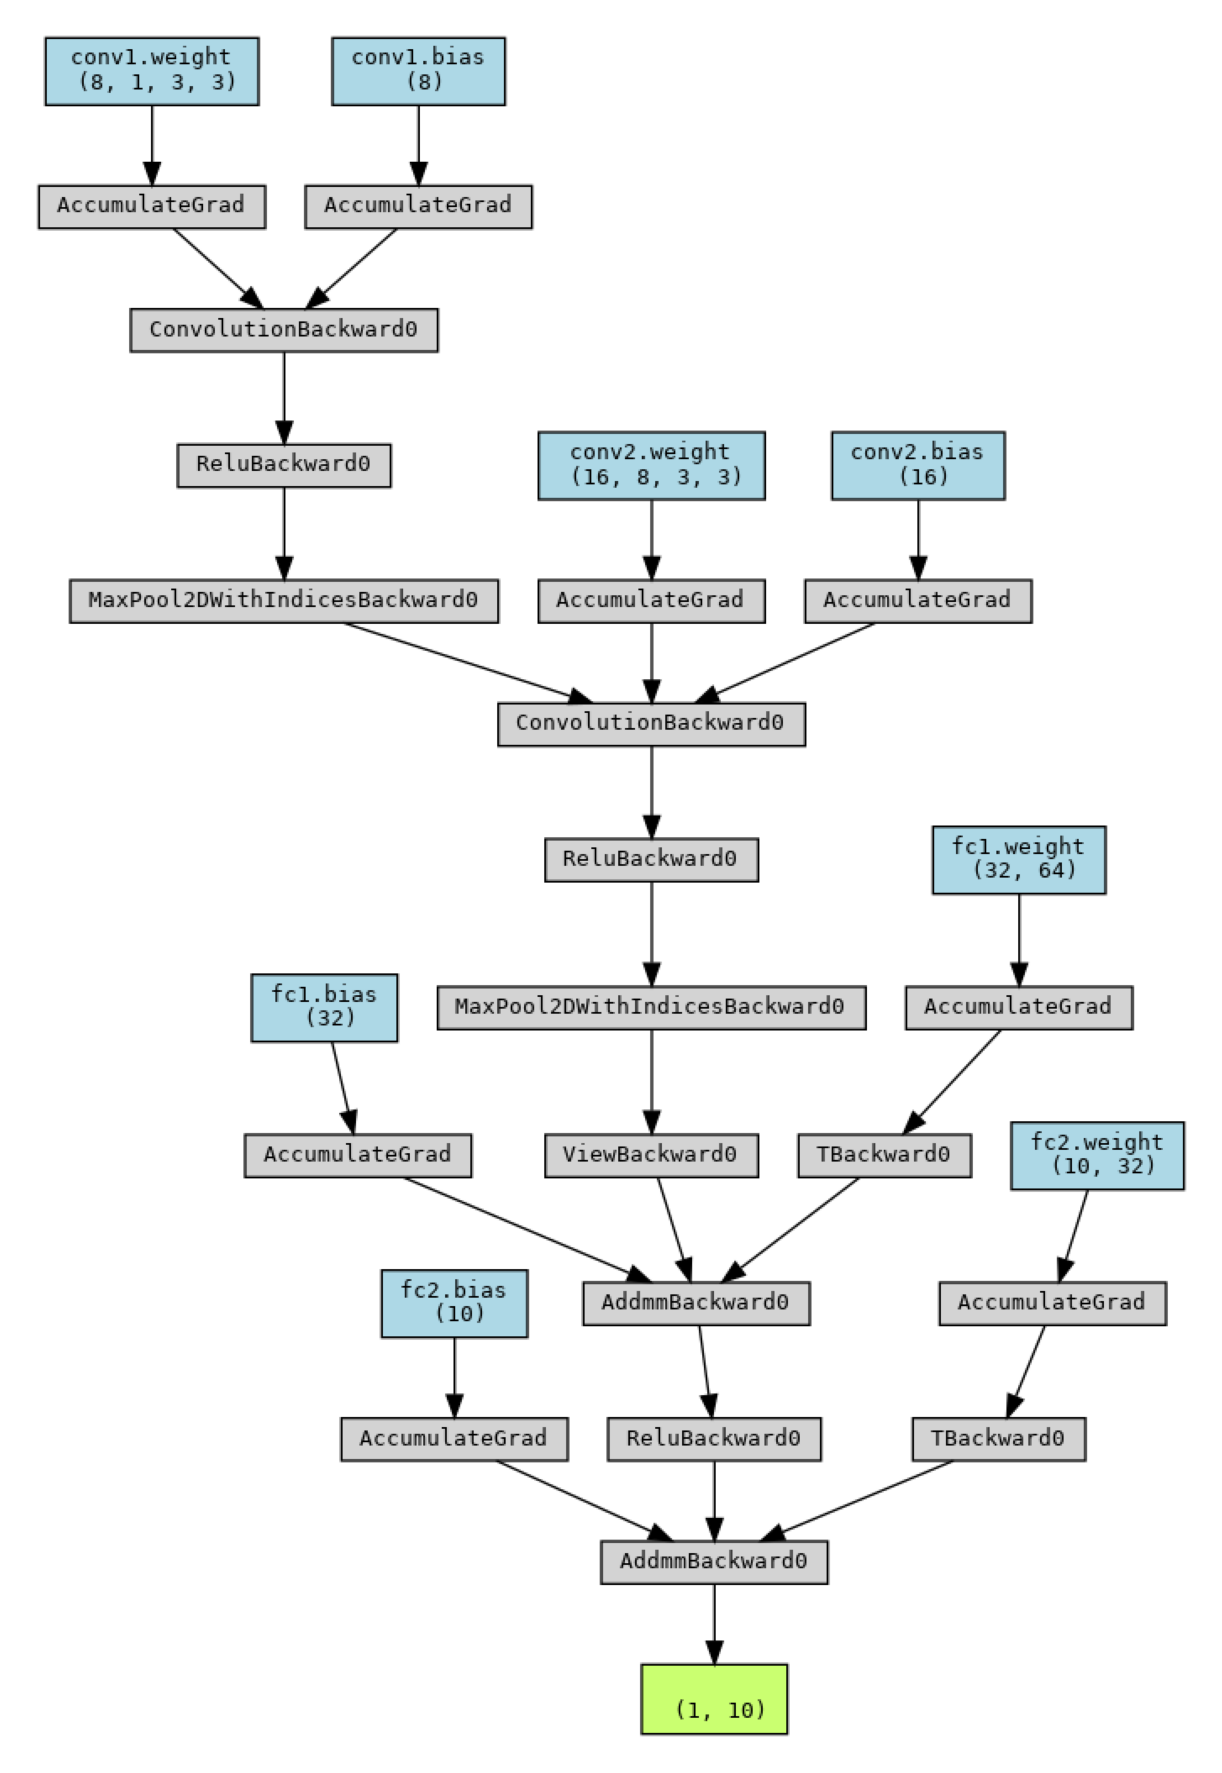

**Figura 9.17:** Grafo computacional de la *CNNDigitos* generado vía *torchviz*, mostrando las operaciones de *forward* y los nodos de gradiente (*backward*) asociados a cada parámetro entrenable.


In [17]:
# 1. Forward pass con rastreo de gradiente habilitado
modelo_cnn.eval()
saida = modelo_cnn(x)  # Reutilización del tensor x (dígito 3)

# 2. Grafo básico: flujo de operaciones hasta la salida
grafo_simples = make_dot(saida, params=dict(modelo_cnn.named_parameters()))
caminho_simples = grafo_simples.render("cnn_digitos_grafo_simples", format="png", cleanup=True)

# 3. Visualización directa en el entorno Quarto/Jupyter
# El .render() devuelve la ruta del archivo PNG generado; necesitamos abrirlo como imagen
imagem_simples = np.array(Image.open(caminho_simples).convert("RGB"))
mm.show(imagem_simples, figsize=(5,10))

##### Visão Detallada del Grafo Computacional con `torchviz`

Además de la representación simplificada, la biblioteca `torchviz` permite expandir el grafo de *autograd* para inspeccionar los detalles internos de ejecución de la red `CNNDigitos`. La [Figura 9.18](#fig-09-torchviz-grafo-detalhado) presenta esta estructura expandida para el mismo *tensor* de entrada `x`.

1. **Rastreo con Atributos de Operación (`show_attrs=True`):** 
   La inclusión de atributos muestra las configuraciones hiperparamétricas asociadas a cada nodo computacional durante la propagación hacia adelante (*forward pass*), tales como dimensiones de *kernel* (`kernel_size`), pasos (*stride*) y rellenos (*padding*) en las convoluciones y submuestreos.

2. **Detección de *Tensors* Guardados en Memoria (`show_saved=True`):**
   El parámetro fuerza la visualización explícita de los *tensors* intermedios que PyTorch retiene en memoria durante el *forward pass*. Estos datos se conservan porque serán estrictamente necesarios para el cálculo de las derivadas parciales durante la etapa de retropropagación (*backward pass*).

3. **Generación y Compilación de los Grafos:**
   Mientras que `grafo_simples` genera una vista directa del flujo de gradientes, `grafo_detalhado` compila el grafo expandido en el archivo `cnn_digitos_grafo_detalhado.png` mediante el ejecutable `dot` de **Graphviz**.

Como se observa en la [Figura 9.18](#fig-09-torchviz-grafo-detalhado), esta visualización minuciosa es útil para depurar el consumo de memoria de video (*VRAM*) y verificar cómo el motor de PyTorch asigna internamente cada nodo de la regla de la cadena.

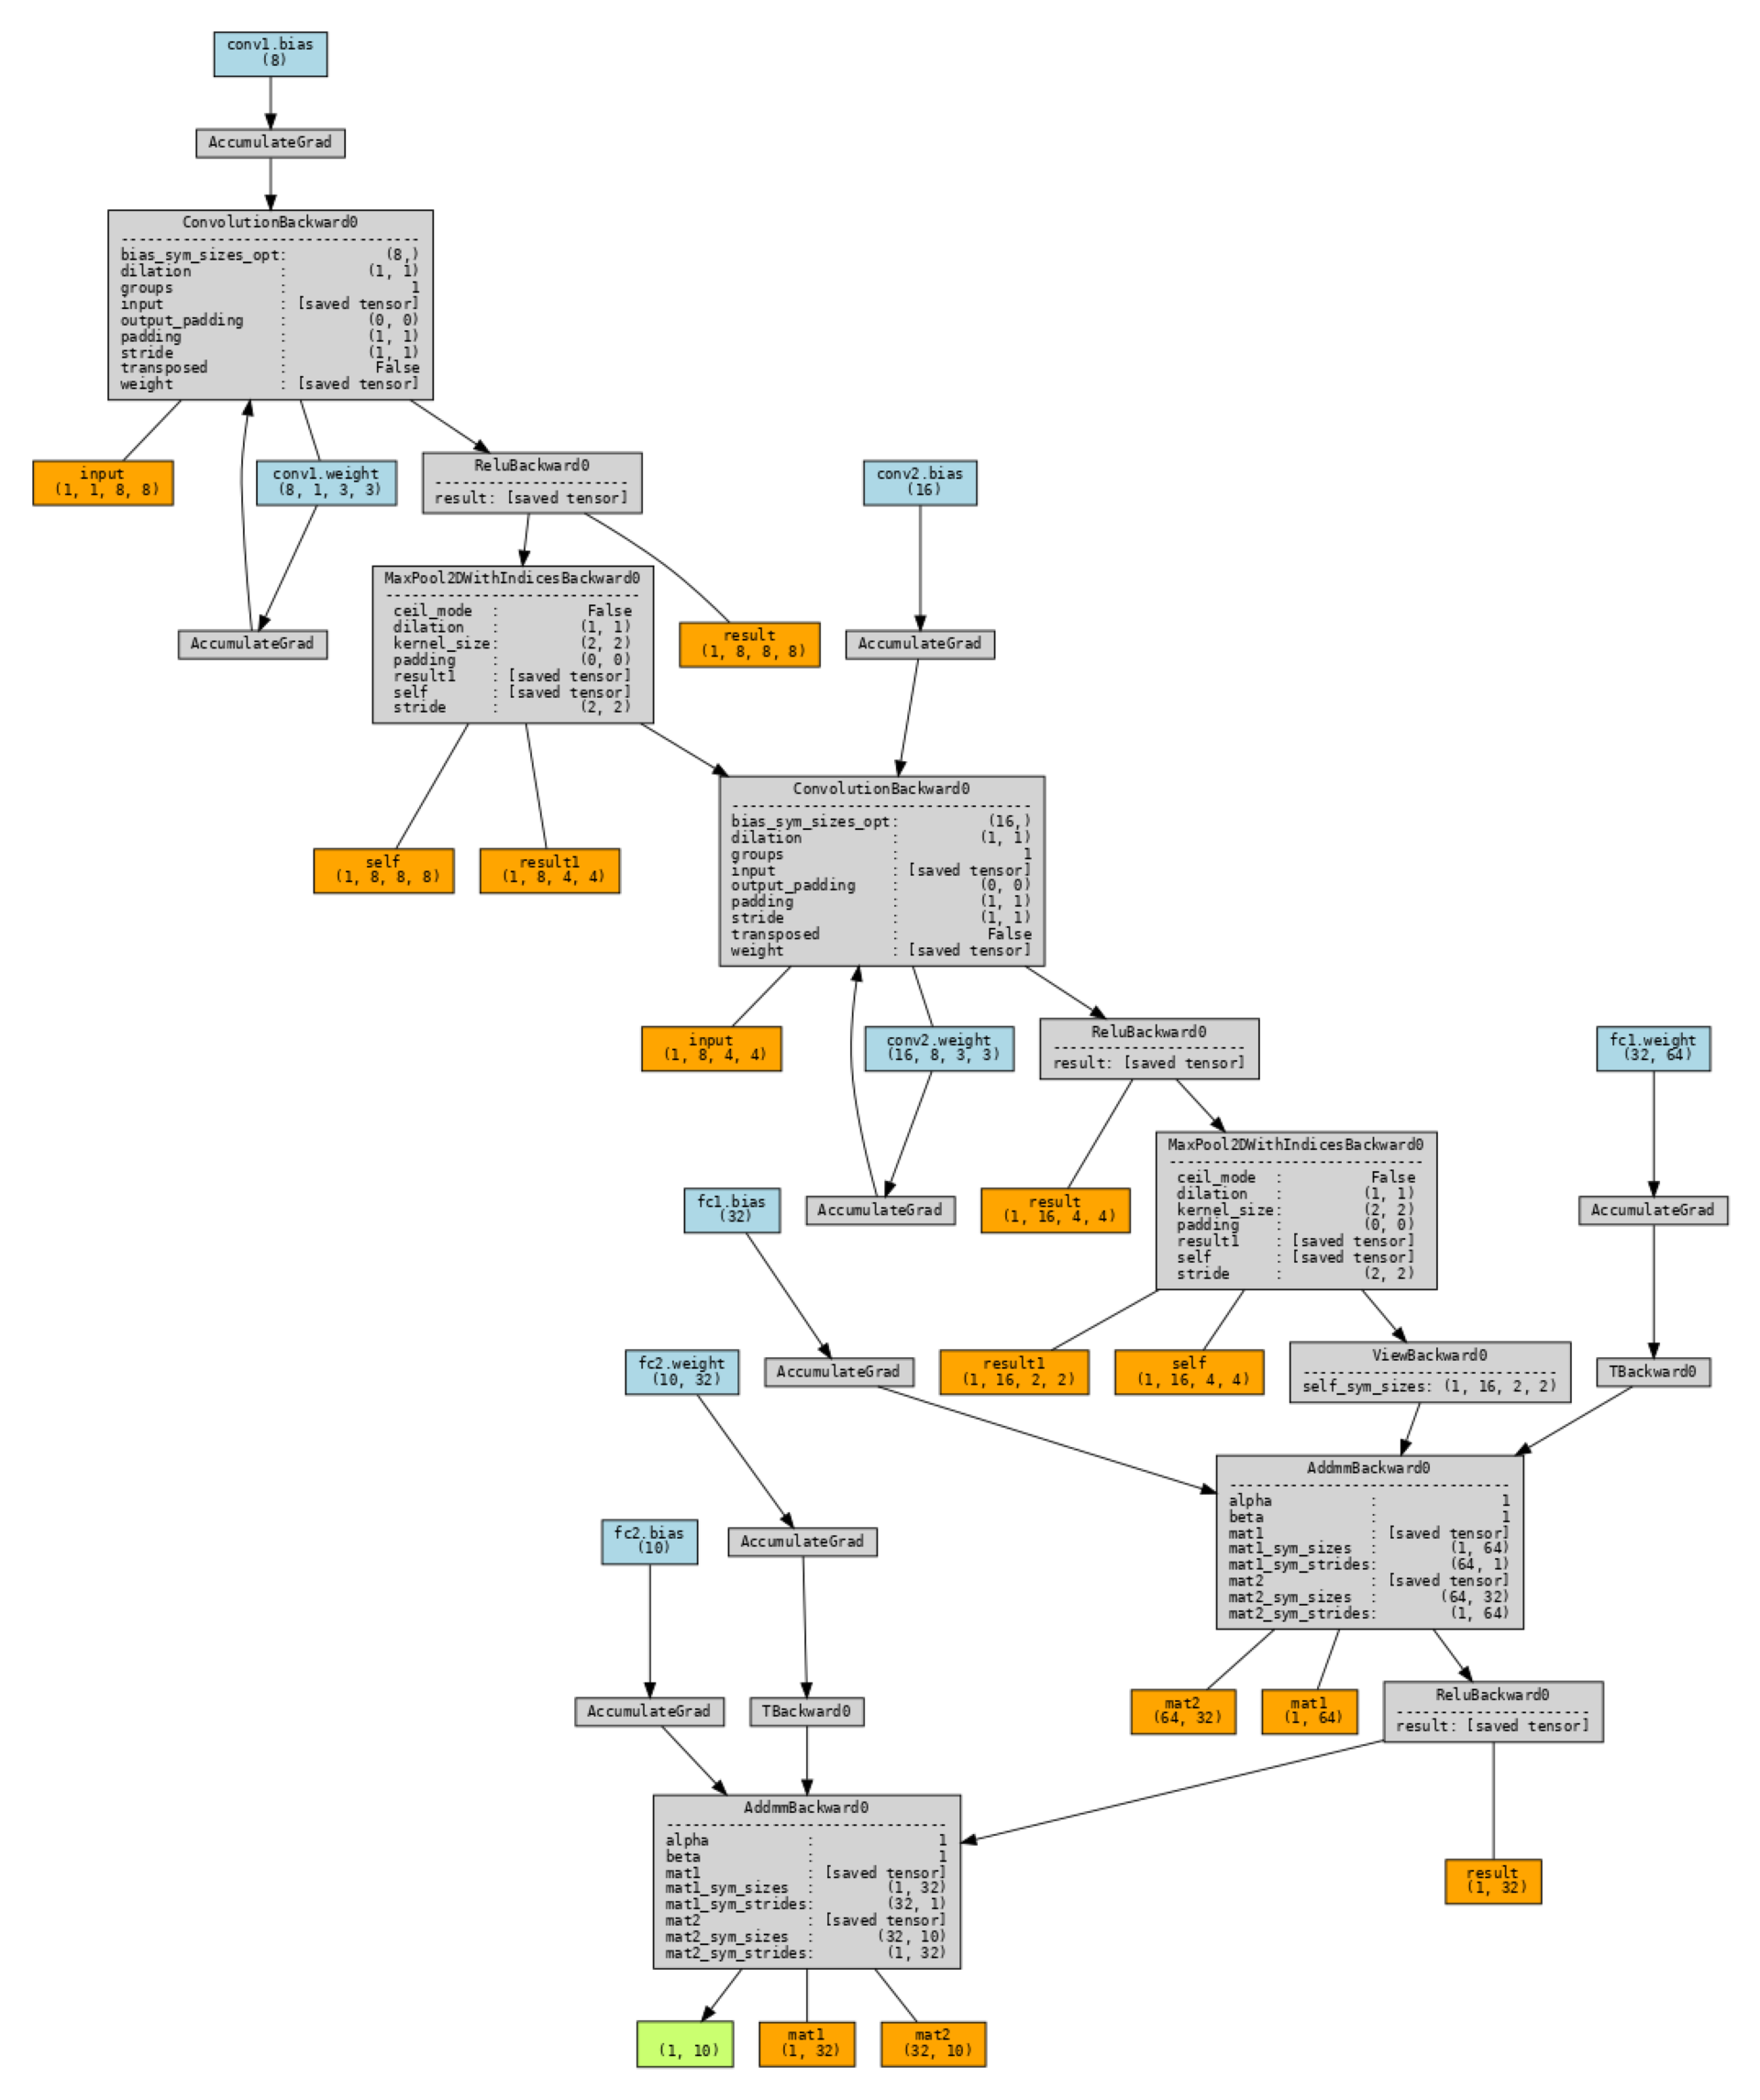

**Figura 9.18:** Grafo detallado de la clase CNNDigitos generado via *torchviz*.


In [18]:
# mismo código anterior (make_dot + render)...

# 2. Grafo detallado: exhibición de dimensiones y tensores guardados para el backward
grafo_detalhado = make_dot(
    saida,
    params=dict(modelo_cnn.named_parameters()),
    show_attrs=True,   # Exhibe atributos de las operaciones (ej.: kernel_size, stride)
    show_saved=True,   # Exhibe tensores guardados en la memoria para la retropropagación
)

caminho_detalhado = grafo_detalhado.render("cnn_digitos_grafo_detalhado", 
                                           format="png", cleanup=True)

# 3. Exhibición directa en el entorno Quarto/Jupyter
imagem_detalhado = np.array(Image.open(caminho_detalhado).convert("RGB"))
mm.show(imagem_detalhado, figsize=(8, 16))

##### Comparando con el Capítulo 7

La [Figura 9.19](#fig-09-comparativo-cap7) reúne los resultados obtenidos en el mismo conjunto de datos (`load_digits`), estableciendo un paralelo directo entre los enfoques clásicos explorados anteriormente y la CNN desarrollada en este capítulo.

1. **Rendimiento de los *píxeles* brutos vs. descriptores manuales:** En los experimentos del Capítulo 7, el clasificador $k\text{-NN}$ ($k=3$) alcanzó una precisión del $98,4\%$ cuando se alimentó directamente con los *píxeles* brutos de las imágenes. En contraste, la extracción previa de características mediante *Histogram of Oriented Gradients* (*HOG*) resultó en un rendimiento significativamente inferior ($75,8\%$). Esta caída se debe a que el *HOG* fue diseñado para capturar gradientes de bordes en imágenes de mayor resolución; en matrices de solo $8 \times 8$ *píxeles*, la resolución espacial es insuficiente para formar histogramas de orientación informativos.

2. **Equivalencia de la CNN y aprendizaje *end-to-end*:** La red convolucional `CNNDigitos` alcanza un rendimiento competitivo del $97,6\%$, acercándose a la precisión del $k\text{-NN}$ con *píxeles* brutos en una base pequeña y prealineada. La gran ventaja conceptual reside en el aprendizaje de representación: en lugar de depender de descriptores diseñados manualmente (*handcrafted features*) o de mantener todo el conjunto de datos en memoria para la búsqueda de vecinos en el momento de la inferencia, la CNN optimiza automáticamente sus propios filtros convolucionales durante el entrenamiento, generando un modelo compacto capaz de realizar la extracción de características y la clasificación de forma integrada (*end-to-end*).

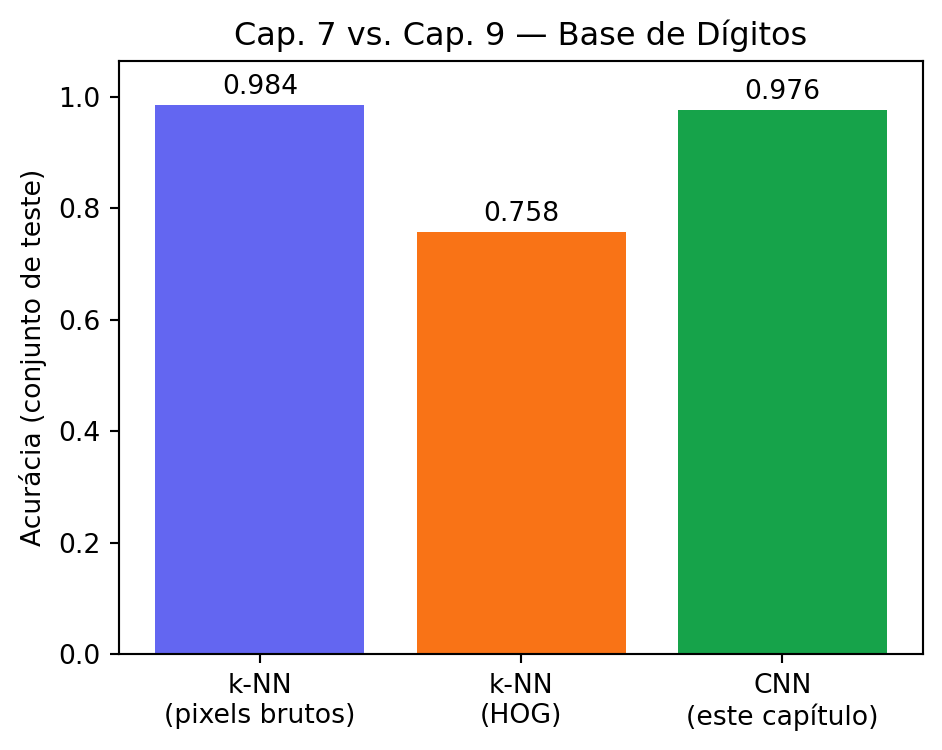

**Figura 9.19:** Comparación de precisión entre los clasificadores clásicos del Capítulo 7 (píxeles brutos y HOG con k-NN) y la CNN entrenada en este capítulo, en la misma base de dígitos.


In [19]:
import matplotlib.pyplot as plt

# Valores obtenidos en el Capítulo 7 (k-NN, k=3), reproducidos para comparación directa
ACC_KNN_PIXELS_CAP7 = 0.9844
ACC_KNN_HOG_CAP7 = 0.7578

metodos = ["k-NN\n(pixels brutos)", "k-NN\n(HOG)", "CNN\n(este capítulo)"]
acuracias = [ACC_KNN_PIXELS_CAP7, ACC_KNN_HOG_CAP7, acc_final_cnn]

plt.figure(figsize=(5, 4))
cores = ["#6366f1", "#f97316", "#16a34a"]
plt.bar(metodos, acuracias, color=cores)
plt.ylim(0, max(acuracias) + 0.08)
plt.ylabel("Acurácia (conjunto de teste)")
plt.title("Cap. 7 vs. Cap. 9 — Base de Dígitos")

for i, v in enumerate(acuracias):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

> ### 📝 Nota
>
> ###### 🧠 ¿Por qué funciona? — Y por qué la CNN no siempre "gana"
>
> El resultado aquí observado **repite el patrón ya visto en el Capítulo 7**: la CNN, aunque aprende sus características automáticamente, no supera necesariamente al $k\text{-NN}$ con *píxeles* brutos en esta base específica. La explicación es la misma: `load_digits` es una base pequeña (menos de $1.800$ ejemplos), con imágenes ya centradas, normalizadas y de muy baja resolución ($8 \times 8$) — condiciones en las que la comparación directa de intensidades ya es altamente informativa, y hay pocos datos para que la red aprenda filtros verdaderamente superiores a los descriptores simples.
>
> El verdadero diferencial de las CNN aparece en escenarios que los descriptores artesanales y los clasificadores simples no pueden abordar: imágenes más grandes y realistas, con miles de categorías, variación sustancial de pose, iluminación y fondo, y conjuntos de entrenamiento masivos — exactamente el régimen en el que los modelos presentados en la sección *"Aplicaciones a Gran Escala"*, más adelante, fueron entrenados. La lección pedagógica que atraviesa los Capítulos 7, 8 y 9 de este libro es consistente: **la sofisticación de un método debe ser proporcional a la complejidad del problema** — usar una CNN para un problema que un $k\text{-NN}$ resuelve igualmente bien es desperdicio de recursos computacionales, no una virtud.
>
> Esa misma proporcionalidad se aplica a las herramientas de inspección utilizadas a lo largo del capítulo. El `mm.showNet` fue construido con fines **didácticos** y funciona bien en redes poco profundas como la `CNNDigitos`, pero no escala a arquitecturas profundas: cada capa rastreada se convierte en una columna en la figura, y las capas convolucionales con cientos de canales generan mosaicos demasiado grandes para la interpretación visual; además, los *hooks* almacenan todas las activaciones en memoria, y el *layout* asume un flujo secuencial, sin representar fielmente conexiones residuales o ramificaciones (como en *ResNets* o módulos *Inception*). Así, `showNet` debe entenderse como una lente pedagógica para redes pequeñas — análoga al papel de `mm.showBoundBox` en la depuración visual de detecciones — y no como un sustituto de herramientas orientadas a la producción, como *TensorBoard* o *torchviz*.

#### 9.5.1.2 Transferencia de Aprendizaje

Entrenar una CNN desde cero generalmente requiere una gran cantidad de datos etiquetados y recursos computacionales significativos, ya que el proceso de entrenamiento necesita ajustar todos los parámetros de la red. En muchas aplicaciones, sin embargo, solo se dispone de un conjunto reducido de datos para la tarea de interés. En esta situación, la **transferencia de aprendizaje** (*transfer learning*) reutiliza las representaciones aprendidas por un modelo previamente entrenado en una tarea de origen con un gran volumen de datos, reduciendo el costo de entrenamiento y la necesidad de nuevas muestras.

En la VC, esta estrategia explora la organización jerárquica de las CNNs. Las capas iniciales aprenden características visuales de bajo nivel, como bordes, texturas, gradientes de intensidad y patrones de colores, que permanecen útiles en diferentes dominios. Las capas más profundas combinan esta información para formar representaciones progresivamente más abstractas y especializadas, relacionadas con las clases presentes en la base de entrenamiento.

Esta sección investiga en qué condiciones la transferencia de aprendizaje produce buenos resultados. El primer experimento muestra que un extractor pequeño y entrenado en un dominio restringido puede conducir a la **transferencia negativa** (*negative transfer*). El segundo demuestra por qué los modelos profundos preentrenados en grandes bases de imágenes alcanzan un alto rendimiento en nuevas tareas. Por último, el tercero aplica esta estrategia a un problema de diagnóstico fitosanitario, ilustrando un escenario cercano a aplicaciones reales.

##### Experimento 1 — Limitaciones de un Extractor Pequeño y Especializado

El primer experimento muestra que la transferencia de aprendizaje no siempre mejora el rendimiento de un modelo. Para ello, el conjunto de dígitos manuscritos (`load_digits`) se divide en dos dominios disjuntos:

- **Dominio A (origen):** dígitos $0$ a $4$, utilizados para entrenar una pequeña CNN;
- **Dominio B (destino):** dígitos $5$ a $9$, reindexados a $0$ a $4$, formando una nueva tarea con solo $20$ muestras de entrenamiento.

El objetivo consiste en evaluar el efecto de reutilizar el extractor de características aprendido en el Dominio A sin permitir su adaptación al Dominio B.

###### Bloque 1: División de los Dominios, Escasez y Exhibición de las Muestras

Este bloque prepara el conjunto de datos para el experimento. A diferencia del proyecto anterior, que utilizó todos los dígitos en un único problema de clasificación, la base se divide en dos tareas independientes: una tarea de origen (Dominio A) y una tarea de destino (Dominio B).

La [Figura 9.20](#fig-09-transfer-amostras) presenta ejemplos de los dos dominios después de la separación de las clases, la conversión a *tensors* de **PyTorch** y el preprocesamiento.

1. **Separación de las clases:** Las máscaras booleanas `mask_A` y `mask_B` separan los ejemplos de cada dominio. A continuación, el código reindexa las etiquetas del Dominio B (`y[mask_B] - 5`) al intervalo $[0,4]$, permitiendo que ambos modelos utilicen cinco clases de salida.

2. **Escasez de datos:** El generador `np.random.default_rng(0)` selecciona solo $20$ muestras para el entrenamiento del Dominio B, aproximadamente cuatro por clase, simulando un escenario en el que el entrenamiento desde cero tiende a sufrir de *overfitting*.

3. **Conversión a *tensors*:** La función `para_tensor` convierte las imágenes al formato $(N,1,8,8)$ y las etiquetas a `torch.long`, compatibles con las capas `nn.Conv2d` y la función de pérdida.

4. **Visualización de las muestras:** El código utiliza `.squeeze().numpy()` para convertir los *tensors* en matrices de **NumPy**. La [Figura 9.20](#fig-09-transfer-amostras) presenta ejemplos de los dos dominios y evidencia la reindexación aplicada a las etiquetas del Dominio B.

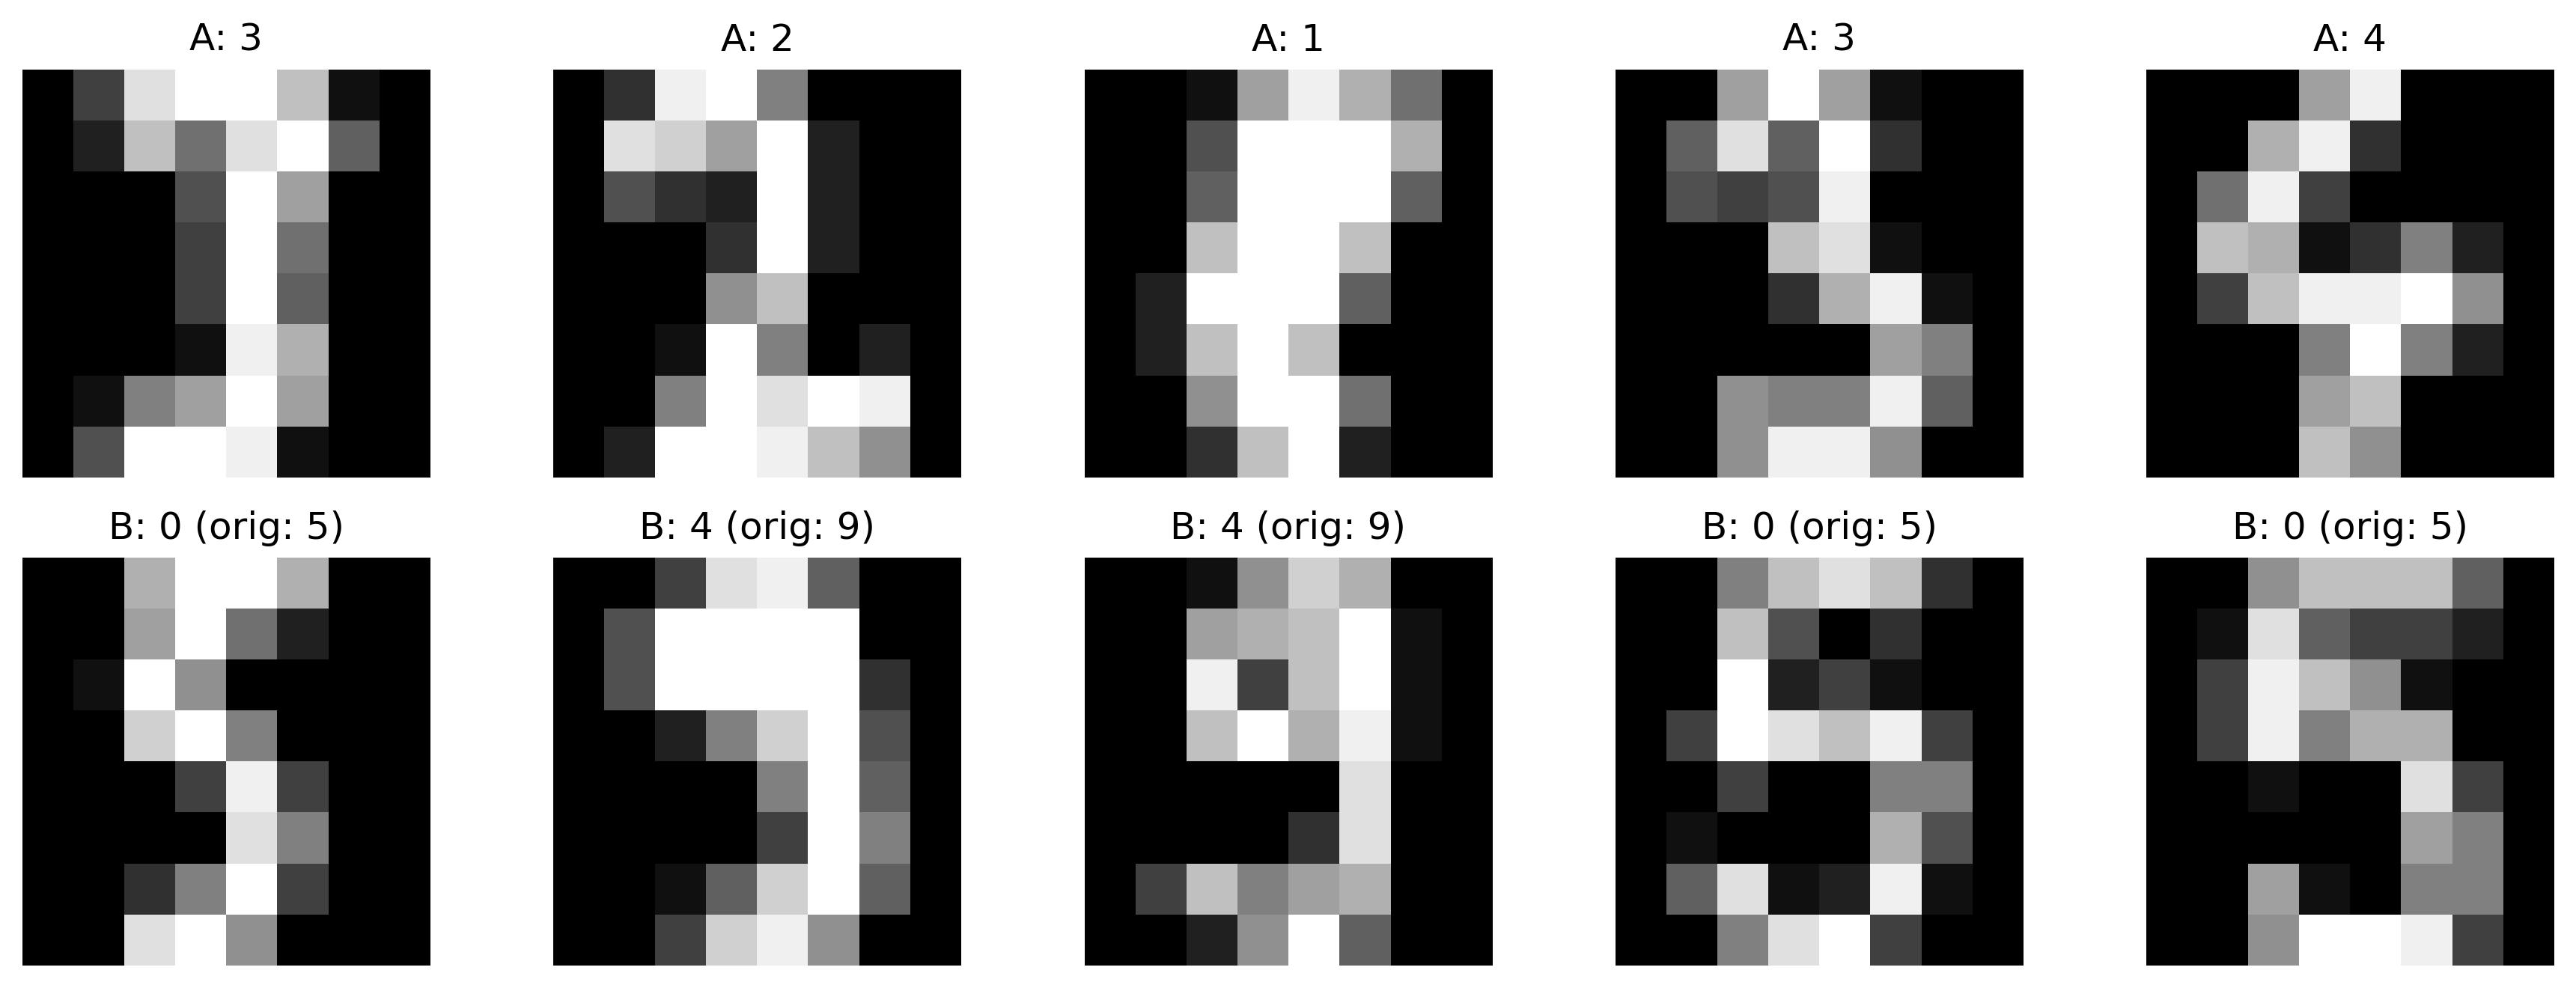

**Figura 9.20:** Muestras de los conjuntos de entrenamiento tras preprocesamiento y adecuación dimensional a los tensores PyTorch: Dominio A (dígitos 0 a 4, tarea de origen) y Dominio B (dígitos 5 a 9 reindexados a 0 a 4, tarea de destino).


In [20]:
# 1. División del dataset en dos dominios disjuntos
classes_A, classes_B = [0, 1, 2, 3, 4], [5, 6, 7, 8, 9]
mask_A, mask_B = np.isin(y, classes_A), np.isin(y, classes_B)

XA, yA = X[mask_A], y[mask_A]
XB, yB = X[mask_B], y[mask_B] - 5  # Reindexación de las etiquetas al intervalo [0, 4]

# División en entrenamiento y prueba para ambos dominios
XA_tr, XA_te, yA_tr, yA_te = train_test_split(
    XA, yA, test_size=0.25, random_state=42, stratify=yA
)
XB_tr, XB_te, yB_tr, yB_te = train_test_split(
    XB, yB, test_size=0.25, random_state=42, stratify=yB
)

# Simulación de escasez extrema en el dominio de destino: solo 20 muestras de entrenamiento
rng = np.random.default_rng(0)
idx_poucos = rng.choice(len(XB_tr), size=20, replace=False)
XB_tr_poucos, yB_tr_poucos = XB_tr[idx_poucos], yB_tr[idx_poucos]

# Función auxiliar para conversión a tensores PyTorch
def para_tensor(Ximg, yarr):
    return torch.tensor(Ximg).unsqueeze(1), torch.tensor(yarr, dtype=torch.long)

XA_tr_t, yA_tr_t = para_tensor(XA_tr, yA_tr)
XA_te_t, yA_te_t = para_tensor(XA_te, yA_te)
XB_tr_t, yB_tr_t = para_tensor(XB_tr_poucos, yB_tr_poucos)
XB_te_t, yB_te_t = para_tensor(XB_te, yB_te)

# Visualización de muestras de ambos dominios
n_amostras = 5
imgs_A = [img.squeeze().numpy() for img in XA_tr_t[:n_amostras]]
titles_A = [f"A: {label.item()}" for label in yA_tr_t[:n_amostras]]

imgs_B = [img.squeeze().numpy() for img in XB_tr_t[:n_amostras]]
titles_B = [f"B: {label.item()} (orig: {label.item()+5})" for label in yB_tr_t[:n_amostras]]

mm.show(
    imgs_A + imgs_B,
    titles=titles_A + titles_B,
    cols=n_amostras,
    figsize=(12, 4.5)
)

###### Bloque 2: Arquitectura Modular y Rutinas Genéricas

Para viabilizar la transferencia de aprendizaje, la arquitectura convolucional y el bucle de entrenamiento fueron refactorizados en relación con la clase `CNNDigitos` del proyecto anterior.

1. **Modularización de la Arquitectura (Diferencia respecto a `CNNDigitos`):**
   * En el proyecto anterior, la clase `CNNDigitos` declaraba todas las capas (`conv1`, `conv2`, `pool`, `fc1`, `fc2`) como miembros directos de una única clase monolítica.
   * Aquí, la arquitectura se separa en dos componentes: la clase `ExtratorConv` encapsula el bloque espacial convolucional ($2$ convoluciones $3 \times 3$, $2$ *Max-Poolings* $2 \times 2$ y el aplanamiento a $64$ elementos), mientras que la clase `CNNCompleta` instancia ese extractor en `self.extrator` y anexa la "cabeza" clasificadora (`fc1` y `fc2`).
   * Esta separación es lo que permite copiar el estado interno del extractor (`state_dict()`) de un modelo a otro de forma aislada.

2. **Ajuste en el Número de Clases de Salida:**
   Mientras que `CNNDigitos` en el proyecto anterior poseía $10$ *logits* en la capa de salida (`self.fc2 = nn.Linear(32, 10)`), la clase `CNNCompleta` recibe `n_classes=5` en el constructor para adecuarse a la división de los dominios $A$ y $B$.

3. **Flexibilización del Bucle de Entrenamiento (`treinar`):**
   * En el proyecto anterior, el bucle de entrenamiento iteraba directamente sobre los atributos globales del modelo (`modelo_cnn.parameters()`) y calculaba métricas específicas en línea.
   * La función `treinar` abstrae ese proceso e introduce el parámetro opcional `parametros`. Si se proporciona, el optimizador *Adam* actualiza **solo** los parámetros de esa lista, ignorando las capas cuyos gradientes fueron desactivados. Esta flexibilidad es crucial para ejecutar el entrenamiento con congelamiento parcial de la red.

4. **Aislamiento de la Evaluación (`calcular_acuracia`):**
   Así como se hizo en la fase de prueba del proyecto anterior, la función coloca el modelo en `eval()` y utiliza el contexto `torch.no_grad()` para desactivar el *autograd*, calculando la precisión mediante `.argmax(dim=1)`.

In [21]:
# Definición del bloque convolucional reutilizable (misma extracción del proyecto anterior)
class ExtratorConv(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        return x.view(x.size(0), -1)

# Arquitectura modular que combina el extractor y la cabeza clasificadora
class CNNCompleta(nn.Module):
    def __init__(self, n_classes=5):
        super().__init__()
        self.extrator = ExtratorConv()
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, n_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.extrator(x)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

# Rutina genérica de entrenamiento con optimización selectiva de parámetros
def treinar(modelo, X_t, y_t, epocas, lr, tam_lote=16, parametros=None):
    # Parámetros entrenables
    params = parametros if parametros is not None else modelo.parameters()  
    otim = optim.Adam(params, lr=lr)               # Optimizador Adam
    crit = nn.CrossEntropyLoss()                   # Función de pérdida
    n_amostras = X_t.size(0)                       # Número de muestras
    for _ in range(epocas):                        # Repite por época
        perm = torch.randperm(n_amostras)          # Mezcla muestras
        for i in range(0, n_amostras, tam_lote):   # Recorre mini-lotes
            idx = perm[i:i + tam_lote]             # Índices del lote
            otim.zero_grad()                       # Pon a cero gradientes
            perda = crit(modelo(X_t[idx]), y_t[idx])  # Calcula pérdida
            perda.backward()                       # Retropropagación
            otim.step()                            # Actualiza pesos

# Rutina de evaluación
def calcular_acuracia(modelo, X_t, y_t):
    modelo.eval()                                  # Modo evaluación
    with torch.no_grad():                          # Sin gradientes
        pred = modelo(X_t).argmax(dim=1)           # Clases predichas
    return (pred == y_t).float().mean().item()     # Devuelve precisión

###### Bloco 3: Preentrenamiento, Transferencia y Análisis Comparativo

Este bloque ejecuta la comparación entre el ajuste del modelo desde cero y la aplicación de la transferencia con congelamiento estático del extractor. Para dar total transparencia al experimento, los tamaños de los conjuntos de entrenamiento y prueba de ambos dominios se imprimen en el terminal.

1. **Cuantificación de las Muestras por Dominio:**
   * **Dominio A (origen, dígitos $0$ a $4$):** Cuenta con $675$ muestras de entrenamiento ($75\%$) y $226$ de prueba ($25\%$), proporcionando datos abundantes para que el `modelo_origem` aprenda el extractor convolucional hasta alcanzar $100\%$ de precisión.
   * **Dominio B (destino, dígitos $5$ a $9$):** Posee $224$ muestras de prueba en total, pero su conjunto de entrenamiento se reduce intencionalmente de $672$ a solo **$20$ muestras** (`XB_tr_poucos`), creando un escenario severo de escasez de datos.

2. **Etapa 1: Preentrenamiento en el Dominio A (Origen):**
   El `modelo_origem` se entrena desde cero sobre las $675$ muestras de los dígitos $0$ a $4$. Durante $40$ épocas, el extractor convolucional ajusta sus filtros para identificar los rasgos característicos de esos cinco primeros dígitos, alcanzando $100\%$ de precisión en el conjunto de prueba ($226$ muestras).

3. **Etapa 2: Transferencia de Pesos y Congelamiento:**  
   * Se crea el `modelo_transferencia` para resolver la tarea del Dominio B (dígitos $5$ a $9$).
   * Los pesos aprendidos en el Dominio A se copian mediante:
  
     - `load_state_dict(modelo_origem.extrator.state_dict())`
  
   * **Congelamiento:** El bucle `for p in modelo_transferencia.extrator.parameters(): p.requires_grad = False` desactiva el cálculo de gradientes en las capas convolucionales.
   * **Entrenamiento Selectivo:** La llamada `treinar(...)` pasa estrictamente los parámetros de las capas densas (`params_cabeca`), ajustando la cabeza de clasificación con solo las $20$ muestras de entrenamiento.

4. **Etapa 3: Entrenamiento desde Cero en el Dominio B (Control Experimental):**
   El `modelo_do_zero` posee la misma arquitectura, pero se entrena desde cero sobre las mismas $20$ muestras del Dominio B, sin ningún reaprovechamiento de pesos, durante las mismas $40$ épocas.

5. **Análisis de los Resultados ([Figura 9.21](#fig-09-transfer-learning)):**
   * **Con Transferencia Congelada ($72,77\%$):** Al reaprovechar el extractor entrenado en el Dominio A y congelar sus parámetros, la red alcanza $72,77\%$ de precisión en la prueba ($224$ muestras) ajustando solo las capas densas.
   * **Entrenado desde Cero ($76,79\%$):** El entrenamiento desde cero supera a la transferencia congelada en el conjunto de prueba del Dominio B.
   * **Causa de la Diferencia:** Por tratarse de un modelo minúsculo (solo $16$ filtros convolucionales en matrices de $8 \times 8$), el extractor entrenado en el Dominio A se volvió **hiperespecializado** en las formas geométricas de los dígitos $0$ a $4$. Al congelar rígidamente esos pocos filtros, el modelo de destino quedó limitado a detectores inadecuados para $5$ a $9$. La red entrenada desde cero, incluso con solo $20$ muestras, logró adaptar sus $16$ filtros directamente a los rasgos del Dominio B.

=== Detalhamento do Tamanho das Bases ===
Domínio A (0-4) — Treino: 675 amostras | Teste: 226 amostras
Domínio B (5-9) — Treino completo: 672 | Treino reduzido: 20 | Teste: 224 amostras



Acurácia no domínio de origem A (dígitos 0-4, 226 testes): 1.0000


Domínio de destino B (dígitos 5-9), apenas 20  exemplos de treino (224 testes):
  Com transferência (extrator congelado): 0.7277
  Treinando do zero (mesmos dados/épocas): 0.7679


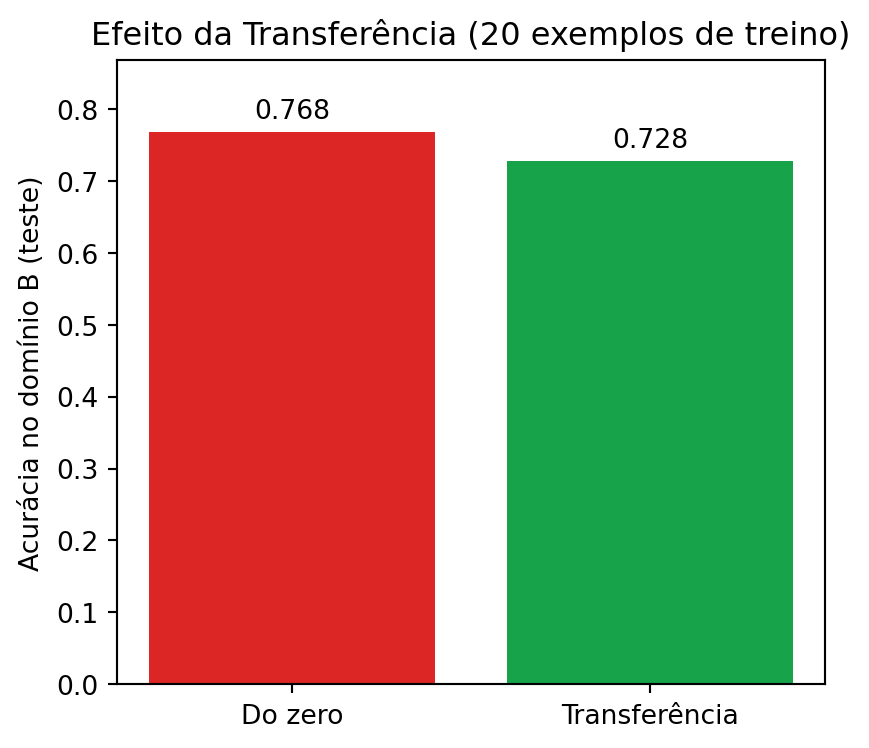

**Figura 9.21:** Comparação de acurácia no conjunto de teste do Domínio B (dígitos 5 a 9) sob restrição de dados (20 exemplos de treino): demonstração do impacto do congelamento rígido e da transferência negativa em redes de baixa capacidade.


In [22]:
# Fixar semente para reprodutibilidade
torch.manual_seed(42)

# Exibição do tamanho dos grupos de treino e teste
print("=== Detalhamento do Tamanho das Bases ===")
print(f"Domínio A (0-4) — Treino: {len(XA_tr_t)} amostras | Teste: {len(XA_te_t)} amostras")
print(f"Domínio B (5-9) — Treino completo: {len(XB_tr)} | Treino reduzido: {len(XB_tr_poucos)}",
      f"| Teste: {len(XB_te_t)} amostras\n")

# 1. Pré-treinamento na tarefa de origem (Domínio A: dígitos 0-4)
modelo_origem = CNNCompleta(n_classes=5)                       # Cria CNN

#######
treinar(modelo_origem, XA_tr_t, yA_tr_t, epocas=40, lr=1e-2)   # Treina modelo
         
acc_A = calcular_acuracia(modelo_origem, XA_te_t, yA_te_t)     # Mede acurácia
                          
print(f"Acurácia no domínio de origem A "                      # Exibe resultado
      f"(dígitos 0-4, {len(XA_te_t)} testes): " f"{acc_A:.4f}")

# 2. Transferência de Aprendizado (Extrator Congelado)
modelo_transferencia = CNNCompleta(n_classes=5)        # Cria CNN
modelo_transferencia.extrator.load_state_dict(         # Copia extrator
    modelo_origem.extrator.state_dict())

for p in modelo_transferencia.extrator.parameters():   # Percorre extrator
    p.requires_grad = False                            # Congela pesos

params_cabeca = list(modelo_transferencia.fc1.parameters())  # FC1
params_cabeca += list(modelo_transferencia.fc2.parameters()) # +FC2

#######
treinar(modelo_transferencia, XB_tr_t, yB_tr_t,              # Treina cabeça
         epocas=40, lr=1e-2, parametros=params_cabeca)

acc_transferencia = calcular_acuracia(modelo_transferencia, XB_te_t, yB_te_t) # Mede acurácia

# 3. Treinamento do Zero no Domínio B
modelo_do_zero = CNNCompleta(n_classes=5)                     # Cria CNN

#######
treinar(modelo_do_zero, XB_tr_t, yB_tr_t, epocas=40, lr=1e-2) # Treina modelo
         
acc_do_zero = calcular_acuracia(modelo_do_zero,  XB_te_t, yB_te_t) # Mede acurácia
                               

print(f"Domínio de destino B (dígitos 5-9), apenas {len(XB_tr_poucos)} ", 
      f"exemplos de treino ({len(XB_te_t)} testes):")
print(f"  Com transferência (extrator congelado): {acc_transferencia:.4f}")
print(f"  Treinando do zero (mesmos dados/épocas): {acc_do_zero:.4f}")

# Visualização comparativa
plt.figure(figsize=(4.5, 4))
plt.bar(["Do zero", "Transferência"], [acc_do_zero, acc_transferencia], 
        color=["#dc2626", "#16a34a"])
plt.ylim(0, max([acc_do_zero, acc_transferencia]) + 0.1)
plt.ylabel("Acurácia no domínio B (teste)")
plt.title(f"Efeito da Transferência ({len(XB_tr_poucos)} exemplos de treino)")

for i, v in enumerate([acc_do_zero, acc_transferencia]):
    plt.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

###### Bloco 4: Visualización del Flujo de Activaciones con `mm.showNet`

Para confirmar que la extracción de características reutilizada preserva las transformaciones dimensionales estudiadas en el proyecto anterior, se utiliza nuevamente la función `mm.showNet` de la biblioteca `morph`. La [Figura 9.22](#fig-09-transfer-shownet) muestra el flujo de activaciones del `modelo_transferencia` al procesar una muestra del Dominio B (dígito $7$, reindexado a la clase $2$).

1. **Preservación del Flujo Convolucional:** Dado que la arquitectura `ExtratorConv` replica las mismas capas de convolución y *pooling* de la `CNNDigitos` del proyecto anterior, las dimensiones de los *tensores* intermedios se mantienen en $(1, 8, 4, 4)$ en el primer bloque.
2. **Inspección de la Cabeza Adaptada:** La diferencia respecto al proyecto anterior surge en la capa de salida (`fc2`): mientras que el modelo del proyecto anterior proyectaba el vector intermedio en $10$ *logits* (clases de $0$ a $9$), el modelo de transferencia proyecta el vector en $5$ *logits* (clases de $0$ a $4$), capturando las probabilidades relativas del Dominio B.

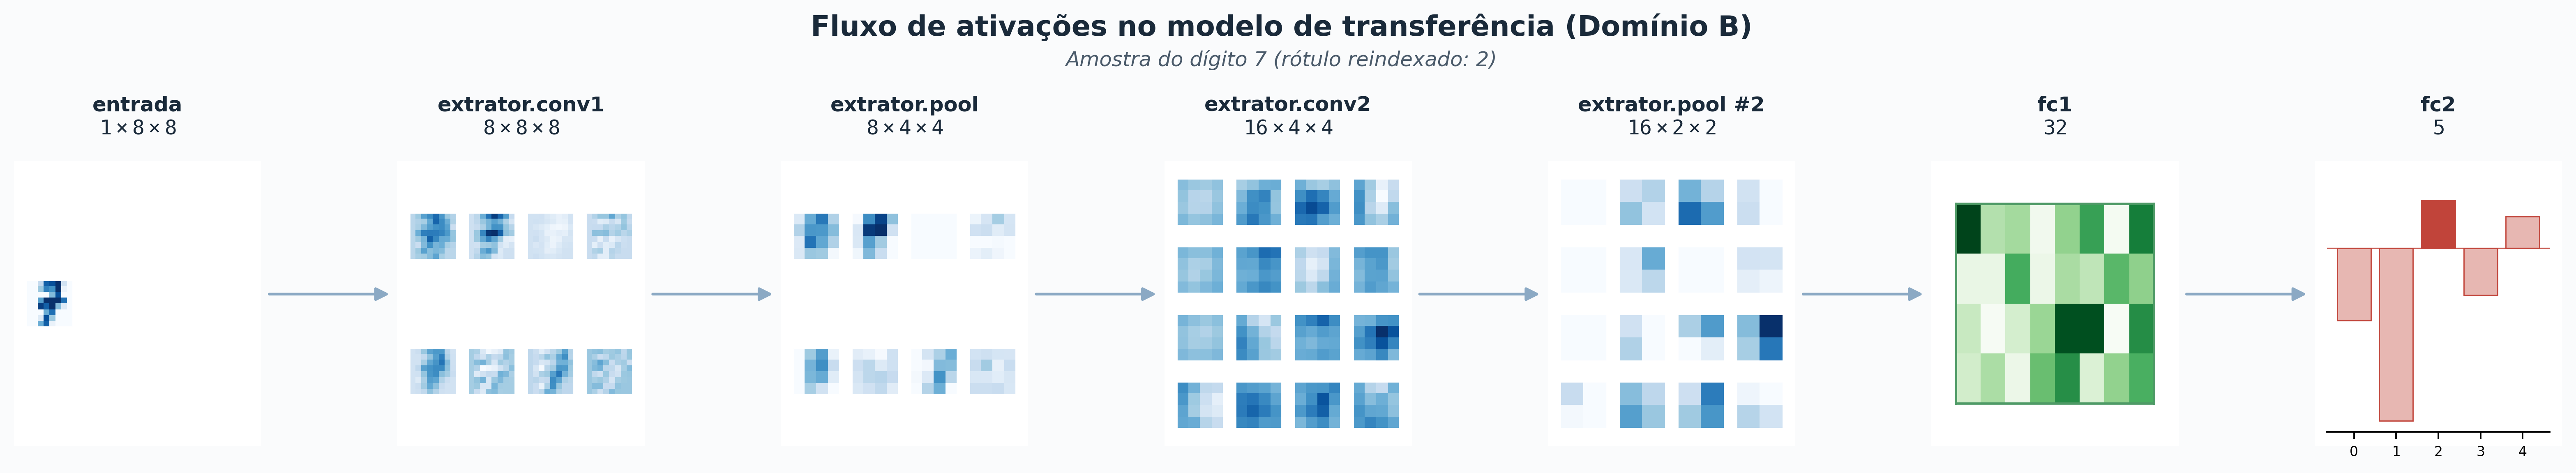

**Figura 9.22:** Flujo de activaciones y transformaciones dimensionales de los tensores en el modelo de transferencia de aprendizaje al procesar una muestra de prueba del Dominio B (dígito 7, reindexado a clase 2).


Capas capturadas en el modelo de transferencia:
 ['extrator.conv1', 'extrator.pool', 'extrator.conv2', 'extrator.pool #2', 'fc1', 'fc2']


In [23]:
# Selecciona la primera muestra de prueba del Dominio B
x_amostra_B = XB_te_t[0:1]  # Tensor de dimensión (1, 1, 8, 8)
classe_verdadeira = yB_te_t[0].item()
classe_original = classe_verdadeira + 5

# Inspección del flujo de activaciones en el modelo de transferencia
acts_transfer = mm.showNet(
    modelo_transferencia,
    x_amostra_B,
    titulo="Fluxo de ativações no modelo de transferência (Domínio B)",
    subtitulo=f"Amostra do dígito {classe_original} (rótulo reindexado: {classe_verdadeira})",
)

print("Capas capturadas en el modelo de transferencia:\n", list(acts_transfer.keys()))

###### Análisis del Experimento 1

El modelo entrenado desde cero alcanza una exactitud superior al modelo con transferencia de aprendizaje y extractor congelado. Este resultado caracteriza un caso de **transferencia negativa** (*negative transfer*) y se debe a tres factores:

1. **Baja capacidad:** El extractor posee únicamente $16$ filtros $3 \times 3$, insuficientes para aprender representaciones generalizables.

2. **Especialización en el dominio:** El entrenamiento con los dígitos $0$ a $4$ produce filtros poco discriminativos para los dígitos $5$ a $9$.

3. **Ausencia de adaptación:** El congelamiento impide que el extractor ajuste sus filtros a la nueva tarea.

> ### 📝 Nota
>
> ###### 💡 Provocación Pedagógica
>
> Este experimento utiliza un extractor pequeño entrenado en un dominio restringido. ¿El resultado sería diferente si el extractor hubiera aprendido sus representaciones en una base con millones de imágenes y gran diversidad de objetos?

##### Experimento 2 — Cuando la Transferencia Realmente Funciona (*ResNet-18* Preentrenada)

El segundo experimento repite la misma estructura del primero — pocos ejemplos de entrenamiento, dos clases, comparación entre estrategias —, pero cambia el extractor artesanal de $16$ filtros por la **_ResNet-18_**, una arquitectura de $18$ capas preentrenada en *ImageNet* ($1,4$ millones de imágenes, $1.000$ categorías), y el *dataset* sintético de dígitos por fotografías reales del **Oxford-IIIT Pet Dataset** (PARKHI, 2012).

La tarea: distinguir dos razas caninas — **Pug** y **Boxer** — a partir de solo $15$ fotografías de entrenamiento por clase.

> ### 💡 Dica
>
> ###### 🐶 ¿Por qué este escenario?
> El desafío aquí no es la similitud visual entre las razas — Pug y Boxer tienen portes y proporciones bien distintas —, sino la escasez de datos: apenas $30$ fotografías reales en total, sin ninguna imagen sintética. Es el tipo de problema de bajo presupuesto de datos que motiva, en la práctica, el uso de redes preentrenadas: no hay tiempo ni recursos para fotografiar y etiquetar miles de perros antes de entrenar un clasificador desde cero.

###### Bloco 1: Carga del *Dataset* Real y Muestreo Disperso

1. **Fuente:** el *Oxford-IIIT Pet Dataset* (PARKHI, 2012) se carga a través de `torchvision.datasets.OxfordIIITPet`, que descarga automáticamente las $7.349$ fotografías y sus etiquetas de raza en la primera ejecución.
2. **Filtrado:** solo se mantienen las dos razas de interés (`Pug`, `Boxer`).
3. **Escasez deliberada:** solo se sortean $15$ fotografías de entrenamiento por clase ($30$ en total) — el resto compone el conjunto de prueba, utilizado exclusivamente para evaluación.

La [Figura 9.23](#fig-09-pets-amostras) muestra muestras de entrenamiento de cada raza.

In [24]:
import random

RACAS_ALVO = ["Pug", "Boxer"]
N_TREINO_POR_CLASSE = 15
N_TESTE_POR_CLASSE = 20

# 1. Descarga del dataset completo (37 razas) — licencia CC BY-SA 4.0
pets_completo = OxfordIIITPet(
    root="dados_pets", split="trainval", target_types="category", download=True
)
nomes_racas = pets_completo.classes
indices_alvo = [nomes_racas.index(r) for r in RACAS_ALVO]

# 2. Filtrado de las dos razas de interés, separadas por clase
por_classe = {idx: [] for idx in indices_alvo}
for img, lbl in pets_completo:
    if lbl in indices_alvo:
        por_classe[lbl].append(img)

# 3. Muestreo: pocas imágenes de entrenamiento, más imágenes de prueba
rng = random.Random(42)
imgs_treino, y_treino, imgs_teste, y_teste = [], [], [], []
for classe_idx, idx_original in enumerate(indices_alvo):
    imgs_raca = por_classe[idx_original][:]
    rng.shuffle(imgs_raca)
    imgs_treino += imgs_raca[:N_TREINO_POR_CLASSE]
    y_treino += [classe_idx] * N_TREINO_POR_CLASSE
    imgs_teste += imgs_raca[N_TREINO_POR_CLASSE : N_TREINO_POR_CLASSE + N_TESTE_POR_CLASSE]
    y_teste += [classe_idx] * N_TESTE_POR_CLASSE

print(f"Entrenamiento: {len(imgs_treino)} imágenes | Prueba: {len(imgs_teste)} imágenes")

amostras_pil = imgs_treino[:4] + imgs_treino[N_TREINO_POR_CLASSE:N_TREINO_POR_CLASSE + 4]
amostras_exibicao = [np.array(img.convert("RGB")) for img in amostras_pil]  # PIL -> ndarray
titulos_exibicao = [RACAS_ALVO[0]] * 4 + [RACAS_ALVO[1]] * 4
mm.show(amostras_exibicao, titles=titulos_exibicao, cols=4, figsize=(11, 6))

**Figura 9.23:** Muestras reales de entrenamiento del *Oxford-IIIT Pet Dataset* (Parkhi et al., 2012, licencia CC BY-SA 4.0): *Pug* y *Boxer*, razas elegidas para simular un escenario real de escasez de datos.


###### Bloco 2: Tres Estrategias sobre la Misma Arquitectura

Para aislar el efecto de la transferencia de aprendizaje, las tres estrategias reutilizan **exactamente la misma arquitectura** (*ResNet-18*), variando únicamente el origen de los pesos y qué parámetros permanecen entrenables:

1. **`do_zero`:** pesos aleatorios (`weights=None`) — equivalente a entrenar la arquitectura de la *ResNet-18* enteramente desde cero, como en el Bloque 2 del Experimento 1.
2. **`congelado`:** pesos preentrenados en *ImageNet*, con `requires_grad = False` en todas las capas convolucionales — solo la nueva capa final se entrena.
3. **`fine_tuning`:** pesos preentrenados en *ImageNet* como punto de partida, pero **sin** congelamiento — toda la red se ajusta al nuevo dominio, con una tasa de aprendizaje baja para no destruir el conocimiento previo.

En todos los casos, la capa final `fc` se reemplaza por `nn.Linear(fc.in_features, 2)`, correspondiente a las dos razas de destino.

In [25]:
transformacao_resnet = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def prepara_tensores(imgs, labels):
    X = torch.stack([transformacao_resnet(img.convert("RGB")) for img in imgs])
    y = torch.tensor(labels, dtype=torch.long)
    return X, y

X_tr, y_tr = prepara_tensores(imgs_treino, y_treino)
X_te, y_te = prepara_tensores(imgs_teste, y_teste)

def cria_modelo_pets(estrategia):
    pesos = None if estrategia == "do_zero" else models.ResNet18_Weights.DEFAULT
    modelo = models.resnet18(weights=pesos)
    if estrategia == "congelado":
        for p in modelo.parameters():
            p.requires_grad = False
    modelo.fc = nn.Linear(modelo.fc.in_features, len(RACAS_ALVO))
    return modelo

modelo_do_zero = cria_modelo_pets("do_zero")
modelo_congelado = cria_modelo_pets("congelado")
modelo_fine_tuning = cria_modelo_pets("fine_tuning")

###### Bloque 3: Entrenamiento Comparativo y Análisis de Precisión

Reutilizando las funciones genéricas `treinar` y `calcular_acuracia`, definidas en el Bloque 2 del Experimento 1, los tres modelos se entrenan sobre el mismo conjunto de $30$ fotografías y se evalúan en el conjunto de prueba (imágenes nunca vistas durante el entrenamiento):

* El modelo `do_zero` tiende a **sobreajustarse** rápidamente a las $30$ fotografías de entrenamiento, sin generalizar al conjunto de prueba — $30$ ejemplos son drásticamente insuficientes para ajustar los $11$ millones de parámetros de la *ResNet-18* desde cero.
* El modelo `congelado` ya debería alcanzar una precisión considerablemente superior, ya que reutiliza, sin ningún ajuste, características visuales genéricas (bordes, texturas, contornos) aprendidas en *ImageNet* — solo la nueva capa lineal necesita ajustarse a las $30$ fotografías.
* El modelo `fine_tuning` tiende a igualar o superar al extractor congelado, ya que parte del mismo conocimiento previo, pero aún permite un ajuste fino de toda la red a las particularidades visuales de las razas.

La [Figura 9.24](#fig-09-pets-comparativo) resume los tres resultados.

In [26]:
torch.manual_seed(42)

configuracoes = [
    ("Do zero",              modelo_do_zero,      None, 2e-3),
    ("Extrator congelado",   modelo_congelado,    "fc", 1e-3),
    ("Fine-tuning completo", modelo_fine_tuning,  None, 1e-4),
]

resultados_pets = {}
for nome, modelo, alvo_params, taxa in configuracoes:
    parametros = modelo.fc.parameters() if alvo_params == "fc" else None
    treinar(modelo, X_tr, y_tr, epocas=15, lr=taxa, tam_lote=8, parametros=parametros)
    resultados_pets[nome] = calcular_acuracia(modelo, X_te, y_te)
    print(f"{nome}: {resultados_pets[nome]*100:.1f}%")

plt.figure(figsize=(5.5, 4))
cores = ["#dc2626", "#f59e0b", "#16a34a"]
plt.bar(resultados_pets.keys(), resultados_pets.values(), color=cores)
plt.ylim(0, 1.05)
plt.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chute aleatório (50%)")
plt.ylabel("Acurácia no teste")
plt.title("Pug vs. Boxer — 15 fotos de treino/classe")
for i, v in enumerate(resultados_pets.values()):
    plt.text(i, v + 0.02, f"{v*100:.1f}%", ha="center")
plt.xticks(rotation=10)
plt.legend()
plt.tight_layout()
plt.show()

**Figura 9.24:** Comparación de exactitud en el conjunto de prueba real (*Pug* vs. *Boxer*, 15 fotografías de entrenamiento por clase): desde cero, extractor congelado y *fine-tuning* completo, todos sobre la misma arquitectura ResNet-18.


###### Bloque 4: Inspección Cualitativa de las Predicciones

Como en el Experimento 1 y en la sección siguiente sobre diagnóstico foliar, es instructivo observar individualmente algunas predicciones del mejor modelo (típicamente `fine_tuning` o `congelado`) sobre fotografías reales de prueba, comparando la etiqueta prevista con la raza real.

In [27]:
melhor_modelo = modelo_fine_tuning  # o modelo_congelado, según el resultado del Bloque 3
melhor_modelo.eval()

idx_amostras = list(range(4)) + list(range(N_TESTE_POR_CLASSE, N_TESTE_POR_CLASSE + 4))

imgs_pred, titulos_pred = [], []
with torch.no_grad():
    for idx in idx_amostras:
        entrada = X_te[idx].unsqueeze(0)
        pred_idx = melhor_modelo(entrada).argmax(dim=1).item()
        real_idx = y_te[idx].item()
        marcador = "✓" if pred_idx == real_idx else "✗"
        imgs_pred.append(np.array(imgs_teste[idx].convert("RGB")))  # PIL -> ndarray
        titulos_pred.append(f"{marcador} previsto: {RACAS_ALVO[pred_idx]}\n"
                             f"real: {RACAS_ALVO[real_idx]}")

mm.show(imgs_pred, titles=titulos_pred, cols=4, figsize=(12, 7))

**Figura 9.25:** Predicciones del modelo con extractor preentrenado (ResNet-18) en fotografías reales de prueba: etiqueta prevista vs. raza real, cuatro muestras de cada clase.


In [28]:
 
# Limpieza explícita de los datos descargados y liberación de memoria
if FLAG_LIMPAR_DADOS:
    if os.path.exists('./dados_pets'):
        shutil.rmtree('./dados_pets')
        print('🧹 Directorio de datos temporales ./dados_pets eliminado con éxito.')

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

##### Experimento 3 — Diagnóstico Fitosanitario con Transferencia de Aprendizaje

El experimento anterior mostró que una *ResNet-18* preentrenada en **ImageNet** puede adaptarse a una nueva tarea utilizando pocas muestras. Ahora, la misma estrategia se aplica a un problema de diagnóstico fitosanitario. La *ResNet-18* debe clasificar imágenes de hojas en tres categorías: `["folha_saudavel", "folha_doente", "sintoma_desconhecido"]`.

- **`folha_saudavel`:** hoja sin lesiones visibles.
- **`folha_doente`:** hoja con manchas oscuras que simulan una enfermedad fúngica.
- **`sintoma_desconhecido`:** hoja con clorosis amarillenta, que representa un patrón diferente de la enfermedad conocida.

> ### 💡 Dica
>
> ###### 🌱 ¿Por qué este escenario?
>
> El diagnóstico fitosanitario constituye una importante aplicación de la VC en la agricultura de precisión. Un modelo preentrenado en **ImageNet** puede reutilizar características como bordes, texturas y patrones de color para aprender esta nueva tarea con pocas imágenes.

###### Bloque 1: Generación del *Dataset* Sintético

Este bloque genera un conjunto sintético con **30** imágenes por clase para entrenamiento y **8** para validación, totalizando **90** y **24** imágenes, respectivamente.

1. **Generación de la hoja:** La función `desenha_folha_base` crea el contorno de la hoja, variando tamaño, orientación y tonalidad de verde.

2. **Simulación de la enfermedad:** La función `aplica_manchas_doenca` añade manchas oscuras irregulares que simulan lesiones fúngicas.

3. **Simulación de otro síntoma:** La función `aplica_sintoma_desconhecido` añade regiones amarillentas que representan un patrón distinto de la enfermedad conocida.

4. **Visualización de las muestras:** La [Figura 9.26](#fig-09-folhas-amostras) presenta ejemplos de las tres categorías del conjunto sintético.

Entrenamiento: 90 imágenes (30 por clase) | Validación: 24 imágenes (8 por clase)


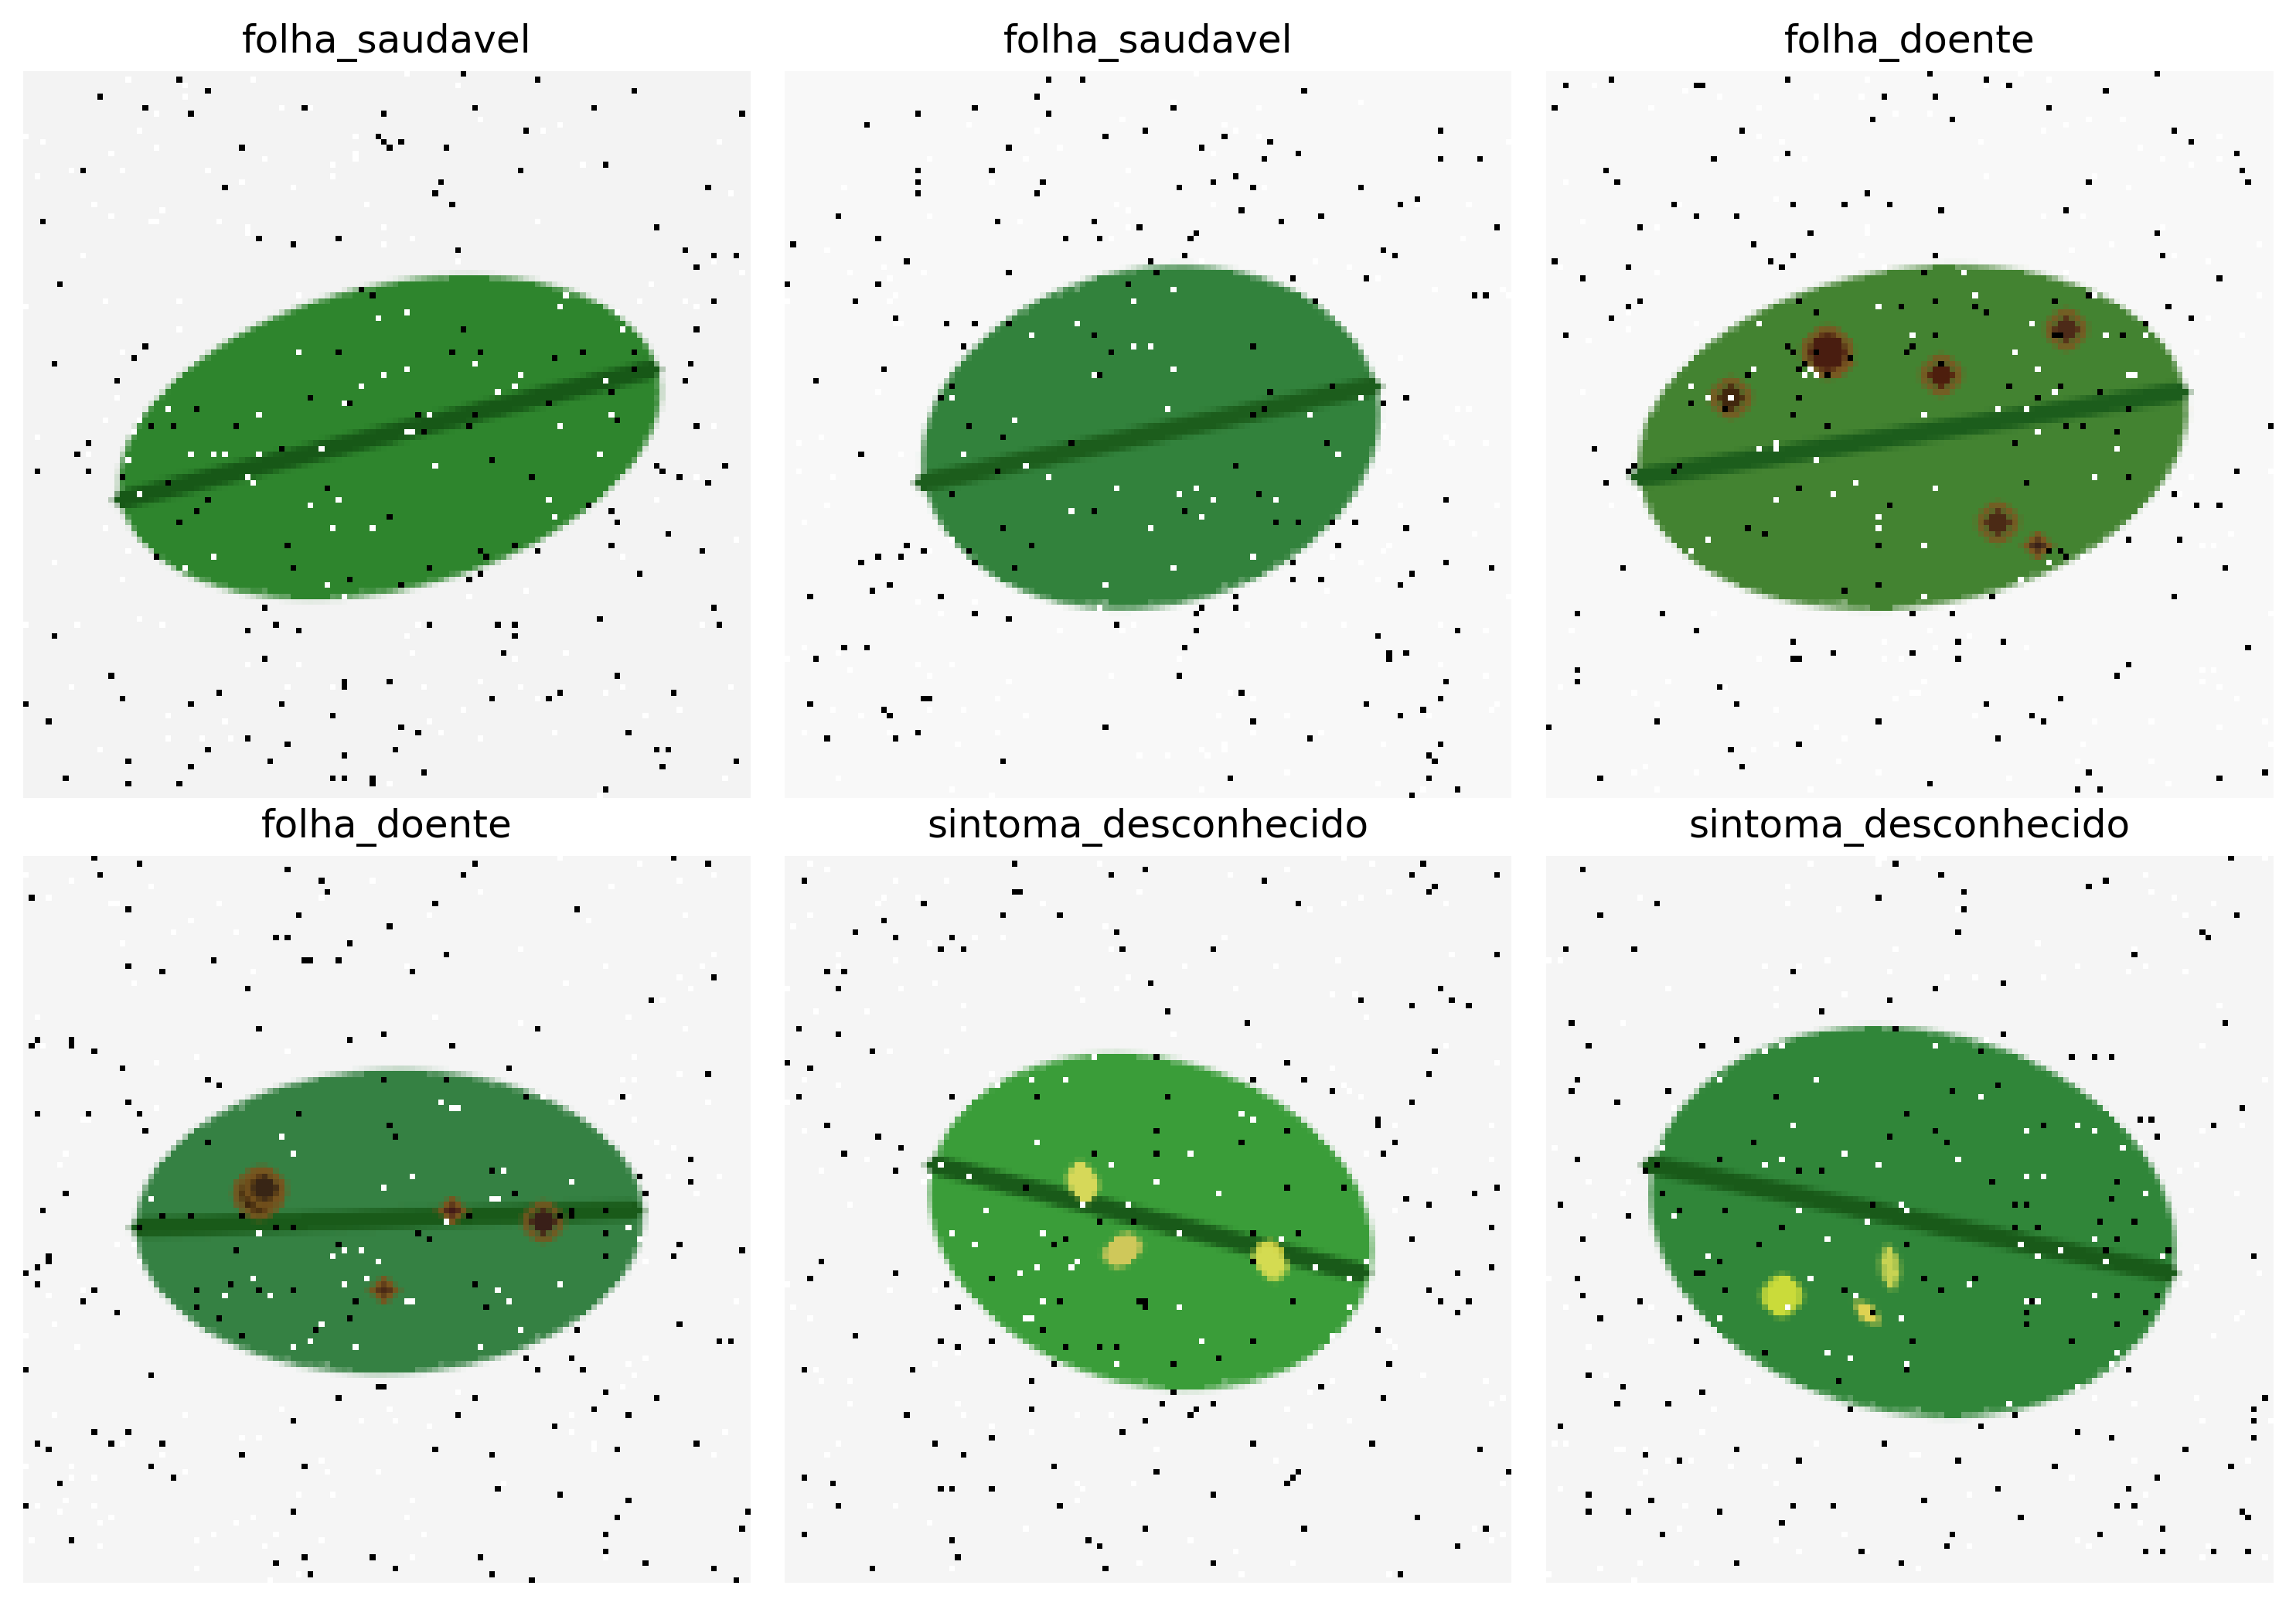

**Figura 9.26:** Muestras sintéticas del *dataset* de diagnóstico foliar: hoja sana, hoja enferma (manchas oscuras) y síntoma desconocido (clorosis amarillenta) con ruido sal y pimienta.


In [29]:
CLASSES_FOLHA = ["folha_saudavel", "folha_doente", "sintoma_desconhecido"]


def desenha_folha_base(tam_img, rng):
    '''Dibuja el contorno oval de una hoja verde con nervadura central,
    con pequeñas variaciones de tono, tamaño y orientación entre muestras.'''
    img = np.full((tam_img, tam_img, 3), 245, dtype=np.uint8)  # fondo claro
    cx, cy = tam_img // 2, tam_img // 2
    eixo_a = rng.randint(int(tam_img * 0.30), int(tam_img * 0.38))
    eixo_b = rng.randint(int(tam_img * 0.20), int(tam_img * 0.26))
    angulo = rng.uniform(-15, 15)
    verde = (rng.randint(40, 70), rng.randint(120, 160), rng.randint(40, 70))
    cv2.ellipse(img, (cx, cy), (eixo_a, eixo_b), angulo, 0, 360, verde, -1, cv2.LINE_AA)
    ang_rad = np.deg2rad(angulo)
    dx, dy = np.cos(ang_rad), np.sin(ang_rad)
    p1 = (int(cx - eixo_a * dx), int(cy - eixo_a * dy))
    p2 = (int(cx + eixo_a * dx), int(cy + eixo_a * dy))
    cv2.line(img, p1, p2, (25, 90, 25), 2, cv2.LINE_AA)  # nervadura central
    return img, (cx, cy, eixo_a, eixo_b, angulo)


def aplica_manchas_doenca(img, centro_folha, rng, n_manchas=(4, 8)):
    '''Simula lesiones foliares: manchas oscuras de bordes irregulares
    (patrón típico de enfermedades fúngicas).'''
    cx, cy, eixo_a, eixo_b, _ = centro_folha
    for _ in range(rng.randint(*n_manchas)):
        raio = rng.randint(1, 3)
        px = cx + rng.randint(-int(eixo_a * 0.7), int(eixo_a * 0.7))
        py = cy + rng.randint(-int(eixo_b * 0.7), int(eixo_b * 0.7))
        cor_mancha = (rng.randint(50, 90), rng.randint(25, 45), rng.randint(10, 25))
        cv2.circle(img, (px, py), raio, cor_mancha, -1, cv2.LINE_AA)
        cv2.circle(img, (px, py), raio + 1, (120, 85, 30), 1, cv2.LINE_AA)  # halo
    return img


def aplica_sintoma_desconhecido(img, centro_folha, rng):
    '''Simula un patrón distintivo (moteado amarillento/clorosis), diferente
    de las manchas oscuras de la enfermedad conocida.'''
    cx, cy, eixo_a, eixo_b, _ = centro_folha
    for _ in range(rng.randint(3, 5)):
        eixo_m = (rng.randint(1, 3), rng.randint(2, 3))
        px = cx + rng.randint(-int(eixo_a * 0.6), int(eixo_a * 0.6))
        py = cy + rng.randint(-int(eixo_b * 0.6), int(eixo_b * 0.6))
        cor_clorose = (rng.randint(200, 235), rng.randint(195, 225), rng.randint(50, 90))
        ang_m = rng.uniform(0, 180)
        cv2.ellipse(img, (px, py), eixo_m, ang_m, 0, 360, cor_clorose, -1, cv2.LINE_AA)
    return img


def aplica_ruido_sal_pimenta(img, prop_ruido=0.02, rng=None):
    '''Aplica ruido sal (puntos blancos) y pimienta (puntos negros) aleatorios.
    prop_ruido: fracción de píxeles alterados (ej: 0.02 = 2% de los píxeles).'''
    if prop_ruido <= 0:
        return img
    
    img_ruido = img.copy()
    num_pixels = int(prop_ruido * img.shape[0] * img.shape[1])
    n_sal = num_pixels // 2
    n_pimenta = num_pixels - n_sal

    # Aplica Sal (Blanco - [255, 255, 255])
    for _ in range(n_sal):
        y = rng.randint(0, img.shape[0] - 1)
        x = rng.randint(0, img.shape[1] - 1)
        img_ruido[y, x] = [255, 255, 255]

    # Aplica Pimienta (Negro - [0, 0, 0])
    for _ in range(n_pimenta):
        y = rng.randint(0, img.shape[0] - 1)
        x = rng.randint(0, img.shape[1] - 1)
        img_ruido[y, x] = [0, 0, 0]

    return img_ruido


def gera_folha(classe_idx, tam_img=128, rng=None, prop_ruido=0.02):
    rng = rng or random.Random()
    img, geometria = desenha_folha_base(tam_img, rng)
    nome = CLASSES_FOLHA[classe_idx]
    
    if nome == "folha_doente":
        img = aplica_manchas_doenca(img, geometria, rng)
    elif nome == "sintoma_desconhecido":
        img = aplica_sintoma_desconhecido(img, geometria, rng)
        
    ruido_exp = rng.randint(-3, 3)  # leve variación de exposición
    img = np.clip(img.astype(np.int16) + ruido_exp, 0, 255).astype(np.uint8)
    
    # Aplicación del ruido Sal y Pimienta
    img = aplica_ruido_sal_pimenta(img, prop_ruido=prop_ruido, rng=rng)
    
    return img


def gera_conjunto(n_por_classe, tam_img=128, seed=0, prop_ruido=0.02):
    rng = random.Random(seed)
    imgs, labels = [], []
    for classe_idx in range(len(CLASSES_FOLHA)):
        for _ in range(n_por_classe):
          imgs.append(gera_folha(classe_idx, tam_img=tam_img, rng=rng, prop_ruido=prop_ruido))
          labels.append(classe_idx)
    return imgs, labels


N_POR_CLASSE_TREINO, N_POR_CLASSE_VAL = 30, 8

imgs_treino, labels_treino = gera_conjunto(n_por_classe=N_POR_CLASSE_TREINO, seed=42, 
                                           prop_ruido=0.02)
imgs_val, labels_val = gera_conjunto(n_por_classe=N_POR_CLASSE_VAL, seed=123, prop_ruido=0.02)

print(f"Entrenamiento: {len(imgs_treino)} imágenes ({N_POR_CLASSE_TREINO} por clase) | "
      f"Validación: {len(imgs_val)} imágenes ({N_POR_CLASSE_VAL} por clase)")

# Visualización de 2 muestras de cada clase (6 imágenes en total)
amostras_exibir, titulos_exibir = [], []
for classe_idx, nome in enumerate(CLASSES_FOLHA):
    for k in range(2):
        idx = classe_idx * N_POR_CLASSE_TREINO + k
        amostras_exibir.append(imgs_treino[idx])
        titulos_exibir.append(nome)

mm.show(amostras_exibir, titles=titulos_exibir, cols=3, figsize=(10, 7))

> ### 📝 Nota
>
> ###### 🧠 Trampa Común
>
> La transferencia de aprendizaje exige que cada clase presente patrones visuales distintos. Repetir la misma imagen con etiquetas diferentes impide que la capa clasificadora aprenda una frontera de decisión, pues el extractor genera prácticamente las mismas características para todas las muestras.
>
> En este experimento, cada imagen se genera de forma independiente, con patrones visuales compatibles con su clase (hoja sana, lesiones fúngicas o clorosis), proporcionando información suficiente para el entrenamiento de la capa clasificadora.

###### Bloque 2: Preparación de los Tensores y Adaptación de la Arquitectura

Modelos como la *ResNet-18* requieren imágenes en color de $224 \times 224$ *píxeles* normalizadas según las estadísticas de *ImageNet* ($\mu = [0,485; 0,456; 0,406]$ y $\sigma = [0,229; 0,224; 0,225]$).

1. **Transformación de Entrada (`transforms.Compose`):** se aplica el redimensionamiento y la normalización estándar a cada imagen del *dataset* sintético, produciendo los tensores `X_treino`/`X_val` y las etiquetas `y_treino`/`y_val` — cada ejemplo es una imagen genuinamente distinta, asociada a la etiqueta correcta de su clase.
2. **Congelamiento del Extractor:** el bucle `for p in modelo_resnet.parameters(): p.requires_grad = False` desactiva los gradientes en las capas convolucionales preentrenadas.
3. **Nueva Capa Final:** la capa `modelo_resnet.fc` se sustituye por una nueva instancia `nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)`, recién inicializada y con gradientes activos por defecto. El número de características de entrada se obtiene dinámicamente a partir de la propia capa original (`in_features`, igual a $512$ en la ResNet-18), en lugar de fijarse manualmente en el código — práctica recomendada, ya que hace que el fragmento sea reutilizable para otras variantes de la arquitectura sin modificaciones.

In [30]:
# 1. Pipeline de transformaciones esperadas por la ResNet
transformacao_resnet = T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def prepara_tensores(imgs, labels):
    tensores = [transformacao_resnet(T.functional.to_tensor(img)) for img in imgs]
    X = torch.stack(tensores)
    y = torch.tensor(labels, dtype=torch.long)
    return X, y


# 2. Conversión del dataset sintético (Bloque 1) en tensores normalizados
X_treino, y_treino = prepara_tensores(imgs_treino, labels_treino)
X_val, y_val = prepara_tensores(imgs_val, labels_val)

loader_treino = DataLoader(TensorDataset(X_treino, y_treino), batch_size=16, shuffle=True)
loader_val = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

# 3. Carga de la ResNet-18 preentrenada y congelamiento del extractor
n_classes_destino = len(CLASSES_FOLHA)
modelo_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

# 4. Sustitución de la capa final para las 3 nuevas clases de destino
modelo_resnet.fc = nn.Linear(modelo_resnet.fc.in_features, n_classes_destino)

print(f"Nueva capa final: {modelo_resnet.fc}")

###### Bloco 3: Bucle de Entrenamiento y Evaluación

Con el extractor congelado y la nueva capa de salida debidamente acoplada, se ejecuta el ajuste fino (*fine-tuning*) de la nueva cabeza de clasificación.

1. **Optimización Enfocada:** el optimizador *Adam* recibe estrictamente `modelo_resnet.fc.parameters()`, actualizando únicamente la nueva capa de salida — el resto de la red permanece congelado, según lo definido en el Bloco 2.
2. **Ejecución del Bucle:** en cada época, el modelo itera sobre los lotes de entrenamiento, calcula la pérdida por Entropía Cruzada y ajusta los pesos de la capa final; a continuación, se evalúa la precisión en el conjunto de validación (imágenes nunca vistas durante el entrenamiento).
3. **Curvas de Entrenamiento:** la [Figura 9.27](#fig-09-resnet-treino) acompaña la evolución de la pérdida de entrenamiento y de la precisión de validación a lo largo de las épocas — como las tres clases son visualmente distintas entre sí, se espera una convergencia genuina, muy por encima del umbral de $33\%$ correspondiente a una elección aleatoria entre $3$ clases.

In [31]:
dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo_resnet = modelo_resnet.to(dispositivo)

criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo_resnet.fc.parameters(), lr=1e-3)

historico_perda, historico_acc = [], []
epocas = 10

for epoca in range(epocas):
    modelo_resnet.train()
    perda_acumulada, n_batches = 0.0, 0

    for X_batch, y_batch in loader_treino:
        X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)

        otimizador.zero_grad()
        saidas = modelo_resnet(X_batch)
        perda = criterio(saidas, y_batch)
        perda.backward()
        otimizador.step()

        perda_acumulada += perda.item()
        n_batches += 1
    historico_perda.append(perda_acumulada / n_batches)

    modelo_resnet.eval()
    acertos, total = 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader_val:
            X_batch, y_batch = X_batch.to(dispositivo), y_batch.to(dispositivo)
            predicoes = modelo_resnet(X_batch).argmax(dim=1)
            acertos += (predicoes == y_batch).sum().item()
            total += y_batch.size(0)
    acc = acertos / total
    historico_acc.append(acc)

    print(f"Época {epoca+1}/{epocas} — pérdida: {historico_perda[-1]:.4f} — ",
          f" precisión_val: {acc*100:.1f}%")

f=mm.showTrainCurves(
    historico_perda, historico_acc,
    titulo="Fine-Tuning da ResNet-18 — Diagnóstico Foliar",
    subtitulo="Apenas a nova camada linear (fc) é treinada; o extrator permanece congelado",
)

**Figura 9.27:** Curvas de entrenamiento del fine-tuning de la ResNet-18 en el *dataset* sintético de diagnóstico foliar: pérdida de entrenamiento y precisión de validación a lo largo de las épocas.


###### Bloque 4: Inspección Cualitativa de las Predicciones

Además de la curva de precisión agregada, resulta instructivo observar individualmente algunas predicciones del modelo sobre el conjunto de validación, comparando la etiqueta prevista con la etiqueta real. La [Figura 9.28](#fig-09-resnet-predicoes) muestra dos muestras de cada clase.

In [32]:
modelo_resnet.eval()

# Dos muestras de cada clase en el conjunto de validación
idx_amostras = [0, N_POR_CLASSE_VAL, 2 * N_POR_CLASSE_VAL,
                1, N_POR_CLASSE_VAL + 1, 2 * N_POR_CLASSE_VAL + 1]

imgs_pred, titulos_pred = [], []
with torch.no_grad():
    for idx in idx_amostras:
        entrada = X_val[idx].unsqueeze(0).to(dispositivo)
        pred_idx = modelo_resnet(entrada).argmax(dim=1).item()
        real_idx = y_val[idx].item()
        marcador = "✓" if pred_idx == real_idx else "✗"
        imgs_pred.append(imgs_val[idx])
        titulos_pred.append(f"{marcador} previsto: {CLASSES_FOLHA[pred_idx]}\n"+
                            f"real: {CLASSES_FOLHA[real_idx]}")

mm.show(imgs_pred, titles=titulos_pred, cols=3, figsize=(10, 7))

**Figura 9.28:** Predicciones de la ResNet-18 ajustada en muestras de validación: etiqueta prevista vs. etiqueta real, con dos muestras por clase.


###### Análisis del Experimento 3

La *ResNet-18* alcanza una alta precisión incluso utilizando un conjunto reducido de imágenes sintéticas. Este resultado muestra que las representaciones aprendidas en **ImageNet** siguen siendo útiles en un dominio completamente diferente, requiriendo solo la adaptación de la capa clasificadora.

El experimento también ilustra una situación común en aplicaciones reales, en las cuales la disponibilidad de datos etiquetados es limitada. En estos escenarios, la transferencia de aprendizaje reduce el tiempo de entrenamiento y permite obtener modelos con buen rendimiento incluso sin entrenar toda la red.

> ### 📝 Nota
>
> ###### 🧠 Síntesis Comparativa — ¿Cuándo Funciona la Transferencia de Aprendizaje?
>
> Los tres experimentos muestran que la transferencia de aprendizaje depende de la capacidad de generalización del extractor de características.
>
> - **Experimento 1:** un extractor pequeño, entrenado en un dominio restringido, aprende representaciones poco generalizables y puede producir **transferencia negativa**.
>
> - **Experimento 2:** una *ResNet-18* preentrenada en **ImageNet** transfiere representaciones generales a una tarea de clasificación de razas de perros y gatos, alcanzando una alta precisión con pocas muestras.
>
> - **Experimento 3:** la misma estrategia adapta el modelo a un problema de diagnóstico fitosanitario, mostrando que un único extractor puede servir como base para diferentes dominios de aplicación.

##### Comparativo de los Enfoques de Transferencia

La [Tabela 9.2](#tbl-comparativo-transferencia) resume los resultados obtenidos en los tres experimentos.

<a id="tbl-comparativo-transferencia"></a>

**Tabela 9.2:** Comparación entre los tres escenarios de transferencia de aprendizaje presentados en esta sección.

| Aspecto | Experimento 1 | Experimento 2 | Experimento 3 |
| --- | --- | --- | --- |
| **Extractor** | CNN pequeña | *ResNet-18* | *ResNet-18* |
| **Entrenamiento del extractor** | Dígitos ($0$–$4$) | **ImageNet** | **ImageNet** |
| **Capacidad de generalización** | Baja | Alta | Alta |
| **Nueva tarea** | Dígitos ($5$–$9$) | Razas de perros y gatos | Diagnóstico fitosanitario |
| **Resultado** | Transferencia negativa | Transferencia positiva | Transferencia positiva |


### 9.5.2 Detección de Objetos

Los experimentos anteriores mostraron cómo la transferencia de aprendizaje adapta modelos preentrenados para tareas de clasificación de imágenes. El mismo principio también fundamenta arquitecturas de detección de objetos, en las cuales un extractor de características preentrenado proporciona representaciones visuales generales, mientras que módulos especializados localizan y clasifican los objetos en la imagen.

Las próximas secciones presentan la **Faster R-CNN** como ejemplo de detector preentrenado utilizado directamente para inferencia y, a continuación, un experimento completo de ajuste fino con la arquitectura **YOLO**.

#### 9.5.2.1 Faster R-CNN: Detector Preentrenado

La detección de objetos extiende el uso de modelos preentrenados a una tarea más compleja que la clasificación. La **Faster R-CNN** utiliza una CNN preentrenada, como la *ResNet-50*, como **extractor de características** (*backbone*) y añade módulos especializados para localizar y clasificar objetos.

Sobre este extractor, la arquitectura incorpora dos "cabezas" principales:

- ***Region Proposal Network* (RPN):** propone regiones de la imagen con alta probabilidad de contener objetos.
- **Cabeza clasificadora:** refina esas regiones, asigna una clase a cada objeto y ajusta sus cajas delimitadoras.

El siguiente código utiliza una Faster R-CNN con pesos preentrenados en **COCO** para detectar objetos en una imagen, produciendo sus clases, coordenadas y puntuaciones de confianza.

> ### 📝 Nota
>
> ##### 🔍 ¿Dónde está la transferencia de aprendizaje aquí?
>
> A diferencia de los experimentos anteriores, este ejemplo **no realiza ajuste fino** (*fine-tuning*). El modelo ejecuta únicamente la inferencia (`eval()`), reutilizando directamente los pesos del *backbone*, de la RPN y de la cabeza clasificadora entrenados en **COCO**.
>
> La adaptación a un nuevo dominio exigiría reemplazar la capa `box_predictor` por una nueva cabeza de clasificación, compatible con las clases de la aplicación, y entrenarla sobre un conjunto de imágenes anotadas. Este procedimiento sigue el mismo principio presentado en la sección de transferencia de aprendizaje y constituye el flujo habitual para aplicaciones específicas, como detección de plagas, defectos de fabricación o vehículos.

1. **Categorías de COCO:** El código recupera los nombres de las clases a partir de las meta-informaciones de los pesos (`FasterRCNN_ResNet50_FPN_Weights.DEFAULT.meta["categories"]`). Aunque esta lista contenga $91$ entradas por razones históricas del formato de anotación de COCO, solo $80$ corresponden a categorías de objetos.

2. **Inferencia:** La imagen cargada por `mm.read()` se convierte en *tensor* y se procesa mediante el modelo en modo de evaluación (`eval()`). El código mantiene únicamente las detecciones con confianza superior a $80\%$.

3. **Anotación de la imagen:** Para cada objeto detectado, el código dibuja la caja delimitadora (`cv2.rectangle`) y escribe la clase predicha y su confianza (`cv2.putText`).

4. **Visualización:** La [Figura 9.29](#fig-09-deteccao-pretreinada) presenta la imagen anotada con las detecciones realizadas por el modelo.

In [33]:
# 1. Carga de la imagen y de los nombres de las categorías del COCO
url_imagem = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
url_imagem = "http://images.cocodataset.org/val2017/000000039769.jpg"
img = mm.read(url_imagem)

pesos_coco = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
categorias_coco = pesos_coco.meta["categories"]  # Mapeo índice -> nombre de la clase

# 2. Carga del modelo Faster R-CNN preentrenado
modelo_detection = fasterrcnn_resnet50_fpn(weights=pesos_coco).eval()

# 3. Ejecución de la inferencia sin cálculo de gradientes
with torch.no_grad():
    predicao = modelo_detection([to_tensor(img)])[0]

# 4. Filtrado de las detecciones con confianza superior al 80%
limiar_confianca = 0.8
mascara_confianca = predicao["scores"] >= limiar_confianca

caixas_filtradas = predicao["boxes"][mascara_confianca].numpy()
scores_filtrados = predicao["scores"][mascara_confianca].numpy()
labels_filtrados = predicao["labels"][mascara_confianca].numpy()

img_com_caixas = img.copy()

# 5. Dibujo de las cajas delimitadoras y de las etiquetas de clase
for box, score, label_idx in zip(caixas_filtradas, scores_filtrados, labels_filtrados):
    x1, y1, x2, y2 = box.astype(int)
    nome_classe = categorias_coco[label_idx]
    texto_rotulo = f"{nome_classe}: {score:.2f}"

    # Dibuja el rectángulo rojo (RGB: 255, 0, 0) con un grosor de 3 píxeles
    cv2.rectangle(img_com_caixas, (x1, y1), (x2, y2), (255, 0, 0), 3)

    # Escribe la clase y la confianza encima de la caja delimitadora
    cv2.putText(
        img_com_caixas,
        texto_rotulo,
        (x1, max(y1 - 10, 20)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 0, 0),
        2,
        cv2.LINE_AA,
    )

# 6. Visualización gráfica de la imagen resultante
mm.show(img_com_caixas, title="Faster R-CNN (COCO) — Detección con Clase y Confianza")

**Figura 9.29:** Resultado de la inferencia con el modelo Faster R-CNN preentrenado en el *dataset* COCO: identificación de la clase, caja delimitadora y puntuación de confianza superpuestas.


#### 9.5.2.2 Detección de Objetos y Transferencia de Aprendizaje con YOLO

Las secciones anteriores aplicaron la transferencia de aprendizaje a problemas de **clasificación de imágenes**, en los que el modelo asocia una única etiqueta a la imagen completa. En esta sección, el mismo principio se extiende a la **detección de objetos**, tarea que exige identificar simultáneamente **qué** está presente en la imagen y **dónde** se encuentra cada objeto.

La subsección anterior presentó la **Faster R-CNN** como ejemplo de detector preentrenado utilizado directamente para inferencia, sin ninguna adaptación al nuevo dominio. En este experimento, el modelo pasa por una etapa de **ajuste fino** (*fine-tuning*): se parte de una arquitectura **YOLO** (*You Only Look Once*) preentrenada en el conjunto **COCO** y se adapta la red para detectar y clasificar objetos de un nuevo dominio.

A diferencia de la Faster R-CNN, que realiza la detección en dos etapas, la familia **YOLO** adopta una arquitectura de etapa única (*single-stage detector*), estimando, en una única propagación por la red, las cajas delimitadoras (*bounding boxes*), la confianza de cada detección y la clase correspondiente. Esta estrategia reduce el costo computacional y hace viables las aplicaciones en tiempo real.

Como ejemplo, el experimento utiliza un conjunto sintético de formas geométricas (triángulos, cuadrados, estrellas, entre otras), con variaciones de color, tamaño, rotación y degradación por ruido de tipo sal y pimienta.

##### Bloco 1: Generación del *Dataset* Sintético

El siguiente bloque genera un conjunto sintético para el entrenamiento y la evaluación del detector. Cada imagen contiene entre uno y tres objetos pertenecientes a una de las nueve clases:

```python
CLASSES = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon',
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]
```

1. **Generación de las formas:** Las funciones `poligono_regular`, `poligono_estrela` y `poligono_cruz` construyen las coordenadas de los objetos. La función `desenha_objeto` dibuja cada forma con posición, tamaño, orientación y color aleatorios y calcula su *bounding box*.

2. **Anotación en el formato YOLO:** La función `gera_imagem_ruidosa` genera entre uno y tres objetos por imagen y convierte cada *bounding box* al formato YOLO, representado por la clase y las coordenadas normalizadas del centro, ancho y alto.

3. **Degradación de la imagen:** La función `adiciona_ruido_sal_pimenta` añade ruido impulsivo, simulando imperfecciones de adquisición.

4. **Visualización de las muestras:** La [Figura 9.30](#fig-09-yolo-amostras-iniciais) presenta ejemplos del conjunto sintético con las *bounding boxes* superpuestas mediante la función `mm.showBoundBox()`.

In [34]:
CLASSES = [
    'Triangle', 'Square', 'Pentagon', 'Hexagon',
    'Heptagon', 'Circle', 'Ellipse', 'Star', 'Cross'
]
N_LADOS = {'Triangle': 3, 'Square': 4, 'Pentagon': 5, 'Hexagon': 6, 'Heptagon': 7}

def poligono_regular(cx, cy, r, n_lados, rot_graus):
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + 2 * np.pi * np.arange(n_lados) / n_lados
    return np.stack([cx + r * np.cos(angs), cy + r * np.sin(angs)], axis=1)

def poligono_estrela(cx, cy, r_externo, rot_graus, n_pontas=5):
    r_interno = r_externo * 0.45
    ang0 = np.deg2rad(rot_graus - 90)
    angs = ang0 + np.pi * np.arange(2 * n_pontas) / n_pontas
    raios = np.where(np.arange(2 * n_pontas) % 2 == 0, r_externo, r_interno)
    return np.stack([cx + raios * np.cos(angs), cy + raios * np.sin(angs)], axis=1)

def poligono_cruz(cx, cy, r, rot_graus, espessura_rel=0.35):
    w = r * espessura_rel
    base = np.array([
        (-w, -r), (w, -r), (w, -w), (r, -w), (r, w), (w, w),
        (w, r), (-w, r), (-w, w), (-r, w), (-r, -w), (-w, -w),
    ])
    theta = np.deg2rad(rot_graus)
    R = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
    return base @ R.T + np.array([cx, cy])

def desenha_objeto(img, classe_idx, cx, cy, tamanho, rotacao, cor):
    nome = CLASSES[classe_idx]
    if nome in N_LADOS:
        pts = poligono_regular(cx, cy, tamanho, N_LADOS[nome], rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Star':
        pts = poligono_estrela(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Cross':
        pts = poligono_cruz(cx, cy, tamanho, rotacao)
        cv2.fillPoly(img, [pts.astype(np.int32)], cor)
        xs, ys = pts[:, 0], pts[:, 1]
    elif nome == 'Circle':
        cv2.circle(img, (int(cx), int(cy)), int(tamanho), cor, -1)
        xs, ys = np.array([cx - tamanho, cx + tamanho]), np.array([cy - tamanho, cy + tamanho])
    else:  # Elipse
        eixo = (int(tamanho), int(tamanho * 0.6))
        cv2.ellipse(img, (int(cx), int(cy)), eixo, rotacao, 0, 360, cor, -1)
        ang = np.deg2rad(rotacao)
        dx = np.hypot(eixo[0] * np.cos(ang), eixo[1] * np.sin(ang))
        dy = np.hypot(eixo[0] * np.sin(ang), eixo[1] * np.cos(ang))
        xs, ys = np.array([cx - dx, cx + dx]), np.array([cy - dy, cy + dy])
    return xs.min(), ys.min(), xs.max(), ys.max()

def adiciona_ruido_sal_pimenta(img, quantidade=0.05):
    img_ruidosa = img.copy()
    h, w, c = img_ruidosa.shape
    num_ruido = int(quantidade * h * w)
    
    # Sal (255, 255, 255)
    coords_sal = [np.random.randint(0, i - 1, num_ruido) for i in (h, w)]
    img_ruidosa[coords_sal[0], coords_sal[1]] = [255, 255, 255]
    
    # Pimienta (0, 0, 0)
    coords_pimenta = [np.random.randint(0, i - 1, num_ruido) for i in (h, w)]
    img_ruidosa[coords_pimenta[0], coords_pimenta[1]] = [0, 0, 0]
    
    return img_ruidosa

def gera_imagem_ruidosa(tam_img=160, n_objetos=(1, 3), taxa_ruido=0.01, rng=None):
    rng = rng or random.Random()
    img_limpa = np.full((tam_img, tam_img, 3), 255, dtype=np.uint8)
    anotacoes = []
    
    for _ in range(rng.randint(*n_objetos)):
        classe_idx = rng.randrange(len(CLASSES))
        tamanho = rng.randint(tam_img // 10, tam_img // 5)
        cx = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        cy = rng.randint(tamanho + 2, tam_img - tamanho - 2)
        rotacao = rng.uniform(0, 360)
        cor = tuple(rng.sample(range(30, 226), 3))
        
        x0, y0, x1, y1 = desenha_objeto(img_limpa, classe_idx, cx, cy, tamanho, rotacao, cor)
        x0, y0 = max(x0, 0), max(y0, 0)
        x1, y1 = min(x1, tam_img), min(y1, tam_img)
        
        # Patrón YOLO: (clase, x_centro, y_centro, ancho, alto) normalizados
        xc, yc = (x0 + x1) / 2 / tam_img, (y0 + y1) / 2 / tam_img
        w, h = (x1 - x0) / tam_img, (y1 - y0) / tam_img
        anotacoes.append((classe_idx, xc, yc, w, h)) 
        
    img_ruidosa = adiciona_ruido_sal_pimenta(img_limpa, quantidade=taxa_ruido)
    return img_ruidosa, anotacoes

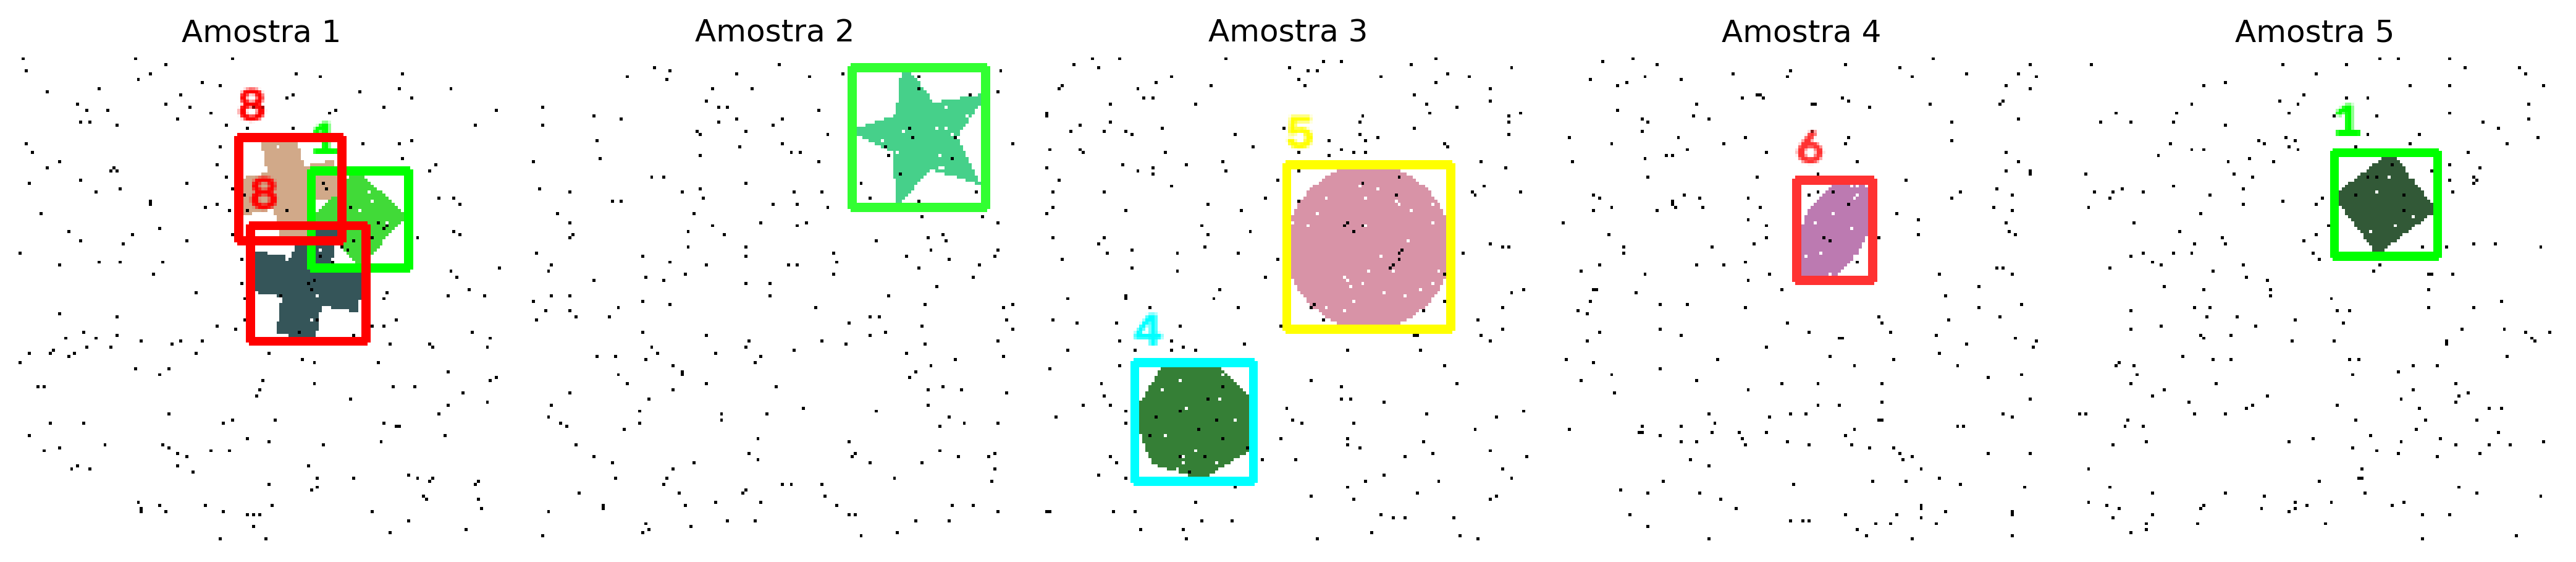

**Figura 9.30:** Muestras iniciales del *dataset* sintético ruidoso de objetos geométricos con las cajas delimitadoras del formato YOLO superpuestas.


In [35]:
# Generación de 5 muestras para visualización inicial en la parte superior del proyecto
n_amostras_iniciais = 5
rng_demo = random.Random(42)

imgs_demo = []
titulos_demo = []

for idx in range(n_amostras_iniciais):
    img_ruid, anotacoes = gera_imagem_ruidosa(rng=rng_demo)
    
    # Escritura temporal de la anotación para lectura nativa mediante mm.showBoundBox
    filename_temp = f"temp_label_{idx}.txt"
    with open(filename_temp, "w") as f:
        for c, xc, yc, w, h in anotacoes:
            f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")
            
    img_anotada = mm.showBoundBox(img_ruid, filename=filename_temp, fmt="yolo", show=False)
    imgs_demo.append(img_anotada)
    titulos_demo.append(f"Amostra {idx+1}")

# Visualización del panel de 5 muestras
mm.show(
    imgs_demo,
    titles=titulos_demo,
    cols=n_amostras_iniciais,
    figsize=(14, 3)
)

##### Bloque 2: Organización del *Dataset* y Creación del Archivo `data.yaml`

Este bloque organiza el conjunto de datos en el formato esperado por la biblioteca **Ultralytics YOLO**. Las imágenes y las anotaciones se distribuyen en directorios separados para entrenamiento y validación, mientras que el archivo `data.yaml` reúne la información necesaria para el entrenamiento del detector.

```text
shapes_dataset/
├── data.yaml
├── images/
│   ├── train/
│   └── val/
└── labels/
    ├── train/
    └── val/
```

1. **Generación del conjunto de datos:** El código crea **90** imágenes para entrenamiento y **20** para validación. Para cada imagen, escribe un archivo `.txt` que contiene una línea por objeto, en el formato YOLO (`clase`, `x_c`, `y_c`, `ancho`, `alto`), con todas las coordenadas normalizadas.

2. **Organización de los archivos:** Las imágenes se almacenan en `images/train` e `images/val`, mientras que las anotaciones correspondientes se escriben en `labels/train` y `labels/val`, preservando el mismo nombre de archivo.

3. **Creación del archivo `data.yaml`:** El código genera automáticamente el archivo de configuración que contiene la ruta del *dataset*, los directorios de entrenamiento y validación, y el mapeo entre los índices numéricos y los nombres de las nueve clases.

In [36]:
base_dir = "shapes_dataset"
rng_global = random.Random(42)

for split, n_imgs in [("train", 90), ("val", 20)]:
    os.makedirs(f"{base_dir}/images/{split}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{split}", exist_ok=True)
    
    for i in range(n_imgs):
        img_ruid, anotacoes = gera_imagem_ruidosa(rng=rng_global)
        cv2.imwrite(f"{base_dir}/images/{split}/{i:04d}.jpg", img_ruid)
        
        with open(f"{base_dir}/labels/{split}/{i:04d}.txt", "w") as f:
            for c, xc, yc, w, h in anotacoes:
                f.write(f"{c} {xc:.4f} {yc:.4f} {w:.4f} {h:.4f}\n")

with open(f"{base_dir}/data.yaml", "w") as f:
    f.write(
        f"path: {os.path.abspath(base_dir)}\n"
        "train: images/train\nval: images/val\nnames:\n"
    )
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Conjunto de datos ruidoso generado con éxito: 90 imágenes de entrenamiento y 20 de validación.")

Conjunto de datos ruidoso generado con éxito: 90 imágenes de entrenamiento y 20 de validación.


##### Bloco 3: Preprocesamiento con Filtro de Mediana

Este bloque aplica un preprocesamiento para reducir el efecto del ruido de tipo sal y pimienta introducido en la generación del *dataset*. El **Filtro de Mediana** (`cv2.medianBlur`) elimina este tipo de degradación preservando mejor los bordes de los objetos que los filtros de suavizado convencionales.

1. **Filtrado de la imagen:** El código aplica un filtro de mediana con ventana $3 \times 3$ a la imagen ruidosa, reduciendo los *píxeles* impulsivos sin alterar las anotaciones del conjunto de datos.

2. **Visualización comparativa:** La [Figura 9.31](#fig-09-yolo-pre-processamento) compara la imagen original y la imagen filtrada, manteniendo las *bounding boxes* superpuestas mediante la función `mm.showBoundBox()`.

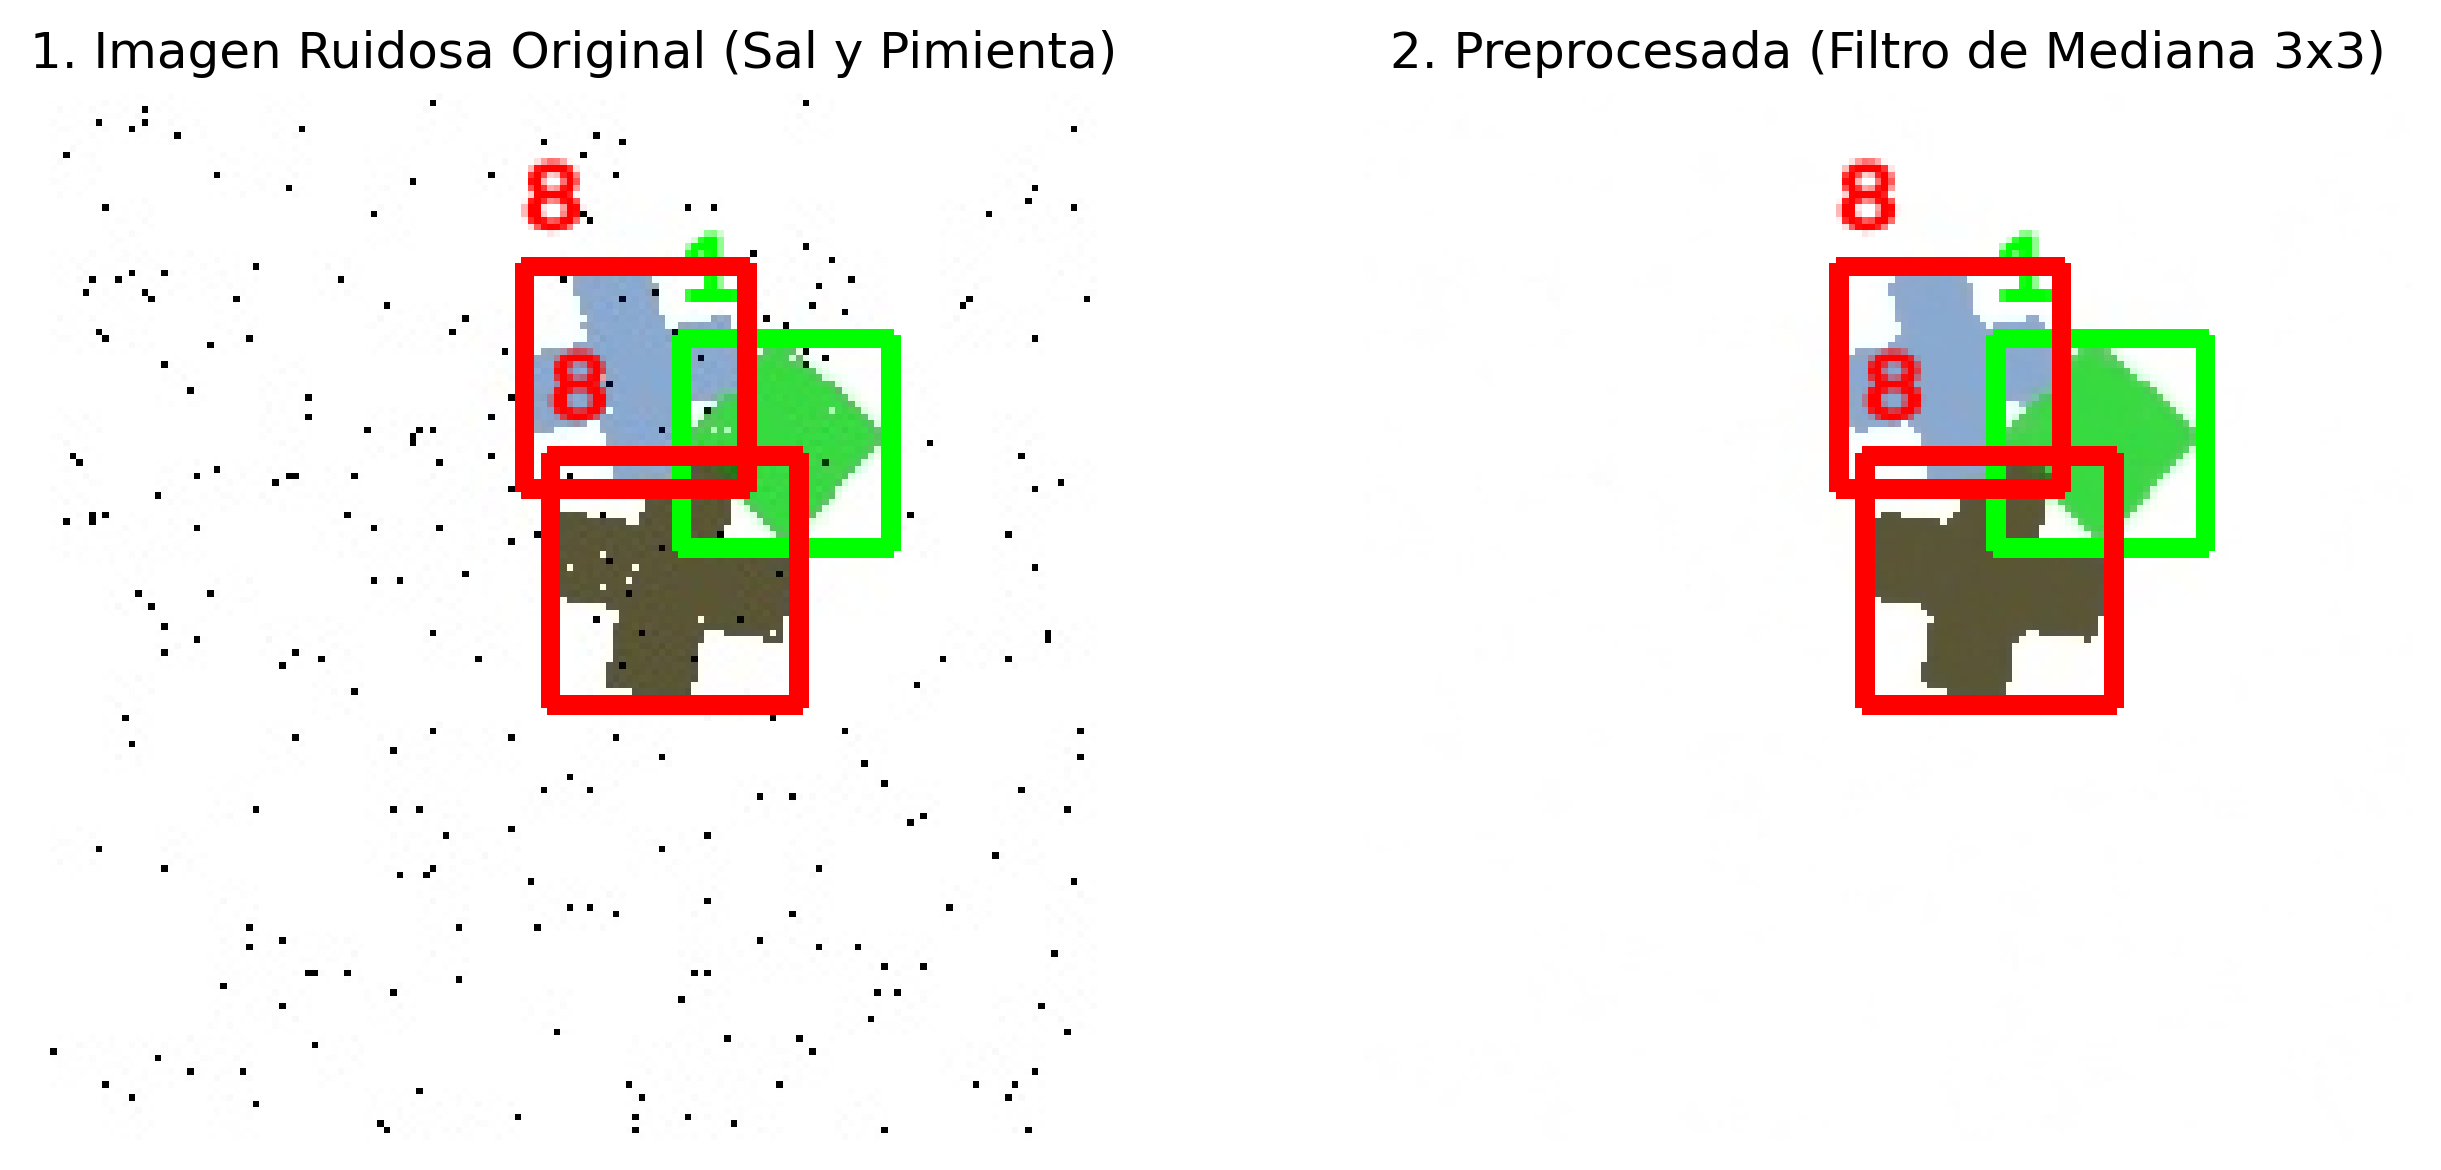

**Figura 9.31:** Comparación entre la imagen original con ruido tipo sal y pimienta y la imagen después de la aplicación del Filtro de Mediana (3x3). Las *bounding boxes* en el formato YOLO permanecen inalteradas.


In [37]:
# 1. Carga de la primera muestra ruidosa del dataset
caminho_img = f"{base_dir}/images/train/0000.jpg"
caminho_label = f"{base_dir}/labels/train/0000.txt"

img_ruidosa = mm.read(caminho_img)

# 2. Preprocesamiento con Filtro de Mediana (ventana 3x3)
img_filtrada = cv2.medianBlur(img_ruidosa, ksize=3)

# 3. Superposición de las bounding boxes con mm.showBoundBox
img_ruid_anotada = mm.showBoundBox(img_ruidosa, filename=caminho_label, fmt="yolo", show=False)
img_filt_anotada = mm.showBoundBox(img_filtrada, filename=caminho_label, fmt="yolo", show=False)

# 4. Exhibición comparativa con mm.show
mm.show(
    [img_ruid_anotada, img_filt_anotada],
    titles=[
        "1. Imagen Ruidosa Original (Sal y Pimienta)",
        "2. Preprocesada (Filtro de Mediana 3x3)"
    ],
    cols=2,
    figsize=(9, 4)
)

##### Bloque 4: Preprocesamiento del *Dataset* y Ajuste Fino del YOLOv8

Este bloque aplica el Filtro de Mediana al conjunto de imágenes y realiza el ajuste fino (*fine-tuning*) del detector **YOLOv8n** preentrenado en el conjunto **COCO**. El filtrado reduce el efecto del ruido impulsivo introducido en la generación de las imágenes, mientras que el entrenamiento adapta los parámetros de la red al nuevo dominio de formas geométricas.

1. **Filtrado por lotes:** El código recorre los directorios `train` y `val` y aplica `cv2.medianBlur` con una ventana $3 \times 3$ en todas las imágenes, manteniendo las anotaciones YOLO originales.

2. **Ajuste fino del detector:** La red `YOLO("yolov8n.pt")`, inicialmente entrenada en COCO, se adapta al conjunto geométrico mediante la función `.train()`. El entrenamiento utiliza imágenes con resolución de $320 \times 320$ *píxeles* durante $30$ épocas.

3. **Evaluación del modelo:** La función `.val()` calcula las métricas de detección en el conjunto de validación, incluyendo **precisión** (*precision*), **exhaustividad** (*recall*) y **mAP50** (*mean Average Precision* con umbral de IoU igual a $0,5$).

In [38]:
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

base_dir = "shapes_dataset"
base_dir_filt = "shapes_dataset_filtrado"

# 1. Crea una COPIA filtrada del conjunto de datos en una carpeta separada
#    (el conjunto de datos original en base_dir permanece ruidoso, intacto)
for split in ["train", "val"]:
    pasta_imgs_orig = f"{base_dir}/images/{split}"
    pasta_labels_orig = f"{base_dir}/labels/{split}"
    pasta_imgs_filt = f"{base_dir_filt}/images/{split}"
    pasta_labels_filt = f"{base_dir_filt}/labels/{split}"

    os.makedirs(pasta_imgs_filt, exist_ok=True)
    os.makedirs(pasta_labels_filt, exist_ok=True)

    for nome_arq in os.listdir(pasta_imgs_orig):
        if nome_arq.endswith(".jpg"):
            img_ruidosa = cv2.imread(f"{pasta_imgs_orig}/{nome_arq}")
            img_filtrada = cv2.medianBlur(img_ruidosa, ksize=3)
            # guarda la versión filtrada en la carpeta NUEVA, no sobrescribe la original
            cv2.imwrite(f"{pasta_imgs_filt}/{nome_arq}", img_filtrada)

    # copia las etiquetas (no cambian con el filtro)
    for nome_arq in os.listdir(pasta_labels_orig):
        shutil.copy(f"{pasta_labels_orig}/{nome_arq}", f"{pasta_labels_filt}/{nome_arq}")

# 2. data.yaml apuntando al conjunto de datos FILTRADO
with open(f"{base_dir_filt}/data.yaml", "w") as f:
    f.write(
        f"path: {os.path.abspath(base_dir_filt)}\n"
        "train: images/train\nval: images/val\nnames:\n"
    )
    for i, nome in enumerate(CLASSES):
        f.write(f"  {i}: {nome}\n")

print("Preprocesamiento completado: conjunto de datos filtrado guardado en carpeta separada.\n")

# Descargar modelo YOLOv8 preentrenado (yolov8n.pt) si aún no está presente
with contextlib.redirect_stdout(io.StringIO()), \
    contextlib.redirect_stderr(io.StringIO()):
    modelo_yolo = YOLO("yolov8n.pt")
print("Modelo YOLOv8 cargado.")

Preprocesamiento completado: conjunto de datos filtrado guardado en carpeta separada.

Modelo YOLOv8 cargado.


In [39]:
# 3. Callback personalizado para imprimir solo la época en ejecución
def on_train_epoch_start(trainer):
    epoch_atual = trainer.epoch + 1
    total_epochs = trainer.epochs
    # Escribe directamente en el stdout original (evadiendo el silenciador)
    sys.__stdout__.write(f"🔄 Processando Época {epoch_atual}/{total_epochs}...\n")
    sys.__stdout__.flush()

# Añade el callback al modelo
modelo_yolo.add_callback("on_train_epoch_start", on_train_epoch_start)

# 4. Gestor de contexto para silenciar la basura de Ultralytics (C/C++ y Python)
@contextlib.contextmanager
def silenciar_logs():
    logger = logging.getLogger("ultralytics")
    disabled_state = logger.disabled
    logger.disabled = True
    
    with open(os.devnull, "w") as fnull:
        old_stdout_fd = os.dup(1)
        old_stderr_fd = os.dup(2)
        try:
            os.dup2(fnull.fileno(), 1)
            os.dup2(fnull.fileno(), 2)
            with contextlib.redirect_stdout(fnull), contextlib.redirect_stderr(fnull):
                yield
        finally:
            os.dup2(old_stdout_fd, 1)
            os.dup2(old_stderr_fd, 2)
            os.close(old_stdout_fd)
            os.close(old_stderr_fd)
            logger.disabled = disabled_state

# Ejecución del Entrenamiento
print("--- Iniciando Entrenamiento YOLOv8 ---")
with silenciar_logs():
    resultados_treino = modelo_yolo.train(
        data=f"{base_dir_filt}/data.yaml",   # <-- entrena en el dataset filtrado
        epochs=30,
        imgsz=320,
        batch=16,
        device=device,
        verbose=False,
        plots=False
    )
    metricas = modelo_yolo.val(verbose=False)

# 5. Métricas Finales
precision = metricas.results_dict["metrics/precision(B)"]
recall = metricas.results_dict["metrics/recall(B)"]
map50 = metricas.results_dict["metrics/mAP50(B)"]

print("\n--- Rendimiento Optimizado del Modelo YOLOv8 ---")
print(f"Precisión: {precision*100:.2f}%")
print(f"Revocación (Recall): {recall*100:.2f}%")
print(f"mAP al 50% (IoU 0.50): {map50*100:.2f}%")

--- Iniciando Entrenamiento YOLOv8 ---



--- Rendimiento Optimizado del Modelo YOLOv8 ---
Precisión: 56.68%
Revocación (Recall): 86.54%
mAP al 50% (IoU 0.50): 79.88%


##### Bloque 5: Comparativo de Inferencia: Imagen Ruidosa e Imagen Restaurada

Tras el ajuste fino de YOLOv8 en el conjunto restaurado, se realiza una comparación visual entre la detección aplicada directamente sobre una imagen degradada por ruido sal y pimienta y la misma imagen después del Filtro de Mediana.

El objetivo es observar cómo una etapa simple de preprocesamiento puede influir en la calidad de las predicciones de un detector ya adaptado al nuevo dominio.

1. **Inferencia con la YOLO:** La función `modelo_yolo.predict()` ejecuta la detección en las dos versiones de la imagen, utilizando un umbral de confianza de $25\%$ (`conf=0.25`).

2. **Visualización de las Predicciones:** La función `plot()` genera las imágenes anotadas con las cajas delimitadoras y las etiquetas previstas por el modelo. La [Figura 9.32](#fig-09-yolo-inferencia-comparativa) presenta la comparación entre los dos escenarios.

In [40]:
# 1. Carga de una muestra de prueba original (sin el filtro guardado en lote)
caminho_teste = f"{base_dir}/images/val/0002.jpg"
img_ruidosa_teste = mm.read(caminho_teste)

# 2. Aplicación puntual del Filtro de Mediana (3x3) para comparación
img_filtrada_teste = cv2.medianBlur(img_ruidosa_teste, ksize=3)

# 3. Inferencia con el modelo YOLOv8 entrenado
pred_ruidosa = modelo_yolo.predict(img_ruidosa_teste, conf=0.25, verbose=False)[0]
pred_filtrada = modelo_yolo.predict(img_filtrada_teste, conf=0.25, verbose=False)[0]

# 4. Extracción de las matrices anotadas por el generador del YOLO (conversión BGR -> RGB)
img_pred_ruid = cv2.cvtColor(pred_ruidosa.plot(), cv2.COLOR_BGR2RGB)
img_pred_filt = cv2.cvtColor(pred_filtrada.plot(), cv2.COLOR_BGR2RGB)

# 5. Exhibición comparativa estandarizada mediante mm.show
mm.show(
    [img_pred_ruid, img_pred_filt],
    titles=[
        f"Inferencia en la Imagen Ruidosa ({len(pred_ruidosa.boxes)} objetos)",
        f"Inferencia en la Imagen Filtrada ({len(pred_filtrada.boxes)} objetos)"
    ],
    cols=2,
    figsize=(10, 4)
)

**Figura 9.32:** Comparación de la inferencia de la YOLOv8 ajustada por transferencia de aprendizaje en una imagen con ruido sal y pimienta y en la versión restaurada por el Filtro de Mediana. Las cajas delimitadoras y clases predichas se muestran sobre cada imagen.


In [41]:
# Limpieza explícita de los datos descargados y liberación de memoria
if FLAG_LIMPAR_DADOS:
    if os.path.exists(base_dir):
        shutil.rmtree(base_dir)
        print('🧹 Diretório de dados temporários {} removido com sucesso.'.format(base_dir))

    if os.path.exists(base_dir_filt):
        shutil.rmtree(base_dir_filt)
        print('🧹 Diretório de dados temporários {} removido com sucesso.'.format(base_dir_filt))

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

> ### 📝 Nota
>
> ###### 🧠 Un dominio mucho más distante que el de los dígitos
>
> En el experimento de transferencia de aprendizaje entre dígitos manuscritos (dominios A y B), la tarea de origen y la de destino compartían estadísticas visuales muy cercanas: ambas eran trazos en tonos de gris sobre fondo uniforme. Aquí, la distancia entre dominios es mucho mayor — el YOLO fue preentrenado en **fotografías naturales coloridas** de COCO (personas, animales, vehículos, objetos cotidianos), y la tarea de destino consiste en **formas geométricas sintéticas, de color sólido y contorno bien definido**, sin textura, iluminación ni fondo complejo.
>
> Aun así, la transferencia de aprendizaje es ventajosa: las capas iniciales de un detector entrenado en COCO aprenden filtros genéricos — detectores de bordes, esquinas y regiones de contraste — que siguen siendo útiles para delimitar el contorno de un triángulo o de una estrella, incluso si el contenido visual final es bastante distinto. Es por ello que permitir el ajuste fino (*fine-tuning*) de todas las capas, combinado con un preprocesamiento consistente entre entrenamiento e inferencia para atenuar el ruido sal y pimienta, posibilita tasas de precisión elevadas en la detección de objetos del nuevo dominio.

##### Usando un Conjunto de Datos Real

El *pipeline* anterior fue construido íntegramente en torno al **formato de
anotación YOLO** (clase, $x_{centro}$, $y_{centro}$, ancho, alto,
normalizados por el ancho y alto de la imagen) exactamente para que pueda
reutilizarse sin modificaciones si el lector tiene acceso a un conjunto de
imágenes reales anotadas de la misma manera — por ejemplo, un conjunto de
imágenes de objetos geométricos fotografiados o renderizados, cada uno con su
archivo `.txt` correspondiente en el mismo formato usado aquí. Para ello,
bastaría con:

1. Organizar las imágenes reales en `shapes_dataset/images/train` y
   `shapes_dataset/images/val`, y los archivos `.txt` de anotación
   correspondientes en las carpetas `labels/train` y `labels/val` (un archivo de
   anotación por imagen, mismo nombre base, extensión `.txt`);
2. Ajustar el archivo `data.yaml` si el número o los nombres de las clases son
   diferentes;
3. Ejecutar las mismas celdas de entrenamiento, ajuste fino y visualización ya
   presentadas, sin ninguna otra modificación de código.

Esta separación entre **generación/organización de los datos** y **entrenamiento del
modelo** es, en la práctica, la razón por la cual los formatos de anotación
estandarizados (como el de YOLO) son tan ampliamente adoptados: permiten
intercambiar el conjunto de datos de entrada — sintético por real, un dominio por otro —
manteniendo inalterado todo el resto del *pipeline* de transferencia de
aprendizaje.

### 9.5.3 Segmentación de Objetos

El mismo principio de transferencia de aprendizaje también fundamenta arquitecturas de segmentación de imágenes, en las cuales un extractor de características preentrenado proporciona representaciones visuales generales, mientras que una cabeza especializada realiza la clasificación densa, píxel a píxel.

Las siguientes secciones presentan la **DeepLabV3** como ejemplo de segmentador preentrenado utilizado directamente para inferencia y, a continuación, la arquitectura **U-Net**, entrenada desde cero y comparada con una línea base morfológica clásica.

#### 9.5.3.1 DeepLabV3: Segmentador Preentrenado

En la segmentación semántica, el objetivo no se limita a la localización de los objetos mediante cajas delimitadoras (*bounding boxes*). La red asigna una clase a cada *píxel* de la imagen, produciendo un mapa de etiquetas con la misma resolución que la entrada. Arquitecturas como la **DeepLabV3**, con *backbone* **ResNet-50**, utilizan un extractor de características preentrenado y una cabeza especializada para realizar esta clasificación densa.

1. **Carga e inferencia:** El modelo `deeplabv3_resnet50(weights="DEFAULT")` carga pesos preentrenados en el conjunto **Pascal VOC**, que define $21$ clases de segmentación. El código convierte la imagen en *tensor*, añade la dimensión de *batch* (`unsqueeze(0)`) y ejecuta la inferencia.

2. **Mapa de clases:** La salida del modelo posee dimensión $(1, 21, H, W)$, conteniendo un valor para cada clase en cada *píxel*. La operación `.argmax(dim=1)` selecciona la clase de mayor respuesta en cada posición, generando una matriz bidimensional de etiquetas con dimensiones $(H, W)$.

3. **Visualización:** El código convierte el mapa de etiquetas al formato esperado por `mm.show()`, que muestra el resultado de la segmentación en la [Figura 9.33](#fig-09-segmentacao-pretreinada).

In [42]:
# 1. Carga de la imagen (retorna numpy.ndarray)
url_imagem = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
url_imagem = "http://images.cocodataset.org/val2017/000000039769.jpg"
img = mm.read(url_imagem)

# 2. Carga del modelo DeepLabV3 preentrenado en modo de evaluación
modelo_segmentacao = deeplabv3_resnet50(weights="DEFAULT").eval()

# 3. Ejecución de la inferencia sin cálculo de gradientes
with torch.no_grad():
    tensor_entrada = to_tensor(img).unsqueeze(0)  # Formato (1, C, H, W)
    saida = modelo_segmentacao(tensor_entrada)["out"]
    
    # Selección de la clase con mayor probabilidad por píxel (argmax en el eje de los canales)
    mapa_classes = saida.argmax(dim=1).squeeze(0).byte().cpu().numpy()

# 4. Visualización del mapa de segmentación semántica
mm.show(
    [img,mapa_classes],
    title=["Imagen original","Segmentación Semántica (DeepLabV3)"]
)

**Figura 9.33:** Mapa de segmentación semántica generado por el modelo DeepLabV3 preentrenado: clasificación píxel a píxel representada en matriz 2D mostrada.


#### 9.5.3.2 Segmentación Semántica con Arquitectura U-Net

La subsección anterior presentó un modelo preentrenado (*DeepLabV3*) que produce directamente una etiqueta de clase por *píxel*. Esta sección completa la secuencia de proyectos prácticos — clasificación y detección — abordando la segmentación semántica implementada y entrenada desde cero con la **U-Net**, la arquitectura de referencia introducida por Ronneberger (2015).

En la clasificación, el mapa de características final se aplanaba (*flatten*) en un vector, descartando la información espacial en favor de una única etiqueta por imagen. La U-Net, por su parte, produce una salida con la **misma resolución espacial que la entrada**: un mapa bidimensional en el cual cada *píxel* recibe su propia clasificación. Este requisito — preservar el detalle espacial de alta resolución al mismo tiempo que se construye contexto semántico en capas profundas — motiva la arquitectura de codificador-decodificador con conexiones de atajo (*skip connections*).

El escenario utilizado simula la segmentación de nódulos en exámenes médicos sintéticos: imágenes en escala de grises contienen una región circular ("nódulo") superpuesta sobre un fondo, ambas contaminadas por ruido gaussiano y con medias de intensidad muy cercanas — un desafío intencional de bajo contraste, ideal para demostrar la ganancia del aprendizaje espacial frente a la umbralización puntual.

##### Bloco 1: Gerador del Conjunto Sintético de Nódulos y Visualización Inicial

El siguiente generador produce pares (imagen, máscara): la imagen contiene una región circular de intensidad ligeramente superior a la del fondo, ambas afectadas por la misma desviación estándar de ruido gaussiano. La máscara binaria delimita exactamente la región del nódulo y sirve como verdad de referencia (*ground truth*).

1. **Construcción del Nódulo:** La función `gera_imagem_com_nodulo` superpone el nódulo al fondo sobre una matriz $64 \times 64$ y aplica ruido gaussiano.
2. **Visualización con `mm.show`:** La [Figura 9.34](#fig-09-unet-dataset) ilustra las dos primeras muestras y sus respectivas máscaras.

Conjunto de entrenamiento: 160 imágenes | Conjunto de validación: 40 imágenes



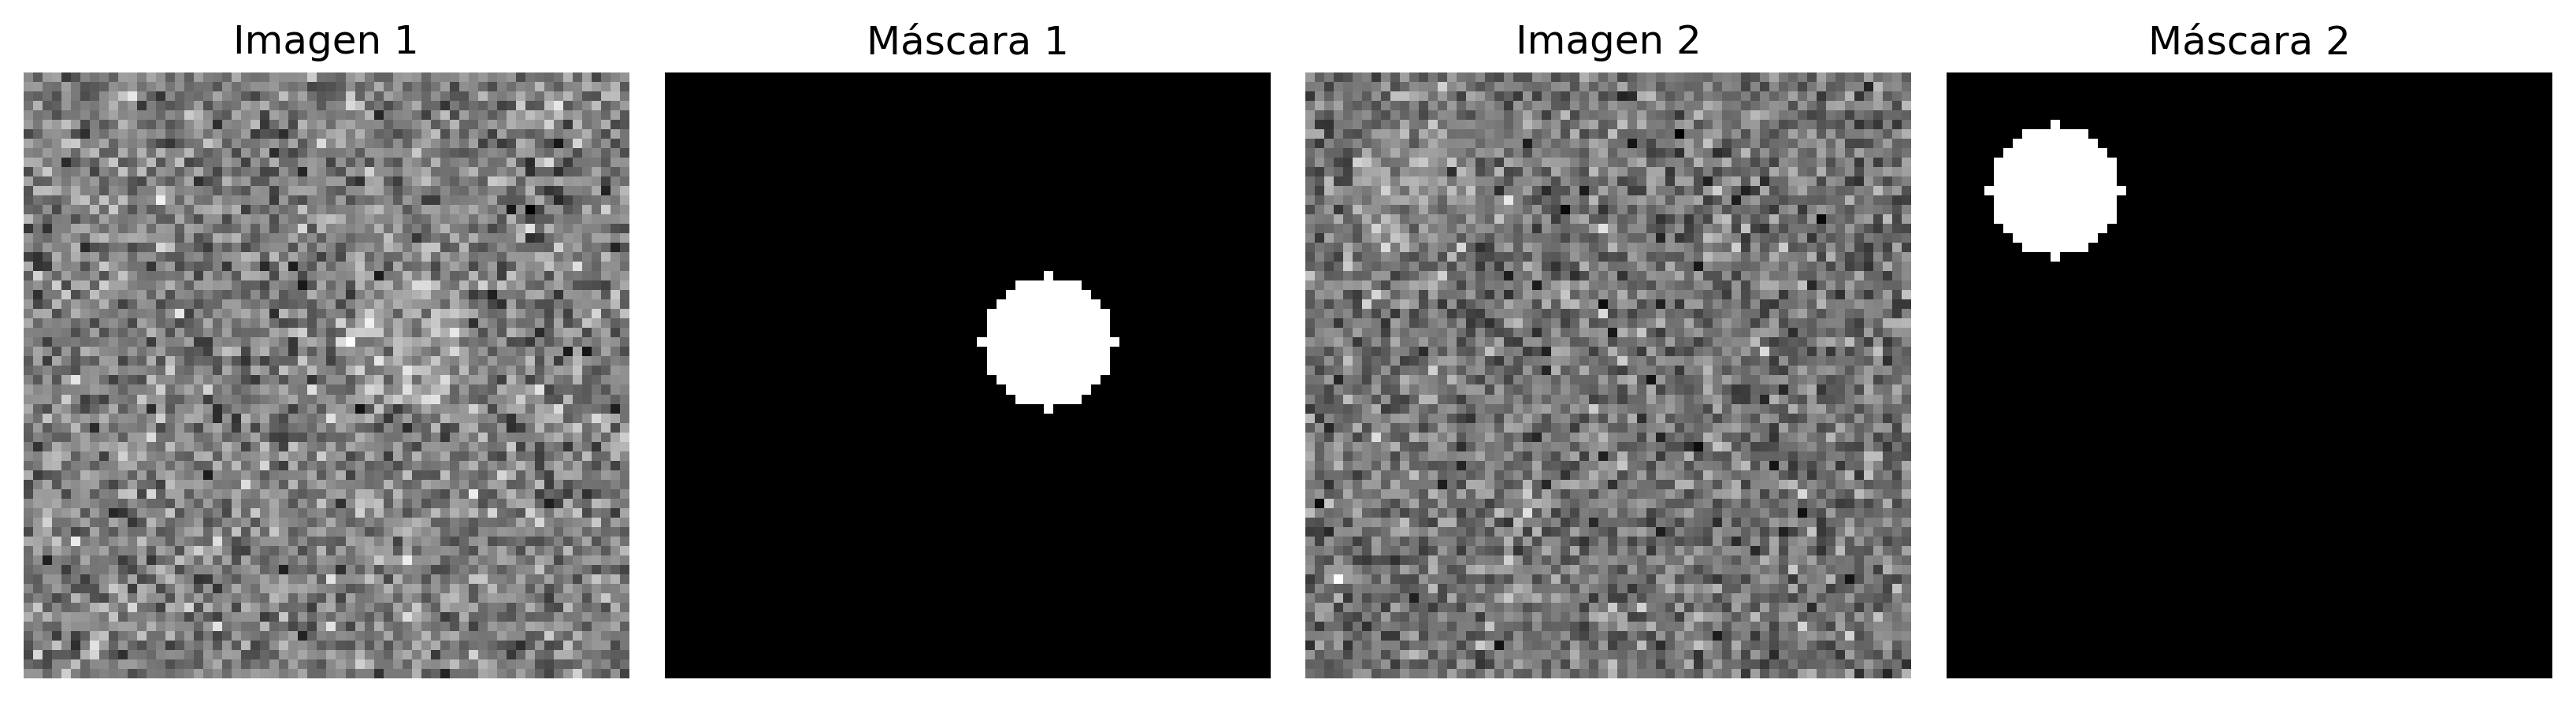

**Figura 9.34:** Muestras del conjunto de datos sintético de nódulos: imagen en escala de grises bajo ruido y su respectiva máscara binaria de referencia mostradas.


In [43]:
TAM_IMG = 64


def gera_imagem_com_nodulo(
    tam=TAM_IMG,
    raio_min=7,
    raio_max=15,
    media_fundo=95,
    media_nodulo=118,
    sigma_ruido=26,
    rng=None,
):
    rng = rng or np.random.default_rng()
    fundo = rng.normal(media_fundo, sigma_ruido, (tam, tam))
    nodulo = rng.normal(media_nodulo, sigma_ruido, (tam, tam))
    mascara = np.zeros((tam, tam), dtype=np.uint8)

    raio = int(rng.integers(raio_min, raio_max))
    cx = int(rng.integers(raio + 4, tam - raio - 4))
    cy = int(rng.integers(raio + 4, tam - raio - 4))

    cv2.circle(mascara, (cx, cy), raio, 255, -1)
    imagem = np.clip(np.where(mascara > 0, nodulo, fundo), 0, 255).astype(
        np.uint8
    )
    return imagem, mascara


# Generación de los conjuntos de entrenamiento y validación
rng_dados = np.random.default_rng(42)
N_TREINO, N_VAL = 160, 40

imgs_treino, masks_treino = zip(
    *[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_TREINO)]
)
imgs_val, masks_val = zip(
    *[gera_imagem_com_nodulo(rng=rng_dados) for _ in range(N_VAL)]
)

print(
    f"Conjunto de entrenamiento: {N_TREINO} imágenes | Conjunto de validación: {N_VAL} imágenes\n"
)

# Exhibición de muestras iniciales 
mm.show(
    [imgs_treino[0], masks_treino[0], imgs_treino[1], masks_treino[1]],
    titles=["Imagen 1", "Máscara 1", "Imagen 2", "Máscara 2"],
    cols=4,
    figsize=(11, 3),
)

##### Bloco 2: Línea Base Clásica (Filtrado, Otsu y Morfología)

Antes de emplear la U-Net, se evalúa el desempeño de un *pipeline* morfológico clásico construido con la biblioteca `morph`: un **suavizador gaussiano** (`mm.blur`), una **umbralización de Otsu** (`mm.threshold`) y una **apertura morfológica** (`mm.open`) para la eliminación de ruidos aislados.

1. **Métrica de Intersección sobre Unión (IoU):** La función `iou_mascaras` calcula el grado de superposición *píxel a píxel* entre la predicción y la máscara real.
2. **Ejecución y Comparativa:** La [Figura 9.35](#fig-09-unet-classico) muestra el resultado de la segmentación clásica en una imagen de prueba, demostrando las limitaciones del umbral global bajo bajo contraste.

IoU medio (línea de base clásica) en la validación: 0.7516



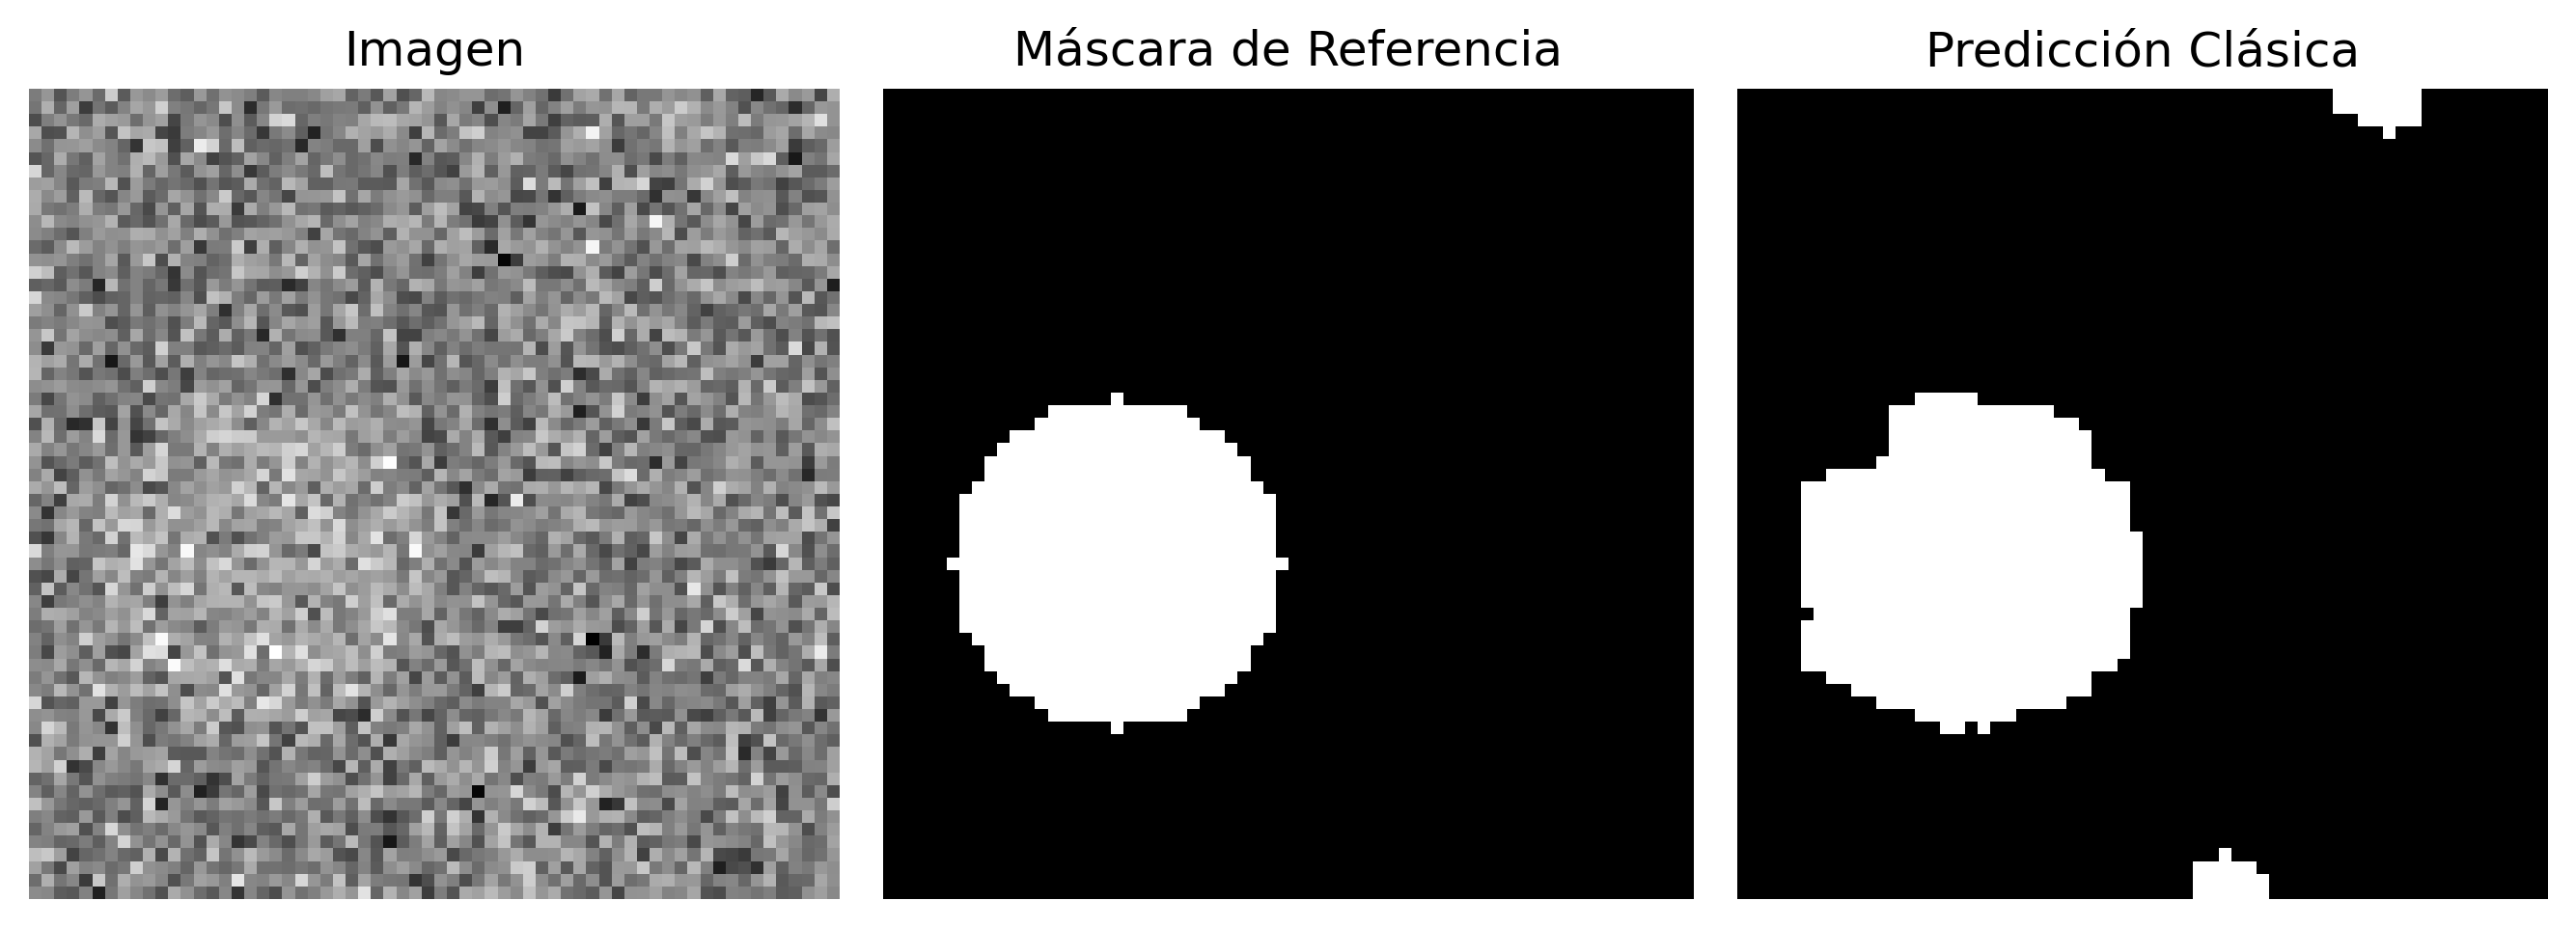

**Figura 9.35:** Línea de base clásica de segmentación: suavizado, umbralización de Otsu y apertura morfológica mostradas.


In [44]:
def iou_mascaras(predita, referencia):
    p, r = predita > 0, referencia > 0
    intersecao = np.logical_and(p, r).sum()
    uniao = np.logical_or(p, r).sum()
    return intersecao / uniao if uniao else 1.0


def segmenta_classico(imagem, elemento_estrutural):
    suavizada = mm.blur(imagem, 7)
    binaria = mm.threshold(suavizada)
    return mm.open(binaria, elemento_estrutural)


elemento_estrutural = mm.sedisk(5)
ious_classico = [
    iou_mascaras(segmenta_classico(img, elemento_estrutural), mask)
    for img, mask in zip(imgs_val, masks_val)
]
iou_classico_medio = float(np.mean(ious_classico))
print(
    f"IoU medio (línea de base clásica) en la validación: {iou_classico_medio:.4f}\n"
)

predicao_classica_exemplo = segmenta_classico(imgs_val[0], elemento_estrutural)

mm.show(
    [imgs_val[0], masks_val[0], predicao_classica_exemplo],
    titles=["Imagen", "Máscara de Referencia", "Predicción Clásica"],
    cols=3,
    figsize=(9, 3.2),
)

##### Bloque 3: Construcción de la Arquitectura U-Net y Funciones de Pérdida

La U-Net es una arquitectura en forma de "U" (de ahí su nombre), pensada específicamente para la segmentación de imágenes. Está formada por dos caminos que trabajan en conjunto:

- 🔽 **Codificador (encoder):** desciende por la imagen, reduciendo la resolución espacial en cada etapa mientras extrae características cada vez más abstractas (bordes → texturas → formas → contexto).
- 🔼 **Decodificador (decoder):** asciende de nuevo, reconstruyendo la resolución original mediante convoluciones transpuestas (*upsampling*), hasta generar una máscara del mismo tamaño que la imagen de entrada.

El elemento que hace especial a la U-Net son las **conexiones de atajo** (*skip connections*): estas llevan los mapas de características del codificador directamente a la etapa correspondiente del decodificador, en la misma resolución. Esto evita que los detalles finos —como contornos y bordes— se pierdan durante la compresión espacial.

**Flujo general de la arquitectura:**

```text
Entrada
  │
  ▼
Codificador (Conv → Conv → Pool) × 3
  │
  ├──── conexiones de atajo reinyectan mapas de alta resolución  ────┐
  ▼                                                               │
Base (bottleneck)                                                 │
  │                                                               │
  ▼                                                               │
Decodificador (Upsample → Concat → Conv → Conv) × 3  ◄────────────┘
  │
  ▼
Salida 1×1 (logits)
```

**Componentes principales:**

1. **Bloque Convolucional Base (`BlocoConv`)**
   La unidad fundamental repetida en toda la red. Aplica dos convoluciones $3 \times 3$ en secuencia, cada una seguida de activación ReLU, con *padding* que preserva las dimensiones espaciales de la entrada. Este bloque aparece tanto en el codificador como en el decodificador.

2. **Convolución Transpuesta (`nn.ConvTranspose2d`)**
   Es la operación responsable del *upsampling* en el decodificador: en lugar de reducir la resolución espacial (como hace el `MaxPool2d` en el codificador), la aumenta, aprendiendo los pesos necesarios para "deshacer" la compresión y recuperar gradualmente el tamaño original de la imagen.

3. **Pérdida Combinada (BCE + Dice)**
   La función `perda_segmentacao` suma dos métricas complementarias:
   - **Entropía Cruzada Binaria (BCE):** evalúa el acierto *pixel a pixel*.
   - **Coeficiente de Dice:** evalúa la *superposición global* entre la máscara prevista y la real.

   Juntas, equilibran la precisión local con la fidelidad de la forma segmentada en su conjunto.

In [45]:
class BlocoConv(nn.Module):

    def __init__(self, canais_entrada, canais_saida):
        super().__init__()
        self.rede = nn.Sequential(
            nn.Conv2d(canais_entrada, canais_saida, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(canais_saida, canais_saida, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.rede(x)


class UNetCompacta(nn.Module):

    def __init__(self, canais_entrada=1, base=8):
        super().__init__()
        self.enc1 = BlocoConv(canais_entrada, base)
        self.enc2 = BlocoConv(base, base * 2)
        self.enc3 = BlocoConv(base * 2, base * 4)
        self.pool = nn.MaxPool2d(2)

        self.fundo = BlocoConv(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(
            base * 8, base * 4, kernel_size=2, stride=2
        )
        self.dec3 = BlocoConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(
            base * 4, base * 2, kernel_size=2, stride=2
        )
        self.dec2 = BlocoConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(
            base * 2, base, kernel_size=2, stride=2
        )
        self.dec1 = BlocoConv(base * 2, base)

        self.saida = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        f = self.fundo(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(f), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.saida(d1)


def para_tensores(imagens, mascaras):
    X = (
        torch.tensor(np.stack(imagens), dtype=torch.float32).unsqueeze(1)
        / 255.0
    )
    Y = (
        torch.tensor(np.stack(mascaras), dtype=torch.float32).unsqueeze(1)
        / 255.0
    )
    return X, Y


def perda_dice(logits, alvo, eps=1e-6):
    probs = torch.sigmoid(logits)
    intersecao = (probs * alvo).sum(dim=(1, 2, 3))
    uniao = probs.sum(dim=(1, 2, 3)) + alvo.sum(dim=(1, 2, 3))
    dice = (2 * intersecao + eps) / (uniao + eps)
    return 1 - dice.mean()


def perda_segmentacao(logits, alvo):
    return nn.functional.binary_cross_entropy_with_logits(
        logits, alvo
    ) + perda_dice(logits, alvo)

##### Bloque 4: Entrenamiento de la U-Net y Evaluación de Rendimiento

El entrenamiento se ejecuta durante $35$ épocas utilizando el optimizador *Adam*. En cada época, se monitorea la Pérdida de Entrenamiento y el índice IoU promedio en el conjunto de validación.

1. **Bucle de Entrenamiento:** Se actualizan los parámetros con *mini-lotes* de $16$ muestras.
2. **Evolución Gráfica:** La [Figura 9.36](#fig-09-unet-treinamento) muestra el gráfico con el progreso de la pérdida y del IoU.

Parámetros entrenables de la U-Net: 120681
1 / 35


6 / 35


11 / 35


16 / 35


21 / 35


26 / 35


31 / 35


IoU medio final de la U-Net en la validación: 0.8876


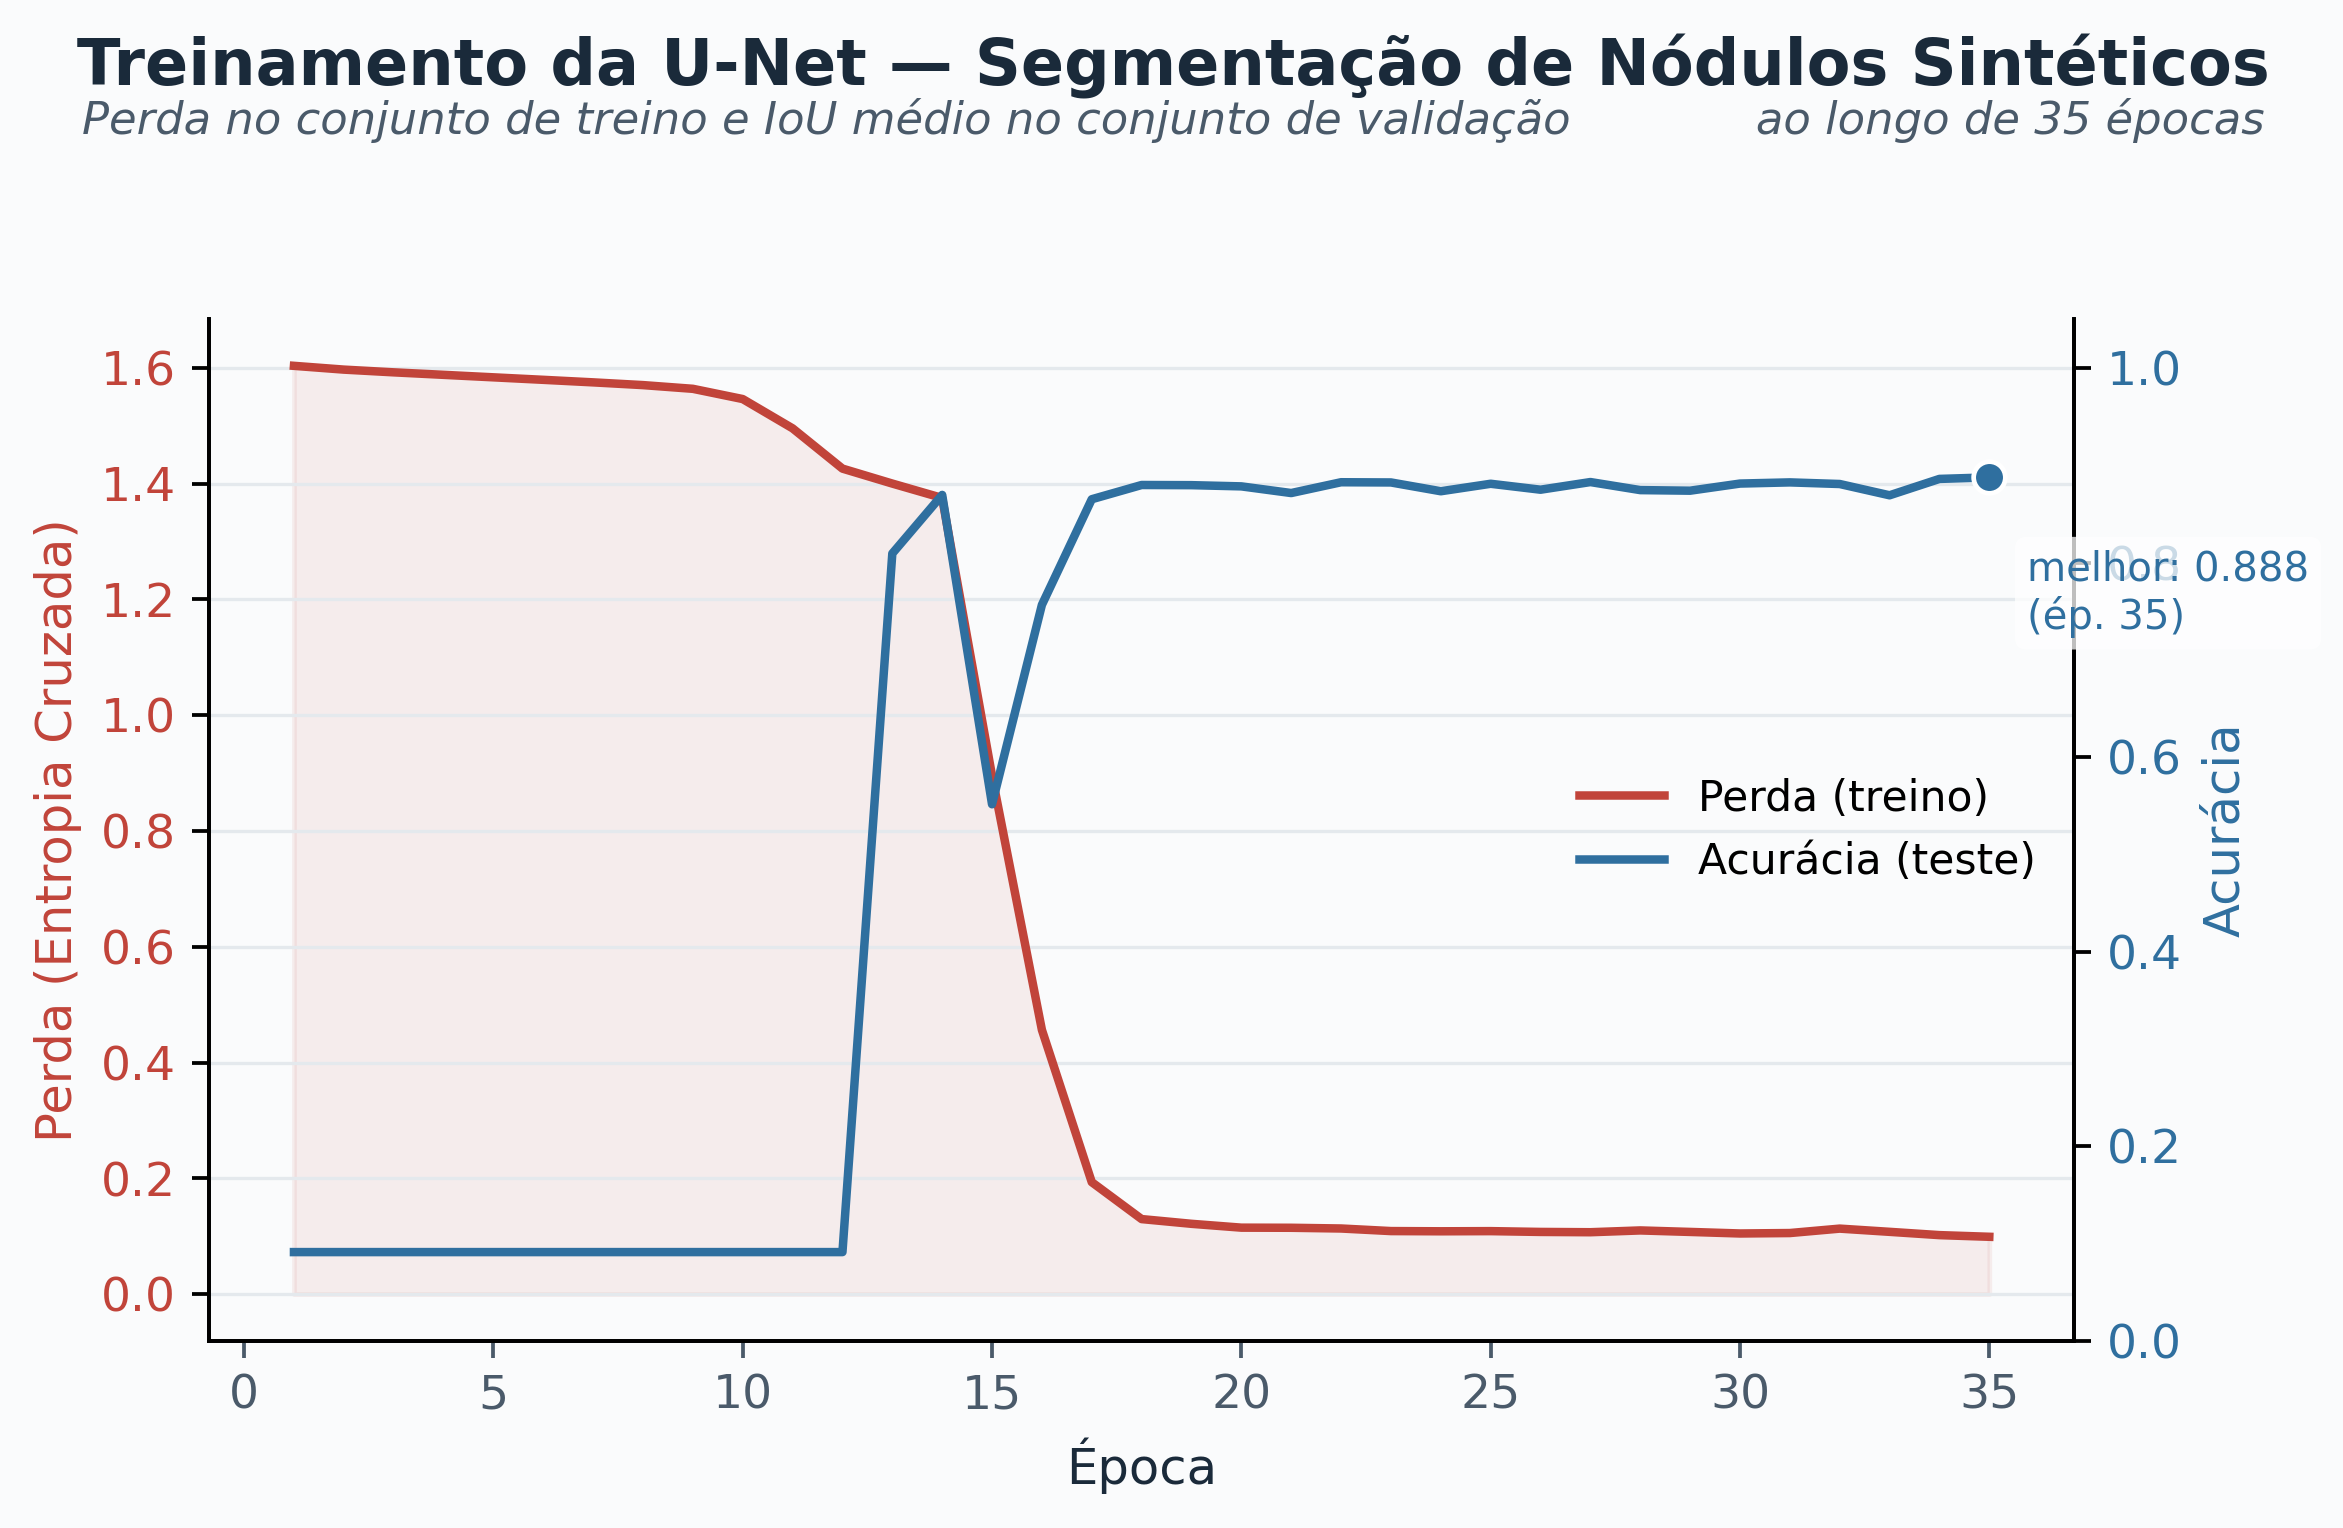

**Figura 9.36:** Evolución del entrenamiento de la U-Net compacta: reducción de la pérdida y elevación del índice IoU medio en el conjunto de validación a lo largo de 35 épocas.


In [46]:
modelo_unet = UNetCompacta()
print(
    f"Parámetros entrenables de la U-Net: {sum(p.numel() for p in modelo_unet.parameters())}"
)

X_treino_unet, Y_treino_unet = para_tensores(imgs_treino, masks_treino)
X_val_unet, Y_val_unet = para_tensores(imgs_val, masks_val)

otimizador_unet = optim.Adam(modelo_unet.parameters(), lr=1e-3)
n = X_treino_unet.size(0)
tam_lote = 16
epocas_unet = 35
historico_perda_unet, historico_iou_unet = [], []

for epoca in range(epocas_unet):
    if epoca % 5 == 0:  # Imprime cada 5 épocas
        print(epoca + 1, "/", epocas_unet)
    modelo_unet.train()
    perm = torch.randperm(n)
    perda_epoca = 0.0

    for i in range(0, n, tam_lote):
        idx = perm[i : i + tam_lote]
        otimizador_unet.zero_grad()
        logits = modelo_unet(X_treino_unet[idx])
        perda = perda_segmentacao(logits, Y_treino_unet[idx])
        perda.backward()
        otimizador_unet.step()
        perda_epoca += perda.item() * len(idx)

    modelo_unet.eval()
    with torch.no_grad():
        predicao_val = (torch.sigmoid(modelo_unet(X_val_unet)) > 0.5).float()
        intersecao = (predicao_val * Y_val_unet).sum(dim=(1, 2, 3))
        uniao = ((predicao_val + Y_val_unet) > 0).float().sum(dim=(1, 2, 3))
        iou_epoca = (intersecao / uniao.clamp(min=1e-6)).mean().item()

    historico_perda_unet.append(perda_epoca / n)
    historico_iou_unet.append(iou_epoca)

iou_unet_final = historico_iou_unet[-1]
print(f"IoU medio final de la U-Net en la validación: {iou_unet_final:.4f}")

# Gráfico de la evolución del entrenamiento
r = mm.showTrainCurves(historico_perda_unet, historico_iou_unet,
        titulo="Treinamento da U-Net — Segmentação de Nódulos Sintéticos",
        subtitulo="Perda no conjunto de treino e IoU médio no conjunto de validação \
            ao longo de 35 épocas")

##### Bloque 5: Comparativo Cuantitativo y Cualitativo (Clásico vs. U-Net)

La comparación entre el enfoque clásico y la U-Net evidencia la superioridad del aprendizaje de representaciones en escenarios de bajo contraste.

1. **Panel de Métricas:** El gráfico de barras en la [Figura 9.37](#fig-09-unet-comparativo) contrasta el IoU medio de ambos métodos en la validación.
2. **Visualización Cualitativa:** La comparación visual en tres muestras demuestra cómo las conexiones de atajo recuperan el contorno del nódulo incluso bajo ruido acentuado.

IoU promedio (Suavizado clásico + Otsu): 0.7516
IoU promedio (U-Net): 0.8876


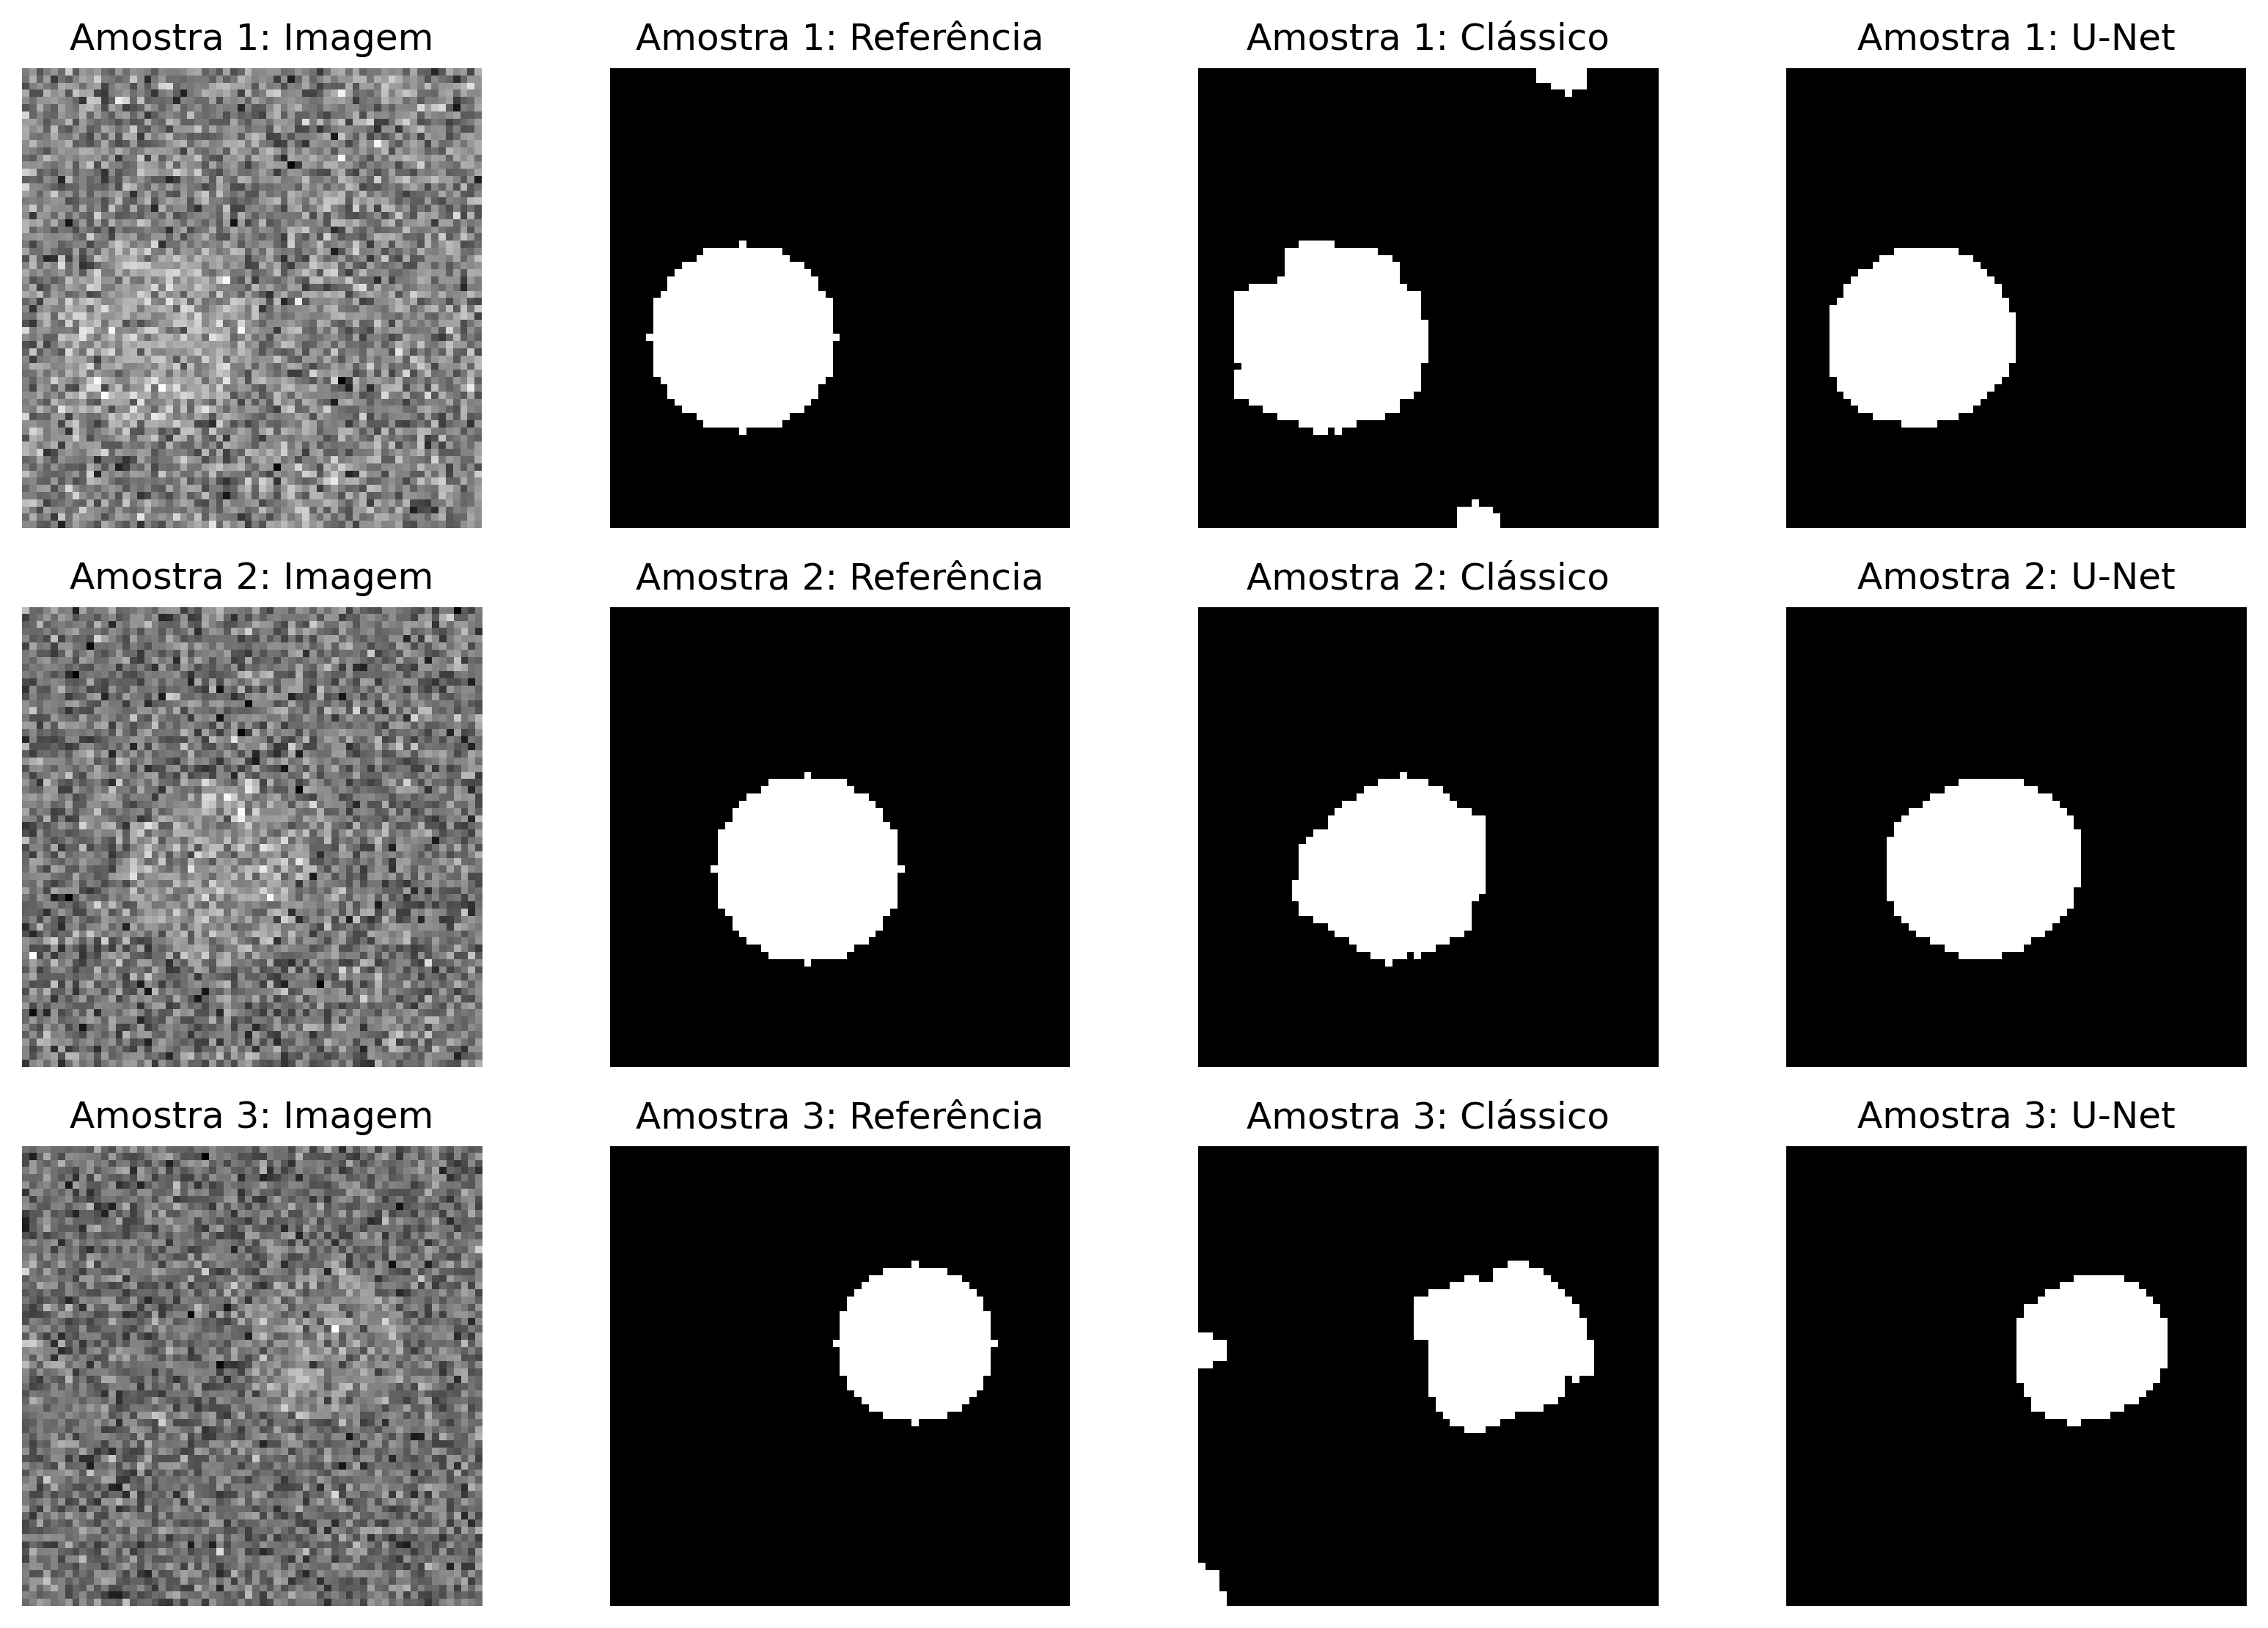

**Figura 9.37:** Comparativo cuantitativo (IoU promedio) y cualitativo entre el enfoque clásico y la U-Net entrenada en tres muestras de validación.


In [47]:
# 1.  comparativo 
print(f"IoU promedio (Suavizado clásico + Otsu): {iou_classico_medio:.4f}")
print(f"IoU promedio (U-Net): {iou_unet_final:.4f}")

# 2. Visualización cualitativa lado a lado en 3 muestras mediante mm.show
imgs_comparativas = []
titulos_comparativos = []

for i in range(3):
    with torch.no_grad():
        pred_unet = (
            (torch.sigmoid(modelo_unet(X_val_unet[i : i + 1])) > 0.5)
            .float()
            .squeeze()
            .numpy()
            * 255
        )

    pred_classico = segmenta_classico(imgs_val[i], elemento_estrutural)

    imgs_comparativas.extend(
        [imgs_val[i], masks_val[i], pred_classico, pred_unet.astype(np.uint8)]
    )

    t_prefix = f"Amostra {i+1}"
    titulos_comparativos.extend(
        [
            f"{t_prefix}: Imagem",
            f"{t_prefix}: Referência",
            f"{t_prefix}: Clássico",
            f"{t_prefix}: U-Net",
        ]
    )

mm.show(
    imgs_comparativas,
    titles=titulos_comparativos,
    cols=4,
    figsize=(11, 7.5),
)

> ### 📝 Nota
>
> ###### 🧠 ¿Por qué la U-Net supera a la umbralización fija?
>
> La umbralización de Otsu aplica un valor de corte global sobre la intensidad local. Cuando la diferencia de media entre el nódulo y el fondo es pequeña frente al ruido gaussiano, esta regla comete errores sistemáticos en los bordes.
>
> La U-Net supera esta limitación al combinar el contexto semántico amplio extraído por el codificador con los detalles espaciales finos preservados por las conexiones de atajo. Esto permite identificar la presencia del nódulo y delimitar sus contornos con precisión, incluso bajo ruido intenso.

### 9.5.4 Ingeniería de Datos para VC (*Roboflow*)

Una U-Net puede entrenarse a partir de imágenes anotadas en plataformas de ingeniería de datos para Visión por Computador (VC), como *Roboflow*. Estas plataformas permiten organizar conjuntos de datos, realizar anotaciones, aplicar etapas de preprocesamiento y *data augmentation*, entrenar modelos y exportar los datos en diferentes formatos. En esta sección, sin embargo, el ejemplo retoma la **detección de objetos geométricos**, utilizando conjuntos de datos ya presentados en este libro.

> ### ❗ Dependencia de conexión y clave de API
>
> Las celdas de esta sección requieren conexión a Internet y una clave de API gratuita de *Roboflow* (`app.roboflow.com`). En el *Workspace* del proyecto, acceda a **⚙ → Roboflow API** y copie la **Private API Key**.
>
> Cree, en esta carpeta, el archivo `chave_roboflow.txt` que contenga **únicamente la clave**, sin comillas. Un modelo de este archivo está disponible en `chave_roboflow.txt.exemplo`.
>
> Agregue `chave_roboflow.txt` al archivo `.gitignore`, ya que contiene una credencial de acceso que no debe versionarse ni compartirse.

#### 9.5.4.1 Detección de objetos utilizando *Roboflow*

*Roboflow* permite realizar inferencia sobre imágenes locales, lo que posibilita
evaluar el rendimiento del modelo alojado en la identificación de los objetos de
interés.

Además de la inferencia, el *dataset* puede exportarse en el formato
`png-mask-semantic`, en el cual cada imagen se acompaña de una máscara de
segmentación semántica. En esta máscara, cada píxel representa la clase a la que
pertenece el objeto correspondiente. Los pares imagen-máscara se utilizan
como datos de entrenamiento para la `UNetCompacta`.

#### 9.5.4.2 Conexión, *descarga* y verificación del *dataset*

El código establece conexión con el *Workspace* `mctest` y el proyecto
`geometric-test00`, versión 6, y realiza la *descarga* del *dataset* hacia
`dados/datasetRoboFlow`. A continuación, verifica la *forma* de las imágenes en cada
*split*. La función de verificación se reutiliza posteriormente en la sección.

In [48]:
from roboflow import Roboflow
from pathlib import Path
from PIL import Image
from collections import Counter

def contar_shapes(raiz, splits=("train", "valid", "test")):
    """Cuenta el shape (alto, ancho, canales) de las imágenes por split."""
    for split in splits:
        pasta = raiz / split / "images"
        if not pasta.exists():
            print(f"{split}: carpeta no encontrada")
            continue

        shapes = Counter()
        for arquivo in pasta.iterdir():
            if arquivo.is_file():
                with Image.open(arquivo) as img:
                    shapes[(img.height, img.width, len(img.getbands()))] += 1

        txt = ", ".join(f"{s}: {n}" for s, n in shapes.items())
        print(f"{split}: {txt}")


chave = Path("chave_roboflow.txt")

if not chave.exists():
    print("Clave de Roboflow no encontrada: clave_roboflow.txt")
else:
    with open(chave) as f:
        api_key = f.read().strip()

    # Proyecto:
    # https://app.roboflow.com/mctest/geometric-test00/models
    # geometric-test00/6

    rf = Roboflow(api_key=api_key)
    projeto = rf.workspace("mctest").project("geometric-test00")
    versao = projeto.version(6)

    print(
        f"ID: {versao.version} | Nombre: {versao.name} | "
        f"Imágenes: {versao.images}"
    )

    raiz = Path("dados/datasetRoboFlow")
    versao.download("yolov8", location=str(raiz))

    print("Dataset:", raiz)
    contar_shapes(raiz)

#### 9.5.4.3 Descargando el *dataset* de forma reproducible (alternativa)

Como alternativa al *dataset* obtenido mediante *Roboflow*, se puede utilizar un
*dataset* disponible en un repositorio de GitHub, también organizado en los
mismos *splits* y que contiene las mismas clases de objetos. Los conjuntos de
datos, sin embargo, no son idénticos: las imágenes de GitHub tienen una resolución
de `608×608` píxeles, mientras que las imágenes exportadas por *Roboflow* tienen
`640×640` píxeles.

El código siguiente realiza la descarga del *dataset* desde GitHub, en caso de que
aún no esté disponible localmente, y reutiliza `contar_shapes` para verificar
las dimensiones de las imágenes en cada *split*.

In [49]:
import os

if not os.path.exists("dados/dataset"):
    cmd = (
        "git clone --no-checkout --depth 1 --filter=blob:none "
        "https://github.com/fzampirolli/pdi-vc.git tmp_repo && "
        "cd tmp_repo && git sparse-checkout set all/cap09/dados/dataset "
        "&& git checkout && cd .. && mkdir -p dados && "
        "cp -r tmp_repo/all/cap09/dados/dataset dados/dataset && "
        "rm -rf tmp_repo"
    )
    !{cmd}

if not chave.exists():
    print("Chave do Roboflow não encontrada: chave_roboflow.txt")
else:
  versao_recente = projeto.versions()[-1]
  print(f"Versão mais recente: {versao_recente.version.split('/')[-1]}")

  contar_shapes(Path("dados/dataset"))

#### 9.5.4.4 Comparando una imagen de cada *dataset*

Los dos *datasets* poseen imágenes con resoluciones diferentes: `608×608` en
GitHub y `640×640` en *Roboflow*. Para una comparación visual directa, las
imágenes se redimensionan a la misma dimensión antes de ser mostradas
lado a lado ([Figura 9.38](#fig-09-datasets-comparacao)).

In [50]:
import cv2

if not chave.exists():
    print("Clave de Roboflow no encontrada: chave_roboflow.txt")
else:
    caminho1 = next((raiz / "train/images").iterdir())
    caminho2 = next((Path("dados/dataset") / "train/images").iterdir())

    img1 = mm.read(str(caminho1))
    img2 = mm.read(str(caminho2))

    # Redimensiona ambas para el mismo tamaño (el menor entre las dos)
    largura = min(img1.shape[1], img2.shape[1])
    altura = min(img1.shape[0], img2.shape[0])
    img1_r = cv2.resize(img1, (largura, altura))
    img2_r = cv2.resize(img2, (largura, altura))

    mm.show(
        [img1_r, img2_r],
        title=[f"Roboflow {img1.shape}", f"GitHub {img2.shape}"],
    )

**Figura 9.38:** Una imagen de cada *dataset*, redimensionadas para comparación


#### 9.5.4.5 Inferencia con el modelo entrenado

El modelo entrenado en la versión 6 se utiliza para realizar la inferencia sobre
una imagen de prueba local. La predicción considera los umbrales de confianza y
de superposición empleados por la supresión de no máximos (*Non-Maximum
Suppression*, NMS), y el resultado se presenta en la imagen anotada de la
[Figura 9.39](#fig-09-roboflow-detection).

In [51]:
# version.model está obsoleto; usar version.models()

if not chave.exists():
    print("Clave de Roboflow no encontrada: chave_roboflow.txt")
else:
    modelo = versao.models()[0]

    img_path = "dados/dataset/test/images/00001.jpg"
    pred = modelo.predict(img_path, confidence=40, overlap=30)
    resp = pred.json()  # incluye los cuadros detectados en resp["predictions"]

    altura, largura, _ = mm.read(img_path).shape
    print("Dimensiones de la imagen de prueba:", (altura, largura))

    pred.save("resultado.jpg")  # imagen anotada

    mm.show(
        mm.read("resultado.jpg"),
        title="Resultado de la inferencia con el modelo de Roboflow",
        figsize=(6, 6)
    )

**Figura 9.39:** Resultado de la inferencia con el modelo de Roboflow


#### 9.5.4.6 Evaluando las predicciones con IoU y clase

*Roboflow* devuelve cada caja con las coordenadas del centro (`x`, `y`) en
*píxeles* y la clase predicha, mientras que las etiquetas locales
(`datos/conjunto_de_datos/prueba/etiquetas/00001.txt`) siguen el formato
YOLO, con centro y dimensiones normalizadas en el intervalo `[0, 1]`. Antes
de la comparación mediante `mm.IoU`, las cajas deben convertirse al mismo
formato, con las coordenadas de la esquina superior izquierda y las
dimensiones expresadas en *píxeles*.

Una predicción solo se considera correcta cuando la clase predicha coincide
con la clase de la caja real y su *Intersection over Union* (IoU) es mayor
o igual al umbral definido, adoptándose, en este ejemplo, `0,5` (50%) como
valor predeterminado.

> ### ❗ Importante
>
> ##### El `class_id` de *Roboflow* no corresponde al índice de las *etiquetas* locales
>
> En la exportación, *Roboflow* reordena las clases en **orden alfabético** en
> el `data.yaml`, independientemente del orden utilizado en el proyecto
> original, mantenido en el `data.yaml` del GitHub. Así, `class_id = 0`
> corresponde a `Circulo` en la respuesta de la API, mientras que el mismo
> índice corresponde a `Triangulo` en las *etiquetas* locales.
>
> Por ello, la comparación debe realizarse por el **nombre de la clase**
> (`p["class"]`), convirtiéndolo posteriormente al índice correspondiente en
> la lista local. Los `class_id` no deben compararse directamente.

In [52]:
# resp, ancho y altura se definieron en la celda anterior

# Orden de clases usado en las etiquetas locales (datos/dataset/*/labels/*.txt)
CLASSES_LOCAIS = ["Triangulo", "Quadrado", "Pentagono", "Hexagono",
                   "Heptagono", "Circulo", "Elipse"]

def predicao_correta(pred: tuple, real: tuple, limiar: float = 0.5) -> bool:
    """Verdadero si misma clase y mm.IoU(caja_pred, caja_real) >= umbral."""
    classe_pred, caixa_pred = pred
    classe_real, caixa_real = real
    return classe_pred == classe_real and mm.IoU(caixa_pred, caixa_real) >= limiar

def caixa_roboflow(p: dict) -> tuple:
    """Convierte la predicción de Roboflow a (clase, (x, y, w, h))."""
    caixa = (p["x"] - p["width"] / 2, p["y"] - p["height"] / 2,
             p["width"], p["height"])
    # usa el nombre de la clase (no el class_id!) para hacer coincidir con el orden local
    classe = CLASSES_LOCAIS.index(p["class"])
    return (classe, caixa)

def carrega_labels_yolo(caminho_txt: str, largura: int, altura: int) -> list:
    """Lee etiquetas YOLO (normalizadas) y convierte a (clase, (x, y, w, h))."""
    caixas = []
    with open(caminho_txt) as f:
        for linha in f:
            classe, xc, yc, w, h = map(float, linha.split())
            w_px, h_px = w * largura, h * altura
            x_px = xc * largura - w_px / 2
            y_px = yc * altura - h_px / 2
            caixas.append((int(classe), (x_px, y_px, w_px, h_px)))
    return caixas

if not chave.exists():
    print("Clave de Roboflow no encontrada: chave_roboflow.txt")
else:
    caixas_pred = [caixa_roboflow(p) for p in resp["predictions"]]
    caixas_real = carrega_labels_yolo(
        "dados/dataset/test/labels/00001.txt", largura, altura
    )

    acertos = sum(
        any(predicao_correta(cp, cr, limiar=0.5) for cr in caixas_real)
        for cp in caixas_pred
    )
    print(f"{acertos}/{len(caixas_pred)} predicciones correctas (clase + IoU >= 50%)")

Para visualizar el resultado, cada predicción se dibuja sobre la imagen:
en verde cuando es un acierto (clase + IoU ≥ umbral) y en rojo cuando es un
error, como se muestra en [Figura 9.40](#fig-09-roboflow-acertos).

In [53]:
import cv2

VERDE, VERMELHO = (0, 255, 0), (255, 0, 0)

if not chave.exists():
    print("Clave de Roboflow no encontrada: chave_roboflow.txt")
else:
    img_acertos = mm.read(img_path).copy()

    if not chave.exists():
        print("Clave de Roboflow no encontrada: chave_roboflow.txt")
    else:
        for cp in caixas_pred:
            classe_pred, (x, y, w, h) = cp
            correta = any(predicao_correta(cp, cr, limiar=0.5) for cr in caixas_real)
            cor = VERDE if correta else VERMELHO

            p1, p2 = (int(x), int(y)), (int(x + w), int(y + h))
            cv2.rectangle(img_acertos, p1, p2, cor, 2)
            cv2.putText(img_acertos, str(classe_pred), (p1[0], p1[1] - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, cor, 2)

    mm.show(
        img_acertos,
        title=f"{acertos}/{len(caixas_pred)} predições corretas "
            f"(classe + IoU >= 50%)",
        figsize=(6, 6)
    )

**Figura 9.40:** Predições corretas (verde) e incorretas (vermelho)


### 9.5.5 Aplicaciones Geométricas e Integradas

El capítulo concluye integrando dos pilares de la VC: la **geometría proyectiva** (estudiada en los Capítulos 6 y 8) y el **aprendizaje profundo**. La combinación de estos enfoques sustenta aplicaciones prácticas en el mundo real, como se ilustra a continuación.

#### 9.5.5.1 Realidad Aumentada con Marcadores y Homografía

Imagina una cámara apuntando a una mesa donde alguien pegó un pequeño marcador ArUco. Dependiendo del ángulo de la cámara, ese marcador aparece **rotado, inclinado, en perspectiva** — nunca perfectamente cuadrado. Es precisamente esa distorsión la que la homografía sabe "leer" y deshacer (o, en nuestro caso, replicar para una nueva imagen).

El flujo completo de una aplicación de RA basada en marcadores sigue tres pasos:

1. **Ambientación:** el marcador se inserta en una escena real, sufriendo una transformación de perspectiva (simulando el ángulo de la cámara).
2. **Detección:** el algoritmo localiza el marcador en la escena y recupera las coordenadas exactas de sus 4 esquinas con `cv2.aruco.ArucoDetector`.
3. **Sustitución:** con la homografía entre el marcador "ideal" y el marcador "detectado", se proyecta una **nueva imagen virtual** exactamente sobre el área del marcador — como si este se hubiera transformado en una ventana hacia otro contenido, tal como muestra la [Figura 9.41](#fig-09-realidade-aumentada).

> ### 📝 Nota
>
> **Detalle técnico importante:** el ArUco necesita un margen blanco alrededor del patrón (la "zona de silencio") para que el detector pueda diferenciar el marcador del fondo. Por ello, el código siguiente añade un borde con `cv2.copyMakeBorder` y utiliza interpolación `cv2.INTER_NEAREST` al deformar la imagen, evitando que la rotación difumine los cuadraditos blancos y negros e impida la detección.

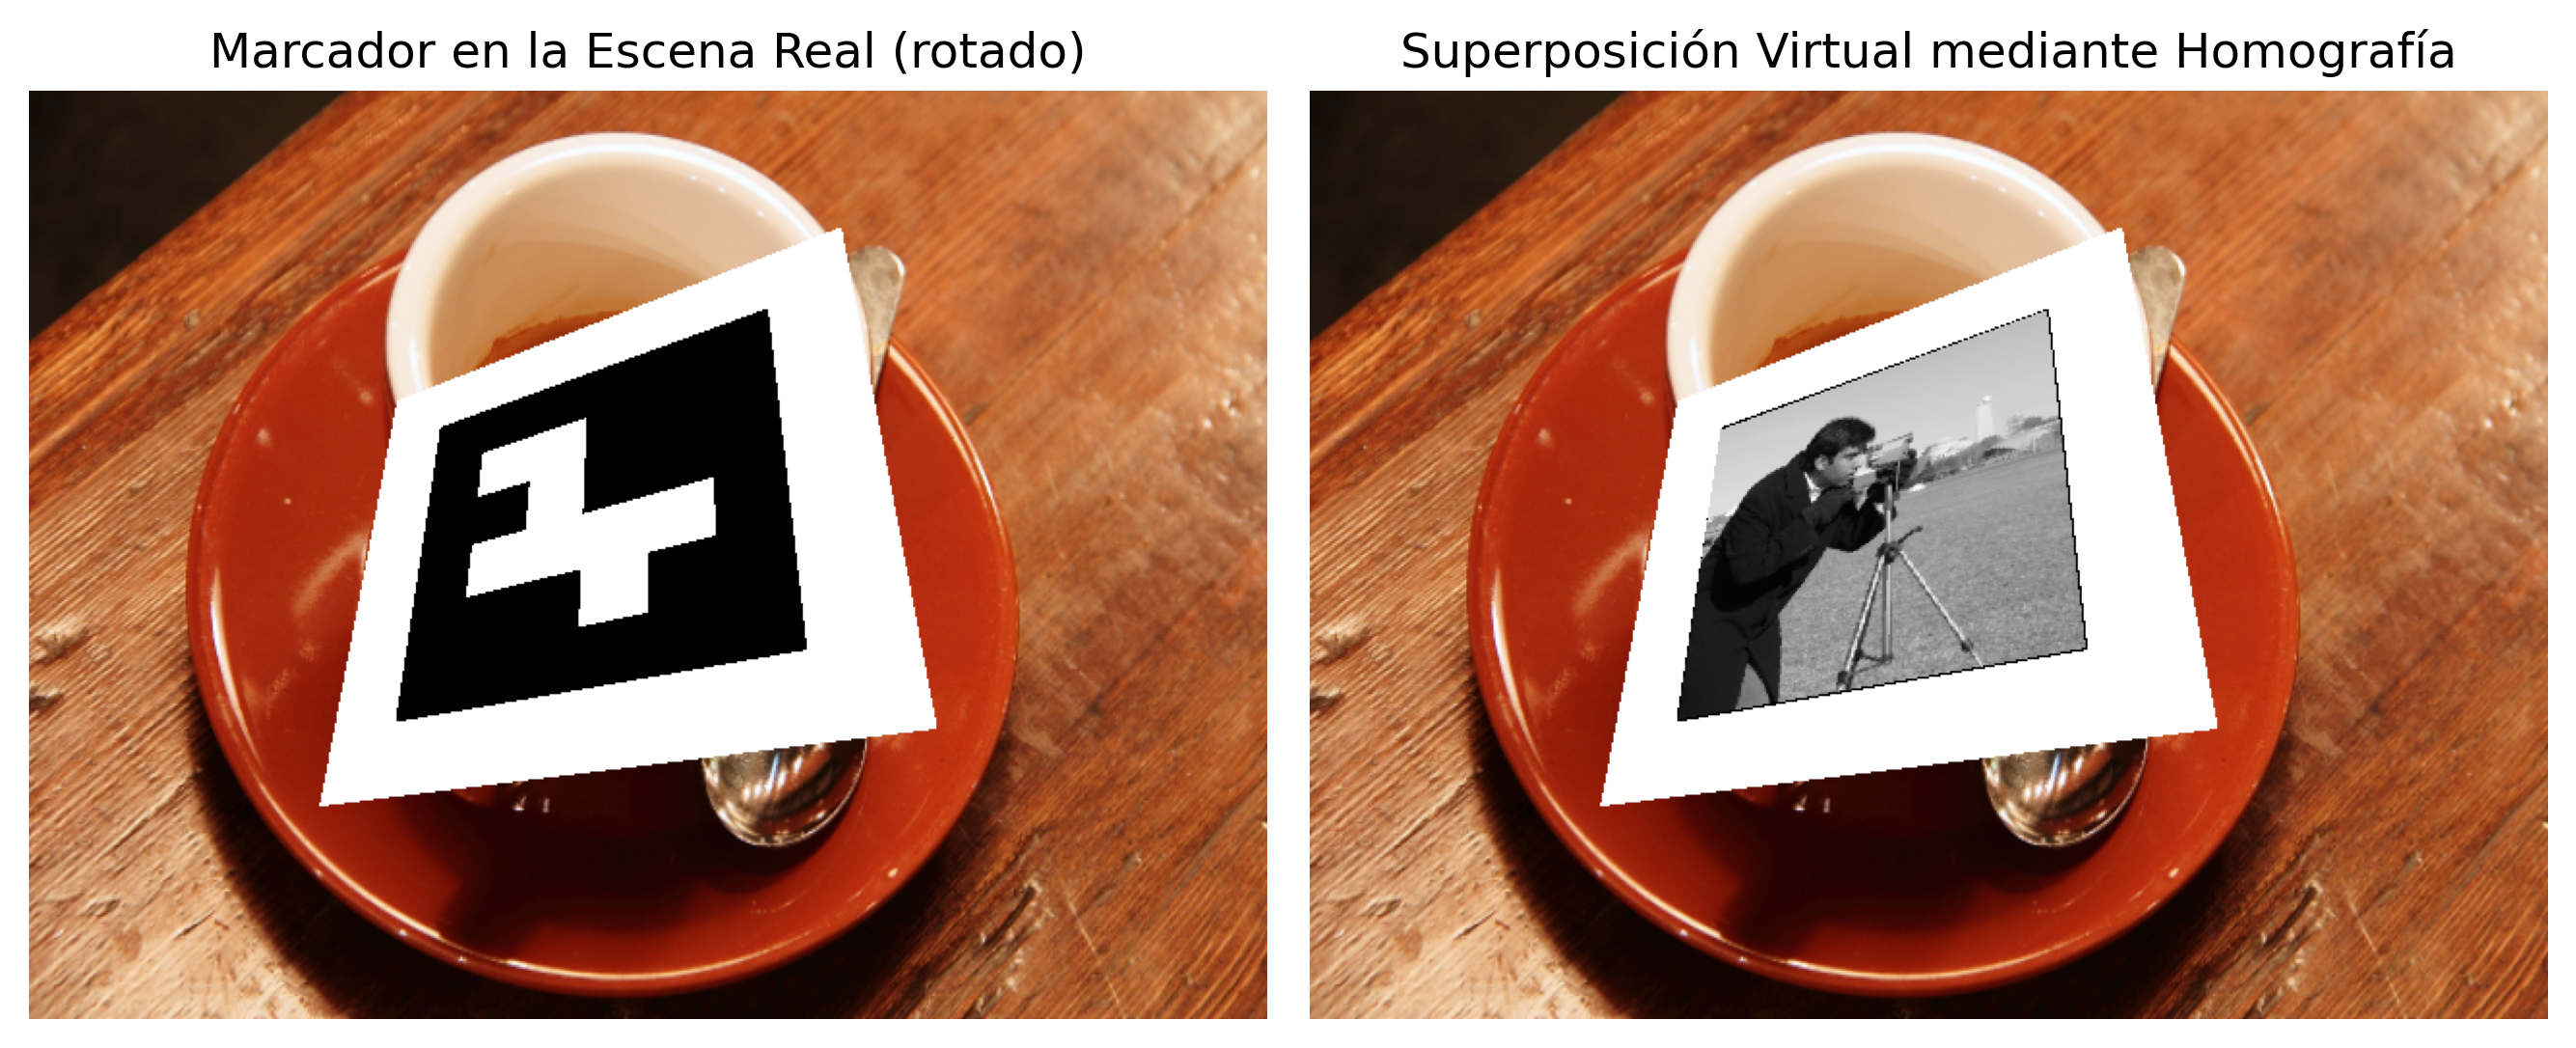

**Figura 9.41:** Realidad aumentada basada en marcador ArUco: marcador insertado en escena real y rotado, detectado y sustituido por imagen virtual mediante homografía.


In [54]:
# 1. Generación del marcador ArUco sintético, ya con margen blanco (zona de silencio)
# → este margen es esencial para que el detector pueda "ver" el marcador
dic = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
aruco_bruto = cv2.aruco.generateImageMarker(dic, 7, 200)
aruco_gray = cv2.copyMakeBorder(
    aruco_bruto, 40, 40, 40, 40, cv2.BORDER_CONSTANT, value=255
)  # 200 -> 280px, con 40px de marco blanco en cada lado
aruco = cv2.cvtColor(aruco_gray, cv2.COLOR_GRAY2BGR)
lado = aruco.shape[0]  # 280

# 2. Escena real de fondo, usando una imagen de ejemplo del skimage.data
fundo = cv2.cvtColor(skdata.coffee(), cv2.COLOR_RGB2BGR)
cena = cv2.resize(fundo, (640, 480))

# Esquinas del marcador "de frente" (src) y su posición rotada/inclinada en la escena (dst)
src = np.float32([[0, 0], [lado, 0], [lado, lado], [0, lado]])
dst = np.float32([[190, 160], [420, 70], [470, 330], [150, 370]])  # rotación + perspectiva

# 3. Proyecta el marcador (con bordes nítidos) sobre la escena real
H_cena, _ = cv2.findHomography(src, dst)
mask_cena = cv2.warpPerspective(
    np.full((lado, lado), 255, np.uint8), H_cena, (640, 480),
    flags=cv2.INTER_NEAREST,
)
cena[mask_cena > 0] = cv2.warpPerspective(
    aruco, H_cena, (640, 480), flags=cv2.INTER_NEAREST
)[mask_cena > 0]

# 4. Detección del marcador dentro de la escena (como lo haría una cámara)
det = cv2.aruco.ArucoDetector(dic, cv2.aruco.DetectorParameters())
corners, ids, _ = det.detectMarkers(cena)

assert ids is not None and len(corners) > 0, \
    "Marcador não detectado — confira iluminação/contraste da cena."

# 5. Imagen virtual (otra imagen del skimage.data) que va a "sustituir" al marcador
# Nota: usamos el cuadrado INTERNO del marcador (sin el margen) como área de proyección,
# entonces la homografía de la imagen virtual usa 'src' original (200x200), no el 'lado' con borde
src_interno = np.float32([[0, 0], [200, 0], [200, 200], [0, 200]])
virtual = cv2.resize(
    cv2.cvtColor(skdata.camera(), cv2.COLOR_RGB2BGR), (200, 200)
)

# Las esquinas detectadas corresponden al marcador CON el margen (280x280),
# entonces recalculamos H_ra usando 'src' con margen, para mantener la proyección coherente
H_ra, _ = cv2.findHomography(src, corners[0][0])

# La homografía detectada se aplica a la imagen virtual (redimensionada a 'lado')
virtual_grande = cv2.resize(virtual, (lado, lado))
ra = cena.copy()
mask_ra = cv2.warpPerspective(
    np.full((lado, lado), 255, np.uint8), H_ra, (640, 480), flags=cv2.INTER_NEAREST
)
ra[mask_ra > 0] = cv2.warpPerspective(
    virtual_grande, H_ra, (640, 480), flags=cv2.INTER_NEAREST
)[mask_ra > 0]

# Visualización: escena con marcador vs. escena con Realidad Aumentada aplicada
mm.show(
    [cv2.cvtColor(cena, cv2.COLOR_BGR2RGB), cv2.cvtColor(ra, cv2.COLOR_BGR2RGB)],
    titles=["Marcador en la Escena Real (rotado)", "Superposición Virtual mediante Homografía"],
    cols=2,
    figsize=(9, 4),
)

**Resumen del *pipeline*:**

| Etapa | Qué hace | Función clave |
|---|---|---|
| 1. Generación | Marcador ArUco con margen blanco | `generateImageMarker` + `copyMakeBorder` |
| 2. Ambientación | Inserta marcador distorsionado en la escena | `findHomography` + `warpPerspective` |
| 3. Detección | Localiza marcador y devuelve esquinas | `ArucoDetector.detectMarkers` |
| 4. Sustitución | Proyecta imagen virtual sobre el marcador | `findHomography` + `warpPerspective` |

> 💡 **Lección:** que el detector "no encuentre nada" es común en VC. Pregúntate siempre: **"¿di contraste y espacio suficientes?"** — vale para ArUco, códigos QR y reconocimiento facial.

#### 9.5.5.2 Fotogrametría y Referencia de Escala

La **fotogrametría** permite estimar dimensiones físicas de objetos a partir de imágenes digitales. Para ello, se utiliza un objeto de referencia con dimensiones conocidas, posicionado en la misma escena que el objeto de interés. Este procedimiento establece una relación entre distancias medidas en *píxeles* y sus correspondientes dimensiones en el mundo real.

Considere, por ejemplo, una tarjeta de crédito, cuyas dimensiones siguen el estándar internacional ISO/IEC 7810. Como su ancho es exactamente **8,56 cm**, basta con determinar cuántos *píxeles* ocupa ese ancho en la imagen para calcular el factor de conversión entre *píxeles* y centímetros. Si la tarjeta corresponde a 140 *píxeles*, entonces cada *píxel* representará aproximadamente **0,061 cm**. Este mismo factor de escala puede aplicarse para estimar las dimensiones de cualquier otro objeto ubicado en el mismo plano de la escena, tal como se ilustra en la [Figura 9.42](#fig-09-fotogrametria).

El procedimiento puede dividirse en dos etapas principales:

1. **Segmentación y *bounding box*:** localizar, en la imagen, tanto el objeto de referencia como el objeto de interés, utilizando técnicas como segmentación por color, umbralización, detección de contornos o métodos de detección de objetos.
2. **Conversión a dimensiones físicas:** calcular la razón $\mathrm{cm/pixel}$ a partir del ancho conocido del objeto de referencia y utilizarla para convertir las medidas del objeto de interés de *píxeles* a centímetros.

> ### 📝 Nota
>
> **Condición para mediciones confiables**
>
> La conversión entre *píxeles* y centímetros presupone que el objeto de referencia y el objeto de interés se encuentren aproximadamente en el mismo plano y a la misma distancia de la cámara. Bajo estas condiciones, la escala permanece prácticamente constante en toda la imagen. Diferencias de profundidad, inclinación de la cámara o distorsiones de la lente pueden introducir errores en las medidas estimadas.

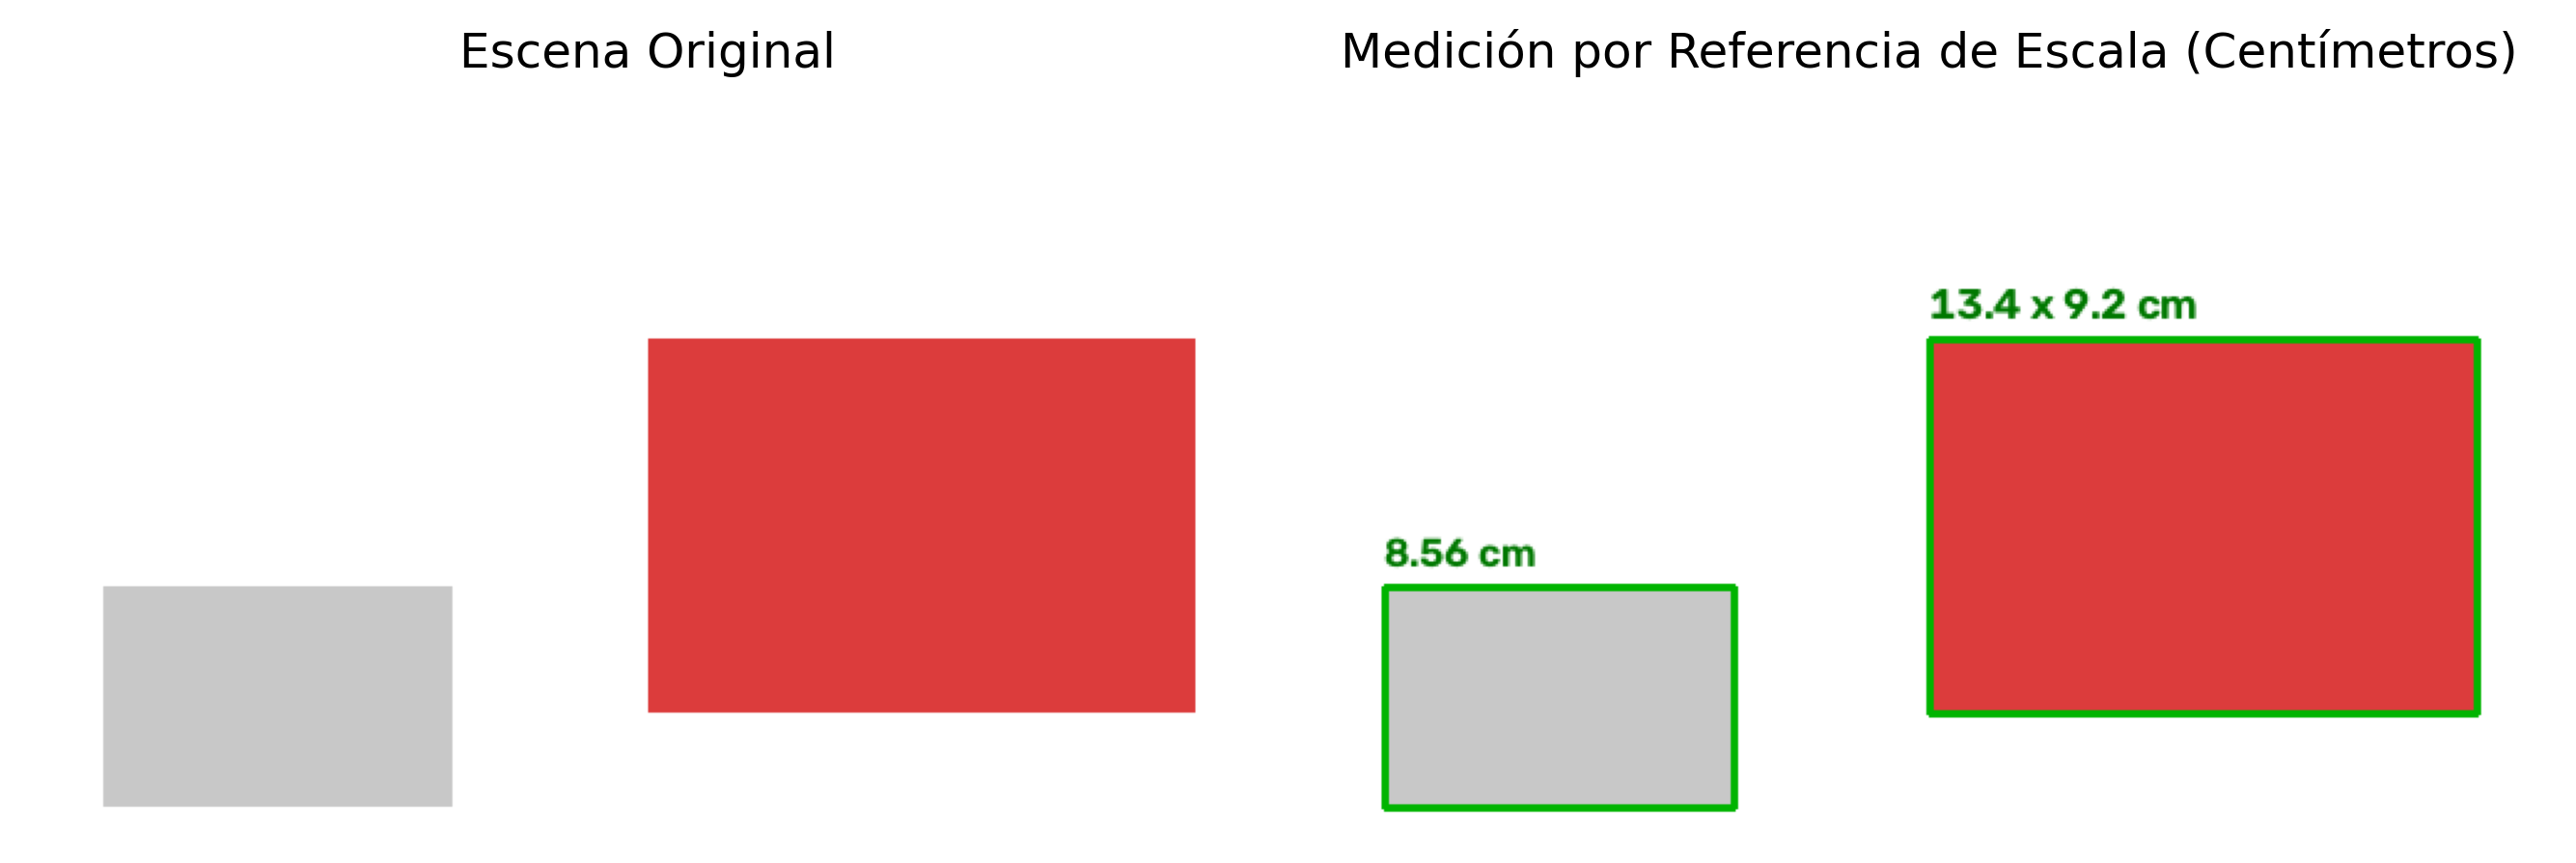

**Figura 9.42:** Medición de dimensiones físicas reales utilizando una tarjeta de referencia de escala conocida (8,56 cm) renderizada. El rectángulo gris representa la tarjeta de referencia y el rectángulo azul representa el objeto objetivo. Las dimensiones estimadas del objeto se muestran en centímetros.


In [55]:
COR_REFERENCIA = (200, 200, 200)  # Tarjeta de referencia (gris)
COR_OBJETO = (60, 60, 220)  # Objeto objetivo (rojo)

# Dibujo de la escena sintética
cena_medicao = np.full((300, 500, 3), 255, dtype=np.uint8)
cv2.rectangle(
    cena_medicao, (30, 200), (30 + 140, 200 + 88), COR_REFERENCIA, -1
)
cv2.rectangle(cena_medicao, (250, 100), (250 + 220, 100 + 150), COR_OBJETO, -1)


def caixa_delimitadora_por_cor(imagem_bgr, cor_bgr, tolerancia=40):
    diferenca = np.abs(imagem_bgr.astype(int) - np.array(cor_bgr)).sum(axis=2)
    mascara = (diferenca < tolerancia).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(
        mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    maior_contorno = max(contornos, key=cv2.contourArea)
    return cv2.boundingRect(maior_contorno)


x_ref, y_ref, w_ref_px, h_ref_px = caixa_delimitadora_por_cor(
    cena_medicao, COR_REFERENCIA
)
x_obj, y_obj, w_obj_px, h_obj_px = caixa_delimitadora_por_cor(
    cena_medicao, COR_OBJETO
)

# Cálculo de escala física
LARGURA_REFERENCIA_CM = 8.56
razao_cm_por_px = LARGURA_REFERENCIA_CM / w_ref_px
largura_obj_cm = w_obj_px * razao_cm_por_px
altura_obj_cm = h_obj_px * razao_cm_por_px

# Dibujo de las cajas y mediciones estimadas
resultado = cena_medicao.copy()
cv2.rectangle(
    resultado, (x_ref, y_ref), (x_ref + w_ref_px, y_ref + h_ref_px), (0, 180, 0), 2
)
cv2.rectangle(
    resultado, (x_obj, y_obj), (x_obj + w_obj_px, y_obj + h_obj_px), (0, 180, 0), 2
)

cv2.putText(
    resultado,
    f"{LARGURA_REFERENCIA_CM:.2f} cm",
    (x_ref, y_ref - 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.55,
    (0, 120, 0),
    2,
)

cv2.putText(
    resultado,
    f"{largura_obj_cm:.1f} x {altura_obj_cm:.1f} cm",
    (x_obj, y_obj - 8),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.6,
    (0, 120, 0),
    2,
)

mm.show(
    [
        cv2.cvtColor(cena_medicao, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB),
    ],
    titles=[
        "Escena Original",
        "Medición por Referencia de Escala (Centímetros)",
    ],
    cols=2,
    figsize=(9, 4),
)

**Resumen del *pipeline*:**

| Etapa | Qué hace | Función clave |
|---|---|---|
| 1. Escena sintética | Dibuja la tarjeta de referencia y el objeto objetivo con colores distintos | `cv2.rectangle` |
| 2. Segmentación | Aísla cada objeto por color y extrae su contorno | `cv2.findContours` |
| 3. Bounding Box | Obtiene la caja delimitadora (posición y tamaño en píxeles) de cada objeto | `cv2.boundingRect` |
| 4. Escalado | Convierte píxeles en centímetros usando el ancho conocido de la tarjeta | Regla de tres: $\text{cm/pixel} = \dfrac{8{,}56}{w_{ref\_px}}$ |
| 5. Anotación | Dibuja las cajas y muestra las medidas estimadas sobre la imagen | `cv2.rectangle` + `cv2.putText` |

> 💡 **Aplicación en el mundo real:** esta es exactamente la técnica utilizada por *apps* de *e-commerce* que estiman el tamaño de un producto a partir de una foto junto a una tarjeta, por sistemas agrícolas que miden frutas en cintas transportadoras, e incluso por pericias forenses que calculan dimensiones de vestigios en escenas del crimen — todo con la misma idea: **una regla conocida dentro de la propia foto.**

## 9.6 Resumen

Este capítulo, que cierra la Parte II del libro, presentó:

* **Convolución y *pooling* aprendidos:** la misma operación matemática de
  convolución del Capítulo 3, pero con *kernels* tratados como parámetros
  ajustados mediante entrenamiento, en lugar de definidos manualmente;

* **Compartición de pesos y jerarquía de características** como
  propiedades que hacen que las CNN sean eficientes y capaces de aprender
  representaciones cada vez más abstractas en capas sucesivas;

* **Entrenamiento de una CNN desde cero**, con un rendimiento comparable — y no
  necesariamente superior — al de los clasificadores clásicos del Capítulo 7
  en una base pequeña y simple, reforzando que la elección del método debe
  ser proporcional a la complejidad real del problema;

* **Transferencia de aprendizaje**, demostrada experimentalmente como una
  estrategia eficaz para tareas con pocos datos etiquetados, reutilizando
  un extractor de características ya entrenado en una tarea relacionada, y
  sus limitaciones, evidenciadas por la transferencia negativa entre dominios
  muy distintos;

* **Aplicaciones a gran escala** con modelos preentrenados de clasificación,
  detección (*Faster R-CNN*) y segmentación (*DeepLabV3*), siguiendo el mismo
  principio de transferencia de aprendizaje a escala industrial;

* **Transferencia de aprendizaje aplicada a la detección de objetos**, ajustando
  un YOLO preentrenado en COCO para localizar y clasificar objetos
  geométricos sintéticos, ilustrando el mismo principio de congelamiento
  parcial en un dominio de origen y destino aún más distantes entre sí;

* **Segmentación semántica con U-Net**, implementada y entrenada desde cero sobre
  un conjunto sintético de bajo contraste, superando una línea de base
  clásica de umbralización gracias a las conexiones de atajo entre codificador y
  decodificador;

* **Ingeniería de datos para Visión por Computador con *Roboflow***, utilizando
  un *dataset* y un modelo preentrenado para realizar inferencia en la detección
  de objetos geométricos, además de comparar conjuntos de datos con diferentes
  resoluciones, pero con las mismas clases de objetos;

* La integración de **geometría computacional** (homografía y calibración) y
  **aprendizaje profundo** en dos aplicaciones reales que cierran el libro:
  **realidad aumentada** y **fotogrametría**.

## 9.7 🤖 Uso de Gemini Notebook como Tutor Complementario

En esta edición, se incentiva el uso de **Gemini Notebook** como herramienta
complementaria de aprendizaje. Basado en inteligencia artificial, el sistema
utiliza exclusivamente los documentos proporcionados por el autor como fuente
de conocimiento, produciendo respuestas alineadas con el contenido y el enfoque
adoptado a lo largo de este capítulo.

> ### ❗ 🎓 Estudia con el Tutor Inteligente
>
> [🚀 ACCEDER A GEMINI NOTEBOOK: CAPÍTULO 09](https://notebooklm.google.com/notebook/88495fa2-9139-45da-8d1b-9a9b2e609d36)
>
> #### 🌐 Idioma y Lenguaje de Programación
>
> El proyecto de este capítulo en Gemini Notebook se construyó únicamente con el texto en **portugués** y los ejemplos de código en **Python**. Si estás estudiando con la edición en inglés o francés, o siguiendo la ruta en C++, las respuestas del tutor pueden no corresponder exactamente con la versión que estás leyendo.
>
> #### ⚠️ Aviso sobre Contenido Generado por IA
>
> Aunque es una herramienta valiosa de apoyo al estudio, Gemini Notebook puede
> eventualmente producir respuestas incompletas, imprecisas o incorrectas.
> Se recomienda validar la información consultando el material del capítulo,
> libros, artículos científicos y otras fuentes académicas confiables. Siempre
> que sea posible, ejecuta y experimenta con los ejemplos prácticos presentados a
> lo largo del texto para consolidar la comprensión de los conceptos.

## 9.8 Lista de Ejercicios

Los ejercicios siguientes consolidan los conceptos presentados en este capítulo mediante adaptaciones, experimentos y extensiones de los algoritmos desarrollados a lo largo del texto, utilizando las bibliotecas `PyTorch`, `ultralytics` y la biblioteca didáctica `morph`.

1. **(10%)** Investigue el impacto de la profundidad en una arquitectura convolucional. Partiendo de la red de dos capas del Proyecto Práctico 1, añada una tercera capa convolucional con 32 filtros antes de las capas totalmente conectadas. Entrene la nueva arquitectura manteniendo el mismo número de épocas y la misma división de los datos. Compare la exactitud en el conjunto de prueba y el número total de parámetros entrenables en relación con la red original, discutiendo si el aumento de profundidad aportó un beneficio medible para imágenes de dimensión $8 \times 8$.

2. **(15%)** Evalúe el umbral de datos necesarios en el dominio de destino para que el entrenamiento de una CNN desde cero se vuelva competitivo con la **transferencia de aprendizaje**. Variando el número de muestras de entrenamiento disponibles en el dominio B para $\{5, 10, 20, 40, 80\}$, mida la exactitud de prueba para ambas estrategias. Presente los resultados en un gráfico de líneas y determine a partir de qué volumen de datos el entrenamiento desde cero alcanza un rendimiento equivalente al extractor preentrenado.

3. **(15%)** Investigue la estrategia de **ajuste fino parcial** (*fine-tuning*) en comparación con el congelamiento total de pesos. En el escenario de transferencia de aprendizaje entre dominios de dígitos, descongele la segunda capa convolucional (`conv2`) del extractor para que se actualice junto con la cabeza de clasificación durante el entrenamiento en el dominio B. Compare la exactitud obtenida con el congelamiento total y con el entrenamiento desde cero, discutiendo el compromiso entre capacidad de adaptación y riesgo de sobreajuste (*overfitting*).

4. **(20%)** Evalúe la influencia de la profundidad del congelamiento (*freeze*) en el rendimiento de detectores **YOLO** sometidos a transferencia de aprendizaje. Utilizando el conjunto de datos sintético de formas geométricas, ejecute el ajuste fino variando el parámetro de congelamiento del *backbone* para $\{0, 5, 10, 15\}$. Registre la métrica $\text{mAP}_{50}$ en el conjunto de validación para cada configuración, presente los datos en una tabla y discuta si el congelamiento parcial es ventajoso cuando los dominios de origen (COCO) y de destino (formas geométricas) son significativamente distintos.

5. **(20%)** Estudie la importancia de las **conexiones de atajo** (*skip connections*) en la arquitectura **U-Net** para segmentación semántica. Implemente una variación `UNetSemAtalhos` que funcione como un *autoencoder* convolucional tradicional, eliminando las concatenaciones entre las etapas del codificador y del decodificador. Entrene ambos modelos sobre la misma base de nódulos sintéticos, compare el IoU medio en el conjunto de validación y presente visualmente la diferencia en la precisión de los bordes segmentados por cada método.

6. **(20%) — Desafío: segmentación semántica con *Roboflow*.** Utilice un proyecto de *Roboflow* del tipo *instance segmentation*, que contenga las siete clases de formas geométricas utilizadas en este capítulo. Exporte el *dataset* en el formato `coco-segmentation` y desarrolle un procedimiento para convertir los polígonos almacenados en los archivos `_annotations.coco.json` en máscaras semánticas multiclase, en las cuales cada píxel recibe el índice de la clase correspondiente y el valor `0` representa el fondo. Utilice las imágenes y máscaras resultantes para entrenar la `UNetCompacta`. Evalúe el IoU medio en el conjunto de prueba y compare visualmente las máscaras predichas con las anotaciones originales. Discuta las principales dificultades encontradas en la conversión de las anotaciones COCO a máscaras y los efectos de objetos superpuestos o pertenecientes a diferentes clases.

7. **(Bono – 10%)** Desarrolle un sistema interactivo que combine **detección de objetos (YOLO)** con **medición por referencia de escala (fotogrametría)**. Entrene el detector para identificar dos clases en una escena: una "Tarjeta de Referencia" (dimensión conocida de $8{,}56\text{ cm} \times 5{,}39\text{ cm}$) y un "Objeto Objetivo". Al realizar la inferencia en una nueva imagen, utilice la dimensión en píxeles de la *bounding box* de la tarjeta detectada para convertir las dimensiones de la caja del objeto objetivo en centímetros. Muestre la imagen procesada con las etiquetas de clase, la probabilidad de confianza y las dimensiones físicas estimadas superpuestas.

8. **(Bono – 10%)** Desarrolle un sistema de **estimación de profundidad por visión estéreo** a partir de dos imágenes de la misma escena obtenidas desde posiciones diferentes, simulando un par de cámaras estéreo. Considere que la distancia entre las dos posiciones de captura (*baseline*) sea conocida.

   Utilice uno de los métodos de **detección de objetos** presentados en el capítulo, como YOLO, para localizar los objetos de interés en las dos imágenes. Para cada detección, establezca la correspondencia entre el mismo objeto en las dos posiciones y determine su **disparidad**. A partir de la disparidad, del *baseline* y de los parámetros de la cámara, utilice la geometría estéreo para estimar la distancia de cada objeto respecto a las cámaras.

   Como extensión de la biblioteca didáctica `morph`, modifique el método `showBoundBox` para que, además de la **clase** y la **confianza de la detección**, presente sobre cada *bounding box* la **distancia estimada del objeto**. El resultado debe permitir visualizar, directamente en las imágenes, la clase, la exactitud (confianza) y la profundidad de cada objeto detectado.

   Presente las dos imágenes con las detecciones, las correspondencias entre los objetos, la imagen de disparidad y una representación de la profundidad estimada. Discuta cómo la distancia entre las cámaras, la precisión de la detección y de la correspondencia, la resolución de las imágenes y la posición del objeto en la escena influyen en la calidad de la estimación.

   Para la validación, utilice al menos un objeto cuya distancia a la cámara sea conocida. Compare la profundidad estimada con el valor real y reporte el **error absoluto** y el **error relativo**. Discuta también las limitaciones del método cuando un objeto no se detecta correctamente en las dos imágenes o cuando la correspondencia entre las regiones observadas es ambigua.

## 9.9 Cierre de la Parte II

Este capítulo concluye la Parte II del libro y cierra la secuencia de contenidos iniciada en el Capítulo 6, dedicada a la representación, detección, descripción y correspondencia de características en imágenes. A lo largo de estos capítulos, se presentaron métodos clásicos de VC basados en **características diseñadas manualmente**, como Sobel, LBP, HOG, ORB y Haar Cascade, así como métodos fundamentados en **características aprendidas automáticamente**, representados por las CNN.

Los ejemplos y experimentos desarrollados evidencian que ninguna de estas aproximaciones es universalmente superior. La elección de la técnica más adecuada depende de las características del problema, de la disponibilidad de datos para entrenamiento, de los requisitos de precisión y de las restricciones computacionales de la aplicación. En problemas bien estructurados y con pocos datos, los descriptores clásicos frecuentemente ofrecen soluciones simples y eficientes. En contrapartida, las tareas más complejas tienden a beneficiarse de la capacidad de aprendizaje proporcionada por las CNN.

Diversas direcciones de estudio pueden profundizar los conceptos presentados en esta parte del libro, entre las cuales se destacan:

- **Arquitecturas modernas de CNN**, como ResNet, EfficientNet y *Vision Transformers*, que amplían la capacidad de representación y el rendimiento en tareas de clasificación y reconocimiento visual;
- **Detección y segmentación de objetos**, con especial atención a las familias YOLO y a los modelos de segmentación basados en *prompts*, como el *Segment Anything*;
- **Reconstrucción tridimensional y SLAM** (*Simultaneous Localization and Mapping*), que utilizan múltiples imágenes para estimar la geometría de la escena y la trayectoria de cámaras en movimiento;
- **Modelos generativos de imágenes**, como redes adversarias generativas (GAN) y modelos de difusión, capaces de sintetizar imágenes realistas a partir de ejemplos o descripciones textuales.

Los fundamentos desarrollados a lo largo de la Parte II constituyen la base para estas y otras áreas avanzadas de la VC, en las cuales la representación adecuada de la información visual permanece como elemento central para el análisis y la comprensión de imágenes.

## Referencias del Capítulo

Los conceptos y algoritmos presentados en este capítulo se fundamentaron en referencias clásicas y contemporáneas de la literatura de Aprendizaje Profundo aplicado a la VC:

* Mcculloch (1943), para la propuesta de la primera abstracción matemática y lógica del neurona artificial, fundamentando las bases conceptuales del procesamiento neural computacional.
* Rosenblatt (1958), para la formulación original del **Perceptrón**, modelo precursor del neurona artificial utilizado en las arquitecturas modernas de aprendizaje profundo.
* Goodfellow (2016) y Lecun (2015), para los fundamentos de redes neuronales, convolución, funciones de activación y entrenamiento de modelos profundos.
* Bishop (2006), para los conceptos rigurosos de reconocimiento de patrones, probabilidad, estimación de máxima verosimilitud y métodos estadísticos aplicados al aprendizaje automático.
* Ronneberger (2015), para la arquitectura **U-Net**, utilizada en la segmentación semántica con conexiones de atajo entre codificador y decodificador.
* Redmon (2016), para la arquitectura **YOLO** (*You Only Look Once*), utilizada en los experimentos de detección de objetos con transferencia de aprendizaje.
* Ren (2015), para la arquitectura **Faster R-CNN**, empleada como modelo preentrenado de detección de objetos.
* He (2016), para la arquitectura **ResNet**, base de diversos extractores de características preentrenados utilizados en este capítulo.
* Chen (2018), para la arquitectura **DeepLabV3**, utilizada como modelo preentrenado de segmentación semántica.
* Kirillov (2023), para el modelo **Segment Anything (SAM)**, mencionado como dirección de estudio para segmentación promptable.
* {google} (2025), referente a la herramienta **Gemini Notebook**, utilizada en la elaboración del infográfico de síntesis del capítulo y disponible como apoyo complementario al estudio.

------------------------------------------------------------------------


<a href="https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/py.es/cap09/cap09.EPs_aluno.ipynb"><img src="imagens/colab-badge.png" style="height:20px;vertical-align:middle"></a>
<a href="https://github.com/fzampirolli/pdi-vc"><img src="imagens/github-badge.png" style="height:20px;vertical-align:middle"></a>

## 9.10 💻 **Parte Práctica con Ejercicios de Programación**

La presente lista de **Ejercicios de Programación (EP)** consolida las formulaciones teóricas presentadas a lo largo del Capítulo 9 — Aprendizaje Profundo para Visión por Computador — mediante una ruta práctica aplicada. A diferencia del entrenamiento de redes neuronales completas con PyTorch, que requiere tiempo de ejecución y, en ocasiones, GPU, los EP de este capítulo aislan las **magnitudes intermedias** de un *pipeline* real de aprendizaje profundo —la salida de una única capa convolucional, el resultado de una operación de *pooling*, el conteo de parámetros entrenables de una arquitectura, la superposición entre cajas delimitadoras candidatas, la calidad de una máscara de segmentación y el filtro de supresión de no máximos—, permitiendo validar manualmente cada etapa del razonamiento sin depender de bibliotecas de aprendizaje automático ni de entrenamiento real.

El encadenamiento de los ejercicios reproduce el flujo conceptual del capítulo y crece en dificultad a cada paso: se comienza con el cálculo manual de la salida de una **capa convolucional aprendida** (🟢), a partir de un *kernel* y un sesgo ya entrenados; se avanza hacia la operación de ***pooling*** (🟢, máximo y promedio), que reduce la resolución espacial entre bloques convolucionales; se continúa con el **conteo de parámetros entrenables** (🟡) de una arquitectura CNN completa, evidenciando por qué el compartimiento de pesos vuelve a estas redes mucho más económicas que una capa totalmente conectada equivalente; se profundiza en el cálculo de **Intersección sobre Unión (IoU)** y en la **Supresión de No Máximos (NMS)** (🟡), etapa de posprocesamiento común a detectores como Faster R-CNN y YOLO; se sigue con la **evaluación de máscaras de segmentación** (🟠) con las mismas métricas de IoU y Dice usadas para comparar la U-Net con la línea base morfológica clásica; y se concluye con un ***pipeline* integrado** (🔴), que une la salida de un detector de objetos (después de NMS) con una medición del mundo real por referencia de escala —el mismo principio de la fotogrametría estudiada en la integración final del capítulo.

Siempre que tenga sentido, cada ejercicio señala métodos de la biblioteca didáctica `morph.py` (la misma usada a lo largo del capítulo, importada como `mm`) que resuelven una etapa del problema o que sirven de referencia para verificar tus propios cálculos —sin, no obstante, sustituir el razonamiento que debes implementar.

> ### ❗ Directrices para la Resolución de los Ejercicios de Programación
>
> En todos los ejercicios de este capítulo, las etapas de discretización o redondeo numérico deben emplear el redondeo estándar al entero más cercano (*round half away from zero*), mitigando ambigüedades en valores con fracción exactamente igual a $0{,}5$. Salvo indicación explícita en contrario: (i) la operación de "convolución" sigue la convención adoptada por los *frameworks* de aprendizaje profundo —**correlación cruzada**, sin inversión espacial del *kernel*, exactamente como se presentó en la Sección "Capa Convolucional"; (ii) el relleno (*padding*) se realiza con ceros; (iii) las cajas delimitadoras se especifican en el formato esquina-a-esquina $(x_1, y_1, x_2, y_2)$, con $x_1 < x_2$ e $y_1 < y_2$; y (iv) los vectores/matrices siguen indexación desde $0$, con la convención `[fila][columna]` para estructuras bidimensionales.

### 🎯 Objetivo de este Cuaderno

El cuaderno permite desarrollar, validar, organizar y probar soluciones de **Ejercicios de Programación (EPs)** en entornos interactivos, como Colab, con los mismos casos de prueba de Moodle, copiándolos allí solo al momento de registrar la nota oficial.

#### *Descargar*

Descargue `morph.py` y `testsuite.py` ejecutando la celda a continuación:

In [56]:
import os, urllib.request

url = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph/config.py"
if not os.path.exists("config.py"):
    urllib.request.urlretrieve(url, "config.py")

import config
config.setup(testsuite=True)
from morph import mm
from testsuite import TestSuite

✅ Entorno listo. Morph: 1.1.9 | OpenCV: 5.0.0 | TestSuite: 1.1.2


#### Ejecutando los Tests
Para evaluar los tests, ejecute `TestSuite("EP09_01.extensión").run()` en una nueva celda, reemplazando la extensión por la del lenguaje utilizado (`.py`, `.java`, `.c`, `.cpp`, `.js` o `.r`). El sistema descarga los casos de prueba desde GitHub, ejecuta el programa y calcula la nota automáticamente.

Para probar código Python directamente, sin guardar archivo, use `run_code(codigo)` pasando el código como *string* en una variable `codigo`:

```python
codigo = """
# 9 ... su código aquí ...
"""
TestSuite("EP09_01").run_code(codigo)
```

### 9.0.1 EP09_01 🟢 Convolución 2D Manual (*Forward* de una Capa Aprendida)

PyTorch, presentado en este capítulo, ejecuta `nn.Conv2d(x)` en una única llamada — pero detrás de ella solo está la correlación cruzada entre un *kernel* (ya entrenado) y una vecindad de la entrada, seguida de la suma de un sesgo y de una activación, exactamente como se formalizó en la Sección "Capa Convolucional". La diferencia esencial respecto a la convolución de *kernels* fijos del Capítulo 3 es que, aquí, los valores del *kernel* y del sesgo **ya vienen listos** (como si hubieran sido aprendidos por gradiente), y te corresponde a ti reproducir manualmente la pasada directa (*forward pass*) que el *framework* ejecuta internamente.

Antes de entrenar una CNN real, se te ha encargado implementar esta pasada directa desde cero, para una única capa convolucional con un único canal de entrada y un único filtro de salida, incluyendo soporte para *padding* y *stride* arbitrarios.

#### 9.0.1.1 📋 Directrices de Implementación

1. **Entrada:** Leer las dimensiones $H \times W$ del mapa de características de entrada y, a continuación, sus $H \times W$ valores reales.
   
2. ***Kernel* y sesgo:** Leer las dimensiones $k_h \times k_w$ del *kernel* (ya entrenado), sus valores reales, y el sesgo $b$ (real, escalar).
   
3. **Hiperparámetros:** Leer el *padding* $p$ (entero, número de ceros añadidos en cada borde) y el *stride* $s$ (entero, paso del deslizamiento).
   
4. **Relleno:** Añadir $p$ ceros en cada uno de los cuatro bordes del mapa de entrada antes de la correlación.
   
5. **Correlación cruzada:** Para cada posición de salida $(i, j)$, calcular
   $$
   z(i,j) = b + \sum_{u=0}^{k_h-1} \sum_{v=0}^{k_w-1} K(u,v) \cdot X_{pad}(i \cdot s + u,\; j \cdot s + v),
   $$
   recorriendo la entrada **sin** invertir el *kernel* (convención de los *frameworks* de aprendizaje profundo, diferente de la convolución matemática clásica).

6. **Activación:** Aplicar ReLU a cada valor: $a(i,j) = \max(0, z(i,j))$.

7. **Dimensiones de salida:** $O_h = \lfloor (H + 2p - k_h)/s \rfloor + 1$ y $O_w = \lfloor (W + 2p - k_w)/s \rfloor + 1$.

8. **Salida:** Imprimir $O_h$ y $O_w$ en la primera línea, seguidos de $O_h$ líneas con $O_w$ valores reales cada una (el mapa de características de salida, ya con ReLU aplicada), formateados con 4 decimales.

#### 9.0.1.2 📌 Restricciones Computacionales

* **Un canal de entrada, un filtro de salida:** no es necesario manejar múltiples canales ni múltiples filtros en esta versión simplificada.
* **Sin inversión del *kernel*:** implementa correlación cruzada, no la convolución matemática clásica con *kernel* invertido — es esa la operación que PyTorch (y la mayoría de los *frameworks*) llama "convolución".
* **Relleno con ceros:** los $p$ píxeles añadidos en cada borde valen siempre $0$.
* **Formato:** todos los valores de salida deben tener exactamente 4 decimales, incluso cuando el valor es entero (ej.: `2.0000`).

#### 9.0.1.3 🧠 Fundamentación Teórica

| Elemento | Papel en la capa convolucional |
|---|---|
| *Kernel* $K$ | Parámetros aprendidos por gradiente, análogos a los coeficientes de un filtro fijo del Capítulo 3, pero ajustados por retropropagación |
| Sesgo $b$ | Desplazamiento aprendido, sumado tras la correlación — permite que la neurona "se active" incluso con entrada nula |
| *Padding* | Controla la dimensión espacial de salida y evita la pérdida de información en los bordes en cada capa |
| *Stride* | Controla el paso del desplazamiento; valores $> 1$ reducen la resolución espacial, como una forma de submuestreo integrado en la propia convolución |
| ReLU | Introduce no linealidad tras la combinación lineal, exactamente como en la Sección "Función de Activación" |

#### 9.0.1.4 🧩 Métodos del `morph.py` que pueden ayudar

* `mm.readImg(h, w, dtype='float')` — lee directamente una matriz $h \times w$ de valores reales de la entrada estándar, ahorrando el *parseo* manual del mapa de características y del *kernel*.
* `mm.correlacao0(f, kernel, bias)` — implementa la misma suma de correlación cruzada + sesgo que vas a calcular a mano, pero **sin** soporte para *padding* o *stride*, y convierte el resultado a `uint8` (trunca valores negativos y decimales). Puede servir como referencia conceptual o para comprobar el caso más simple ($p=0$, $s=1$), pero no sustituye tu implementación completa — que debe preservar signo, decimales, *padding*, *stride* y ReLU.

#### 9.0.1.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $H$ y $W$.
* Siguientes $H$ líneas: $W$ valores reales cada una (mapa de entrada).
* Siguiente línea: Enteros $k_h$ y $k_w$.
* Siguientes $k_h$ líneas: $k_w$ valores reales cada una (*kernel*).
* Siguiente línea: Real $b$ (sesgo).
* Siguiente línea: Enteros $p$ y $s$.

**Salida:**

* Línea 1: Enteros $O_h$ y $O_w$.
* Siguientes $O_h$ líneas: $O_w$ valores reales cada una, con 4 decimales.

#### 9.0.1.6 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 3 3<br>1 2 0<br>0 1 2<br>1 0 1<br>2 2<br>1 1<br>1 1<br>-2<br>0 1 | 2 2<br>2.0000 3.0000<br>0.0000 2.0000 | *Padding* 0, *stride* 1: salida $2\times2$ sin relleno. |
| 3 3<br>1 2 0<br>0 1 2<br>1 0 1<br>2 2<br>1 0<br>0 1<br>0<br>1 2 | 2 2<br>1.0000 0.0000<br>1.0000 2.0000 | *Padding* 1, *stride* 2: entrada rellenada con ceros antes de la correlación. |

In [57]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0901" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: Convolución 2D Manual</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🟢 correlación cruzada + sesgo + ReLU</span>
  </div>
  <div style="padding:20px;background:white;">
    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">Entrada 4×4 fija, kernel 2×2 fijo (resaltado en azul) &mdash; ajuste <em>padding</em> (p), <em>stride</em> (s) y sesgo (b), exactamente los parámetros que EP09_01 pide en la entrada, y observa cómo cambian el tamaño y los valores de la salida.</p>

    <div style="display:flex;gap:24px;justify-content:center;flex-wrap:wrap;margin-bottom:6px;">
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Padding (p)</div>
        <div id="ep0901_pad_btns" style="display:flex;gap:4px;"></div>
      </div>
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Stride (s)</div>
        <div id="ep0901_stride_btns" style="display:flex;gap:4px;"></div>
      </div>
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Sesgo (b)</div>
        <input id="ep0901_bias" type="number" step="0.5" value="0.5" style="width:70px;font-family:monospace;text-align:center;border:1px solid #ccc;border-radius:6px;padding:3px;">
      </div>
    </div>

    <div id="ep0901_formula" style="text-align:center;font-family:monospace;font-size:11px;color:#8a6d3b;background:#fcf5e6;border:1px solid #f0e2bf;border-radius:8px;padding:6px 10px;margin:10px auto 16px;max-width:520px;"></div>

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:20px;margin-bottom:20px;">
      <div style="display:flex;justify-content:space-between;margin-bottom:8px;">
        <label style="font-size:12px;font-weight:bold;color:#2980b9;">Posición de salida (i,j)</label>
        <span id="ep0901_vl" style="font-family:monospace;font-weight:bold;color:#2980b9;">(0,0)</span>
      </div>
      <input id="ep0901_sl" style="width:100%;accent-color:#2980b9;" max="8" min="0" step="1" type="range" value="0">
    </div>

    <div style="display:flex;gap:30px;justify-content:center;flex-wrap:wrap;align-items:flex-start;">
      <div>
        <div style="font-size:11px;color:#777;text-align:center;margin-bottom:6px;">Entrada X rellenada (con padding)</div>
        <div id="ep0901_grid" style="display:grid;gap:3px;"></div>
        <div style="display:flex;gap:10px;justify-content:center;margin-top:8px;font-size:9px;color:#888;">
          <span><span style="display:inline-block;width:9px;height:9px;background:#f3f4f6;border:1px solid #e5e7eb;border-radius:2px;vertical-align:middle;"></span> original</span>
          <span><span style="display:inline-block;width:9px;height:9px;background:#f5f5f5;border:1px dashed #ccc;border-radius:2px;vertical-align:middle;"></span> padding (0)</span>
          <span><span style="display:inline-block;width:9px;height:9px;background:#fff3cd;border:2px solid #f0ad4e;border-radius:2px;vertical-align:middle;"></span> ventana actual</span>
        </div>
      </div>
      <div>
        <div style="font-size:11px;color:#777;text-align:center;margin-bottom:6px;">Kernel K (2×2)</div>
        <div id="ep0901_kernel" style="display:grid;grid-template-columns:repeat(2,44px);gap:3px;"></div>
      </div>
      <div>
        <div style="font-size:11px;color:#777;text-align:center;margin-bottom:6px;">Salida Y = ReLU(X⊛K + b)</div>
        <div id="ep0901_out" style="display:grid;gap:3px;"></div>
      </div>
    </div>

    <div style="margin-top:14px;text-align:center;">
      <button id="ep0901_reset" style="font-family:sans-serif;font-size:11px;color:#5e5a4a;background:#f3efe6;border:1px solid #e0d7c4;border-radius:20px;padding:4px 14px;cursor:pointer;">↺ reiniciar exploración</button>
    </div>
    <div id="ep0901_debug" style="margin-top:16px;background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:11px;color:#1565c0;text-align:center;"></div>
    <p style="font-size:10px;color:#999;margin-top:10px;text-align:center;">💡 Cada posición del control deslizante revela una celda de la matriz de salida. Recorre todas las posiciones para completar el mapa de salida. Cambiar p, s o b reinicia la exploración, porque el mapa de salida cambia de tamaño y/o de valores.</p>
  </div>
</div>
<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var H = 4, W = 4, kh = 2, kw = 2;
    var X = [[1,3,2,0],[0,1,4,1],[2,0,1,3],[1,2,0,1]];
    var K = [[1,0],[0,-1]];

    var state = { p: 0, s: 1, bias: 0.5 };
    var visited = {};

    var slEl = root.querySelector('#ep0901_sl');
    var vlEl = root.querySelector('#ep0901_vl');
    var gridEl = root.querySelector('#ep0901_grid');
    var kernelEl = root.querySelector('#ep0901_kernel');
    var outEl = root.querySelector('#ep0901_out');
    var dbg = root.querySelector('#ep0901_debug');
    var formulaEl = root.querySelector('#ep0901_formula');
    var resetBtn = root.querySelector('#ep0901_reset');
    var padBtnsEl = root.querySelector('#ep0901_pad_btns');
    var strideBtnsEl = root.querySelector('#ep0901_stride_btns');
    var biasInput = root.querySelector('#ep0901_bias');

    kernelEl.innerHTML = '';
    for(var u=0; u<kh; u++) for(var v=0; v<kw; v++){
      var kd = document.createElement('div');
      kd.style.cssText = 'width:44px;height:44px;display:flex;align-items:center;justify-content:center;background:#bbdefb;border:1px solid #64b5f6;border-radius:6px;font-family:monospace;font-weight:bold;color:#0d47a1;';
      kd.textContent = K[u][v];
      kernelEl.appendChild(kd);
    }

    function btnStyle(active){
      return 'font-family:monospace;font-size:12px;font-weight:bold;width:34px;height:30px;border-radius:8px;cursor:pointer;' +
        (active ? 'background:#2980b9;color:white;border:1px solid #2471a3;' : 'background:#f3f4f6;color:#555;border:1px solid #ddd;');
    }

    function buildButtons(container, values, current, onPick){
      container.innerHTML = '';
      values.forEach(function(val){
        var b = document.createElement('button');
        b.textContent = val;
        b.style.cssText = btnStyle(val === current);
        b.addEventListener('click', function(){ onPick(val); });
        container.appendChild(b);
      });
    }

    function buildPadded(p){
      var size = H + 2*p;
      var Xp = [];
      for(var r=0; r<size; r++){
        var row = [];
        for(var c=0; c<size; c++){
          var origR = r-p, origC = c-p;
          var isPad = !(origR>=0 && origR<H && origC>=0 && origC<W);
          row.push({ val: isPad ? 0 : X[origR][origC], pad: isPad });
        }
        Xp.push(row);
      }
      return Xp;
    }

    function computeAll(p, s, bias){
      var Xp = buildPadded(p);
      var size = H + 2*p;
      var Oh = Math.floor((size - kh)/s) + 1;
      var Ow = Math.floor((size - kw)/s) + 1;
      var vals = [];
      for(var i=0; i<Oh; i++){
        vals.push([]);
        for(var j=0; j<Ow; j++){
          var soma = 0;
          for(var u=0; u<kh; u++) for(var v=0; v<kw; v++) soma += K[u][v]*Xp[i*s+u][j*s+v].val;
          var z = soma + bias;
          var a = Math.max(0, z);
          vals[i].push({ soma: soma, z: z, a: a });
        }
      }
      return { Xp: Xp, size: size, Oh: Oh, Ow: Ow, vals: vals };
    }

    var model = null;

    function rebuildModel(resetPosition){
      model = computeAll(state.p, state.s, state.bias);
      gridEl.style.gridTemplateColumns = 'repeat(' + model.size + ', ' + Math.min(44, Math.floor(360/model.size)) + 'px)';
      outEl.style.gridTemplateColumns = 'repeat(' + model.Ow + ', 44px)';
      var maxPos = model.Oh*model.Ow - 1;
      slEl.max = maxPos;
      if(resetPosition){ slEl.value = 0; visited = {}; }
      else if(parseInt(slEl.value) > maxPos){ slEl.value = maxPos; }
      formulaEl.textContent = 'O_h = ⌊(' + H + ' + 2·' + state.p + ' − ' + kh + ')/' + state.s + '⌋ + 1 = ' + model.Oh +
        '    O_w = ⌊(' + W + ' + 2·' + state.p + ' − ' + kw + ')/' + state.s + '⌋ + 1 = ' + model.Ow;
      render();
    }

    function render(){
      var pos = parseInt(slEl.value);
      var i = Math.floor(pos/model.Ow), j = pos % model.Ow;
      var key = i+','+j;
      visited[key] = true;
      vlEl.textContent = '('+i+','+j+')';

      var winRowStart = i*state.s, winColStart = j*state.s;

      gridEl.innerHTML = '';
      var cellPx = Math.min(44, Math.floor(360/model.size));
      for(var r=0; r<model.size; r++){
        for(var c=0; c<model.size; c++){
          var cell = model.Xp[r][c];
          var dentroJanela = (r>=winRowStart && r<winRowStart+kh && c>=winColStart && c<winColStart+kw);
          var d = document.createElement('div');
          var base = 'width:'+cellPx+'px;height:'+cellPx+'px;display:flex;align-items:center;justify-content:center;border-radius:5px;font-family:monospace;font-size:11px;';
          if(dentroJanela){
            base += 'background:#fff3cd;border:2px solid #f0ad4e;font-weight:bold;color:#7a5c00;';
          } else if(cell.pad){
            base += 'background:#f5f5f5;border:1px dashed #ccc;color:#bbb;';
          } else {
            base += 'background:#f3f4f6;border:1px solid #e5e7eb;color:#555;';
          }
          d.style.cssText = base;
          d.textContent = cell.val;
          gridEl.appendChild(d);
        }
      }

      var cur = model.vals[i][j];

      outEl.innerHTML = '';
      for(var oi=0; oi<model.Oh; oi++){
        for(var oj=0; oj<model.Ow; oj++){
          var isCurrent = (oi===i && oj===j);
          var wasVisited = !!visited[oi+','+oj];
          var od = document.createElement('div');
          var style = 'width:44px;height:44px;display:flex;align-items:center;justify-content:center;border-radius:6px;font-family:monospace;font-size:11px;font-weight:bold;';
          if(isCurrent){
            style += 'background:#fff3cd;border:2px solid #f0ad4e;color:#7a5c00;';
          } else if(wasVisited){
            style += 'background:#e8f5e9;border:1px solid #a5d6a7;color:#2e7d32;';
          } else {
            style += 'background:#f3f4f6;border:1px dashed #ccc;color:#bbb;';
          }
          od.style.cssText = style;
          od.textContent = wasVisited ? model.vals[oi][oj].a.toFixed(2) : '?';
          outEl.appendChild(od);
        }
      }

      var totalVisitadas = Object.keys(visited).length;
      var totalPos = model.Oh*model.Ow;
      dbg.textContent = 'janela em ('+i+','+j+'), topo-esquerda em X_pad('+winRowStart+','+winColStart+')  |  soma(X⊙K)='+cur.soma.toFixed(2)+'  +  viés='+state.bias.toFixed(2)+'  =  z='+cur.z.toFixed(2)+'  →  ReLU(z)='+cur.a.toFixed(4)+'   ['+totalVisitadas+'/'+totalPos+' posições exploradas]';
    }

    function setPadding(val){
      state.p = val;
      buildButtons(padBtnsEl, [0,1,2], state.p, setPadding);
      buildButtons(strideBtnsEl, [1,2], state.s, setStride);
      rebuildModel(true);
    }
    function setStride(val){
      state.s = val;
      buildButtons(padBtnsEl, [0,1,2], state.p, setPadding);
      buildButtons(strideBtnsEl, [1,2], state.s, setStride);
      rebuildModel(true);
    }
    buildButtons(padBtnsEl, [0,1,2], state.p, setPadding);
    buildButtons(strideBtnsEl, [1,2], state.s, setStride);

    biasInput.addEventListener('change', function(){
      var v = parseFloat(biasInput.value);
      state.bias = isNaN(v) ? 0 : v;
      rebuildModel(true);
    });

    resetBtn.addEventListener('click', function(){
      visited = {};
      slEl.value = 0;
      render();
    });
    slEl.addEventListener('input', render);

    rebuildModel(true);
  }
  function tryInit(){
    var root = document.getElementById('sim-ep0901');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.43:** Simulador EP09_01: Convolución 2D Manual (correlación cruzada + sesgo + ReLU, con *padding* y *stride* ajustables)


In [58]:
%%writefile EP09_01.py
# Código Python

Overwriting EP09_01.py


In [59]:
TestSuite("EP09_01.py").run()

### 9.0.2 EP09_02 🟢 *Pooling* Manual (Máximo y Media)

Entre bloques convolucionales, la arquitectura típica de una CNN intercala capas de ***pooling***, que reducen la resolución espacial del mapa de características sin introducir nuevos parámetros entrenables — a diferencia de la convolución, el *pooling* no tiene pesos: solo resume cada ventana de la entrada a un único valor, mediante un máximo o una media, exactamente como se formalizó en la Sección "*Pooling*".

Se le ha encargado implementar esta operación a partir de una ventana deslizante cuadrada, sin superposición parcial en los bordes (solo ventanas completas), soportando los dos tipos más comunes: `max` (preserva el valor más sobresaliente, típicamente usado para retener bordes y texturas fuertes) y `avg` (suaviza la región, preservando información de intensidad media).

#### 9.0.2.1 📋 Directrices de Implementación

1. **Entrada:** Leer las dimensiones $H \times W$ del mapa de características de entrada y sus $H \times W$ valores reales.
2. **Ventana:** Leer los enteros $k$ (tamaño de la ventana cuadrada $k \times k$) y $s$ (*stride*).
3. **Tipo:** Leer una *string*, `max` o `avg`, indicando el tipo de *pooling*.
4. **Sin relleno:** Esta operación **no** utiliza *padding*; las ventanas que sobrepasarían el borde de la entrada se descartan.
5. **Cálculo:** Para cada posición de salida $(i,j)$, calcular el máximo o la media de los $k \times k$ valores de la ventana correspondiente, comenzando en $(i \cdot s,\, j \cdot s)$.
6. **Dimensiones de salida:** $O_h = \lfloor (H - k)/s \rfloor + 1$ y $O_w = \lfloor (W - k)/s \rfloor + 1$.
7. **Salida:** Imprimir $O_h$ y $O_w$ en la primera línea, seguidos de $O_h$ líneas con $O_w$ valores reales cada una, formateados con 4 decimales.

#### 9.0.2.2 📌 Restricciones Computacionales

* **Ventana cuadrada:** $k \times k$, sin soporte para ventanas rectangulares en esta versión.
* **Sin *padding*:** solo se consideran ventanas completamente contenidas en la entrada — las dimensiones que "sobran" simplemente se descartan.
* **`avg` usa división real:** la media es siempre $\text{suma}/k^2$, incluso cuando el resultado tiene muchos decimales — redondee solo en el formato final, conforme a la directriz general del capítulo.
* **Formato:** todos los valores de salida con exactamente 4 decimales.

#### 9.0.2.3 🧠 Fundamentación Teórica

| Elemento | Rol en la arquitectura |
|---|---|
| *Pooling* máximo | Preserva la activación más fuerte de la ventana; común después de capas convolucionales para retener bordes y texturas sobresalientes |
| *Pooling* medio | Suaviza la región, preservando la intensidad media; común en capas finales (*global average pooling*) |
| Ausencia de parámetros | Diferencia el *pooling* de la convolución: reduce la resolución espacial sin costo adicional de entrenamiento |
| Reducción de resolución | Contribuye a la invariancia a pequeñas traslaciones y a la reducción del costo computacional de las capas siguientes |

#### 9.0.2.4 🧩 Métodos de `morph.py` que pueden ayudar

El `morph.py` no implementa *pooling* con submuestreo directamente, pero dos familias de operaciones muestran la misma idea desde otra óptica, útil para verificar su intuición:

* `mm.dil(f, Bc)` / `mm.dil0(f, B)` — dilatación morfológica: reemplaza cada píxel por el **máximo** de su vecindad definida por el elemento estructurante $B$ (ej.: `mm.sebox(n)` para una ventana $(2n+1)\times(2n+1)$). Es, conceptualmente, un "*max-pooling* sin submuestreo" (produce una imagen del mismo tamaño, en lugar de reducida).
* `mm.blur(f, N)` — suavizado por media en una ventana $N \times N$, análoga al *avg-pooling*, también sin reducción de resolución.
* `mm.readImg(h, w, dtype='float')` — útil para leer el mapa de entrada en punto flotante.

#### 9.0.2.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $H$ y $W$.
* Siguientes $H$ líneas: $W$ valores reales cada una.
* Siguiente línea: Enteros $k$ y $s$.
* Siguiente línea: `max` o `avg`.

**Salida:**

* Línea 1: Enteros $O_h$ y $O_w$.
* Siguientes $O_h$ líneas: $O_w$ valores reales cada una, con 4 decimales.

#### 9.0.2.6 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 4 4<br>1 3 2 4<br>5 6 1 2<br>2 1 0 3<br>4 2 5 1<br>2 2<br>max | 2 2<br>6.0000 4.0000<br>4.0000 5.0000 | *Pooling* máximo, ventana $2\times2$, *stride* 2. |
| 4 4<br>1 3 2 4<br>5 6 1 2<br>2 1 0 3<br>4 2 5 1<br>2 2<br>avg | 2 2<br>3.7500 2.2500<br>2.2500 2.2500 | *Pooling* medio sobre las mismas ventanas. |

In [60]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0902" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: Pooling Manual</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🟢 senza padding, finestre complete</span>
  </div>
  <div style="padding:20px;background:white;">
    <p style="font-size:11px;color:#777;margin-bottom:14px;text-align:center;">Ingresso 4×4 fisso &mdash; regola la dimensione della finestra (k), lo stride (s) e il tipo, esattamente i parametri che EP09_02 legge in ingresso, e osserva come cambiano la dimensione e i valori dell'uscita.</p>

    <div style="display:flex;gap:24px;justify-content:center;flex-wrap:wrap;margin-bottom:6px;">
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Finestra (k)</div>
        <div id="ep0902_k_btns" style="display:flex;gap:4px;"></div>
      </div>
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Stride (s)</div>
        <div id="ep0902_s_btns" style="display:flex;gap:4px;"></div>
      </div>
      <div>
        <div style="font-size:11px;font-weight:bold;color:#2980b9;margin-bottom:4px;text-align:center;">Tipo</div>
        <div style="display:flex;gap:8px;">
          <button id="ep0902_max" style="cursor:pointer;padding:6px 14px;border-radius:20px;border:1px solid #f0ad4e;background:#fff3cd;color:#7a5c00;font-weight:bold;font-size:11px;">max</button>
          <button id="ep0902_avg" style="cursor:pointer;padding:6px 14px;border-radius:20px;border:1px solid #ddd;background:#f3f4f6;color:#555;font-weight:bold;font-size:11px;">avg</button>
        </div>
      </div>
    </div>

    <div id="ep0902_formula" style="text-align:center;font-family:monospace;font-size:11px;color:#8a6d3b;background:#fcf5e6;border:1px solid #f0e2bf;border-radius:8px;padding:6px 10px;margin:10px auto 16px;max-width:520px;"></div>

    <div style="background:#fafafa;border:1px solid #ddd;border-radius:12px;padding:20px;margin-bottom:20px;">
      <div style="display:flex;justify-content:space-between;margin-bottom:8px;">
        <label style="font-size:12px;font-weight:bold;color:#2980b9;">Posizione di uscita (i,j)</label>
        <span id="ep0902_vl" style="font-family:monospace;font-weight:bold;color:#2980b9;">(0,0)</span>
      </div>
      <input id="ep0902_sl" style="width:100%;accent-color:#2980b9;" max="3" min="0" step="1" type="range" value="0">
    </div>

    <div style="display:flex;gap:30px;justify-content:center;flex-wrap:wrap;align-items:flex-start;">
      <div>
        <div style="font-size:11px;color:#777;text-align:center;margin-bottom:6px;">Ingresso X (4×4)</div>
        <div id="ep0902_grid" style="display:grid;grid-template-columns:repeat(4,44px);gap:3px;"></div>
        <div style="display:flex;gap:10px;justify-content:center;margin-top:8px;font-size:9px;color:#888;">
          <span><span style="display:inline-block;width:9px;height:9px;background:#f3f4f6;border:1px solid #e5e7eb;border-radius:2px;vertical-align:middle;"></span> fuori dalla finestra</span>
          <span><span style="display:inline-block;width:9px;height:9px;background:#fff3cd;border:2px solid #f0ad4e;border-radius:2px;vertical-align:middle;"></span> finestra attuale</span>
          <span><span style="display:inline-block;width:9px;height:9px;background:#eee;border:1px dashed #bbb;border-radius:2px;vertical-align:middle;"></span> scartato (avanzo)</span>
        </div>
      </div>
      <div>
        <div style="font-size:11px;color:#777;text-align:center;margin-bottom:6px;">Uscita Y (pooling)</div>
        <div id="ep0902_out" style="display:grid;gap:3px;"></div>
      </div>
    </div>

    <div style="margin-top:14px;text-align:center;">
      <button id="ep0902_reset" style="font-family:sans-serif;font-size:11px;color:#5e5a4a;background:#f3efe6;border:1px solid #e0d7c4;border-radius:20px;padding:4px 14px;cursor:pointer;">↺ riavvia esplorazione</button>
    </div>
    <div id="ep0902_debug" style="margin-top:16px;background:#e3f2fd;border-radius:8px;padding:10px;border:1px solid #bbdefb;font-family:monospace;font-size:11px;color:#1565c0;text-align:center;"></div>
    <p style="font-size:10px;color:#999;margin-top:10px;text-align:center;">💡 Ogni posizione dello slider rivela una cella della matrice di uscita. Le celle grigio-tratteggiate nell'ingresso sono "avanzi" che nessuna finestra raggiunge &mdash; nota come ciò accade quando (H&minus;k) non è multiplo di s. Cambiare k, s o il tipo riavvia l'esplorazione.</p>
  </div>
</div>
<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";

    var H = 4, W = 4;
    var X = [[1,3,2,4],[5,6,1,2],[2,1,0,3],[4,2,5,1]];

    var state = { k: 2, s: 2, tipo: 'max' };
    var visited = {};

    var slEl = root.querySelector('#ep0902_sl');
    var vlEl = root.querySelector('#ep0902_vl');
    var gridEl = root.querySelector('#ep0902_grid');
    var outEl = root.querySelector('#ep0902_out');
    var dbg = root.querySelector('#ep0902_debug');
    var formulaEl = root.querySelector('#ep0902_formula');
    var resetBtn = root.querySelector('#ep0902_reset');
    var kBtnsEl = root.querySelector('#ep0902_k_btns');
    var sBtnsEl = root.querySelector('#ep0902_s_btns');
    var btnMax = root.querySelector('#ep0902_max');
    var btnAvg = root.querySelector('#ep0902_avg');

    function btnStyle(active){
      return 'font-family:monospace;font-size:12px;font-weight:bold;width:34px;height:30px;border-radius:8px;cursor:pointer;' +
        (active ? 'background:#2980b9;color:white;border:1px solid #2471a3;' : 'background:#f3f4f6;color:#555;border:1px solid #ddd;');
    }

    function buildButtons(container, values, current, onPick){
      container.innerHTML = '';
      values.forEach(function(val){
        var b = document.createElement('button');
        b.textContent = val;
        b.style.cssText = btnStyle(val === current);
        b.addEventListener('click', function(){ onPick(val); });
        container.appendChild(b);
      });
    }

    function estiloTipoBotoes(){
      btnMax.style.background = state.tipo==='max' ? '#fff3cd' : '#f3f4f6';
      btnMax.style.borderColor = state.tipo==='max' ? '#f0ad4e' : '#ddd';
      btnMax.style.color = state.tipo==='max' ? '#7a5c00' : '#555';
      btnAvg.style.background = state.tipo==='avg' ? '#fff3cd' : '#f3f4f6';
      btnAvg.style.borderColor = state.tipo==='avg' ? '#f0ad4e' : '#ddd';
      btnAvg.style.color = state.tipo==='avg' ? '#7a5c00' : '#555';
    }

    function computeAll(k, s, tipo){
      var Oh = Math.floor((H - k)/s) + 1;
      var Ow = Math.floor((W - k)/s) + 1;
      var vals = [];
      for(var i=0; i<Oh; i++){
        vals.push([]);
        for(var j=0; j<Ow; j++){
          var janela = [];
          for(var r=i*s; r<i*s+k; r++) for(var c=j*s; c<j*s+k; c++) janela.push(X[r][c]);
          var resultado = tipo === 'max'
            ? Math.max.apply(null, janela)
            : janela.reduce(function(a,b){return a+b;},0)/janela.length;
          vals[i].push({ janela: janela, resultado: resultado });
        }
      }
      return { Oh: Oh, Ow: Ow, vals: vals };
    }

    var model = null;

    function rebuildModel(resetPosition){
      model = computeAll(state.k, state.s, state.tipo);
      outEl.style.gridTemplateColumns = 'repeat(' + model.Ow + ', 48px)';
      var maxPos = model.Oh*model.Ow - 1;
      slEl.max = maxPos;
      if(resetPosition){ slEl.value = 0; visited = {}; }
      else if(parseInt(slEl.value) > maxPos){ slEl.value = maxPos; }
      formulaEl.textContent = 'O_h = ⌊(' + H + ' − ' + state.k + ')/' + state.s + '⌋ + 1 = ' + model.Oh +
        '    O_w = ⌊(' + W + ' − ' + state.k + ')/' + state.s + '⌋ + 1 = ' + model.Ow;
      estiloTipoBotoes();
      render();
    }

    function render(){
      var pos = parseInt(slEl.value);
      var i = Math.floor(pos/model.Ow), j = pos % model.Ow;
      var key = i+','+j;
      visited[key] = true;
      vlEl.textContent = '('+i+','+j+')';

      var winRowStart = i*state.s, winColStart = j*state.s;
      var alcancavel = []; // marca quais células de X são alcançadas por ALGUMA janela válida
      for(var r=0;r<H;r++){ alcancavel.push(new Array(W).fill(false)); }
      for(var oi=0; oi<model.Oh; oi++){
        for(var oj=0; oj<model.Ow; oj++){
          for(var r=oi*state.s; r<oi*state.s+state.k; r++)
            for(var c=oj*state.s; c<oj*state.s+state.k; c++)
              alcancavel[r][c] = true;
        }
      }

      gridEl.innerHTML = '';
      for(var r=0; r<H; r++){
        for(var c=0; c<W; c++){
          var dentroJanela = (r>=winRowStart && r<winRowStart+state.k && c>=winColStart && c<winColStart+state.k);
          var d = document.createElement('div');
          var base = 'width:44px;height:44px;display:flex;align-items:center;justify-content:center;border-radius:6px;font-family:monospace;font-size:13px;';
          if(dentroJanela){
            base += 'background:#fff3cd;border:2px solid #f0ad4e;font-weight:bold;color:#7a5c00;';
          } else if(!alcancavel[r][c]){
            base += 'background:#eee;border:1px dashed #bbb;color:#999;';
          } else {
            base += 'background:#f3f4f6;border:1px solid #e5e7eb;color:#555;';
          }
          d.style.cssText = base;
          d.textContent = X[r][c];
          gridEl.appendChild(d);
        }
      }

      var cur = model.vals[i][j];

      outEl.innerHTML = '';
      for(var oi2=0; oi2<model.Oh; oi2++){
        for(var oj2=0; oj2<model.Ow; oj2++){
          var isCurrent = (oi2===i && oj2===j);
          var wasVisited = !!visited[oi2+','+oj2];
          var od = document.createElement('div');
          var style = 'width:48px;height:48px;display:flex;align-items:center;justify-content:center;border-radius:6px;font-family:monospace;font-size:11px;font-weight:bold;';
          if(isCurrent){
            style += 'background:#fff3cd;border:2px solid #f0ad4e;color:#7a5c00;';
          } else if(wasVisited){
            style += 'background:#e8f5e9;border:1px solid #a5d6a7;color:#2e7d32;';
          } else {
            style += 'background:#f3f4f6;border:1px dashed #ccc;color:#bbb;';
          }
          od.style.cssText = style;
          od.textContent = wasVisited ? model.vals[oi2][oj2].resultado.toFixed(2) : '?';
          outEl.appendChild(od);
        }
      }

      var totalVisitadas = Object.keys(visited).length;
      var totalPos = model.Oh*model.Ow;
      dbg.textContent = 'janela=['+cur.janela.join(', ')+']  |  tipo='+state.tipo+'  →  resultado='+cur.resultado.toFixed(4)+'   ['+totalVisitadas+'/'+totalPos+' posições exploradas]';
    }

    function setK(val){
      state.k = val;
      buildButtons(kBtnsEl, [1,2,3,4], state.k, setK);
      buildButtons(sBtnsEl, [1,2,3], state.s, setS);
      rebuildModel(true);
    }
    function setS(val){
      state.s = val;
      buildButtons(kBtnsEl, [1,2,3,4], state.k, setK);
      buildButtons(sBtnsEl, [1,2,3], state.s, setS);
      rebuildModel(true);
    }
    buildButtons(kBtnsEl, [1,2,3,4], state.k, setK);
    buildButtons(sBtnsEl, [1,2,3], state.s, setS);

    btnMax.addEventListener('click', function(){ state.tipo='max'; rebuildModel(true); });
    btnAvg.addEventListener('click', function(){ state.tipo='avg'; rebuildModel(true); });

    resetBtn.addEventListener('click', function(){
      visited = {};
      slEl.value = 0;
      render();
    });
    slEl.addEventListener('input', render);

    rebuildModel(true);
  }
  function tryInit(){
    var root = document.getElementById('sim-ep0902');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')


**Figura 9.44:** Simulador EP09_02: Pooling Manual (máximo vs. média, con ventana k y stride s ajustables)


In [61]:
%%writefile EP09_02.py
# Código Python

Overwriting EP09_02.py


In [62]:
TestSuite("EP09_02.py").run()

### 9.0.3 EP09_03 🟡 Conteo de Parámetros Entrenables de una CNN

Este EP formaliza el conteo de parámetros entrenables de una *CNN*. Dada la descripción textual de una pequeña arquitectura, compuesta por capas convolucionales, de *pooling* y totalmente conectadas, determine, para cada capa, el número de parámetros entrenables y el total de la red.

La arquitectura debe interpretarse **secuencialmente**: la salida de una capa convolucional se convierte en la entrada de la siguiente capa compatible. Así, el número de canales producidos por una capa `CONV` determina el número de canales de entrada (`cin`) de la capa convolucional siguiente.

En una capa convolucional, es importante distinguir **canales de entrada** y **canales de salida**:

* $c_{in}$ (*channels in*) es el número de **canales que entran en la capa**. Una imagen en tonos de gris posee $c_{in}=1$, mientras que una imagen RGB posee $c_{in}=3$. En una capa convolucional intermedia, `cin` normalmente es igual al número de canales producidos por la capa `CONV` anterior.
* $c_{out}$ (*channels out*) es el número de **canales producidos por la capa**. Es igual al número de filtros utilizados. Por lo tanto, si una capa posee 16 filtros, produce $c_{out}=16$ canales.

Por ejemplo, considere la secuencia:

```text
CONV 3 3 1 8 1
POOL
CONV 3 3 8 16 1
POOL
FC 784 10 1
```

La primera convolución recibe una imagen con un canal y produce 8 canales. Después del *pooling*, la segunda convolución recibe esos 8 canales y produce 16 canales. La capa `POOL` no altera el número de canales, solo puede reducir las dimensiones espaciales. La capa `FC` recibe la cantidad de entradas informada en la propia descripción.

Cada filtro convolucional posee dimensiones

$$
k_h \times k_w \times c_{in}.
$$

Así, una capa con $c_{out}$ filtros posee

$$
k_h \cdot k_w \cdot c_{in} \cdot c_{out}
$$

pesos. Si hay sesgo, se añade un parámetro para cada filtro, totalizando más $c_{out}$ parámetros.

El punto central de este ejercicio es observar que la cantidad de parámetros de una capa convolucional **no depende de las dimensiones espaciales** ($H \times W$) del mapa de características. Esto ocurre debido al **comparticionamiento de pesos**: el mismo filtro se reutiliza en diferentes posiciones de la entrada.

#### 9.0.3.1 📋 Directrices de Implementación

1. **Entrada:** Leer el entero $L$ (número de capas de la arquitectura, en el orden en que se aplican).

2. **Capas:** Leer $L$ líneas, cada una describiendo una capa en uno de los tres formatos:

   * `CONV kh kw cin cout bias` — capa convolucional con *kernel* $k_h \times k_w$, $c_{in}$ canales de entrada, $c_{out}$ canales de salida y `bias` (0 o 1), indicando si hay sesgo por filtro;
   * `POOL` — capa de *pooling* (máximo o medio), que no posee parámetros entrenables y preserva el número de canales;
   * `FC in out bias` — capa totalmente conectada con `in` entradas, `out` salidas y `bias` (0 o 1), indicando si hay sesgo por neurona.

3. **Consistencia entre capas `CONV`:** en una secuencia de capas convolucionales, el `cin` de una capa debe corresponder al `cout` de la capa convolucional anterior. Una capa `POOL` no altera ese número de canales.

   Por ejemplo:

   ```text
   CONV 3 3 1 8 1
   POOL
   CONV 3 3 8 16 1
   ```

   La primera `CONV` produce 8 canales, que son recibidos por la segunda `CONV`. Por lo tanto, en la segunda capa, `cin=8` y `cout=16`.

4. **Parámetros de una capa `CONV`:**

   Cada uno de los $c_{out}$ filtros posee $k_h \cdot k_w \cdot c_{in}$ pesos. Por lo tanto,

   $$
   P_{\mathrm{CONV}} =
   k_h \cdot k_w \cdot c_{in} \cdot c_{out}
   +
   c_{out}\cdot\text{bias}.
   $$

5. **Parámetros de una capa `FC`:**

   $$
   P_{\mathrm{FC}} = 
   \text{in}\cdot\text{out}
   +
   \text{out}\cdot\text{bias}.
   $$

6. **Parámetros de una capa `POOL`:** siempre $0$.

7. **Total de la red:** sumar los parámetros entrenables de todas las capas.

8. **Salida:** Para cada capa, en el orden de lectura, imprimir `Camada i: P`, donde $i$ comienza en $1$ y $P$ es el número de parámetros de esa capa. Al final, imprimir `Total: T`.

#### 9.0.3.2 📐 Ejemplo para entender `cin` y `cout`

Considere la secuencia:

```text
CONV 3 3 1 8 1
POOL
CONV 3 3 8 16 1
```

En la primera capa:

* `cin=1`: entra un canal;
* `cout=8`: existen 8 filtros y, por lo tanto, salen 8 canales.

Cada filtro posee

$$
3\cdot3\cdot1=9
$$

pesos. Como existen 8 filtros:

$$
9\cdot8=72
$$

pesos. Con un sesgo por filtro:

$$
72+8=80.
$$

En la segunda capa:

* `cin=8`: entran los 8 canales producidos por la primera `CONV`;
* `cout=16`: existen 16 filtros y, por lo tanto, salen 16 canales.

Cada filtro posee

$$
3\cdot3\cdot8=72
$$

pesos. Como existen 16 filtros:

$$
72\cdot16=1152
$$

pesos. Con 16 sesgos:

$$
1152+16=1168.
$$

Así, las dos capas poseen, respectivamente, **80** y **1168 parámetros entrenables**.

Observe que `cout` **no es** $cin$ multiplicado por el número de filtros. El número de filtros es exactamente `cout`: cada filtro combina todos los canales de entrada y produce **un único canal de salida**.

#### 9.0.3.3 📌 Restricciones Computacionales

* **Independencia de la dimensión espacial:** la entrada no informa $H \times W$. El conteo de una capa `CONV` depende solo de `kh`, `kw`, `cin` y `cout`.
* **Consistencia de los canales:** para dos capas `CONV` consecutivas, el `cin` de la segunda debe ser igual al `cout` de la primera. Una capa `POOL` preserva el número de canales.
* **`bias` siempre 0 o 1:** multiplique directamente el término de sesgo por ese valor.
* **Capas `POOL` sin argumentos adicionales:** la línea contiene solo la palabra `POOL`.
* **Capas `FC`:** el número de entradas `in` se proporciona explícitamente. No es necesario calcular las dimensiones espaciales producidas por las capas anteriores.
* Todos los valores numéricos de entrada son enteros no negativos.

#### 9.0.3.4 🧠 Fundamentación Teórica

| Elemento                  | Papel en el conteo de parámetros                                                                                |
| ------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| $c_{in}$                  | Número de canales recibidos por la capa                                                                           |
| $c_{out}$                 | Número de filtros y, por lo tanto, de canales producidos por la capa                                              |
| Filtro convolucional      | Cada filtro posee $k_h \cdot k_w \cdot c_{in}$ pesos y produce un canal de salida                                 |
| Compartición de pesos     | El mismo filtro se reutiliza en diferentes posiciones de la entrada, haciendo el conteo independiente de $H \times W$ |
| Sesgo                     | Un único parámetro adicional por filtro (`CONV`) o por neurona (`FC`)                                             |
| *Pooling*                 | Puede alterar $H \times W$, pero no posee parámetros entrenables y preserva el número de canales                  |
| Capa `FC`                 | Posee un peso para cada combinación entre entrada y neurona de salida                                             |

#### 9.0.3.5 🧩 Métodos del `morph.py` que pueden ayudar

Este ejercicio es puramente aritmético y no utiliza directamente funciones del `morph.py`. El conteo puede, sin embargo, verificarse en una arquitectura real implementada en PyTorch mediante:

```python
sum(p.numel() for p in modelo.parameters())
```

Esta expresión contabiliza los parámetros del modelo, incluyendo pesos y sesgos.

#### 9.0.3.6 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Entero $L$.
* Próximas $L$ líneas: descripción de cada capa, en el formato `CONV kh kw cin cout bias`, `POOL` o `FC in out bias`.

**Salida:**

* $L$ líneas en el formato `Camada i: P`.
* Última línea: `Total: T`.

#### 9.0.3.7 📌 Ejemplos

| Entrada                                                                             | Salida                                                                                                          | Observación                                                                                                         |
| ----------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------ |
| 3<br>CONV 3 3 1 8 1<br>POOL<br>FC 1352 10 1                                         | Camada 1: 80<br>Camada 2: 0<br>Camada 3: 13530<br>Total: 13610                                                 | Red simple con una convolución, *pooling* y capa de clasificación.                                                  |
| 5<br>CONV 3 3 1 8 1<br>POOL<br>CONV 3 3 8 16 1<br>POOL<br>FC 400 10 1               | Camada 1: 80<br>Camada 2: 0<br>Camada 3: 1168<br>Camada 4: 0<br>Camada 5: 4010<br>Total: 5258                  | Pequeña CNN con dos convoluciones, dos *poolings* y una capa totalmente conectada.                                 |
| 6<br>CONV 3 3 1 8 1<br>POOL<br>CONV 3 3 8 16 1<br>POOL<br>FC 256 32 1<br>FC 32 10 1 | Camada 1: 80<br>Camada 2: 0<br>Camada 3: 1168<br>Camada 4: 0<br>Camada 5: 8224<br>Camada 6: 330<br>Total: 9802 | CNN pequeña con dos convoluciones, *pooling* intermedio y dos capas totalmente conectadas para clasificación.       |

In [63]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0903" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: Conteo de Parámetros</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🟡 compartilhamento de pesos</span>
  </div>
  <div style="padding:16px;background:white;">
    
    <!-- Legenda compacta -->
    <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:8px;padding:6px 10px;margin-bottom:10px;display:flex;gap:12px;justify-content:center;font-size:10px;flex-wrap:wrap;">
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#4a90e2;border:2px solid #2c5f8a;border-radius:2px;display:inline-block;"></span>
        <b>CONV</b> Bloque azul
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#50e3c2;border:2px solid #2c8a6e;border-radius:50%;display:inline-block;"></span>
        <b>POOL</b> Cilindro verde
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#f5a623;border:2px solid #b87d1a;display:inline-block;transform:rotate(45deg);"></span>
        <b>FC</b> Rombo naranja
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#ff6b6b;border:2px solid #cc4444;display:inline-block;"></span>
        <b>BATCH</b> Pila roja
      </span>
      <span style="display:flex;align-items:center;gap:3px;color:#666;">
        🖱️ Arrastra para mover capas
      </span>
    </div>
    
    <!-- Controles compactos -->
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:10px;padding:12px;margin-bottom:12px;">
      <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:8px;">
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">H×W</label>
            <span id="ep0903_hw_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">32×32</span>
          </div>
          <input id="ep0903_hw" style="width:100%;accent-color:#2980b9;height:4px;" max="64" min="8" step="2" type="range" value="32">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Canales</label>
            <span id="ep0903_cin_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">1</span>
          </div>
          <input id="ep0903_cin" style="width:100%;accent-color:#2980b9;height:4px;" max="3" min="1" step="1" type="range" value="1">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Batch</label>
            <span id="ep0903_batch_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">4</span>
          </div>
          <input id="ep0903_batch" style="width:100%;accent-color:#2980b9;height:4px;" max="16" min="1" step="1" type="range" value="4">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Capas</label>
            <span id="ep0903_nlayers_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">3</span>
          </div>
          <input id="ep0903_nlayers" style="width:100%;accent-color:#2980b9;height:4px;" max="6" min="1" step="1" type="range" value="3">
        </div>
      </div>
      
      <!-- Configuração das camadas compacta -->
      <div id="ep0903_layers_config" style="margin-bottom:8px;display:flex;flex-wrap:wrap;gap:6px;">
        <!-- Gerado dinamicamente -->
      </div>
      
      <div style="display:flex;gap:12px;align-items:center;font-size:10px;">
        <label style="display:flex;align-items:center;gap:4px;cursor:pointer;">
          <input id="ep0903_bias" type="checkbox" checked style="accent-color:#2980b9;width:14px;height:14px;">
          <span style="font-weight:bold;color:#2980b9;">Usar bias</span>
        </label>
      </div>
    </div>
    
    <!-- Visualização 3D -->
    <div style="position:relative;background:linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);border-radius:10px;padding:16px;margin-bottom:12px;min-height:400px;">
      <div style="position:absolute;top:8px;left:10px;color:white;font-weight:bold;font-size:14px;text-shadow:2px 2px 4px rgba(0,0,0,0.5);z-index:10;">
        🧠 Visualización 3D
      </div>
      
      <div style="position:absolute;top:8px;right:8px;display:flex;gap:4px;z-index:10;">
        <button id="ep0903_pause_btn" style="background:rgba(255,255,255,0.2);border:1px solid rgba(255,255,255,0.4);color:white;padding:4px 8px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;backdrop-filter:blur(5px);transition:all 0.3s;">
          ⏸️ Pausar
        </button>
        <button id="ep0903_reset_btn" style="background:rgba(255,255,255,0.2);border:1px solid rgba(255,255,255,0.4);color:white;padding:4px 8px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;backdrop-filter:blur(5px);transition:all 0.3s;">
          🔄 Reiniciar
        </button>
        <button id="ep0903_auto_layout_btn" style="background:rgba(255,255,255,0.2);border:1px solid rgba(255,255,255,0.4);color:white;padding:4px 8px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;backdrop-filter:blur(5px);transition:all 0.3s;">
          📐 Auto
        </button>
      </div>
      
      <canvas id="ep0903_canvas" style="width:100%;height:340px;display:block;cursor:grab;"></canvas>
      
      <div style="position:absolute;bottom:6px;right:8px;color:white;font-size:9px;background:rgba(0,0,0,0.5);padding:3px 8px;border-radius:14px;">
        🖱️ Arrastra capas | Scroll zoom | P pausa
      </div>
    </div>
    
    <!-- Resumo compacto -->
    <div id="ep0903_summary" style="background:#e3f2fd;border-radius:6px;padding:8px;border:1px solid #bbdefb;font-family:monospace;font-size:10px;color:#1565c0;line-height:1.5;">
    </div>
  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";
    
    // Elementos DOM
    var hwEl = root.querySelector('#ep0903_hw'), hwvEl = root.querySelector('#ep0903_hw_v');
    var cinEl = root.querySelector('#ep0903_cin'), cinvEl = root.querySelector('#ep0903_cin_v');
    var batchEl = root.querySelector('#ep0903_batch'), batchvEl = root.querySelector('#ep0903_batch_v');
    var nlayersEl = root.querySelector('#ep0903_nlayers'), nlayersvEl = root.querySelector('#ep0903_nlayers_v');
    var layersConfigEl = root.querySelector('#ep0903_layers_config');
    var biasEl = root.querySelector('#ep0903_bias');
    var summaryEl = root.querySelector('#ep0903_summary');
    var canvas = root.querySelector('#ep0903_canvas');
    var ctx = canvas.getContext('2d');
    var pauseBtn = root.querySelector('#ep0903_pause_btn');
    var resetBtn = root.querySelector('#ep0903_reset_btn');
    var autoLayoutBtn = root.querySelector('#ep0903_auto_layout_btn');
    
    // Estado da visualização
    var rotationX = -0.3;
    var rotationY = 0.5;
    var zoom = 1;
    var isDragging = false;
    var isDraggingLayer = false;
    var selectedLayer = null;
    var lastX = 0;
    var lastY = 0;
    var autoRotate = true;
    var isPaused = false;
    var lastInteractionTime = Date.now();
    var animationId = null;
    var time = 0;
    
    // Posições das camadas
    var layerPositions = [];
    var batchPosition = { x: -6, y: -0.5, z: 0 };
    
    function resizeCanvas() {
      canvas.width = canvas.clientWidth;
      canvas.height = canvas.clientHeight;
    }
    resizeCanvas();
    window.addEventListener('resize', resizeCanvas);
    
    function autoLayout() {
      var nlayers = parseInt(nlayersEl.value);
      var spacing = 4;
      var startX = -((nlayers) * spacing) / 2;
      
      batchPosition = { x: startX - spacing / 2, y: -0.5, z: 0 };
      
      layerPositions = [];
      for (var i = 0; i < nlayers; i++) {
        layerPositions.push({
          x: startX + (i + 0.5) * spacing,
          y: i * 1.5,
          z: 0
        });
      }
    }
    
    function togglePause() {
      isPaused = !isPaused;
      if (isPaused) {
        pauseBtn.textContent = '▶️';
        pauseBtn.style.background = 'rgba(76, 175, 80, 0.4)';
        autoRotate = false;
      } else {
        pauseBtn.textContent = '⏸️';
        pauseBtn.style.background = 'rgba(255,255,255,0.2)';
        autoRotate = true;
        lastInteractionTime = Date.now();
      }
    }
    
    function resetView() {
      rotationX = -0.3;
      rotationY = 0.5;
      zoom = 1;
      isPaused = false;
      autoRotate = true;
      pauseBtn.textContent = '⏸️';
      pauseBtn.style.background = 'rgba(255,255,255,0.2)';
      lastInteractionTime = Date.now();
      autoLayout();
    }
    
    pauseBtn.addEventListener('click', togglePause);
    resetBtn.addEventListener('click', resetView);
    autoLayoutBtn.addEventListener('click', autoLayout);
    
    document.addEventListener('keydown', function(e) {
      if (e.key === 'p' || e.key === 'P') togglePause();
      if (e.key === 'r' || e.key === 'R') resetView();
      if (e.key === 'a' || e.key === 'A') autoLayout();
    });
    
    function findLayerAt(mouseX, mouseY, layers) {
      var minDist = Infinity;
      var foundLayer = null;
      
      var batchProj = project(batchPosition);
      var batchDist = Math.sqrt(Math.pow(batchProj.x - mouseX, 2) + Math.pow(batchProj.y - mouseY, 2));
      if (batchDist < 50) {
        minDist = batchDist;
        foundLayer = { type: 'batch', index: -1 };
      }
      
      for (var i = 0; i < layerPositions.length && i < layers.length; i++) {
        var proj = project(layerPositions[i]);
        var dist = Math.sqrt(Math.pow(proj.x - mouseX, 2) + Math.pow(proj.y - mouseY, 2));
        
        if (dist < minDist && dist < 60) {
          minDist = dist;
          foundLayer = { type: 'layer', index: i };
        }
      }
      
      return foundLayer;
    }
    
    canvas.addEventListener('mousedown', function(e) {
      var rect = canvas.getBoundingClientRect();
      var mouseX = e.clientX - rect.left;
      var mouseY = e.clientY - rect.top;
      
      var layers = getCurrentLayersInfo();
      var clickedLayer = findLayerAt(mouseX, mouseY, layers);
      
      if (clickedLayer) {
        isDraggingLayer = true;
        selectedLayer = clickedLayer;
        canvas.style.cursor = 'grabbing';
      } else {
        isDragging = true;
        canvas.style.cursor = 'grabbing';
      }
      
      autoRotate = false;
      lastX = e.clientX;
      lastY = e.clientY;
      lastInteractionTime = Date.now();
    });
    
    canvas.addEventListener('mousemove', function(e) {
      var rect = canvas.getBoundingClientRect();
      var mouseX = e.clientX - rect.left;
      var mouseY = e.clientY - rect.top;
      
      if (isDraggingLayer && selectedLayer) {
        var deltaX = (e.clientX - lastX) * 0.05;
        var deltaY = -(e.clientY - lastY) * 0.05;
        
        if (selectedLayer.type === 'batch') {
          batchPosition.x += deltaX;
          batchPosition.y += deltaY;
        } else if (selectedLayer.type === 'layer') {
          layerPositions[selectedLayer.index].x += deltaX;
          layerPositions[selectedLayer.index].y += deltaY;
        }
        
        lastX = e.clientX;
        lastY = e.clientY;
      } else if (isDragging) {
        var deltaX = e.clientX - lastX;
        var deltaY = e.clientY - lastY;
        rotationY += deltaX * 0.01;
        rotationX += deltaY * 0.01;
        rotationX = Math.max(-1.5, Math.min(1.5, rotationX));
        lastX = e.clientX;
        lastY = e.clientY;
      }
      
      if (!isDragging && !isDraggingLayer) {
        var layers = getCurrentLayersInfo();
        var hoveredLayer = findLayerAt(mouseX, mouseY, layers);
        canvas.style.cursor = hoveredLayer ? 'pointer' : 'grab';
      }
    });
    
    canvas.addEventListener('mouseup', function() {
      isDragging = false;
      isDraggingLayer = false;
      selectedLayer = null;
      canvas.style.cursor = 'grab';
      if (!isPaused) {
        setTimeout(function() { autoRotate = true; }, 3000);
      }
    });
    
    canvas.addEventListener('mouseleave', function() {
      isDragging = false;
      isDraggingLayer = false;
      selectedLayer = null;
      canvas.style.cursor = 'grab';
    });
    
    canvas.addEventListener('wheel', function(e) {
      e.preventDefault();
      zoom *= (1 + e.deltaY * 0.001);
      zoom = Math.max(0.5, Math.min(2, zoom));
      lastInteractionTime = Date.now();
      autoRotate = false;
      if (!isPaused) {
        setTimeout(function() { autoRotate = true; }, 3000);
      }
    });
    
    function rotateX(point, angle) {
      var cos = Math.cos(angle);
      var sin = Math.sin(angle);
      return { x: point.x, y: point.y * cos - point.z * sin, z: point.y * sin + point.z * cos };
    }
    
    function rotateY(point, angle) {
      var cos = Math.cos(angle);
      var sin = Math.sin(angle);
      return { x: point.x * cos - point.z * sin, y: point.y, z: point.x * sin + point.z * cos };
    }
    
    function project(point) {
      var rotated = rotateX(point, rotationX);
      rotated = rotateY(rotated, rotationY);
      var scale = zoom * 30;
      return { x: canvas.width / 2 + rotated.x * scale, y: canvas.height / 2 - rotated.y * scale, z: rotated.z };
    }
    
    function shadeColor(color, percent) {
      var num = parseInt(color.replace('#', ''), 16);
      var amt = Math.round(2.55 * percent);
      var R = (num >> 16) + amt;
      var G = (num >> 8 & 0x00FF) + amt;
      var B = (num & 0x0000FF) + amt;
      return '#' + (0x1000000 + (R < 255 ? R < 1 ? 0 : R : 255) * 0x10000 + (G < 255 ? G < 1 ? 0 : G : 255) * 0x100 + (B < 255 ? B < 1 ? 0 : B : 255)).toString(16).slice(1);
    }
    
    function draw3DBox(x, y, z, width, height, depth, color, opacity, label, shape) {
      shape = shape || 'box';
      if (shape === 'cylinder') { draw3DCylinder(x, y, z, width, height, depth, color, opacity, label); return; }
      if (shape === 'diamond') { draw3DDiamond(x, y, z, width, height, depth, color, opacity, label); return; }
      
      var vertices = [
        {x: x - width/2, y: y - height/2, z: z - depth/2},
        {x: x + width/2, y: y - height/2, z: z - depth/2},
        {x: x + width/2, y: y + height/2, z: z - depth/2},
        {x: x - width/2, y: y + height/2, z: z - depth/2},
        {x: x - width/2, y: y - height/2, z: z + depth/2},
        {x: x + width/2, y: y - height/2, z: z + depth/2},
        {x: x + width/2, y: y + height/2, z: z + depth/2},
        {x: x - width/2, y: y + height/2, z: z + depth/2}
      ];
      
      var projected = vertices.map(function(v) { return project(v); });
      
      var faces = [
        {vertices: [0, 1, 2, 3], color: shadeColor(color, -20)},
        {vertices: [4, 5, 6, 7], color: shadeColor(color, 20)},
        {vertices: [0, 1, 5, 4], color: shadeColor(color, -40)},
        {vertices: [2, 3, 7, 6], color: shadeColor(color, 40)},
        {vertices: [1, 2, 6, 5], color: shadeColor(color, -10)},
        {vertices: [0, 3, 7, 4], color: shadeColor(color, 10)}
      ];
      
      faces.sort(function(a, b) {
        var za = a.vertices.reduce(function(sum, i) { return sum + projected[i].z; }, 0) / 4;
        var zb = b.vertices.reduce(function(sum, i) { return sum + projected[i].z; }, 0) / 4;
        return za - zb;
      });
      
      faces.forEach(function(face) {
        ctx.beginPath();
        ctx.moveTo(projected[face.vertices[0]].x, projected[face.vertices[0]].y);
        for (var i = 1; i < face.vertices.length; i++) {
          ctx.lineTo(projected[face.vertices[i]].x, projected[face.vertices[i]].y);
        }
        ctx.closePath();
        ctx.fillStyle = face.color;
        ctx.globalAlpha = opacity;
        ctx.fill();
        ctx.globalAlpha = 1;
        ctx.strokeStyle = 'rgba(255, 255, 255, 0.5)';
        ctx.lineWidth = 1;
        ctx.stroke();
      });
      
      if (label) {
        var center = project({x: x, y: y + height/2 + 0.5, z: z});
        ctx.fillStyle = 'white';
        ctx.font = 'bold 10px Arial';
        ctx.textAlign = 'center';
        ctx.fillText(label, center.x, center.y);
      }
    }
    
    function draw3DCylinder(x, y, z, width, height, depth, color, opacity, label) {
      var segments = 12;
      var topVertices = [];
      var bottomVertices = [];
      
      for (var i = 0; i < segments; i++) {
        var angle = (i / segments) * Math.PI * 2;
        var cx = x + Math.cos(angle) * width / 2;
        var cz = z + Math.sin(angle) * depth / 2;
        topVertices.push({x: cx, y: y + height/2, z: cz});
        bottomVertices.push({x: cx, y: y - height/2, z: cz});
      }
      
      var projectedTop = topVertices.map(function(v) { return project(v); });
      var projectedBottom = bottomVertices.map(function(v) { return project(v); });
      
      for (var i = 0; i < segments; i++) {
        var next = (i + 1) % segments;
        ctx.beginPath();
        ctx.moveTo(projectedTop[i].x, projectedTop[i].y);
        ctx.lineTo(projectedTop[next].x, projectedTop[next].y);
        ctx.lineTo(projectedBottom[next].x, projectedBottom[next].y);
        ctx.lineTo(projectedBottom[i].x, projectedBottom[i].y);
        ctx.closePath();
        ctx.fillStyle = shadeColor(color, (i % 2 === 0) ? -10 : 10);
        ctx.globalAlpha = opacity;
        ctx.fill();
        ctx.globalAlpha = 1;
        ctx.strokeStyle = 'rgba(255, 255, 255, 0.5)';
        ctx.lineWidth = 1;
        ctx.stroke();
      }
      
      if (label) {
        var center = project({x: x, y: y + height/2 + 0.5, z: z});
        ctx.fillStyle = 'white';
        ctx.font = 'bold 10px Arial';
        ctx.textAlign = 'center';
        ctx.fillText(label, center.x, center.y);
      }
    }
    
    function draw3DDiamond(x, y, z, width, height, depth, color, opacity, label) {
      var vertices = [
        {x: x, y: y + height/2, z: z},
        {x: x + width/2, y: y, z: z},
        {x: x, y: y, z: z + depth/2},
        {x: x - width/2, y: y, z: z},
        {x: x, y: y, z: z - depth/2},
        {x: x, y: y - height/2, z: z}
      ];
      
      var projected = vertices.map(function(v) { return project(v); });
      
      var faces = [
        {vertices: [0, 1, 2], color: shadeColor(color, -20)},
        {vertices: [0, 2, 3], color: shadeColor(color, 20)},
        {vertices: [0, 3, 4], color: shadeColor(color, -10)},
        {vertices: [0, 4, 1], color: shadeColor(color, 10)},
        {vertices: [5, 1, 2], color: shadeColor(color, -30)},
        {vertices: [5, 2, 3], color: shadeColor(color, 30)},
        {vertices: [5, 3, 4], color: shadeColor(color, -20)},
        {vertices: [5, 4, 1], color: shadeColor(color, 20)}
      ];
      
      faces.sort(function(a, b) {
        var za = a.vertices.reduce(function(sum, i) { return sum + projected[i].z; }, 0) / 3;
        var zb = b.vertices.reduce(function(sum, i) { return sum + projected[i].z; }, 0) / 3;
        return za - zb;
      });
      
      faces.forEach(function(face) {
        ctx.beginPath();
        ctx.moveTo(projected[face.vertices[0]].x, projected[face.vertices[0]].y);
        for (var i = 1; i < face.vertices.length; i++) {
          ctx.lineTo(projected[face.vertices[i]].x, projected[face.vertices[i]].y);
        }
        ctx.closePath();
        ctx.fillStyle = face.color;
        ctx.globalAlpha = opacity;
        ctx.fill();
        ctx.globalAlpha = 1;
        ctx.strokeStyle = 'rgba(255, 255, 255, 0.5)';
        ctx.lineWidth = 1;
        ctx.stroke();
      });
      
      if (label) {
        var center = project({x: x, y: y + height/2 + 0.5, z: z});
        ctx.fillStyle = 'white';
        ctx.font = 'bold 10px Arial';
        ctx.textAlign = 'center';
        ctx.fillText(label, center.x, center.y);
      }
    }
    
    function drawImageBatch(x, y, z, width, height, numImages, color) {
      var imageDepth = 0.3;
      var gap = 0.1;
      var totalDepth = numImages * (imageDepth + gap);
      var startZ = z - totalDepth / 2;
      
      for (var i = 0; i < numImages; i++) {
        var imageZ = startZ + i * (imageDepth + gap);
        var alpha = 0.3 + (i / numImages) * 0.5;
        draw3DBox(x, y, imageZ, width, height, imageDepth, color, alpha, null, 'box');
      }
    }
    
    function drawConnection(x1, y1, z1, x2, y2, z2, animated) {
      var start = project({x: x1, y: y1, z: z1});
      var end = project({x: x2, y: y2, z: z2});
      var midX = (start.x + end.x) / 2;
      var midY = Math.min(start.y, end.y) - 20;
      
      if (animated && !isPaused) {
        var pulse = Math.sin(time * 0.002) * 0.5 + 0.5;
        ctx.strokeStyle = 'rgba(255, 255, 255, ' + (0.3 + pulse * 0.3) + ')';
        ctx.lineWidth = 1.5 + pulse;
      } else {
        ctx.strokeStyle = 'rgba(255, 255, 255, 0.5)';
        ctx.lineWidth = 1.5;
      }
      
      ctx.setLineDash([4, 4]);
      ctx.beginPath();
      ctx.moveTo(start.x, start.y);
      ctx.quadraticCurveTo(midX, midY, end.x, end.y);
      ctx.stroke();
      ctx.setLineDash([]);
    }
    
    function getCurrentLayersInfo() {
      var hw = parseInt(hwEl.value);
      var cin = parseInt(cinEl.value);
      var nlayers = parseInt(nlayersEl.value);
      var currentH = hw;
      var currentW = hw;
      var currentCin = cin;
      var currentFCInput = 0;
      var layersInfo = [];
      
      for (var i = 0; i < nlayers; i++) {
        var typeSelect = root.querySelector('#ep0903_type_' + i);
        var type = typeSelect ? typeSelect.value : 'CONV';
        var inputStr = '';
        var outputStr = '';
        
        if (type === 'CONV' || type === 'POOL') {
          inputStr = currentH + '×' + currentW + '×' + currentCin;
        } else if (type === 'FC') {
          // Se a camada anterior era FC, usa a saída dela
          if (i > 0 && layersInfo[i-1].type === 'FC') {
            inputStr = currentFCInput;
          } else {
            // Se veio de CONV/POOL, faz flatten
            inputStr = (currentH * currentW * currentCin);
            currentFCInput = inputStr;
          }
        }
        
        if (type === 'CONV') {
          var kh = parseInt(root.querySelector('#ep0903_kh_' + i).value);
          var kw = parseInt(root.querySelector('#ep0903_kw_' + i).value);
          var cout = parseInt(root.querySelector('#ep0903_cout_' + i).value);
          var outH = currentH - kh + 1;
          var outW = currentW - kw + 1;
          outputStr = outH + '×' + outW + '×' + cout;
          currentH = outH;
          currentW = outW;
          currentCin = cout;
          currentFCInput = currentH * currentW * currentCin;
        } else if (type === 'POOL') {
          var poolSize = parseInt(root.querySelector('#ep0903_pool_size_' + i).value);
          var poolOutH = Math.floor(currentH / poolSize);
          var poolOutW = Math.floor(currentW / poolSize);
          outputStr = poolOutH + '×' + poolOutW + '×' + currentCin;
          currentH = poolOutH;
          currentW = poolOutW;
          currentFCInput = currentH * currentW * currentCin;
        } else if (type === 'FC') {
          var fcout = parseInt(root.querySelector('#ep0903_fcout_' + i).value);
          outputStr = fcout;
          currentFCInput = fcout;
          // Após FC, não há mais dimensões espaciais
          currentH = 0;
          currentW = 0;
          currentCin = 0;
        }
        
        layersInfo.push({
          type: type,
          input: inputStr,
          output: outputStr,
          h: currentH,
          w: currentW,
          cin: currentCin
        });
      }
      
      return layersInfo;
    }
    
    function render3D(layers, batchSize) {
      ctx.clearRect(0, 0, canvas.width, canvas.height);
      if (!isPaused) time += 16;
      if (autoRotate && !isDragging && !isPaused && Date.now() - lastInteractionTime > 3000) rotationY += 0.005;
      
      // Grid
      ctx.strokeStyle = 'rgba(255, 255, 255, 0.08)';
      ctx.lineWidth = 0.5;
      for (var i = -10; i <= 10; i++) {
        var start = project({x: i * 2, y: -2, z: -10 * 2});
        var end = project({x: i * 2, y: -2, z: 10 * 2});
        ctx.beginPath(); ctx.moveTo(start.x, start.y); ctx.lineTo(end.x, end.y); ctx.stroke();
        start = project({x: -10 * 2, y: -2, z: i * 2});
        end = project({x: 10 * 2, y: -2, z: i * 2});
        ctx.beginPath(); ctx.moveTo(start.x, start.y); ctx.lineTo(end.x, end.y); ctx.stroke();
      }
      
      var colors = ['#4a90e2', '#50e3c2', '#f5a623', '#d0021b', '#8b572a', '#9013fe'];
      
      // Batch (apenas se a primeira camada for CONV ou POOL)
      if (layers.length > 0 && (layers[0].type === 'CONV' || layers[0].type === 'POOL')) {
        var inputWidth = Math.max(1, Math.min(4, layers[0].h / 8));
        var inputHeight = Math.max(1, Math.min(4, layers[0].w / 8));
        var labelPos = project({x: batchPosition.x, y: batchPosition.y + inputHeight/2 + 0.7, z: batchPosition.z});
        ctx.fillStyle = 'white';
        ctx.font = 'bold 9px Arial';
        ctx.textAlign = 'center';
        ctx.fillText('BATCH: ' + batchSize, labelPos.x, labelPos.y);
        drawImageBatch(batchPosition.x, batchPosition.y, batchPosition.z, inputWidth, inputHeight, batchSize, '#ff6b6b');
        
        // Conexão batch -> primeira camada
        drawConnection(batchPosition.x + inputWidth/2, batchPosition.y, batchPosition.z, layerPositions[0].x - Math.max(1, Math.min(4, layers[0].h / 8))/2, layerPositions[0].y, layerPositions[0].z, true);
      }
      
      // Conexões entre camadas
      for (var i = 0; i < layers.length - 1 && i < layerPositions.length - 1; i++) {
        drawConnection(layerPositions[i].x + 1, layerPositions[i].y, layerPositions[i].z, layerPositions[i + 1].x - 1, layerPositions[i + 1].y, layerPositions[i + 1].z, true);
      }
      
      // Camadas
      for (var i = 0; i < layers.length && i < layerPositions.length; i++) {
        var layer = layers[i];
        var pos = layerPositions[i];
        
        var color = colors[i % colors.length];
        var label = '';
        
        if (layer.type === 'CONV') {
          var visWidth = Math.max(1, Math.min(4, layer.h / 8));
          var visHeight = Math.max(1, Math.min(4, layer.w / 8));
          var visDepth = Math.max(0.3, Math.min(2, layer.cin / 4));
          label = layer.type + ': ' + layer.input + ' → ' + layer.output;
          draw3DBox(pos.x, pos.y, pos.z, visWidth, visHeight, visDepth, color, 0.7, label, 'box');
        } else if (layer.type === 'POOL') {
          var visWidth = Math.max(1, Math.min(4, layer.h / 8));
          var visHeight = Math.max(1, Math.min(4, layer.w / 8));
          var visDepth = Math.max(0.3, Math.min(2, layer.cin / 4));
          label = layer.type + ': ' + layer.input + ' → ' + layer.output;
          draw3DBox(pos.x, pos.y, pos.z, visWidth, visHeight, visDepth, color, 0.7, label, 'cylinder');
        } else if (layer.type === 'FC') {
          label = layer.type + ': ' + layer.input + ' → ' + layer.output;
          draw3DBox(pos.x, pos.y, pos.z, 1, 1, 1, color, 0.7, label, 'diamond');
        }
      }
      
      animationId = requestAnimationFrame(function() { render3D(layers, batchSize); });
    }
    
    function generateLayerConfig() {
      var nlayers = parseInt(nlayersEl.value);
      var html = '';
      
      for (var i = 0; i < nlayers; i++) {
        html += '<div style="background:white;border:1px solid #e0e0e0;border-radius:6px;padding:6px 8px;display:flex;gap:6px;align-items:center;flex-wrap:wrap;font-size:9px;">';
        html += '<span style="font-weight:bold;color:#666;">' + (i+1) + ':</span>';
        html += '<select id="ep0903_type_' + i + '" style="padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;">';
        html += '<option value="CONV"' + (i < 2 ? ' selected' : '') + '>CONV</option>';
        html += '<option value="POOL">POOL</option>';
        html += '<option value="FC"' + (i >= 2 ? ' selected' : '') + '>FC</option>';
        html += '</select>';
        html += '<div id="ep0903_params_' + i + '" style="display:flex;gap:3px;flex-wrap:wrap;"></div>';
        html += '</div>';
      }
      
      layersConfigEl.innerHTML = html;
      
      for (var i = 0; i < nlayers; i++) {
        (function(index) {
          var typeSelect = root.querySelector('#ep0903_type_' + index);
          typeSelect.addEventListener('change', function() {
            updateLayerParams(index);
            render();
          });
          updateLayerParams(index);
        })(i);
      }
      
      autoLayout();
    }
    
    function updateLayerParams(index) {
      var typeSelect = root.querySelector('#ep0903_type_' + index);
      var paramsDiv = root.querySelector('#ep0903_params_' + index);
      var type = typeSelect.value;
      
      if (type === 'CONV') {
        paramsDiv.innerHTML = 
          '<input type="number" id="ep0903_kh_' + index + '" value="3" min="1" max="7" style="width:32px;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;" title="kernel h">' +
          '<span style="font-size:8px;">×</span>' +
          '<input type="number" id="ep0903_kw_' + index + '" value="3" min="1" max="7" style="width:32px;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;" title="kernel w">' +
          '<input type="number" id="ep0903_cout_' + index + '" value="' + (index === 0 ? '8' : '16') + '" min="1" max="64" style="width:36px;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;" title="filtros">';
      } else if (type === 'POOL') {
        paramsDiv.innerHTML = 
          '<input type="number" id="ep0903_pool_size_' + index + '" value="2" min="2" max="4" style="width:32px;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;" title="tamaño del pool">';
      } else if (type === 'FC') {
        paramsDiv.innerHTML = 
          '<input type="number" id="ep0903_fcout_' + index + '" value="10" min="1" max="100" style="width:36px;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;" title="salidas">';
      }
      
      var inputs = paramsDiv.querySelectorAll('input');
      inputs.forEach(function(input) {
        input.addEventListener('input', render);
        input.addEventListener('change', render);
      });
    }
    
    function render() {
      var hw = parseInt(hwEl.value);
      var cin = parseInt(cinEl.value);
      var batchSize = parseInt(batchEl.value);
      var nlayers = parseInt(nlayersEl.value);
      var bias = biasEl.checked ? 1 : 0;
      
      hwvEl.textContent = hw + '×' + hw;
      cinvEl.textContent = cin;
      batchvEl.textContent = batchSize;
      nlayersvEl.textContent = nlayers;
      
      var currentH = hw;
      var currentW = hw;
      var currentCin = cin;
      var currentFCInput = 0;
      var totalParams = 0;
      var layersInfo = [];
      var summaryHTML = '';
      
      for (var i = 0; i < nlayers; i++) {
        var typeSelect = root.querySelector('#ep0903_type_' + i);
        var type = typeSelect.value;
        var params = 0;
        var inputStr = '';
        var outputStr = '';
        
        // Determinar entrada
        if (type === 'CONV' || type === 'POOL') {
          inputStr = currentH + '×' + currentW + '×' + currentCin;
        } else if (type === 'FC') {
          if (i > 0 && layersInfo[i-1].type === 'FC') {
            inputStr = currentFCInput;
          } else {
            inputStr = (currentH * currentW * currentCin);
            currentFCInput = inputStr;
          }
        }
        
        // Processar camada
        if (type === 'CONV') {
          var kh = parseInt(root.querySelector('#ep0903_kh_' + i).value);
          var kw = parseInt(root.querySelector('#ep0903_kw_' + i).value);
          var cout = parseInt(root.querySelector('#ep0903_cout_' + i).value);
          var outH = currentH - kh + 1;
          var outW = currentW - kw + 1;
          params = kh * kw * currentCin * cout + cout * bias;
          outputStr = outH + '×' + outW + '×' + cout;
          currentH = outH;
          currentW = outW;
          currentCin = cout;
          currentFCInput = currentH * currentW * currentCin;
        } else if (type === 'POOL') {
          var poolSize = parseInt(root.querySelector('#ep0903_pool_size_' + i).value);
          var poolOutH = Math.floor(currentH / poolSize);
          var poolOutW = Math.floor(currentW / poolSize);
          params = 0;
          outputStr = poolOutH + '×' + poolOutW + '×' + currentCin;
          currentH = poolOutH;
          currentW = poolOutW;
          currentFCInput = currentH * currentW * currentCin;
        } else if (type === 'FC') {
          var fcout = parseInt(root.querySelector('#ep0903_fcout_' + i).value);
          var fcin = parseInt(inputStr);
          params = fcin * fcout + fcout * bias;
          outputStr = fcout;
          currentFCInput = fcout;
          currentH = 0;
          currentW = 0;
          currentCin = 0;
        }
        
        totalParams += params;
        layersInfo.push({
          type: type,
          input: inputStr,
          output: outputStr,
          params: params,
          h: currentH,
          w: currentW,
          cin: currentCin
        });
        
        summaryHTML += '<span style="color:' + (type === 'CONV' ? '#2980b9' : type === 'POOL' ? '#666' : '#009933') + ';font-weight:bold;">' + (i+1) + ' (' + type + '):</span> ';
        summaryHTML += inputStr + ' → ' + outputStr;
        summaryHTML += ' [' + params.toLocaleString('pt-BR') + ']<br>';
      }
      
      summaryHTML += '<b>Total: ' + totalParams.toLocaleString('pt-BR') + ' parâmetros</b>';
      summaryEl.innerHTML = summaryHTML;
      
      if (animationId) cancelAnimationFrame(animationId);
      render3D(layersInfo, batchSize);
    }
    
    // Inicializar
    autoLayout();
    generateLayerConfig();
    render();
    
    // Event listeners
    hwEl.addEventListener('input', render);
    cinEl.addEventListener('input', render);
    batchEl.addEventListener('input', render);
    nlayersEl.addEventListener('input', function() { generateLayerConfig(); render(); });
    biasEl.addEventListener('change', render);
  }
  
  function tryInit(){
    var root = document.getElementById('sim-ep0903');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.45:** Simulador EP09_03: Conteo de Parámetros — Convolución vs. Capa Totalmente Conectada


In [64]:
%%writefile EP09_03.py
# Código Python

Overwriting EP09_03.py


In [65]:
TestSuite("EP09_03.py").run()

### 9.0.4 EP09_04 🟡 Intersección sobre Unión (IoU) y Supresión de No-Máximos (NMS)

Los modelos de detección de objetos pueden producir **varias cajas delimitadoras candidatas** para un mismo objeto, con diferentes posiciones y puntuaciones de confianza. La etapa de posprocesamiento responsable de eliminar esas detecciones redundantes es la **Supresión de No-Máximos (NMS)**, cuya operación fundamental utiliza la métrica de **Intersección sobre Unión (IoU)**.

La NMS utiliza esta medida para decidir qué cajas deben mantenerse. En general, la caja con mayor confianza se selecciona primero; a continuación, las cajas que presentan una IoU por encima de un determinado umbral con la caja seleccionada se consideran redundantes y se eliminan. El proceso se repite hasta que no queden cajas candidatas.

En este ejercicio, deberás implementar el algoritmo de NMS desde cero, calculando la IoU entre cajas y aplicando sucesivamente el criterio de selección y supresión para producir el conjunto final de detecciones.

#### 9.0.4.1 📋 Directrices de Implementación

1. **Entrada:** Leer el entero $N$ (número de cajas candidatas) y el umbral real $\tau$ (umbral de IoU para la supresión), en la misma línea.

2. **Cajas:** Leer $N$ líneas, cada una con cinco valores reales:

   `x1 y1 x2 y2 score`

   donde $(x_1,y_1)$ representa la esquina superior izquierda, $(x_2,y_2)$ la esquina inferior derecha y `score` la puntuación de confianza.

3. **Intersección sobre Unión:** Para dos cajas $A$ y $B$,

   $$
   IoU(A,B)=
   \frac{\operatorname{Área}(A\cap B)}
   {\operatorname{Área}(A\cup B)}.
   $$

   El área de intersección debe calcularse a partir de la superposición de los intervalos en $x$ e $y$. Si no hay superposición, el área de intersección es cero.

4. **Algoritmo voraz de NMS:**

   a. Ordena las cajas por `score` descendente. En caso de empate, mantén el orden original de lectura.

   b. Selecciona la caja de mayor puntuación entre las cajas restantes y añádela al conjunto de salida.

   c. Calcula la IoU entre la caja seleccionada y **todas las cajas aún restantes**. Suprime las cajas para las cuales

   $$
   \text{IoU} > \tau.
   $$

   d. Repite los pasos (b) y (c) hasta que no queden cajas.

5. **Salida:** Para cada caja mantenida, en el orden en que fue seleccionada, imprimir su índice original (posición de lectura, comenzando en $0$) y su `score`, formateado con 4 decimales. Al final, imprimir:

   `Total mantenidas: X`

#### 9.0.4.2 📌 Restricciones Computacionales

* **Supresión estricta:** solo las cajas con $\text{IoU} > \tau$ se suprimen. Las cajas con $\text{IoU} = \tau$ se mantienen.
* **Índices originales:** la salida hace referencia a la posición en que cada caja fue leída en la entrada (comenzando en $0$), y no a su posición después de la ordenación.
* **Ordenación estable:** en caso de `score` iguales, debe preservarse el orden original de lectura.
* **Rectángulos alineados a los ejes:** todas las cajas se especifican mediante dos esquinas, con $x_1 < x_2$ e $y_1 < y_2$ garantizados en la entrada.
* **Coordenadas y puntuaciones:** los valores reales pueden ser positivos o negativos, según los límites definidos por la entrada, pero las dimensiones de las cajas son siempre positivas.

#### 9.0.4.3 🧠 Fundamentación Teórica

| Elemento                | Papel en el posprocesamiento de detección                                                                                              |
| ----------------------- | --------------------------------------------------------------------------------------------------------------------------------------- |
| IoU                     | Cuantifica la superposición espacial entre dos cajas; $\text{IoU}=1$ para cajas idénticas y $\text{IoU}=0$ para cajas sin superposición |
| Ordenación por confianza | Hace que la caja de mayor `score` se analice primero                                                                                    |
| Umbral $\tau$           | Define la cantidad de superposición necesaria para que una caja se considere redundante                                                 |
| Supresión               | Elimina cajas que presentan una gran superposición con una caja ya seleccionada                                                         |
| Cajas distantes         | Poseen IoU cercana a cero y, en general, no se suprimen por esta regla                                                                  |

#### 9.0.4.4 🧩 Métodos de `morph.py` que pueden ayudar

* `mm.IoU(boxA, boxB)` — calcula la métrica de IoU, pero espera las cajas en el formato $(x,y,w,h)$, es decir, esquina superior izquierda, ancho y alto. La entrada de este ejercicio utiliza el formato $(x_1,y_1,x_2,y_2)$. La conversión es directa:

  $$
  w=x_2-x_1,\qquad h=y_2-y_1.
  $$

  El uso de esta función es opcional. El objetivo principal del ejercicio es implementar correctamente el proceso de selección y supresión de la NMS.

#### 9.0.4.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: entero $N$ y real $\tau$.
* Siguientes $N$ líneas: $x_1\ y_1\ x_2\ y_2\ \text{score}$.

**Salida:**

* Una línea por caja mantenida, en el orden de selección: `índice score`.
* Última línea: `Total mantenidas: X`.

In [66]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0904" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: IoU y Supresión de No Máximos</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🟡 NMS</span>
  </div>
  <div style="padding:16px;background:white;">
    
    <!-- Legenda compacta -->
    <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:8px;padding:6px 10px;margin-bottom:10px;display:flex;gap:12px;justify-content:center;font-size:10px;flex-wrap:wrap;">
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#4a90e2;border:2px solid #2c5f8a;border-radius:2px;display:inline-block;"></span>
        <b>Caja seleccionada</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#50e3c2;border:2px solid #2c8a6e;border-radius:2px;display:inline-block;"></span>
        <b>Caja mantenida</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#ff6b6b;border:2px solid #cc4444;border-radius:2px;display:inline-block;"></span>
        <b>Caja suprimida</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#f5a623;border:2px solid #b87d1a;border-radius:2px;display:inline-block;"></span>
        <b>Caja candidata</b>
      </span>
    </div>
    
    <!-- Controles compactos -->
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:10px;padding:12px;margin-bottom:12px;">
      <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:8px;">
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Nº de cajas</label>
            <span id="ep0904_n_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">5</span>
          </div>
          <input id="ep0904_n" style="width:100%;accent-color:#2980b9;height:4px;" max="8" min="2" step="1" type="range" value="5">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Umbral τ (IoU)</label>
            <span id="ep0904_tau_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">0.50</span>
          </div>
          <input id="ep0904_tau" style="width:100%;accent-color:#2980b9;height:4px;" max="1.0" min="0.1" step="0.05" type="range" value="0.5">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Ejemplo</label>
            <span id="ep0904_example_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">Patrón</span>
          </div>
          <select id="ep0904_example" style="width:100%;padding:2px;border:1px solid #ccc;border-radius:3px;font-size:9px;">
            <option value="padrao">Ejemplo Patrón</option>
            <option value="agrupado">Cajas Agrupadas</option>
            <option value="disperso">Cajas Dispersas</option>
            <option value="aninhado">Cajas Anidadas</option>
          </select>
        </div>
        <div style="display:flex;align-items:center;justify-content:center;">
          <button id="ep0904_run_btn" style="background:#2980b9;color:white;border:none;padding:6px 12px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;transition:all 0.3s;">
            ▶️ Ejecutar NMS
          </button>
        </div>
      </div>
      
      <!-- Caixas configuráveis -->
      <div id="ep0904_boxes_config" style="display:flex;flex-wrap:wrap;gap:6px;margin-bottom:8px;">
        <!-- Gerado dinamicamente -->
      </div>
    </div>
    
    <!-- Visualização -->
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-bottom:12px;">
      <!-- Canvas da visualização -->
      <div style="position:relative;background:linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);border-radius:10px;padding:16px;min-height:300px;">
        <div style="position:absolute;top:8px;left:10px;color:white;font-weight:bold;font-size:14px;text-shadow:2px 2px 4px rgba(0,0,0,0.5);z-index:10;">
          🎯 Visualización de las Cajas
        </div>
        <canvas id="ep0904_canvas" style="width:100%;height:280px;display:block;"></canvas>
      </div>
      
      <!-- Passo a passo -->
      <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:12px;overflow-y:auto;max-height:310px;">
        <div style="font-weight:bold;font-size:12px;color:#333;margin-bottom:8px;">
          📋 Paso a Paso de la NMS
        </div>
        <div id="ep0904_steps" style="font-family:monospace;font-size:10px;line-height:1.6;">
          <!-- Gerado dinamicamente -->
        </div>
      </div>
    </div>
    
    <!-- Resumo -->
    <div id="ep0904_summary" style="background:#e3f2fd;border-radius:6px;padding:8px;border:1px solid #bbdefb;font-family:monospace;font-size:10px;color:#1565c0;line-height:1.5;">
    </div>
  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";
    
    // Elementos DOM
    var nEl = root.querySelector('#ep0904_n'), nvEl = root.querySelector('#ep0904_n_v');
    var tauEl = root.querySelector('#ep0904_tau'), tauvEl = root.querySelector('#ep0904_tau_v');
    var exampleEl = root.querySelector('#ep0904_example');
    var boxesConfigEl = root.querySelector('#ep0904_boxes_config');
    var canvas = root.querySelector('#ep0904_canvas');
    var ctx = canvas.getContext('2d');
    var stepsEl = root.querySelector('#ep0904_steps');
    var summaryEl = root.querySelector('#ep0904_summary');
    var runBtn = root.querySelector('#ep0904_run_btn');
    
    // Estado
    var boxes = [];
    var selectedBoxes = [];
    var suppressedBoxes = [];
    
    // Exemplos pré-definidos
    var examples = {
      padrao: [
        {x1: 10, y1: 10, x2: 50, y2: 50, score: 0.9},
        {x1: 20, y1: 20, x2: 60, y2: 60, score: 0.8},
        {x1: 30, y1: 15, x2: 70, y2: 55, score: 0.7},
        {x1: 80, y1: 80, x2: 120, y2: 120, score: 0.6},
        {x1: 85, y1: 85, x2: 125, y2: 125, score: 0.5}
      ],
      agrupado: [
        {x1: 10, y1: 10, x2: 50, y2: 50, score: 0.9},
        {x1: 15, y1: 15, x2: 55, y2: 55, score: 0.85},
        {x1: 20, y1: 20, x2: 60, y2: 60, score: 0.8},
        {x1: 25, y1: 25, x2: 65, y2: 65, score: 0.75},
        {x1: 30, y1: 30, x2: 70, y2: 70, score: 0.7}
      ],
      disperso: [
        {x1: 10, y1: 10, x2: 40, y2: 40, score: 0.9},
        {x1: 80, y1: 10, x2: 110, y2: 40, score: 0.8},
        {x1: 10, y1: 80, x2: 40, y2: 110, score: 0.7},
        {x1: 80, y1: 80, x2: 110, y2: 110, score: 0.6},
        {x1: 45, y1: 45, x2: 75, y2: 75, score: 0.5}
      ],
      aninhado: [
        {x1: 10, y1: 10, x2: 90, y2: 90, score: 0.9},
        {x1: 20, y1: 20, x2: 80, y2: 80, score: 0.8},
        {x1: 30, y1: 30, x2: 70, y2: 70, score: 0.7},
        {x1: 40, y1: 40, x2: 60, y2: 60, score: 0.6},
        {x1: 45, y1: 45, x2: 55, y2: 55, score: 0.5}
      ]
    };
    
    // Ajustar tamanho do canvas
    function resizeCanvas() {
      canvas.width = canvas.clientWidth;
      canvas.height = canvas.clientHeight;
    }
    resizeCanvas();
    window.addEventListener('resize', function() {
      resizeCanvas();
      render();
    });
    
    // Carregar exemplo
    function loadExample(name) {
      boxes = JSON.parse(JSON.stringify(examples[name]));
      selectedBoxes = [];
      suppressedBoxes = [];
      generateBoxesConfig();
      render();
      stepsEl.innerHTML = 'Clique em "Executar NMS" para processar as caixas.';
      summaryEl.innerHTML = 'Caixas carregadas: ' + boxes.length + '. Clique em "Executar NMS".';
    }
    
    // Gerar configuração das caixas
    function generateBoxesConfig() {
      var html = '';
      for (var i = 0; i < boxes.length; i++) {
        html += '<div style="background:white;border:1px solid #e0e0e0;border-radius:6px;padding:4px 6px;font-size:9px;">';
        html += '<span style="font-weight:bold;color:#666;">#' + i + ':</span>';
        html += '<input type="number" id="ep0904_x1_' + i + '" value="' + boxes[i].x1 + '" style="width:30px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;" title="x1">';
        html += '<input type="number" id="ep0904_y1_' + i + '" value="' + boxes[i].y1 + '" style="width:30px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;" title="y1">';
        html += '<input type="number" id="ep0904_x2_' + i + '" value="' + boxes[i].x2 + '" style="width:30px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;" title="x2">';
        html += '<input type="number" id="ep0904_y2_' + i + '" value="' + boxes[i].y2 + '" style="width:30px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;" title="y2">';
        html += '<input type="number" id="ep0904_score_' + i + '" value="' + boxes[i].score + '" step="0.05" min="0" max="1" style="width:30px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;" title="score">';
        html += '</div>';
      }
      boxesConfigEl.innerHTML = html;
      
      // Adicionar event listeners
      for (var i = 0; i < boxes.length; i++) {
        (function(index) {
          ['x1', 'y1', 'x2', 'y2', 'score'].forEach(function(field) {
            var input = root.querySelector('#ep0904_' + field + '_' + index);
            if (input) {
              input.addEventListener('input', function() {
                boxes[index][field] = parseFloat(input.value) || 0;
                selectedBoxes = [];
                suppressedBoxes = [];
                render();
              });
            }
          });
        })(i);
      }
    }
    
    // Calcular IoU
    function calculateIoU(box1, box2) {
      var x1 = Math.max(box1.x1, box2.x1);
      var y1 = Math.max(box1.y1, box2.y1);
      var x2 = Math.min(box1.x2, box2.x2);
      var y2 = Math.min(box1.y2, box2.y2);
      
      var intersectionArea = Math.max(0, x2 - x1) * Math.max(0, y2 - y1);
      if (intersectionArea === 0) return 0;
      
      var area1 = (box1.x2 - box1.x1) * (box1.y2 - box1.y1);
      var area2 = (box2.x2 - box2.x1) * (box2.y2 - box2.y1);
      var unionArea = area1 + area2 - intersectionArea;
      
      return intersectionArea / unionArea;
    }
    
    // Executar NMS
    function runNMS() {
      var tau = parseFloat(tauEl.value);
      var remaining = boxes.map(function(box, index) {
        return { box: box, originalIndex: index };
      });
      
      // Ordenar por score decrescente (estável)
      remaining.sort(function(a, b) {
        if (b.box.score !== a.box.score) {
          return b.box.score - a.box.score;
        }
        return a.originalIndex - b.originalIndex;
      });
      
      selectedBoxes = [];
      suppressedBoxes = [];
      var steps = [];
      
      while (remaining.length > 0) {
        var selected = remaining.shift();
        selectedBoxes.push(selected);
        
        steps.push({
          type: 'select',
          box: selected,
          remaining: remaining.slice()
        });
        
        var newRemaining = [];
        var suppressed = [];
        
        for (var i = 0; i < remaining.length; i++) {
          var iou = calculateIoU(selected.box, remaining[i].box);
          if (iou > tau) {
            suppressed.push({ box: remaining[i], iou: iou });
            suppressedBoxes.push(remaining[i]);
          } else {
            newRemaining.push(remaining[i]);
          }
        }
        
        if (suppressed.length > 0) {
          steps.push({
            type: 'suppress',
            box: selected,
            suppressed: suppressed,
            remaining: newRemaining.slice()
          });
        }
        
        remaining = newRemaining;
      }
      
      return steps;
    }
    
    // Renderizar visualização
    function render() {
      var tau = parseFloat(tauEl.value);
      nvEl.textContent = boxes.length;
      tauvEl.textContent = tau.toFixed(2);
      
      // Limpar canvas
      ctx.clearRect(0, 0, canvas.width, canvas.height);
      
      // Desenhar todas as caixas
      boxes.forEach(function(box, index) {
        var isSelected = selectedBoxes.some(function(s) { return s.originalIndex === index; });
        var isSuppressed = suppressedBoxes.some(function(s) { return s.originalIndex === index; });
        
        var color = '#f5a623'; // candidata
        if (isSelected) color = '#4a90e2'; // selecionada
        if (isSuppressed) color = '#ff6b6b'; // suprimida
        
        drawBox(box, color, index);
      });
      
      // Atualizar resumo
      var summaryHTML = '';
      if (selectedBoxes.length > 0) {
        summaryHTML += '<b>Caixas selecionadas (em ordem):</b><br>';
        selectedBoxes.forEach(function(s) {
          summaryHTML += '#' + s.originalIndex + ' (score: ' + s.box.score.toFixed(4) + ')<br>';
        });
        summaryHTML += '<b>Total mantidas: ' + selectedBoxes.length + '</b>';
        summaryEl.innerHTML = summaryHTML;
      }
    }
    
    // Desenhar caixa
    function drawBox(box, color, index) {
      var scale = 2.0;
      var offsetX = 30;
      var offsetY = 30;
      
      var x = offsetX + box.x1 * scale;
      var y = offsetY + box.y1 * scale;
      var w = (box.x2 - box.x1) * scale;
      var h = (box.y2 - box.y1) * scale;
      
      // Desenhar caixa
      ctx.strokeStyle = color;
      ctx.lineWidth = 3;
      ctx.strokeRect(x, y, w, h);
      
      // Preenchimento translúcido
      ctx.fillStyle = color;
      ctx.globalAlpha = 0.2;
      ctx.fillRect(x, y, w, h);
      ctx.globalAlpha = 1;
      
      // Label
      ctx.fillStyle = color;
      ctx.font = 'bold 12px Arial';
      ctx.textAlign = 'center';
      ctx.fillText('#' + index, x + w/2, y - 5);
      
      // Score
      ctx.fillStyle = '#666';
      ctx.font = '10px Arial';
      ctx.fillText('score: ' + box.score.toFixed(2), x + w/2, y + h/2);
    }
    
    // Mostrar passo a passo
    function showSteps(steps) {
      var html = '';
      
      steps.forEach(function(step, index) {
        if (step.type === 'select') {
          html += '<div style="color:#4a90e2;font-weight:bold;margin-top:4px;">';
          html += 'Passo ' + (index + 1) + ': Selecionar caixa #' + step.box.originalIndex;
          html += ' (score: ' + step.box.box.score.toFixed(4) + ')';
          html += '</div>';
        } else if (step.type === 'suppress') {
          html += '<div style="color:#ff6b6b;margin-left:10px;">';
          html += '↳ Suprimir: ';
          step.suppressed.forEach(function(s, i) {
            if (i > 0) html += ', ';
            html += '#' + s.box.originalIndex;
            html += ' (IoU: ' + s.iou.toFixed(3) + ')';
          });
          html += '</div>';
        }
      });
      
      if (selectedBoxes.length > 0) {
        html += '<div style="color:#50e3c2;font-weight:bold;margin-top:8px;">';
        html += '✓ Resultado: ' + selectedBoxes.length + ' caixa(s) mantida(s)';
        html += '</div>';
      }
      
      stepsEl.innerHTML = html;
    }
    
    // Executar NMS
    function executeNMS() {
      var steps = runNMS();
      showSteps(steps);
      render();
      
      // Animação do botão
      runBtn.textContent = '✓ Executado!';
      runBtn.style.background = '#50e3c2';
      setTimeout(function() {
        runBtn.textContent = '▶️ Executar NMS';
        runBtn.style.background = '#2980b9';
      }, 1000);
    }
    
    // Event listeners
    runBtn.addEventListener('click', executeNMS);
    
    nEl.addEventListener('input', function() {
      var n = parseInt(nEl.value);
      var currentN = boxes.length;
      
      if (n > currentN) {
        for (var i = currentN; i < n; i++) {
          boxes.push({
            x1: 10 + i * 5,
            y1: 10 + i * 5,
            x2: 50 + i * 5,
            y2: 50 + i * 5,
            score: 0.9 - i * 0.1
          });
        }
      } else if (n < currentN) {
        boxes = boxes.slice(0, n);
      }
      
      selectedBoxes = [];
      suppressedBoxes = [];
      generateBoxesConfig();
      render();
      stepsEl.innerHTML = 'Clique em "Executar NMS" para processar as caixas.';
      summaryEl.innerHTML = 'Caixas atualizadas: ' + boxes.length + '. Clique em "Executar NMS".';
    });
    
    tauEl.addEventListener('input', function() {
      tauvEl.textContent = parseFloat(tauEl.value).toFixed(2);
      selectedBoxes = [];
      suppressedBoxes = [];
      render();
      stepsEl.innerHTML = 'Clique em "Executar NMS" para processar as caixas.';
      summaryEl.innerHTML = 'Limiar atualizado. Clique em "Executar NMS".';
    });
    
    exampleEl.addEventListener('change', function() {
      loadExample(exampleEl.value);
    });
    
    // Inicializar
    loadExample('padrao');
  }
  
  function tryInit(){
    var root = document.getElementById('sim-ep0904');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.46:** Simulador EP09_04: IoU y Supresión de No-Máximos (NMS)


In [67]:
%%writefile EP09_04.py
# Código Python


Overwriting EP09_04.py


In [68]:
TestSuite("EP09_04.py").run()

### 9.0.5 EP09_05 🟠 Evaluación de Segmentación: IoU y Dice Pixel a Pixel

El Bloque 2 de la sección "Segmentación Semántica con Arquitectura U-Net" define, en pocas líneas, la función `iou_mascaras`, utilizada para medir la calidad de la línea base morfológica clásica (suavizado + Otsu + apertura) y, más adelante, de la propia U-Net entrenada. A diferencia del IoU del EP09_04 — calculado sobre **cajas delimitadoras** (regiones rectangulares descritas por cuatro números) —, el IoU de segmentación se calcula **pixel a pixel**: cada posición de la imagen se compara individualmente entre la máscara predicha y la máscara de referencia.

Se le ha encargado generalizar esta evaluación, implementando no solo el IoU pixel a pixel, sino también el **coeficiente de Dice**, otra métrica de superposición ampliamente utilizada en segmentación médica (incluso en la función `perda_dice`, mencionada en el mismo bloque del capítulo como base de la función de pérdida utilizada para entrenar la U-Net).

#### 9.0.5.1 📋 Directrices de Implementación

1. **Entrada:** Leer las dimensiones $H \times W$ de las máscaras.

2. **Máscara predicha:** Leer $H$ líneas con $W$ valores enteros (0 o 1) cada una — por ejemplo, la salida de una U-Net después de la umbralización en $0{,}5$ sobre la sigmoide, como en el Bloque 4 del capítulo.

3. **Máscara de referencia:** Leer otras $H$ líneas con $W$ valores enteros (0 o 1) cada una — el *ground truth*.

4. **Intersección y unión:** Considerando cada píxel como perteneciente al objeto cuando su valor es diferente de cero,
   $$
   \text{intersección} = \sum_{i,j} \mathbb{1}[P_{ij}=1 \wedge R_{ij}=1], \qquad
   \text{unión} = \sum_{i,j} \mathbb{1}[P_{ij}=1 \vee R_{ij}=1].
   $$

5. **IoU pixel a pixel:**
   $$
   \text{IoU} = \frac{\text{intersección}}{\text{unión}}.
   $$

6. **Coeficiente de Dice:**
   $$
   \text{Dice} = \frac{2 \cdot \text{intersección}}{|P| + |R|},
   $$
   donde $|P|$ y $|R|$ son el número total de píxeles de objeto en cada máscara.

7. **Convención para máscaras vacías:** si **ambas** máscaras no poseen ningún píxel de objeto (unión $= 0$ y $|P|+|R|=0$), considere la correspondencia trivialmente perfecta: $\text{IoU} = \text{Dice} = 1{,}0$.

8. **Salida:** Dos líneas, `IoU: X.XXXX` y `Dice: X.XXXX`, cada valor con 4 decimales.

#### 9.0.5.2 📌 Restricciones Computacionales

* **Cualquier valor no nulo cuenta como objeto:** trate valores diferentes de $0$ (no solo $1$) como pertenecientes a la máscara, replicando la comprobación `predita > 0` utilizada en `iou_mascaras` en el capítulo.
* **Mismas dimensiones:** las dos máscaras siempre poseen exactamente $H \times W$ elementos.
* **Convención de vacío:** aplique la regla del ítem 7 **solo** cuando ambas máscaras estén totalmente vacías; si solo una está vacía, la intersección es $0$ y el IoU/Dice resultante también será $0$.

#### 9.0.5.3 🧠 Fundamentación Teórica

| Elemento | Papel en la evaluación de segmentación |
|---|---|
| IoU pixel a pixel | Generaliza la métrica del EP09_04 para regiones de forma arbitraria — no solo rectángulos — comparando máscara predicha y referencia posición a posición |
| Coeficiente de Dice | Métrica relacionada con el IoU (siempre $\text{Dice} \ge \text{IoU}$), más sensible a pequeñas intersecciones y ampliamente utilizada como función de pérdida en segmentación (función `perda_dice` del capítulo) |
| Convención de máscaras vacías | Evita la división por cero y reconoce que "ningún objeto previsto, ningún objeto real" es, por definición, un acierto |
| Comparación clásico vs. U-Net | El capítulo usa exactamente este tipo de métrica para justificar, numéricamente, por qué la U-Net supera la línea base morfológica en escenarios de bajo contraste |

#### 9.0.5.4 🧩 Métodos del `morph.py` que pueden ayudar

* `mm.readImg(h, w, dtype='uint8')` — lee directamente cada máscara binaria $h \times w$ de la entrada estándar (los valores $0/1$ caben perfectamente en el tipo entero estándar).
* La propia función `iou_mascaras`, definida en el Bloque 2 de la sección de U-Net del capítulo (no forma parte del `morph.py`, sino del código del capítulo), es la inspiración directa de este ejercicio — vale la pena releer esas pocas líneas antes de programar.
* Para una extensión opcional (no exigida por este EP), `mm.connectedComponents` o `mm.label0` (vistos en el contexto de análisis de componentes conexos) permitirían etiquetar cada nódulo individualmente y calcular el IoU **por componente**, en lugar de sobre la máscara completa.

#### 9.0.5.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Enteros $H$ y $W$.
* Siguientes $H$ líneas: $W$ valores enteros (0 o 1) — máscara predicha.
* Siguientes $H$ líneas: $W$ valores enteros (0 o 1) — máscara de referencia.

**Salida:**

* Línea 1: `IoU: X.XXXX`.
* Línea 2: `Dice: X.XXXX`.

> ### 💡 Dica
>
> ##### 💡 Ejemplo Ilustrativo
>
> Considere una máscara predicha con un cuadrado $2\times2$ de píxeles activos y una referencia desplazada en una columna, superponiéndose en solo la mitad del área:
>
> ```
> Predicha         Referencia
> 0 0 0 0         0 0 0 0
> 0 1 1 0         0 0 1 1
> 0 1 1 0         0 0 1 1
> 0 0 0 0         0 0 0 0
> ```
>
> Intersección $=2$ píxeles, unión $=6$ píxeles ($4+4-2$), por lo tanto $\text{IoU}=2/6\approx0{,}3333$ y $\text{Dice}=2\cdot2/(4+4)=0{,}5000$ — observe que el Dice es siempre igual o mayor que el IoU para la misma superposición.

#### 9.0.5.6 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 4 4<br>0 0 0 0<br>0 1 1 0<br>0 1 1 0<br>0 0 0 0<br>0 0 0 0<br>0 0 1 1<br>0 0 1 1<br>0 0 0 0 | IoU: 0.3333<br>Dice: 0.5000 | Máscaras $4\times4$ con superposición parcial de 2 píxeles. |

In [69]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0905" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: IoU y Dice Píxel a Píxel</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🟠 Segmentación</span>
  </div>
  <div style="padding:16px;background:white;">
    
    <!-- Legenda compacta -->
    <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:8px;padding:6px 10px;margin-bottom:10px;display:flex;gap:12px;justify-content:center;font-size:10px;flex-wrap:wrap;">
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#4a90e2;border:2px solid #2c5f8a;border-radius:2px;display:inline-block;"></span>
        <b>Intersección</b> (TP)
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#ff6b6b;border:2px solid #cc4444;border-radius:2px;display:inline-block;"></span>
        <b>Solo predicha</b> (FP)
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#f5a623;border:2px solid #b87d1a;border-radius:2px;display:inline-block;"></span>
        <b>Solo referencia</b> (FN)
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#f0f0f0;border:2px solid #ccc;border-radius:2px;display:inline-block;"></span>
        <b>Fondo</b> (TN)
      </span>
    </div>
    
    <!-- Controles compactos -->
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:10px;padding:12px;margin-bottom:12px;">
      <div style="display:flex;gap:10px;margin-bottom:8px;flex-wrap:wrap;">
        <div style="flex:1;min-width:120px;">
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Dimensiones</label>
            <span id="ep0905_dim_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">5×5</span>
          </div>
          <input id="ep0905_dim" style="width:100%;accent-color:#2980b9;height:4px;" max="8" min="3" step="1" type="range" value="5">
        </div>
        <div style="flex:1;min-width:120px;">
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Ejemplo</label>
            <span id="ep0905_example_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">Cuadrado</span>
          </div>
          <select id="ep0905_example" style="width:100%;padding:4px;border:1px solid #ccc;border-radius:3px;font-size:10px;">
            <option value="quadrado">Cuadrado 2×2</option>
            <option value="deslocado">Desplazado</option>
            <option value="perfeito">Perfecto</option>
            <option value="vazio">Máscaras Vacías</option>
            <option value="parcial">Superposición Parcial</option>
          </select>
        </div>
        <div style="display:flex;align-items:center;gap:8px;">
          <button id="ep0905_clear_btn" style="background:#666;color:white;border:none;padding:6px 12px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;">🗑️ Limpiar</button>
          <button id="ep0905_random_btn" style="background:#f5a623;color:white;border:none;padding:6px 12px;border-radius:16px;cursor:pointer;font-size:10px;font-weight:bold;">🎲 Aleatorio</button>
        </div>
      </div>
      
      <!-- Grids de máscaras -->
      <div style="display:grid;grid-template-columns:1fr 1fr;gap:10px;margin-bottom:10px;">
        <div>
          <div style="font-weight:bold;font-size:11px;color:#333;margin-bottom:4px;text-align:center;">
            🔵 Máscara Predicha
          </div>
          <div id="ep0905_pred_grid" style="display:flex;justify-content:center;overflow-x:auto;"></div>
        </div>
        <div>
          <div style="font-weight:bold;font-size:11px;color:#333;margin-bottom:4px;text-align:center;">
            🟡 Máscara de Referencia
          </div>
          <div id="ep0905_ref_grid" style="display:flex;justify-content:center;overflow-x:auto;"></div>
        </div>
      </div>
    </div>
    
    <!-- Visualização -->
    <div style="display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-bottom:12px;">
      <!-- Canvas da visualização -->
      <div style="background:linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);border-radius:10px;padding:16px;">
        <div style="color:white;font-weight:bold;font-size:13px;text-align:center;margin-bottom:8px;">
          🎯 Comparación Visual
        </div>
        <canvas id="ep0905_canvas" style="width:100%;height:220px;display:block;background:white;border-radius:5px;"></canvas>
      </div>
      
      <!-- Métricas -->
      <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:12px;overflow-y:auto;max-height:280px;">
        <div style="font-weight:bold;font-size:12px;color:#333;margin-bottom:8px;">
          📊 Cálculos y Fórmulas
        </div>
        <div id="ep0905_metrics" style="font-size:10px;line-height:1.8;">
          <!-- Gerado dinamicamente -->
        </div>
      </div>
    </div>
    
    <!-- Resumo final -->
    <div id="ep0905_summary" style="background:linear-gradient(135deg, #667eea 0%, #764ba2 100%);border-radius:8px;padding:12px;font-family:monospace;font-size:14px;color:white;line-height:1.8;text-align:center;">
    </div>
  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";
    
    // Elementos DOM
    var dimEl = root.querySelector('#ep0905_dim');
    var dimvEl = root.querySelector('#ep0905_dim_v');
    var exampleEl = root.querySelector('#ep0905_example');
    var predGridEl = root.querySelector('#ep0905_pred_grid');
    var refGridEl = root.querySelector('#ep0905_ref_grid');
    var canvas = root.querySelector('#ep0905_canvas');
    var ctx = canvas.getContext('2d');
    var metricsEl = root.querySelector('#ep0905_metrics');
    var summaryEl = root.querySelector('#ep0905_summary');
    var clearBtn = root.querySelector('#ep0905_clear_btn');
    var randomBtn = root.querySelector('#ep0905_random_btn');
    
    // Estado
    var predMask = [];
    var refMask = [];
    var H = 5;
    var W = 5;
    
    // Exemplos pré-definidos
    var examples = {
      quadrado: {
        pred: [[0,0,0,0,0],[0,1,1,0,0],[0,1,1,0,0],[0,0,0,0,0],[0,0,0,0,0]],
        ref: [[0,0,0,0,0],[0,1,1,0,0],[0,1,1,0,0],[0,0,0,0,0],[0,0,0,0,0]]
      },
      deslocado: {
        pred: [[0,0,0,0,0],[0,1,1,0,0],[0,1,1,0,0],[0,0,0,0,0],[0,0,0,0,0]],
        ref: [[0,0,0,0,0],[0,0,1,1,0],[0,0,1,1,0],[0,0,0,0,0],[0,0,0,0,0]]
      },
      perfeito: {
        pred: [[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]],
        ref: [[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1],[1,1,1,1,1]]
      },
      vazio: {
        pred: [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]],
        ref: [[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0],[0,0,0,0,0]]
      },
      parcial: {
        pred: [[0,0,0,0,0],[0,1,1,1,0],[0,1,1,1,0],[0,1,1,1,0],[0,0,0,0,0]],
        ref: [[0,0,0,0,0],[0,0,1,1,0],[0,0,1,1,0],[0,0,1,1,0],[0,0,0,0,0]]
      }
    };
    
    // Ajustar tamanho do canvas
    function resizeCanvas() {
      var rect = canvas.getBoundingClientRect();
      canvas.width = rect.width;
      canvas.height = rect.height;
    }
    
    // Carregar exemplo
    function loadExample(name) {
      var example = examples[name];
      predMask = example.pred.map(function(row) { return row.slice(); });
      refMask = example.ref.map(function(row) { return row.slice(); });
      H = predMask.length;
      W = predMask[0].length;
      dimEl.value = H;
      dimvEl.textContent = H + '×' + W;
      generateGrids();
      render();
    }
    
    // Gerar grids clicáveis
    function generateGrids() {
      var predHTML = '<table style="border-collapse:collapse;">';
      var refHTML = '<table style="border-collapse:collapse;">';
      
      for (var i = 0; i < H; i++) {
        predHTML += '<tr>';
        refHTML += '<tr>';
        for (var j = 0; j < W; j++) {
          predHTML += '<td data-type="pred" data-i="' + i + '" data-j="' + j + '" style="width:28px;height:28px;background:' + (predMask[i][j] ? '#4a90e2' : 'white') + ';border:1px solid #999;cursor:pointer;text-align:center;font-size:10px;color:' + (predMask[i][j] ? 'white' : '#999') + ';">' + (predMask[i][j] ? '1' : '0') + '</td>';
          refHTML += '<td data-type="ref" data-i="' + i + '" data-j="' + j + '" style="width:28px;height:28px;background:' + (refMask[i][j] ? '#f5a623' : 'white') + ';border:1px solid #999;cursor:pointer;text-align:center;font-size:10px;color:' + (refMask[i][j] ? 'white' : '#999') + ';">' + (refMask[i][j] ? '1' : '0') + '</td>';
        }
        predHTML += '</tr>';
        refHTML += '</tr>';
      }
      
      predHTML += '</table>';
      refHTML += '</table>';
      
      predGridEl.innerHTML = predHTML;
      refGridEl.innerHTML = refHTML;
      
      // Adicionar event listeners
      predGridEl.querySelectorAll('td[data-type="pred"]').forEach(function(cell) {
        cell.addEventListener('click', function() {
          var i = parseInt(cell.getAttribute('data-i'));
          var j = parseInt(cell.getAttribute('data-j'));
          predMask[i][j] = predMask[i][j] ? 0 : 1;
          generateGrids();
          render();
        });
      });
      
      refGridEl.querySelectorAll('td[data-type="ref"]').forEach(function(cell) {
        cell.addEventListener('click', function() {
          var i = parseInt(cell.getAttribute('data-i'));
          var j = parseInt(cell.getAttribute('data-j'));
          refMask[i][j] = refMask[i][j] ? 0 : 1;
          generateGrids();
          render();
        });
      });
    }
    
    // Calcular métricas
    function calculateMetrics() {
      var TP = 0, FP = 0, FN = 0, TN = 0;
      
      for (var i = 0; i < H; i++) {
        for (var j = 0; j < W; j++) {
          var p = predMask[i][j] ? 1 : 0;
          var r = refMask[i][j] ? 1 : 0;
          
          if (p && r) TP++;
          else if (p && !r) FP++;
          else if (!p && r) FN++;
          else TN++;
        }
      }
      
      var intersection = TP;
      var union = TP + FP + FN;
      var predCount = TP + FP;
      var refCount = TP + FN;
      
      var iou, dice;
      
      if (union === 0) {
        iou = 1.0;
        dice = 1.0;
      } else {
        iou = intersection / union;
        dice = (predCount + refCount === 0) ? 1.0 : (2 * intersection) / (predCount + refCount);
      }
      
      return { TP, FP, FN, TN, intersection, union, predCount, refCount, iou, dice };
    }
    
    // Renderizar visualização
    function render() {
      resizeCanvas();
      var m = calculateMetrics();
      
      // Limpar canvas
      ctx.fillStyle = 'white';
      ctx.fillRect(0, 0, canvas.width, canvas.height);
      
      var cellSize = Math.min(35, (canvas.width - 40) / W);
      var offsetX = (canvas.width - W * cellSize) / 2;
      var offsetY = (canvas.height - H * cellSize) / 2;
      
      // Desenhar grid
      for (var i = 0; i < H; i++) {
        for (var j = 0; j < W; j++) {
          var p = predMask[i][j] ? 1 : 0;
          var r = refMask[i][j] ? 1 : 0;
          
          var color = '#f0f0f0';
          if (p && r) color = '#4a90e2';
          else if (p && !r) color = '#ff6b6b';
          else if (!p && r) color = '#f5a623';
          
          var x = offsetX + j * cellSize;
          var y = offsetY + i * cellSize;
          
          ctx.fillStyle = color;
          ctx.fillRect(x, y, cellSize - 2, cellSize - 2);
          ctx.strokeStyle = '#999';
          ctx.lineWidth = 1;
          ctx.strokeRect(x, y, cellSize - 2, cellSize - 2);
        }
      }
      
      // Fórmulas e cálculos
      var html = '';
      html += '<div style="margin-bottom:6px;"><b>1. Contagem de pixels:</b></div>';
      html += '<div style="color:#4a90e2;">TP (interseção) = ' + m.TP + '</div>';
      html += '<div style="color:#ff6b6b;">FP (só predita) = ' + m.FP + '</div>';
      html += '<div style="color:#f5a623;">FN (só referência) = ' + m.FN + '</div>';
      html += '<div style="color:#999;">TN (fundo) = ' + m.TN + '</div>';
      
      html += '<div style="margin-top:8px;margin-bottom:4px;"><b>2. Interseção e União:</b></div>';
      html += '<div>Interseção = TP = <b>' + m.intersection + '</b></div>';
      html += '<div>União = TP + FP + FN = ' + m.TP + ' + ' + m.FP + ' + ' + m.FN + ' = <b>' + m.union + '</b></div>';
      html += '<div>|P| = TP + FP = ' + m.TP + ' + ' + m.FP + ' = <b>' + m.predCount + '</b></div>';
      html += '<div>|R| = TP + FN = ' + m.TP + ' + ' + m.FN + ' = <b>' + m.refCount + '</b></div>';
      
      html += '<div style="margin-top:8px;margin-bottom:4px;"><b>3. Fórmulas:</b></div>';
      
      if (m.union === 0) {
        html += '<div style="color:#888;">IoU = 1.0 (máscaras vazias)</div>';
        html += '<div style="color:#888;">Dice = 1.0 (máscaras vazias)</div>';
      } else {
        html += '<div>IoU = Interseção / União = ' + m.intersection + ' / ' + m.union + ' = <b style="color:#2980b9;">' + m.iou.toFixed(4) + '</b></div>';
        html += '<div>Dice = 2·Interseção / (|P| + |R|) = 2·' + m.intersection + ' / (' + m.predCount + ' + ' + m.refCount + ') = ' + (2 * m.intersection) + ' / ' + (m.predCount + m.refCount) + ' = <b style="color:#50e3c2;">' + m.dice.toFixed(4) + '</b></div>';
      }
      
      metricsEl.innerHTML = html;
      
      // Resumo final
      summaryEl.innerHTML = '<b>IoU: ' + m.iou.toFixed(4) + '</b> &nbsp;&nbsp;|&nbsp;&nbsp; <b>Dice: ' + m.dice.toFixed(4) + '</b>';
    }
    
    // Limpar máscaras
    function clearMasks() {
      for (var i = 0; i < H; i++) {
        for (var j = 0; j < W; j++) {
          predMask[i][j] = 0;
          refMask[i][j] = 0;
        }
      }
      generateGrids();
      render();
    }
    
    // Gerar máscaras aleatórias
    function randomMasks() {
      for (var i = 0; i < H; i++) {
        for (var j = 0; j < W; j++) {
          predMask[i][j] = Math.random() > 0.5 ? 1 : 0;
          refMask[i][j] = Math.random() > 0.5 ? 1 : 0;
        }
      }
      generateGrids();
      render();
    }
    
    // Event listeners
    clearBtn.addEventListener('click', clearMasks);
    randomBtn.addEventListener('click', randomMasks);
    
    dimEl.addEventListener('input', function() {
      H = parseInt(dimEl.value);
      W = H;
      dimvEl.textContent = H + '×' + W;
      
      var newPred = [];
      var newRef = [];
      for (var i = 0; i < H; i++) {
        newPred.push([]);
        newRef.push([]);
        for (var j = 0; j < W; j++) {
          newPred[i].push(i < predMask.length && j < predMask[0].length ? predMask[i][j] : 0);
          newRef[i].push(i < refMask.length && j < refMask[0].length ? refMask[i][j] : 0);
        }
      }
      predMask = newPred;
      refMask = newRef;
      generateGrids();
      render();
    });
    
    exampleEl.addEventListener('change', function() {
      loadExample(exampleEl.value);
    });
    
    // Inicializar
    loadExample('quadrado');
  }
  
  function tryInit(){
    var root = document.getElementById('sim-ep0905');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.47:** Simulador EP09_05: Evaluación de Segmentación — IoU y Dice Píxel a Píxel


In [70]:
%%writefile EP09_05.py
# Código Python en español


Overwriting EP09_05.py


In [71]:
TestSuite("EP09_05.py").run()

### 9.0.6 EP09_06 🔴 *Pipeline* Integrado: De la Detección a la Medición del Mundo Real

Este ejercicio final integra los dos ejercicios de detección y el principio de **fotogrametría** presentado en la sección "Fotogrametría y Referencia de Escala" — exactamente el mismo cálculo implementado en la figura de medición por referencia de escala de este capítulo. El escenario reproduce una situación realista: un detector (Faster R-CNN o YOLO) genera **varias cajas candidatas superpuestas** para el mismo objeto de interés; tras filtrarlas por NMS, la caja superviviente de mayor confianza se usa, junto con una caja de referencia de ancho real conocido (como la tarjeta de $8{,}56$ cm), para estimar las dimensiones reales del objeto detectado.

#### 9.0.6.1 📋 Directrices de Implementación

1. **Referencia conocida:** Leer el valor real $L_{ref}$ (ancho real del objeto de referencia, en cm) y, a continuación, los cuatro reales $x_1\ y_1\ x_2\ y_2$ de su caja delimitadora en píxeles (ya conocida, sin necesidad de detección).
2. **Candidatas del objeto a medir:** Leer el entero $N$ (número de cajas candidatas producidas por el detector para el objeto de interés) y el umbral real $\tau$; a continuación, leer las $N$ líneas de cajas candidatas, cada una con $x_1\ y_1\ x_2\ y_2\ \text{score}$.
3. **Etapa 1 — NMS:** Aplicar exactamente el algoritmo de Supresión de No Máximos del EP09_04 a las $N$ cajas candidatas, usando el umbral $\tau$, para eliminar detecciones redundantes del mismo objeto.
4. **Etapa 2 — Selección de la caja final:** Tras el NMS, la caja de mayor `score` entre las mantenidas es la detección final del objeto (la entrada garantiza que todas las cajas candidatas corresponden a un único objeto físico, por lo que la primera caja seleccionada por el NMS ya es el resultado final).
5. **Etapa 3 — Medición por referencia de escala:** Calcular la razón $\text{cm/pixel} = L_{ref} / \text{ancho de la referencia en píxeles}$ y aplicarla tanto al ancho como a la altura (en píxeles) de la caja final del objeto, obteniendo sus dimensiones reales estimadas en centímetros.
6. **Salida:** Primero, una línea por caja mantenida tras el NMS (mismo formato del EP09_04): `índice score`. A continuación, la línea `Total mantenidas: X`. Finalmente, la línea `Objeto: L x A cm`, donde $L$ y $A$ son el ancho y la altura estimados del objeto, cada uno con 2 decimales.

#### 9.0.6.2 📌 Restricciones Computacionales

* **Reutilizar el NMS del EP09_04** íntegramente — misma regla de desempate, mismo criterio de supresión ($\text{IoU} > \tau$).
* **La referencia no pasa por NMS:** su caja se da directamente, sin candidatas competidoras.
* **Razón única para ancho y altura:** así como en la figura de fotogrametría del capítulo, la misma razón cm/pixel (derivada del ancho de la referencia) se aplica tanto al ancho como a la altura del objeto — no hay calibración vertical separada.

#### 9.0.6.3 🧠 Fundamentación Teórica

| Etapa | Concepto del capítulo |
|---|---|
| Múltiples cajas candidatas | Salida bruta de un detector como el Faster R-CNN o el YOLO, antes del posprocesamiento |
| NMS (EP09_04) | Filtra las detecciones redundantes, preservando solo la más confiable para el objeto |
| Referencia de escala conocida | Mismo principio de la tarjeta de $8{,}56$ cm usado en la sección "Fotogrametría y Referencia de Escala" |
| Conversión píxel → centímetro | Regla de tres simple: $\text{cm/pixel} = L_{ref} / w_{ref\_px}$, aplicada a la caja final del objeto |

#### 9.0.6.4 🧩 Métodos del `morph.py` que pueden ayudar

* `mm.IoU(boxA, boxB)` — la misma función sugerida en el EP09_04, aquí reutilizada dentro de la etapa de NMS de este *pipeline* integrado (recuerde la conversión de formato: $w = x_2-x_1$, $h = y_2-y_1$).
* Si ya resolvió el EP09_04 encapsulando el NMS en una función propia, este es el momento ideal de **reutilizar ese código** — la integración de módulos ya probados individualmente es exactamente la práctica de ingeniería que este ejercicio quiere reforzar.

#### 9.0.6.5 📦 Especificación de Entrada y Salida (VPL)

**Entrada:**

* Línea 1: Real $L_{ref}$.
* Línea 2: $x_1\ y_1\ x_2\ y_2$ de la caja de referencia.
* Línea 3: Entero $N$ y real $\tau$.
* Siguientes $N$ líneas: $x_1\ y_1\ x_2\ y_2\ \text{score}$ de las cajas candidatas del objeto.

**Salida:**

* Una línea por caja mantenida tras el NMS: `índice score`.
* Línea siguiente: `Total mantenidas: X`.
* Última línea: `Objeto: L x A cm`.

#### 9.0.6.6 📌 Ejemplos

| Entrada | Salida | Observación |
|---|---|---|
| 8.56<br>30 200 170 288<br>3 0.5<br>250 100 470 250 0.92<br>255 105 468 245 0.88<br>600 600 650 650 0.40 | 0 0.9200<br>2 0.4000<br>Total mantenidas: 2<br>Objeto: 13.45 x 9.17 cm | La caja 1 se suprime por superponerse fuertemente a la caja 0; la detección final del objeto es la caja 0. |

In [72]:
# @title { display-mode: "form" }
from IPython.display import HTML
HTML('''
<div id="sim-ep0906" style="background-color:#fef9ef;border-radius:18px;border:1px solid #ede6d8;overflow:hidden;margin-top:20px;font-family:sans-serif;">
  <div style="background:#f3efe6;padding:8px 16px;font-size:12px;color:#5e5a4a;border-bottom:1px solid #e9dfcf;display:flex;justify-content:space-between;align-items:center;">
    <span>🎮 Simulador: Pipeline Integrado — Detección a Medición</span>
    <span style="background:#e8e0cf;border-radius:40px;padding:2px 10px;font-weight:600;font-size:10px;">🔴 Fotogrametría</span>
  </div>
  <div style="padding:16px;background:white;">
    
    <!-- Legenda compacta -->
    <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:8px;padding:6px 10px;margin-bottom:10px;display:flex;gap:12px;justify-content:center;font-size:10px;flex-wrap:wrap;">
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#4a90e2;border:2px solid #2c5f8a;border-radius:2px;display:inline-block;"></span>
        <b>Caja seleccionada</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#ff6b6b;border:2px solid #cc4444;border-radius:2px;display:inline-block;"></span>
        <b>Caja suprimida</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#50e3c2;border:2px solid #2c8a6e;border-radius:2px;display:inline-block;"></span>
        <b>Referencia</b>
      </span>
      <span style="display:flex;align-items:center;gap:3px;">
        <span style="width:12px;height:12px;background:#f5a623;border:2px solid #b87d1a;border-radius:2px;display:inline-block;"></span>
        <b>Objeto final</b>
      </span>
    </div>
    
    <!-- Controles -->
    <div style="background:#fafafa;border:1px solid #ddd;border-radius:10px;padding:12px;margin-bottom:12px;">
      <div style="display:grid;grid-template-columns:1fr 1fr 1fr 1fr;gap:10px;margin-bottom:8px;">
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">L_ref (cm)</label>
            <span id="ep0906_lref_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">8.56</span>
          </div>
          <input id="ep0906_lref" style="width:100%;accent-color:#2980b9;height:4px;" max="20" min="1" step="0.01" type="range" value="8.56">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Umbral τ</label>
            <span id="ep0906_tau_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">0.50</span>
          </div>
          <input id="ep0906_tau" style="width:100%;accent-color:#2980b9;height:4px;" max="1.0" min="0.1" step="0.05" type="range" value="0.5">
        </div>
        <div>
          <div style="display:flex;justify-content:space-between;font-size:10px;margin-bottom:2px;">
            <label style="font-weight:bold;color:#2980b9;">Ejemplo</label>
            <span id="ep0906_example_v" style="font-family:monospace;font-weight:bold;color:#2980b9;font-size:9px;">Estándar</span>
          </div>
          <select id="ep0906_example" style="width:100%;padding:4px;border:1px solid #ccc;border-radius:3px;font-size:10px;">
            <option value="padrao">Ejemplo Estándar</option>
            <option value="multiplos">Múltiples Objetos</option>
            <option value="agrupado">Cajas Agrupadas</option>
          </select>
        </div>
        <div style="display:flex;align-items:center;justify-content:center;">
          <button id="ep0906_run_btn" style="background:#2980b9;color:white;border:none;padding:8px 16px;border-radius:16px;cursor:pointer;font-size:11px;font-weight:bold;transition:all 0.3s;">
            ▶️ Procesar Pipeline
          </button>
        </div>
      </div>
      
      <!-- Caixas configuráveis -->
      <div id="ep0906_boxes_config" style="display:flex;flex-wrap:wrap;gap:6px;font-size:9px;">
        <!-- Gerado dinamicamente -->
      </div>
    </div>
    
    <!-- Visualização -->
    <div style="display:grid;grid-template-columns:3fr 2fr;gap:12px;margin-bottom:12px;">
      <!-- Canvas -->
      <div style="background:linear-gradient(135deg, #1e3c72 0%, #2a5298 100%);border-radius:10px;padding:16px;min-height:350px;">
        <div style="color:white;font-weight:bold;font-size:13px;text-align:center;margin-bottom:8px;">
          🎯 Visualización del Pipeline
        </div>
        <canvas id="ep0906_canvas" style="width:100%;height:300px;display:block;background:white;border-radius:5px;"></canvas>
      </div>
      
      <!-- Passo a passo -->
      <div style="background:#f8f9fa;border:1px solid #dee2e6;border-radius:10px;padding:12px;overflow-y:auto;max-height:350px;">
        <div style="font-weight:bold;font-size:12px;color:#333;margin-bottom:8px;">
          📋 Pipeline Paso a Paso
        </div>
        <div id="ep0906_steps" style="font-size:10px;line-height:1.8;">
          <!-- Gerado dinamicamente -->
        </div>
      </div>
    </div>
    
    <!-- Resultado final -->
    <div id="ep0906_summary" style="background:linear-gradient(135deg, #667eea 0%, #764ba2 100%);border-radius:8px;padding:12px;font-family:monospace;font-size:14px;color:white;line-height:1.8;text-align:center;">
    </div>
  </div>
</div>

<script>
(function(){
  function init(root){
    if(!root || root.dataset.init) return;
    root.dataset.init = "1";
    
    // Elementos DOM
    var lrefEl = root.querySelector('#ep0906_lref');
    var lrefvEl = root.querySelector('#ep0906_lref_v');
    var tauEl = root.querySelector('#ep0906_tau');
    var tauvEl = root.querySelector('#ep0906_tau_v');
    var exampleEl = root.querySelector('#ep0906_example');
    var boxesConfigEl = root.querySelector('#ep0906_boxes_config');
    var canvas = root.querySelector('#ep0906_canvas');
    var ctx = canvas.getContext('2d');
    var stepsEl = root.querySelector('#ep0906_steps');
    var summaryEl = root.querySelector('#ep0906_summary');
    var runBtn = root.querySelector('#ep0906_run_btn');
    
    // Estado
    var refBox = { x1: 30, y1: 200, x2: 170, y2: 288 };
    var boxes = [];
    var selectedBoxes = [];
    var suppressedBoxes = [];
    var finalBox = null;
    var cmPerPixel = 0;
    
    // Exemplos
    var examples = {
      padrao: {
        refBox: { x1: 30, y1: 200, x2: 170, y2: 288 },
        boxes: [
          { x1: 250, y1: 100, x2: 470, y2: 250, score: 0.92 },
          { x1: 255, y1: 105, x2: 468, y2: 245, score: 0.88 },
          { x1: 600, y1: 600, x2: 650, y2: 650, score: 0.40 }
        ]
      },
      multiplos: {
        refBox: { x1: 20, y1: 50, x2: 100, y2: 130 },
        boxes: [
          { x1: 200, y1: 150, x2: 350, y2: 280, score: 0.85 },
          { x1: 210, y1: 160, x2: 360, y2: 290, score: 0.75 },
          { x1: 400, y1: 300, x2: 550, y2: 420, score: 0.70 },
          { x1: 410, y1: 310, x2: 560, y2: 430, score: 0.65 }
        ]
      },
      agrupado: {
        refBox: { x1: 50, y1: 50, x2: 150, y2: 150 },
        boxes: [
          { x1: 300, y1: 200, x2: 500, y2: 350, score: 0.95 },
          { x1: 310, y1: 210, x2: 490, y2: 340, score: 0.90 },
          { x1: 320, y1: 220, x2: 480, y2: 330, score: 0.85 },
          { x1: 330, y1: 230, x2: 470, y2: 320, score: 0.80 }
        ]
      }
    };
    
    // Ajustar canvas
    function resizeCanvas() {
      var rect = canvas.getBoundingClientRect();
      canvas.width = rect.width;
      canvas.height = rect.height;
    }
    
    // Carregar exemplo
    function loadExample(name) {
      var example = examples[name];
      refBox = JSON.parse(JSON.stringify(example.refBox));
      boxes = JSON.parse(JSON.stringify(example.boxes));
      selectedBoxes = [];
      suppressedBoxes = [];
      finalBox = null;
      generateBoxesConfig();
      render();
      stepsEl.innerHTML = 'Clique em "Processar Pipeline" para executar.';
      summaryEl.innerHTML = 'Aguardando processamento...';
    }
    
    // Gerar configuração das caixas
    function generateBoxesConfig() {
      var html = '';
      html += '<div style="background:#e8f5e9;border:1px solid #a5d6a7;border-radius:6px;padding:4px 6px;">';
      html += '<b>Referência:</b> ';
      html += '<input type="number" id="ep0906_ref_x1" value="' + refBox.x1 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
      html += '<input type="number" id="ep0906_ref_y1" value="' + refBox.y1 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
      html += '<input type="number" id="ep0906_ref_x2" value="' + refBox.x2 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
      html += '<input type="number" id="ep0906_ref_y2" value="' + refBox.y2 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
      html += '</div>';
      
      boxes.forEach(function(box, i) {
        html += '<div style="background:white;border:1px solid #e0e0e0;border-radius:6px;padding:4px 6px;">';
        html += '<b>#' + i + ':</b> ';
        html += '<input type="number" id="ep0906_x1_' + i + '" value="' + box.x1 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
        html += '<input type="number" id="ep0906_y1_' + i + '" value="' + box.y1 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
        html += '<input type="number" id="ep0906_x2_' + i + '" value="' + box.x2 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
        html += '<input type="number" id="ep0906_y2_' + i + '" value="' + box.y2 + '" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
        html += '<input type="number" id="ep0906_score_' + i + '" value="' + box.score + '" step="0.05" min="0" max="1" style="width:35px;padding:1px;border:1px solid #ccc;border-radius:2px;font-size:8px;">';
        html += '</div>';
      });
      
      boxesConfigEl.innerHTML = html;
      
      // Event listeners para referência
      ['x1', 'y1', 'x2', 'y2'].forEach(function(field) {
        var input = root.querySelector('#ep0906_ref_' + field);
        if (input) {
          input.addEventListener('input', function() {
            refBox[field] = parseFloat(input.value) || 0;
            render();
          });
        }
      });
      
      // Event listeners para caixas
      boxes.forEach(function(box, i) {
        ['x1', 'y1', 'x2', 'y2', 'score'].forEach(function(field) {
          var input = root.querySelector('#ep0906_' + field + '_' + i);
          if (input) {
            input.addEventListener('input', function() {
              boxes[i][field] = parseFloat(input.value) || 0;
              selectedBoxes = [];
              suppressedBoxes = [];
              finalBox = null;
              render();
            });
          }
        });
      });
    }
    
    // Calcular IoU
    function calculateIoU(box1, box2) {
      var x1 = Math.max(box1.x1, box2.x1);
      var y1 = Math.max(box1.y1, box2.y1);
      var x2 = Math.min(box1.x2, box2.x2);
      var y2 = Math.min(box1.y2, box2.y2);
      
      var intersectionArea = Math.max(0, x2 - x1) * Math.max(0, y2 - y1);
      if (intersectionArea === 0) return 0;
      
      var area1 = (box1.x2 - box1.x1) * (box1.y2 - box1.y1);
      var area2 = (box2.x2 - box2.x1) * (box2.y2 - box2.y1);
      var unionArea = area1 + area2 - intersectionArea;
      
      return intersectionArea / unionArea;
    }
    
    // Executar pipeline
    function runPipeline() {
      var tau = parseFloat(tauEl.value);
      var lref = parseFloat(lrefEl.value);
      
      // Etapa 1: NMS
      var remaining = boxes.map(function(box, index) {
        return { box: box, originalIndex: index };
      });
      
      remaining.sort(function(a, b) {
        if (b.box.score !== a.box.score) return b.box.score - a.box.score;
        return a.originalIndex - b.originalIndex;
      });
      
      selectedBoxes = [];
      suppressedBoxes = [];
      var steps = [];
      
      steps.push('<div style="font-weight:bold;color:#333;">Etapa 1: NMS</div>');
      
      while (remaining.length > 0) {
        var selected = remaining.shift();
        selectedBoxes.push(selected);
        
        steps.push('<div style="color:#4a90e2;">Selecionar caixa #' + selected.originalIndex + ' (score: ' + selected.box.score.toFixed(4) + ')</div>');
        
        var newRemaining = [];
        for (var i = 0; i < remaining.length; i++) {
          var iou = calculateIoU(selected.box, remaining[i].box);
          if (iou > tau) {
            suppressedBoxes.push(remaining[i]);
            steps.push('<div style="color:#ff6b6b;margin-left:10px;">↳ Suprimir #' + remaining[i].originalIndex + ' (IoU: ' + iou.toFixed(3) + ')</div>');
          } else {
            newRemaining.push(remaining[i]);
          }
        }
        remaining = newRemaining;
      }
      
      steps.push('<div style="margin-top:4px;">Total mantidas: <b>' + selectedBoxes.length + '</b></div>');
      
      // Etapa 2: Seleção da caixa final
      if (selectedBoxes.length > 0) {
        finalBox = selectedBoxes[0];
        steps.push('<div style="margin-top:8px;font-weight:bold;color:#333;">Etapa 2: Caixa Final</div>');
        steps.push('<div>Caixa selecionada: #' + finalBox.originalIndex + ' (score: ' + finalBox.box.score.toFixed(4) + ')</div>');
      }
      
      // Etapa 3: Medição
      steps.push('<div style="margin-top:8px;font-weight:bold;color:#333;">Etapa 3: Medição por Referência</div>');
      
      var refWidthPx = refBox.x2 - refBox.x1;
      cmPerPixel = lref / refWidthPx;
      
      steps.push('<div>Largura da referência: ' + refWidthPx + ' pixels</div>');
      steps.push('<div>cm/pixel = ' + lref + ' / ' + refWidthPx + ' = <b>' + cmPerPixel.toFixed(6) + '</b></div>');
      
      if (finalBox) {
        var objWidthPx = finalBox.box.x2 - finalBox.box.x1;
        var objHeightPx = finalBox.box.y2 - finalBox.box.y1;
        var objWidthCm = objWidthPx * cmPerPixel;
        var objHeightCm = objHeightPx * cmPerPixel;
        
        steps.push('<div>Largura do objeto: ' + objWidthPx + ' px × ' + cmPerPixel.toFixed(6) + ' = <b>' + objWidthCm.toFixed(2) + ' cm</b></div>');
        steps.push('<div>Altura do objeto: ' + objHeightPx + ' px × ' + cmPerPixel.toFixed(6) + ' = <b>' + objHeightCm.toFixed(2) + ' cm</b></div>');
        
        stepsEl.innerHTML = steps.join('');
        
        summaryEl.innerHTML = '<b>Objeto: ' + objWidthCm.toFixed(2) + ' x ' + objHeightCm.toFixed(2) + ' cm</b>';
      } else {
        stepsEl.innerHTML = steps.join('');
        summaryEl.innerHTML = 'Nenhum objeto detectado.';
      }
      
      render();
    }
    
    // Renderizar visualização
    function render() {
      resizeCanvas();
      
      // Limpar canvas
      ctx.fillStyle = 'white';
      ctx.fillRect(0, 0, canvas.width, canvas.height);
      
      var scale = Math.min(canvas.width / 700, canvas.height / 700);
      var offsetX = 20;
      var offsetY = 20;
      
      // Desenhar caixa de referência
      drawBoxOnCanvas(refBox, '#50e3c2', 'Ref', scale, offsetX, offsetY);
      
      // Desenhar caixas
      boxes.forEach(function(box, index) {
        var isSelected = selectedBoxes.some(function(s) { return s.originalIndex === index; });
        var isSuppressed = suppressedBoxes.some(function(s) { return s.originalIndex === index; });
        var isFinal = finalBox && finalBox.originalIndex === index;
        
        var color = '#f5a623';
        var label = '#' + index;
        
        if (isFinal) {
          color = '#f5a623';
          label = '#' + index + ' ✓';
        } else if (isSelected) {
          color = '#4a90e2';
        } else if (isSuppressed) {
          color = '#ff6b6b';
          label = '#' + index + ' ✗';
        }
        
        drawBoxOnCanvas(box, color, label, scale, offsetX, offsetY);
      });
      
      // Desenhar linhas de medição
      if (finalBox && cmPerPixel > 0) {
        var refWidthPx = refBox.x2 - refBox.x1;
        var objWidthPx = finalBox.box.x2 - finalBox.box.x1;
        var objHeightPx = finalBox.box.y2 - finalBox.box.y1;
        var objWidthCm = objWidthPx * cmPerPixel;
        var objHeightCm = objHeightPx * cmPerPixel;
        
        // Linha de largura do objeto
        var y = offsetY + finalBox.box.y1 * scale - 10;
        var x1 = offsetX + finalBox.box.x1 * scale;
        var x2 = offsetX + finalBox.box.x2 * scale;
        
        ctx.strokeStyle = '#f5a623';
        ctx.lineWidth = 2;
        ctx.beginPath();
        ctx.moveTo(x1, y);
        ctx.lineTo(x2, y);
        ctx.stroke();
        
        ctx.fillStyle = '#f5a623';
        ctx.font = 'bold 10px Arial';
        ctx.textAlign = 'center';
        ctx.fillText(objWidthCm.toFixed(2) + ' cm', (x1 + x2) / 2, y - 3);
      }
    }
    
    // Desenhar caixa no canvas
    function drawBoxOnCanvas(box, color, label, scale, offsetX, offsetY) {
      var x = offsetX + box.x1 * scale;
      var y = offsetY + box.y1 * scale;
      var w = (box.x2 - box.x1) * scale;
      var h = (box.y2 - box.y1) * scale;
      
      ctx.strokeStyle = color;
      ctx.lineWidth = 3;
      ctx.strokeRect(x, y, w, h);
      
      ctx.fillStyle = color;
      ctx.globalAlpha = 0.2;
      ctx.fillRect(x, y, w, h);
      ctx.globalAlpha = 1;
      
      ctx.fillStyle = color;
      ctx.font = 'bold 11px Arial';
      ctx.textAlign = 'center';
      ctx.fillText(label, x + w/2, y - 5);
    }
    
    // Event listeners
    runBtn.addEventListener('click', function() {
      runPipeline();
      runBtn.textContent = '✓ Processado!';
      runBtn.style.background = '#50e3c2';
      setTimeout(function() {
        runBtn.textContent = '▶️ Processar Pipeline';
        runBtn.style.background = '#2980b9';
      }, 1000);
    });
    
    lrefEl.addEventListener('input', function() {
      lrefvEl.textContent = parseFloat(lrefEl.value).toFixed(2);
      selectedBoxes = [];
      suppressedBoxes = [];
      finalBox = null;
      render();
    });
    
    tauEl.addEventListener('input', function() {
      tauvEl.textContent = parseFloat(tauEl.value).toFixed(2);
      selectedBoxes = [];
      suppressedBoxes = [];
      finalBox = null;
      render();
    });
    
    exampleEl.addEventListener('change', function() {
      loadExample(exampleEl.value);
    });
    
    // Inicializar
    loadExample('padrao');
  }
  
  function tryInit(){
    var root = document.getElementById('sim-ep0906');
    if(root) init(root); else setTimeout(tryInit, 200);
  }
  tryInit();
})();
</script>
''')

**Figura 9.48:** Simulador EP09_06: Pipeline Integrado — Detección a la Medición del Mundo Real


In [73]:
%%writefile EP09_06.py
# Código Python

Overwriting EP09_06.py


In [74]:
TestSuite("EP09_06.py").run()

## Referências do Capítulo


BISHOP, C. M. **Pattern Recognition and Machine Learning**. New York, NY, USA, Springer, 2006.

CHEN, Liang-Chieh *et al*. **Encoder-Decoder with Atrous Separable Convolution for Semantic Image Segmentation**. Cham, Springer International Publishing, 2018.

GOODFELLOW, Ian; BENGIO, Yoshua; COURVILLE, Aaron. **Deep Learning**. Cambridge, MA, USA, MIT Press, 2016.

HE, Kaiming *et al*. **Deep Residual Learning for Image Recognition**. 2016.

KINGMA, D. P.; BA, J. **Adam: A Method for Stochastic Optimization**. San Diego, CA, USA, 2015.

KIRILLOV, Alexander *et al*. **Segment Anything**. 2023.

LECUN, Y.; BENGIO, Y.; HINTON, G. **Deep learning**. Nature Publishing Group, 2015.

MCCULLOCH, W. S.; PITTS, W. **A Logical Calculus of the Ideas Immanent in Nervous Activity**. 1943.

PARKHI, Omkar M. *et al*. **Cats and Dogs**. IEEE, 2012.

REDMON, Joseph *et al*. **You Only Look Once: Unified, Real-Time Object Detection**. 2016.

REN, Shaoqing *et al*. **Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks**. Curran Associates, Inc., 2015.

RONNEBERGER, O.; FISCHER, P.; BROX, T. **U-Net: Convolutional Networks for Biomedical Image Segmentation**. Cham, Switzerland, Springer, 2015.

ROSENBLATT, F. **The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain**. 1958.

{GOOGLE}. **{NotebookLM}**. 2025.

*Referência não encontrada para: 50*